## TCN FOR kaggle

In [ ]:

# --- CONSOLIDATED IMPORTS ---
# Clean /kaggle/working/ at the start of every run
import os, shutil

working_dir = "/kaggle/working"

for filename in os.listdir(working_dir):
    file_path = os.path.join(working_dir, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)  # remove file or symlink
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)  # remove folder
    except Exception as e:
        print(f"Failed to delete {file_path}: {e}")
import os
import time
import json
import numpy as np
import h5py
import tensorflow as tf

# Configure GPU memory growth BEFORE any other TensorFlow operations
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")

import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
from datetime import datetime # Import datetime for unique timestamp
# TensorFlow Keras specific imports (part of tensorflow)
from tensorflow.keras import layers, metrics, Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, TensorBoard, ModelCheckpoint, ReduceLROnPlateau
# Scikit-learn metrics and utilities
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split
# Jupyter/Kaggle specific utility for clearing output
from IPython.display import clear_output
from functools import partial
strategy = tf.distribute.MirroredStrategy()

# ---------------------------
# Data Directories and Files
# ---------------------------
DATA_SAMPLE_PERCENTAGE = 0.01
epochs = 3
EARLY_STOPPING_MONITOR = 'val_loss'
EARLY_STOPPING_PATIENCE = 1 # Reduced patience for faster training completion

dataset_dir = '/kaggle/input/eeg-dataset-joined/Dataset_Joined/'
output_dir = '/kaggle/working/'
main_dataset_file = os.path.join(dataset_dir, 'dataset.h5')

# Define paths for saving artifacts
MODEL_SAVE_PATH = os.path.join(output_dir, 'tcn_model.keras') # Keras native format
HISTORY_SAVE_PATH = os.path.join(output_dir, 'training_history.json')
PLOTS_SAVE_DIR = output_dir
CLASS_WEIGHTS_SAVE_PATH = os.path.join(output_dir, 'class_weights.json')
OPTIMAL_THRESHOLD_SAVE_PATH = os.path.join(output_dir, 'optimal_f1_threshold.json')
TENSORBOARD_LOG_DIR = os.path.join(output_dir, 'tensorboard_logs')
CHECKPOINT_DIR = os.path.join(output_dir, 'checkpoints')

NUM_CLASSES = 4
INPUT_SEQUENCE_LENGTH = 15000 # Adjusted to user's specified length
batch_size = 32 # Reduced batch size to prevent OOM
ACCUMULATION_STEPS = 8 # Increased accumulation steps to maintain effective batch size
INITIAL_LEARNING_RATE = 2e-3 # Increased learning rate for faster convergence
L2_REGULARIZATION_LAMBDA = 1e-4

DILATED_CONV_FILTERS = 16 # Further reduced filters to save memory
DILATED_CONV_KERNEL_SIZE = 3
# Further reduced dilation rates for speed and memory
DILATED_CONV_DILATION_RATES = [1, 2, 4, 8, 16, 32] 


train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

AUGMENTATION_PROBABILITY = 0.0 # Data augmentation is now disabled
NOISE_AMPLITUDE = 0.01
SCALE_FACTOR_MIN = 0.98
SCALE_FACTOR_MAX = 1.005

INITIAL_DROPOUT_RATE = 0.005
MIN_DROPOUT_RATE = 0.001
MAX_DROPOUT_RATE = 0.7
DROPOUT_SCALING_FACTOR = 0.05
DROPOUT_BASELINE_GAP = 0.02

CLASS_NAMES = ["Noise", "Artifacts", "Physiological", "Pathological"]
PLOT_HISTORY_METRICS = ['loss', 'accuracy', 'auc', 'precision', 'recall', 'f1_score_macro']
PLOT_EVERY_N_BATCHES = 3000 # Further reduced plotting frequency to save memory

USE_FOCAL_LOSS = True
FOCAL_LOSS_GAMMA = 2.0

OPTIMIZE_THRESHOLD_ON_VALIDATION = True
THRESHOLD_SEARCH_STEPS = 50

# NEW: Control variable for dataset caching
USE_DATASET_CACHING = False # Disable caching to save memory
# Performance optimization flags
USE_GRADIENT_ACCUMULATION = False
USE_MIXED_PRECISION = True
VALIDATION_FREQUENCY = 1 # Validate every 3 epochs to save memory

print('done')

# ---------------------------
# Clear TensorFlow Dataset Caches (MORE ROBUST CLEANUP)
# ---------------------------
# Generate a unique timestamp for cache directories to avoid conflicts for new caches
unique_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

# Define paths for dataset caches with unique suffixes for *new* caches
# These paths will only be used if USE_DATASET_CACHING is True
train_cache_filepath = os.path.join(output_dir, f'train_dataset_cache_{unique_timestamp}')
val_cache_filepath = os.path.join(output_dir, f'val_dataset_cache_{unique_timestamp}')
test_cache_filepath = os.path.join(output_dir, f'test_dataset_cache_{unique_timestamp}')

print("\n--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---")
for item_name in os.listdir(output_dir):
    full_path = os.path.join(output_dir, item_name)
    
    # Check for directories that look like TF cache directories or any lockfiles
    if os.path.isdir(full_path) and ("_dataset_cache" in item_name or "dataset_cache" in item_name):
        try:
            shutil.rmtree(full_path)
            print(f"Removed old cache directory: {full_path}")
        except OSError as e:
            print(f"Error removing old cache directory {full_path}: {e}")
    # Check for any .lockfile
    elif item_name.endswith('.lockfile'):
        try:
            os.remove(full_path)
            print(f"Removed old cache lockfile: {full_path}")
        except OSError as e:
            print(f"Error removing old cache lockfile {full_path}: {e}")
print("--- Aggressive cleanup complete ---")

# ---------------------------
# TPU Detection and Strategy Initialization (Removed for local execution, still included for context)
# ---------------------------
# try:
#     tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
#     print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])
#     tf.config.experimental_connect_to_cluster(tpu)
#     tf.tpu.experimental.initialize_tpu_system(tpu)
#     strategy = tf.distribute.TPUStrategy(tpu)
# except ValueError:
#     print('Not running on TPU, trying to run on GPU or CPU...')
strategy = tf.distribute.get_strategy() # Default strategy for CPU and single GPU
print('Number of accelerators: {}'.format(strategy.num_replicas_in_sync))


# ---------------------------
# Custom Swish Activation Layer - NEW IMPLEMENTATION
# ---------------------------
class SwishActivation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SwishActivation, self).__init__(**kwargs)

    def call(self, x):
        """
        Implements the Swish activation function: x * sigmoid(x).
        This is now a proper Keras layer to ensure compatibility with KerasTensors.
        """
        return x * tf.sigmoid(x)

    def get_config(self):
        return super(SwishActivation, self).get_config()

# ---------------------------
# Custom F1-Score Metric (Macro Average)
# ---------------------------
class F1ScoreMacro(tf.keras.metrics.Metric):
    """
    Custom Keras Metric for calculating the Macro F1-Score for multi-class classification.
    This metric sums True Positives, False Positives, and False Negatives per class
    over batches and then calculates the F1-score for each class before averaging them.
    """
    def __init__(self, num_classes, name='f1_score_macro', **kwargs):
        super(F1ScoreMacro, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # Initialize internal variables for TP, FP, FN for each class
        # These are tf.Variable objects and will be reset by Keras when reset_states is called
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros', dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Cast inputs to the metric's dtype
        y_true = tf.cast(y_true, self.dtype)
        y_pred = tf.cast(y_pred, self.dtype)

        # Convert one-hot encoded labels to sparse (integer) labels for argmax
        y_true_labels = tf.argmax(y_true, axis=-1)
        y_pred_labels = tf.argmax(y_pred, axis=-1)

        # Create one-hot encoded versions of the predicted labels
        # This is essential for element-wise multiplication to count TP, FP, FNGx per class
        y_pred_one_hot = tf.one_hot(y_pred_labels, depth=self.num_classes, dtype=self.dtype)

        # Calculate True Positives (TP) per class: y_true == 1 AND y_pred == 1
        current_tp = tf.reduce_sum(y_true * y_pred_one_hot, axis=0)
        
        # Calculate False Positives (FP) per class: y_true == 0 AND y_pred == 1
        current_fp = tf.reduce_sum((1 - y_true) * y_pred_one_hot, axis=0)

        # Calculate False Negatives (FN) per class: y_true == 1 AND y_pred == 0
        current_fn = tf.reduce_sum(y_true * (1 - y_pred_one_hot), axis=0)
        
        # Assign values to the state variables
        self.tp.assign_add(current_tp)
        self.fp.assign_add(current_fp)
        self.fn.assign_add(current_fn)

    def result(self):
        # Add epsilon to denominators to prevent division by zero
        epsilon = tf.keras.backend.epsilon()
        
        # Calculate Precision per class
        precision_per_class = self.tp / (self.tp + self.fp + epsilon)
        
        # Calculate Recall per class
        recall_per_class = self.tp / (self.tp + self.fn + epsilon)

        # Calculate F1-score per class
        f1_per_class = 2 * (precision_per_class * recall_per_class) / (precision_per_class + recall_per_class + epsilon)

        # Macro F1-score is the unweighted average of F1-scores across all classes
        return tf.reduce_mean(f1_per_class)

    def reset_states(self):
        # Reset all internal variables to their initial (zero) state
        # The base class's reset_states calls this for each `self.add_weight` variable
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))

    def get_config(self):
        config = super(F1ScoreMacro, self).get_config()
        config.update({'num_classes': self.num_classes})
        return config

# ---------------------------
# 1. Enable GPU Usage and Optimizations
# ---------------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU.")

# Enable mixed precision for faster training
if USE_MIXED_PRECISION:
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision training enabled (float16)")
    except Exception as e:
        print(f"Failed to enable mixed precision: {e}")
        print("Falling back to float32 precision")
        tf.keras.mixed_precision.set_global_policy('float32')
        USE_MIXED_PRECISION = False  # Update the flag
else:
    tf.keras.mixed_precision.set_global_policy('float32')
    print("Mixed precision training disabled (float32)")

# Memory optimization settings
tf.config.optimizer.set_jit(True)  # Enable XLA compilation for better performance

# Set device placement strategy to avoid mixed precision issues
tf.config.set_soft_device_placement(True)
print("Soft device placement enabled to handle mixed precision training")

start_time = time.time() # This is the global start_time we need

# ---------------------------
# Custom Focal Loss Function
# ---------------------------
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha_weights=None):
    """
    Custom implementation of Focal Loss for multi-class classification.
    Args:
        y_true (tf.Tensor): True labels (one-hot encoded).
        y_pred (tf.Tensor): Predicted probabilities (after softmax).
        gamma (float): Focusing parameter. Higher gamma reduces the loss for
                       well-classified examples, focusing on hard examples.
        alpha_weights (tf.Tensor or None): Class-specific weighting factor.
                                           If None, all classes are weighted equally.
                                           Should be a tensor of shape (NUM_CLASSES,).
    Returns:
        tf.Tensor: Computed focal loss.
    """
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon) # Clip to prevent log(0)
    # Calculate cross-entropy
    cross_entropy = -y_true * tf.math.log(y_pred)
    # Calculate p_t (probability of the true class)
    # y_true is one-hot, so y_true * y_pred gives 0 for incorrect classes and y_pred for true class
    p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
    # Calculate modulating factor (1 - p_t)^gamma
    modulating_factor = tf.pow(1.0 - p_t, gamma)
    # Apply alpha weights if provided
    if alpha_weights is not None:
        # Reshape alpha_weights to match y_true/y_pred for element-wise multiplication
        # alpha_weights should be (batch_size, NUM_CLASSES) if using y_true directly for indexing
        # Or (NUM_CLASSES,) for broadcastable multiplication
        alpha_factor = tf.reduce_sum(y_true * alpha_weights, axis=-1, keepdims=True)
        focal_loss = alpha_factor * modulating_factor * cross_entropy
    else:
        focal_loss = modulating_factor * cross_entropy
    return tf.reduce_sum(focal_loss, axis=-1) # Sum across classes for each sample

# --- IMPORTANT: Register your custom focal_loss_fn ---
# This makes Keras aware of your custom loss function by name, allowing it to be
# serialized correctly when you save your model.
tf.keras.utils.get_custom_objects().update({'focal_loss_fn': focal_loss_fn})

# ---------------------------
# Custom Training Loop with Gradient Accumulation
# ---------------------------
class GradientAccumulationTrainer:
    """
    Custom trainer that implements gradient accumulation for larger effective batch sizes.
    This allows training with larger effective batch sizes even when GPU memory is limited.
    """
    def __init__(self, model, accumulation_steps, optimizer, loss_fn, metrics):
        self.model = model
        self.accumulation_steps = accumulation_steps
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metrics = metrics
        self.gradient_accumulator = []
        
    def train_step(self, x_batch, y_batch):
        """Single training step with gradient accumulation."""
        # Process in smaller chunks to avoid OOM
        batch_size = tf.shape(x_batch)[0]
        chunk_size = min(16, batch_size)  # Process max 16 samples at a time
        
        total_loss = 0.0
        total_predictions = []
        
        for i in range(0, batch_size, chunk_size):
            end_idx = min(i + chunk_size, batch_size)
            x_chunk = x_batch[i:end_idx]
            y_chunk = y_batch[i:end_idx]
            
            with tf.GradientTape() as tape:
                predictions = self.model(x_chunk, training=True)
                loss = self.loss_fn(y_chunk, predictions)
                # Scale loss by accumulation steps
                scaled_loss = loss / self.accumulation_steps
                
            # Compute gradients
            gradients = tape.gradient(scaled_loss, self.model.trainable_variables)
            
            # Accumulate gradients
            if not self.gradient_accumulator:
                self.gradient_accumulator = [tf.zeros_like(g) for g in gradients]
            
            for j, grad in enumerate(gradients):
                self.gradient_accumulator[j] += grad
                
            # Convert to float immediately to avoid tensor issues
            try:
                loss_value = float(scaled_loss.numpy().item())
            except (TypeError, ValueError, AttributeError):
                # Fallback: try different conversion methods
                try:
                    loss_value = float(scaled_loss.numpy().flatten()[0])
                except (TypeError, ValueError, AttributeError):
                    # Last resort: convert to numpy and take mean
                    loss_value = float(scaled_loss.numpy().mean())
            total_loss += loss_value
            total_predictions.append(predictions)
        
        # Update metrics with the full batch
        full_predictions = tf.concat(total_predictions, axis=0)
        for metric in self.metrics:
            metric.update_state(y_batch, full_predictions)
            
        return total_loss, full_predictions
        
    def apply_gradients(self):
        """Apply accumulated gradients and reset accumulator."""
        if self.gradient_accumulator:
            self.optimizer.apply_gradients(zip(self.gradient_accumulator, self.model.trainable_variables))
            self.gradient_accumulator = []
            
    def reset_metrics(self):
        """Reset all metrics."""
        for metric in self.metrics:
            if hasattr(metric, 'reset_state'):
                metric.reset_state()
            elif hasattr(metric, 'reset_states'):
                metric.reset_states()


# ---------------------------
# HDF5 Generator (Modified for global shuffling)
# ---------------------------
def hdf5_generator(file_path, shuffled_keys_for_split):
    """
    A Python generator function to efficiently load and preprocess data
    from an HDF5 file based on a pre-shuffled list of keys.
    It yields normalized data tensors and one-hot encoded labels.
    Optimized for mixed precision training with proper device placement.
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
    Yields:
        tuple: A tuple containing:
            - tf.Tensor: The preprocessed data (normalized float32).
            - tf.Tensor: The integer label (int64).
    """
    # Open the HDF5 file once for the duration of the generator's existence
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str, file_name in shuffled_keys_for_split:
            dataset_key = f"{label_str}/{file_name}"
            if dataset_key not in hdf5_file:
                # print(f"Warning: Dataset key '{dataset_key}' not found in HDF5 file. Skipping.") # Uncomment for debugging
                continue
            try:
                # Load data, convert to float32, and normalize (Z-score)
                data = hdf5_file[dataset_key][:].astype(np.float32)
                data = (data - np.mean(data)) / (np.std(data) + 1e-8) # Add epsilon for stability
                int_label = int(label_str.split('_')[-1])
                
                # Create tensors on CPU first to avoid device placement issues
                data_tensor = tf.constant(data.reshape((1, INPUT_SEQUENCE_LENGTH, 1)), dtype=tf.float32)
                label_tensor = tf.constant(np.array([int_label]), dtype=tf.int64)
                
                # Yield data and label as TensorFlow tensors
                yield data_tensor, label_tensor
            except Exception as e:
                print(f"HDF5 generator error for {dataset_key}: {e}. Skipping sample.")
                continue
    # The generator will exit when all keys in shuffled_keys_for_split have been processed.
    # The .repeat() on the dataset will then cause it to restart from the beginning of the shuffled keys.

# ---------------------------
# Preprocessing Functions
# ---------------------------
def reshape_input(x, y):
    """
    Reshapes the input tensor `x` by removing the first dimension if it's singular.
    This handles the case where the generator yields data with shape [1, sequence_length, 1].
    Args:
        x (tf.Tensor): The input data tensor with shape [1, sequence_length, 1].
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Reshaped x with shape [sequence_length, 1] and original y.
    """
    # Remove the first dimension (batch dimension from generator) if it's 1
    if tf.shape(x)[0] == 1:
        x = tf.squeeze(x, axis=0)
    return x, y

def one_hot_encode_labels(x, y):
    """
    Converts integer labels `y` into one-hot encoded vectors.
    Args:
        x (tf.Tensor): The input data tensor.
        y (tf.Tensor): The integer label tensor with shape [1].
    Returns:
        tuple: Original x and one-hot encoded y.
    """
    # Squeeze y to remove any singular dimensions before one-hot encoding
    y_squeezed = tf.squeeze(y)
    y_one_hot = tf.one_hot(y_squeezed, depth=NUM_CLASSES, dtype=tf.float32)
    return x, y_one_hot

# ---------------------------
# Data Augmentation Function (MODIFIED for 35% chance and wider range)
# ---------------------------
def apply_augmentation(x, y): # Removed probability parameter, now uses global AUGMENTATION_PROBABILITY
    """
    Adds random Gaussian noise and applies random amplitude scaling to the input
    time-series data with a given probability.
    Args:
        x (tf.Tensor): The input data tensor (time-series).
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Augmented x or original x, and original y.
    """
    def augment_true():
        # 1. Add Random Gaussian Noise
        noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=NOISE_AMPLITUDE, dtype=tf.float32)
        augmented_x = x + noise
        # 2. Random Amplitude Scaling
        scale_factor = tf.random.uniform(shape=[], minval=SCALE_FACTOR_MIN, maxval=SCALE_FACTOR_MAX, dtype=tf.float32)
        augmented_x = augmented_x * scale_factor
        return augmented_x

    def augment_false():
        return x # Return original x if augmentation is not applied

    # Generate a random uniform number
    rand_val = tf.random.uniform(shape=[], minval=0.0, maxval=1.0, dtype=tf.float32)
    # Conditionally apply augmentation based on the random number
    augmented_x = tf.cond(rand_val < AUGMENTATION_PROBABILITY, augment_true, augment_false)
    return augmented_x, y

# ---------------------------
# Dataset Creation (Modified for Caching and Parallelism)
# ---------------------------
def create_tf_dataset(file_path, batch_size, shuffled_keys_for_split, augment=False,
                      use_cache=USE_DATASET_CACHING, cache_filepath=None):
    """
    Creates a TensorFlow Dataset from the HDF5 generator, applying batching
    and preprocessing steps. Shuffling is handled by the pre-shuffled keys list.
    Optimized for faster training with improved parallelization and prefetching.
    Includes error handling for mixed precision training issues.
    
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        batch_size (int): The number of samples per batch.
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
        augment (bool): Whether to apply data augmentation. Set to True for training data.
        use_cache (bool): If True, caches the dataset elements after the generator.
                          Now defaults to the global USE_DATASET_CACHING variable.
        cache_filepath (str, optional): Path to a file for disk caching. If None, caches in memory.
                                        Only used if use_cache is True.
    
    Returns:
        tf.data.Dataset: A configured TensorFlow Dataset ready for training/evaluation.
    """

    # Use conservative parallel processing to avoid mixed precision issues
    num_parallel_calls = 2  # Reduced from AUTOTUNE to avoid device placement issues
    prefetch_buffer_size = 2  # Reduced from AUTOTUNE to avoid device placement issues

    dataset = tf.data.Dataset.from_generator(
        lambda: hdf5_generator(file_path, shuffled_keys_for_split),
        output_signature=(
            tf.TensorSpec(shape=(1, INPUT_SEQUENCE_LENGTH, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(1,), dtype=tf.int64)
        )
    )

    # Apply caching early for better performance
    if use_cache:
        if cache_filepath:
            print(f"Caching dataset to disk at: {cache_filepath}")
            dataset = dataset.cache(cache_filepath)
        else:
            print("Caching dataset in memory.")
            dataset = dataset.cache()

    # Apply data augmentation before batching for better performance
    if augment:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=num_parallel_calls)

    # Apply preprocessing functions with error handling
    def safe_reshape_input(x, y):
        try:
            return reshape_input(x, y)
        except Exception as e:
            print(f"Error in reshape_input: {e}")
            # Return dummy data to maintain batch structure
            return tf.zeros((INPUT_SEQUENCE_LENGTH, 1), dtype=tf.float32), tf.zeros((NUM_CLASSES,), dtype=tf.float32)
    
    def safe_one_hot_encode_labels(x, y):
        try:
            return one_hot_encode_labels(x, y)
        except Exception as e:
            print(f"Error in one_hot_encode_labels: {e}")
            # Return dummy data to maintain batch structure
            return x, tf.zeros((NUM_CLASSES,), dtype=tf.float32)

    dataset = dataset.map(safe_reshape_input, num_parallel_calls=num_parallel_calls)
    dataset = dataset.map(safe_one_hot_encode_labels, num_parallel_calls=num_parallel_calls)

    # Filter out any invalid samples (dummy data)
    dataset = dataset.filter(lambda x, y: tf.reduce_sum(y) > 0)  # Keep only valid samples

    # Batch and repeat
    dataset = dataset.batch(batch_size, drop_remainder=True)  # Drop remainder for consistent batch sizes
    dataset = dataset.repeat()

    # Optimized prefetching for better GPU utilization
    return dataset.prefetch(prefetch_buffer_size)


# ---------------------------
# Adaptive Dropout & Metric Logging Callback (MODIFIED FOR COMPOSITE SCORE)
# ---------------------------
class MetricsAndAdaptiveDropout(tf.keras.callbacks.Callback):
    """
    A custom Keras Callback that dynamically adjusts the dropout rate
    based on a composite score derived from multiple model performance metrics
    (validation accuracy, AUC, validation loss, and train/val accuracy gap).
    It also logs metrics to the console and passes dropout rate to a plotter.
    """
    def __init__(self, validation_data, verbose=0, initial_dropout=INITIAL_DROPOUT_RATE, min_dropout=MIN_DROPOUT_RATE, max_dropout=MAX_DROPOUT_RATE,
                     scaling_factor=DROPOUT_SCALING_FACTOR, baseline_gap=DROPOUT_BASELINE_GAP,
                     plotter_callback=None):
        super().__init__()
        self.validation_data_arg = validation_data
        self.verbose = verbose
        self.initial_dropout = initial_dropout
        self.min_dropout = min_dropout
        self.max_dropout = max_dropout
        self.scaling_factor = scaling_factor
        self.baseline_gap = baseline_gap # Used for the relative_gap component
        # Initialize previous values for metric comparison to calculate impact
        self.previous_val_acc = 0.0
        self.previous_auc = 0.0
        self.previous_val_loss = float('inf') # Start with a high loss
        self.current_dropout_rate = initial_dropout
        self.dropout_layer = None
        self.dropout_rate_history = []
        self.plotter_callback = plotter_callback

    def on_train_begin(self, logs=None):
        # Find the first dropout layer in the model to control its rate
        for layer in self.model.layers:
            # Check if the layer is a functional API layer or a sequential layer
            if hasattr(layer, 'layers'): # For functional API models, layers might be nested
                for sub_layer in layer.layers:
                    if isinstance(sub_layer, tf.keras.layers.Dropout):
                        self.dropout_layer = sub_layer
                        break
            if isinstance(layer, tf.keras.layers.Dropout): # For simple sequential models
                self.dropout_layer = layer
                break
        
        if self.dropout_layer is None:
            print("Warning: No Dropout layer found for AdaptiveDropout. Adaptive dropout will not function.")
        else:
            self.dropout_layer.rate = self.initial_dropout
            self.current_dropout_rate = self.initial_dropout
            if self.verbose > 0:
                print(f"Initial dropout rate set to: {self.initial_dropout:.4f}")
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)

    def on_epoch_end(self, epoch, logs=None):
        if self.dropout_layer is None:
            return
        logs = logs or {}
        train_acc = logs.get('accuracy', 0.0) # Training accuracy for relative gap
        val_acc = logs.get('val_accuracy', 0.0)
        auc = logs.get('val_auc', 0.0)
        val_loss = logs.get('val_loss', float('inf'))
        # Add a small epsilon to denominator to prevent division by zero
        relative_gap = (train_acc - val_acc) / max(train_acc, 1e-8) if train_acc > 0 else 0.0
        # Calculate the absolute difference first for clarity or reuse
        abs_val_acc_diff = abs(val_acc - self.previous_val_acc)
        # Now use it in the conditional assignment
        val_no_learn = abs_val_acc_diff if abs_val_acc_diff > 0.01 else 20
        # Calculate the impact of changes in metrics from the previous epoch
        # Positive impact value means metric is worsening (e.g., val_acc decreased, val_loss increased)
        # We want to increase dropout if performance worsens, so signs are chosen accordingly.
        val_acc_impact = (self.previous_val_acc - val_acc) * 1.5
        auc_impact = (self.previous_auc - auc) * 0.8
        val_loss_impact = (val_loss - self.previous_val_loss) * 1.0
        val_no_learn_impact = (val_no_learn)/25
        # Calculate the composite score
        composite_score = (
            val_acc_impact +
            auc_impact +
            val_loss_impact +
            (relative_gap - self.baseline_gap)+ # If relative gap is too high, this term increases score
            val_no_learn_impact
        )
        # Update dropout rate based on the composite score
        new_dropout = self.current_dropout_rate + (composite_score * self.scaling_factor)
        # Clip the new dropout rate within the defined min and max bounds
        new_dropout = min(max(new_dropout, self.min_dropout), self.max_dropout)
        # Update the dropout layer's rate
        self.dropout_layer.rate = new_dropout
        self.current_dropout_rate = new_dropout
        # Update previous metric values for the next epoch's calculation
        self.previous_val_acc = val_acc
        self.previous_auc = auc
        self.previous_val_loss = val_loss
        # Log the current dropout rate and update the plotter callback
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)
        if self.verbose > 0:
            print(f"\nEpoch {epoch+1}: Composite Score: {composite_score:.4f}, New Dropout Rate: {self.current_dropout_rate:.4f}")
            print(f"   (Val Acc: {val_acc:.4f}, AUC: {auc:.4f}, Val Loss: {val_loss:.4f}, Rel Gap: {relative_gap:.4f})")

    def get_config(self):
        config = super().get_config()
        config.update({
            'initial_dropout': float(self.initial_dropout),
            'min_dropout': float(self.min_dropout),
            'max_dropout': float(self.max_dropout),
            'scaling_factor': float(self.scaling_factor),
            'baseline_gap': float(self.baseline_gap),
        })
        return config

# ---------------------------
# Live Plotting Callback (Modified for batch-level plotting and separate saving)
# ---------------------------
class BatchMetricsPlotter(tf.keras.callbacks.Callback):
    """
    A Keras Callback for live plotting of training and validation metrics.
    Metrics are plotted per batch for training, and per epoch for validation.
    Includes Loss, Accuracy, AUC, Adaptive Dropout Rate, Precision, Recall, F1-Score, and Confusion Matrix.
    """
    def __init__(self, num_classes=NUM_CLASSES, val_dataset=None, validation_steps=None,
                     class_names=CLASS_NAMES, start_time=None, batch_size=None, steps_per_epoch=None, total_epochs=None,
                     plot_every_n_batches=PLOT_EVERY_N_BATCHES, train_dataset=None): # Added train_dataset
        super().__init__()
        self.batch_count = 0
        self.current_epoch = 0
        self.num_classes = num_classes
        self.val_dataset = val_dataset
        self.train_dataset = train_dataset # Store train_dataset
        self.validation_steps = validation_steps
        self.steps_per_epoch = steps_per_epoch # Also need steps_per_epoch for training CM
        self.class_names = class_names if class_names is not None else [str(i) for i in range(num_classes)]
        self.start_time = start_time if start_time is not None else time.time()
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.total_epochs = total_epochs
        self.plot_every_n_batches = plot_every_n_batches # Store the interval
        self.train_loss_history = []
        self.train_accuracy_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        self.val_auc_history = []
        self.dropout_rate_history = [] # To be populated by AdaptiveDropout callback
        self.val_precision_history = []
        self.val_recall_history = []
        self.val_f1_score_history = []
        self.confusion_matrix_history = []
        self.train_confusion_matrix_history = [] # New: for training confusion matrix
        plt.ion() # Enable interactive plotting

    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch + 1
        # NOT clearing train_confusion_matrix_history here as requested
        # self.train_confusion_matrix_history = [] # REMOVED THIS LINE
        # This means the last epoch's training CM will persist until the new epoch completes.

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.batch_count += 1
        self.train_loss_history.append(logs.get('loss', 0))
        self.train_accuracy_history.append(logs.get('accuracy', 0))
        # Plot only if it's time to plot
        if self.batch_count % self.plot_every_n_batches == 0:
            self._update_plot(is_batch_plot=True) # Pass flag to indicate batch plot

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.val_loss_history.append(logs.get('val_loss', 0))
        self.val_accuracy_history.append(logs.get('val_accuracy', 0))
        self.val_auc_history.append(logs.get('val_auc', 0))
        self.current_epoch = epoch + 1
        val_true_labels_epoch = []
        val_predicted_probs_epoch = []
        if self.model and self.val_dataset and self.validation_steps:
            val_data_iterator = iter(self.val_dataset)
            for _ in range(self.validation_steps):
                try:
                    val_x_batch, val_y_true_batch = next(val_data_iterator)
                    val_predicted_probs_batch = self.model.predict(val_x_batch, verbose=0)
                    val_true_labels_epoch.extend(tf.argmax(val_y_true_batch, axis=-1).numpy())
                    val_predicted_probs_epoch.extend(val_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Validation dataset exhausted prematurely during epoch end prediction.")
                    break
        if val_true_labels_epoch and val_predicted_probs_epoch:
            y_true_np = np.array(val_true_labels_epoch)
            y_pred_probs_np = np.array(val_predicted_probs_epoch)
            y_pred_classes_np = np.argmax(y_pred_probs_np, axis=-1)
            cm = confusion_matrix(y_true_np, y_pred_classes_np, labels=np.arange(self.num_classes))
            self.confusion_matrix_history.append(cm)
            macro_precision = precision_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_recall = recall_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_f1 = f1_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            self.val_precision_history.append(macro_precision)
            self.val_recall_history.append(macro_recall)
            self.val_f1_score_history.append(macro_f1)
        else:
            self.confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
            self.val_precision_history.append(0.0)
            self.val_recall_history.append(0.0)
            self.val_f1_score_history.append(0.0)
        # New: Collect data and generate confusion matrix for training dataset at epoch end
        train_true_labels_epoch = []
        train_predicted_probs_epoch = []
        if self.model and self.train_dataset and self.steps_per_epoch:
            # Create a temporary iterator for one full pass over the training data for CM
            train_data_iterator_cm = iter(self.train_dataset.unbatch().batch(self.batch_size).take(self.steps_per_epoch))
            for _ in range(self.steps_per_epoch):
                try:
                    train_x_batch, train_y_true_batch = next(train_data_iterator_cm)
                    train_predicted_probs_batch = self.model.predict(train_x_batch, verbose=0)
                    train_true_labels_epoch.extend(tf.argmax(train_y_true_batch, axis=-1).numpy())
                    train_predicted_probs_epoch.extend(train_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Training dataset exhausted prematurely during epoch end training CM prediction.")
                    break
        if train_true_labels_epoch and train_predicted_probs_epoch:
            train_y_true_np = np.array(train_true_labels_epoch)
            train_y_pred_probs_np = np.array(train_predicted_probs_epoch)
            train_y_pred_classes_np = np.argmax(train_y_pred_probs_np, axis=-1)
            train_cm = confusion_matrix(train_y_true_np, train_y_pred_classes_np, labels=np.arange(self.num_classes))
            self.train_confusion_matrix_history.append(train_cm)
        else:
            self.train_confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
        # Trigger a final plot update at the end of the epoch to show latest validation metrics
        self._update_plot(is_batch_plot=False) # Pass flag to indicate epoch plot

    def on_train_end(self, logs=None):
        # Save the final plot and individual subplots
        self._update_plot(final_save=True)
        plt.ioff() # Turn off interactive mode at the end of training
        plt.close('all') # Close all plot windows

    def log_dropout_rate(self, dropout_rate):
        """
        Method to receive and store the dropout rate from the AdaptiveDropout callback.
        """
        self.dropout_rate_history.append(dropout_rate)

    def _update_plot(self, is_batch_plot=True, final_save=False):
        """
        Clears the output and redraws the plot with 8 subplots (4x2 layout),
        showing batch-level training metrics, epoch-level validation metrics,
        adaptive dropout rate, and confusion matrix, along with a progress bar.
        If final_save is True, saves the plots to files.
        """
        if not final_save:
            clear_output(wait=True) # Clear previous plot output
            fig, axes = plt.subplots(4, 2, figsize=(18, 24)) # Increased height for 4 rows
            axes = axes.flatten() # Flatten for easier indexing
        else:
            # If final_save, we will create new figures for each plot
            pass # No need to create a multi-subplot figure for final save in this block

        # Calculate dynamic stats for the title
        elapsed_seconds = time.time() - self.start_time
        total_samples_processed = self.batch_count * self.batch_size if self.batch_size is not None else 0
        samples_per_second = total_samples_processed / elapsed_seconds if elapsed_seconds > 0 else 0
        
        # Format elapsed time
        el_h = int(elapsed_seconds // 3600)
        el_m = int((elapsed_seconds % 3600) // 60)
        el_s = int(elapsed_seconds % 60)
        elapsed_formatted = f'{el_h:02d}:{el_m:02d}:{el_s:02d}'
        
        # Calculate estimated remaining time (ETA)
        eta_str = ""
        if self.steps_per_epoch and self.total_epochs and self.batch_size and samples_per_second > 0:
            total_batches = self.steps_per_epoch * self.total_epochs
            batches_remaining = total_batches - self.batch_count
            if batches_remaining > 0:
                estimated_remaining_seconds = batches_remaining * self.batch_size / samples_per_second
                rem_h = int(estimated_remaining_seconds // 3600)
                rem_m = int((estimated_remaining_seconds % 3600) // 60)
                rem_s = int(estimated_remaining_seconds % 60)
                eta_str = f', ETA: {rem_h:02d}:{rem_m:02d}:{rem_s:02d}'
            else:
                eta_str = ', ETA: 00:00:00'
        
        current_batch_in_epoch = (self.batch_count - 1) % self.steps_per_epoch + 1
        plot_title_suffix = f'Epoch {self.current_epoch}/{self.total_epochs}, Batch {current_batch_in_epoch}/{self.steps_per_epoch}\nElapsed: {elapsed_formatted}{eta_str}, Throughput: {samples_per_second:.2f} samples/s'

        # Function to plot and save a single subplot
        def plot_and_save_single(fig_idx, filename_base, title_suffix, plot_data_fn):
            fig, ax = plt.subplots(figsize=(9, 6)) # Adjust size as needed
            plot_data_fn(ax) # Call the function to populate the plot
            ax.set_title(f'{filename_base.replace("_", " ").title()} ({title_suffix})')
            plt.savefig(os.path.join(PLOTS_SAVE_DIR, f'{filename_base}.png'), bbox_inches='tight')
            plt.close(fig) # Close the figure to free memory
            print(f"Plot saved: {filename_base}.png")


        # --- Plotting logic for real-time display ---
        if not final_save:
            fig.suptitle(f'Live Training Metrics - {plot_title_suffix}', fontsize=20)
            
            # Plot 1: Loss
            axes[0].plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8)
            if self.val_loss_history:
                val_x = np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch
                axes[0].plot(val_x, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
            axes[0].set_title('Loss')
            axes[0].set_xlabel('Batches')
            axes[0].set_ylabel('Loss')
            axes[0].legend()
            axes[0].grid(True)
            
            # Plot 2: Accuracy
            axes[1].plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8)
            if self.val_accuracy_history:
                val_x = np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch
                axes[1].plot(val_x, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
            axes[1].set_title('Accuracy')
            axes[1].set_xlabel('Batches')
            axes[1].set_ylabel('Accuracy')
            axes[1].legend()
            axes[1].grid(True)
            
            # Plot 3: Validation AUC (Epoch-level)
            if self.val_auc_history:
                axes[2].plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4)
                axes[2].set_title('Validation AUC')
                axes[2].set_xlabel('Epoch')
                axes[2].set_ylabel('AUC')
                axes[2].legend()
                axes[2].grid(True)
            else:
                axes[2].set_title('Validation AUC (Epoch-End Only)')
                axes[2].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)
            
            # Plot 4: Adaptive Dropout Rate (Epoch-level)
            if self.dropout_rate_history:
                axes[3].plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4)
                axes[3].set_title('Adaptive Dropout Rate')
                axes[3].set_xlabel('Epoch')
                axes[3].set_ylabel('Dropout Rate')
                axes[3].legend()
                axes[3].grid(True)
            else:
                axes[3].set_title('Adaptive Dropout Rate (Epoch-End Only)')
                axes[3].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[3].transAxes)
            
            # Plot 5: Precision, Recall, F1-Score (Epoch-level)
            if self.val_precision_history:
                axes[4].plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4)
                axes[4].plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4)
                axes[4].plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4)
                axes[4].set_title('Validation Precision, Recall, F1-Score (Macro)')
                axes[4].set_xlabel('Epoch')
                axes[4].set_ylabel('Score')
                axes[4].legend()
                axes[4].grid(True)
            else:
                axes[4].set_title('Validation PRF1 (Epoch-End Only)')
                axes[4].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[4].transAxes)
            
            # Plot 6: Validation Confusion Matrix (Latest Epoch)
            if self.confusion_matrix_history:
                latest_cm = self.confusion_matrix_history[-1]
                sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[5],
                            xticklabels=self.class_names, yticklabels=self.class_names)
                axes[5].set_title(f'Validation Confusion Matrix (Epoch {self.current_epoch})')
                axes[5].set_xlabel('Predicted Label')
                axes[5].set_ylabel('True Label')
            else:
                axes[5].set_title('Validation Confusion Matrix (Epoch-End Only)')
                axes[5].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[5].transAxes)
            
            # Plot 7: Training Confusion Matrix (Latest Epoch)
            if self.train_confusion_matrix_history:
                latest_train_cm = self.train_confusion_matrix_history[-1]
                sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[6],
                            xticklabels=self.class_names, yticklabels=self.class_names)
                axes[6].set_title(f'Training Confusion Matrix (Epoch {self.current_epoch})')
                axes[6].set_xlabel('Predicted Label')
                axes[6].set_ylabel('True Label')
            else:
                axes[6].set_title('Training Confusion Matrix (Epoch-End Only)')
                axes[6].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[6].transAxes)
            
            # Plot 8: Placeholder for additional info
            axes[7].set_title('Additional Info Plot (Placeholder)')
            axes[7].text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                                 horizontalalignment='center', verticalalignment='center', transform=axes[7].transAxes)
            axes[7].set_xticks([])
            axes[7].set_yticks([])
            axes[7].grid(False)
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.94]) # Adjust layout to prevent title overlap
            plt.show()

        else: # Final Save Logic: Create new figures for each plot and save them separately
            print("\n--- Saving Individual Plots ---")

            # Plot 1: Loss
            if self.train_loss_history or self.val_loss_history:
                plot_and_save_single(
                    1, 'final_loss_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8),
                        (ax.plot(np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4) if self.val_loss_history else None),
                        ax.set_xlabel('Batches'), ax.set_ylabel('Loss'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 2: Accuracy
            if self.train_accuracy_history or self.val_accuracy_history:
                plot_and_save_single(
                    2, 'final_accuracy_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8),
                        (ax.plot(np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4) if self.val_accuracy_history else None),
                        ax.set_xlabel('Batches'), ax.set_ylabel('Accuracy'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 3: Validation AUC
            if self.val_auc_history:
                plot_and_save_single(
                    3, 'final_val_auc_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('AUC'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 4: Adaptive Dropout Rate
            if self.dropout_rate_history:
                plot_and_save_single(
                    4, 'final_dropout_rate_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Dropout Rate'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 5: Precision, Recall, F1-Score
            if self.val_precision_history:
                plot_and_save_single(
                    5, 'final_val_prf1_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4),
                        ax.plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4),
                        ax.plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Score'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 6: Validation Confusion Matrix (Latest Epoch)
            if self.confusion_matrix_history:
                latest_cm = self.confusion_matrix_history[-1]
                plot_and_save_single(
                    6, 'final_val_confusion_matrix', f'Epoch {self.current_epoch}',
                    lambda ax: sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                                           xticklabels=self.class_names, yticklabels=self.class_names)
                )
                
            # Plot 7: Training Confusion Matrix (Latest Epoch)
            if self.train_confusion_matrix_history:
                latest_train_cm = self.train_confusion_matrix_history[-1]
                plot_and_save_single(
                    7, 'final_train_confusion_matrix', f'Epoch {self.current_epoch}',
                    lambda ax: sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax,
                                           xticklabels=self.class_names, yticklabels=self.class_names)
                )

            # Plot 8: Placeholder for additional info
            plot_and_save_single(
                8, 'final_additional_info_plot', plot_title_suffix,
                lambda ax: (
                    ax.text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                             horizontalalignment='center', verticalalignment='center', transform=ax.transAxes),
                    ax.set_xticks([]), ax.set_yticks([]), ax.grid(False)
                )
            )

# Helper Function to Get All Sample Keys (for global shuffling)
def _get_all_sample_keys(file_path, sample_percentage=1.0):
    """
    Reads all (label_str, file_name) tuples from an HDF5 file,
    then randomly samples a specified percentage of these keys.
    This reads only the keys/metadata, not the full data, to minimize memory usage.
    Args:
        file_path (str): The path to the main HDF5 file.
        sample_percentage (float): The percentage of total samples to use (e.g., 0.1 for 10%).
                                   Must be between 0.0 and 1.0.
    Returns:
        list: A randomly sampled and shuffled list of (label_str, file_name) tuples.
    """
    all_keys = []
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Main dataset file not found: {file_path}")
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str in hdf5_file.keys(): # Iterate directly over top-level groups (labels)
            for file_name in hdf5_file[label_str].keys(): # Iterate over datasets (files) within each label group
                all_keys.append((label_str, file_name))
    num_total_samples = len(all_keys)
    num_samples_to_keep = int(num_total_samples * sample_percentage)
    if num_samples_to_keep == 0 and num_total_samples > 0:
        print(f"Warning: sample_percentage {sample_percentage*100}% results in 0 samples. Keeping at least 1 if available.")
        num_samples_to_keep = 1 if num_total_samples > 0 else 0
    elif num_samples_to_keep > num_total_samples:
        print(f"Warning: sample_percentage {sample_percentage*100}% is greater than 100%. Using all {num_total_samples} samples.")
        num_samples_to_keep = num_total_samples
    if num_samples_to_keep > 0:
        sampled_keys = random.sample(all_keys, num_samples_to_keep)
    else:
        sampled_keys = []
    random.shuffle(sampled_keys)
    return sampled_keys

# Function to get class distribution from a list of (label_str, filename) keys
def get_class_distribution_from_keys(keys_list, num_classes):
    counts = np.zeros(num_classes, dtype=int)
    for label_str, _ in keys_list:
        try:
            int_label = int(label_str.split('_')[-1])
            if 0 <= int_label < num_classes:
                counts[int_label] += 1
            else:
                print(f"Warning: Class label {int_label} out of expected range [0, {num_classes-1}]. Skipping.")
        except ValueError:
            print(f"Warning: Could not parse label string '{label_str}' to an integer. Skipping.")
    return counts

# Function to find optimal F1-score threshold for multi-class classification
def find_optimal_f1_threshold(dataset_with_preds_and_labels, num_classes, threshold_steps=100):
    """
    Finds the optimal probability threshold that maximizes the macro F1-score
    for multi-class classification. This threshold is applied to the highest
    predicted probability for each sample. Samples with max_prob below the threshold
    are effectively treated as "unclassified" for F1 calculation.
    Args:
        dataset_with_preds_and_labels (tf.data.Dataset): A dataset yielding (predicted_probabilities, true_labels).
        num_classes (int): The number of output classes.
        threshold_steps (int): Number of thresholds to check between 0.01 and 0.99.
    Returns:
        tuple: (optimal_threshold, best_f1_score)
    """
    all_true_labels = []
    all_predicted_probs = []
    # Get true labels and predicted probabilities from the dataset
    # Add .batch(batch_size) to ensure iteration yields batches, not single elements
    for y_pred_probs_batch, y_true_batch in dataset_with_preds_and_labels.batch(batch_size):
        all_true_labels.extend(y_true_batch.numpy())
        all_predicted_probs.extend(y_pred_probs_batch.numpy())

    if not all_true_labels:
        print("Warning: No data found in the dataset for optimal threshold search.")
        return 0.0, 0.0

    y_true_np = np.array(all_true_labels)
    y_pred_probs_np = np.array(all_predicted_probs)
    thresholds = np.linspace(0.01, 0.99, threshold_steps) # Avoid 0 and 1 for practical reasons
    best_f1 = -1
    optimal_threshold = 0.0
    print(f"\nSearching for optimal F1-score threshold on {len(all_true_labels)} samples...")

    for t in thresholds:
        # Get the predicted class for each sample (argmax)
        predicted_classes_at_t = np.argmax(y_pred_probs_np, axis=-1)
        # Get the maximum probability for each sample
        max_probs = np.max(y_pred_probs_np, axis=-1)
        # Create a mask for confident predictions (max_prob >= threshold)
        confident_mask = max_probs >= t
        # Filter true labels and predictions based on confidence
        y_true_filtered = y_true_np[confident_mask]
        y_pred_filtered = predicted_classes_at_t[confident_mask]

        if len(y_true_filtered) > 0:
            # Calculate macro F1-score only for confident predictions
            current_f1 = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
            if current_f1 > best_f1:
                best_f1 = current_f1
                optimal_threshold = t
        # else: if no confident predictions, F1 remains -1 (or 0)

    print(f"Optimal Threshold Found: {optimal_threshold:.4f} with Macro F1-score: {best_f1:.4f}")
    return optimal_threshold, best_f1


# ---------------------------
# Define TCN (Temporal Convolutional Network) Model (Functional API)
# ---------------------------
def create_tcn_model(input_shape, num_classes, initial_dropout_rate, l2_lambda,
                     tcn_filters, tcn_kernel_size, tcn_dilation_rates, tcn_num_blocks=1):
    """
    Creates an optimized TCN (Temporal Convolutional Network) model using the Keras Functional API.
    Optimized for faster training with reduced complexity.
    
    TCN Architecture:
    - Single TCN block with multiple dilated causal convolutions
    - Residual connections within the block
    - Batch normalization and dropout within each layer
    - Global average pooling for final classification
    
    Args:
        input_shape: Input shape tuple
        num_classes: Number of output classes
        initial_dropout_rate: Initial dropout rate
        l2_lambda: L2 regularization factor
        tcn_filters: Number of filters for TCN convolutions
        tcn_kernel_size: Kernel size for TCN convolutions
        tcn_dilation_rates: List of dilation rates for each TCN block
        tcn_num_blocks: Number of TCN blocks (default: 1 for speed)
    """
    l2_regularizer = tf.keras.regularizers.l2(l2_lambda)

    input_layer = tf.keras.layers.Input(shape=input_shape, name='input_sequence')
    
    # Initial Batch Normalization
    x = tf.keras.layers.BatchNormalization(name='input_batchnorm')(input_layer)

    # Initial 1x1 convolution to expand feature dimension
    if input_shape[-1] != tcn_filters:
        x = tf.keras.layers.Conv1D(filters=tcn_filters, kernel_size=1, padding='causal',
                          kernel_regularizer=l2_regularizer, name='initial_projection')(x)

    current_layer = x
    tcn_layers_info = [] # To store info for printing hyperparameters

    # Build single optimized TCN block
    for block_idx in range(tcn_num_blocks):
        # Store the input to this TCN block
        block_input = current_layer
        
        # Each TCN block contains multiple dilated convolutions
        for i, dilation_rate in enumerate(tcn_dilation_rates):
            # Single dilated convolution per layer for speed
            x_conv = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv_{i+1}_rate{dilation_rate}')(current_layer)
            
            # Batch normalization
            x_norm = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn_{i+1}_rate{dilation_rate}')(x_conv)
            
            # Swish activation
            x_activated = SwishActivation()(x_norm)
            
            # Dropout
            if initial_dropout_rate > 0:
                x_dropout = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout_{i+1}_rate{dilation_rate}')(x_activated)
            else:
                x_dropout = x_activated
            
            # Residual connection: Add input to this layer to the output
            if i == 0:  # First layer in the block
                current_layer = x_dropout
            else:
                current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_residual_{i+1}_rate{dilation_rate}')([current_layer, x_dropout])
            
            # Store info for printing hyperparameters
            tcn_layers_info.append({
                'block': block_idx + 1,
                'layer_in_block': i + 1,
                'layer_name': f'tcn_block{block_idx+1}_conv_{i+1}_rate{dilation_rate}',
                'filters': tcn_filters,
                'kernel_size': tcn_kernel_size,
                'padding': 'causal',
                'activation': 'swish_activation',
                'dilation_rate': dilation_rate,
                'l2_regularization': l2_lambda,
                'initial_dropout_rate': initial_dropout_rate
            })

    # Final output layers - simplified for speed
    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D(name='global_average_pooling')(current_layer)
    
    # Single dense layer for classification (reduced complexity)
    x = tf.keras.layers.Dense(tcn_filters // 2, activation='relu', 
                     kernel_regularizer=l2_regularizer, name='dense1')(x)
    
    if initial_dropout_rate > 0:
        x = tf.keras.layers.Dropout(initial_dropout_rate, name='final_dropout')(x)
    
    # Final classification layer
    output_layer = tf.keras.layers.Dense(num_classes, activation='softmax', 
                               dtype='float32', name='softmax_output')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='Optimized_TCN_Model')
    return model, tcn_layers_info

# --- Main Script Execution ---
# Get a sampled subset of all keys and shuffle them globally
print(f"\n--- Loading and Randomly Sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% of All Samples from {main_dataset_file} ---")
all_shuffled_and_sampled_keys = _get_all_sample_keys(main_dataset_file, sample_percentage=DATA_SAMPLE_PERCENTAGE)
total_samples_after_sampling = len(all_shuffled_and_sampled_keys)
if total_samples_after_sampling == 0:
    raise ValueError(f"No samples found after sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% from {main_dataset_file}. Please ensure it is correctly populated or adjust the sampling percentage.")

# Calculate split sizes based on the *sampled* total
num_train = int(train_ratio * total_samples_after_sampling)
num_val = int(val_ratio * total_samples_after_sampling)
num_test = total_samples_after_sampling - num_train - num_val
print(f"Total samples after sampling: {total_samples_after_sampling}")
print(f"Splitting into: Train={num_train}, Val={num_val}, Test={num_test}")

# Calculated steps:
steps_per_epoch = max(num_train // batch_size, 1)
validation_steps = max(num_val // batch_size, 1)
test_steps = max(num_test // batch_size, 1)
print(f"\nCalculated steps:")
print(f"Train samples: {num_train}, Steps per epoch: {steps_per_epoch}")
print(f"Validation samples: {num_val}, Validation steps: {validation_steps}")
print(f"Test samples: {num_test}, Test steps: {test_steps}")

# Slice the globally sampled and shuffled keys for each split
train_keys = all_shuffled_and_sampled_keys[:num_train]
val_keys = all_shuffled_and_sampled_keys[num_train : num_train + num_val]
test_keys = all_shuffled_and_sampled_keys[num_train + num_val :]

# Print class distributions for the new splits
print("\n--- Class Distribution in New Sampled Splits ---")
train_class_counts = get_class_distribution_from_keys(train_keys, NUM_CLASSES)
val_class_counts = get_class_distribution_from_keys(val_keys, NUM_CLASSES)
test_class_counts = get_class_distribution_from_keys(test_keys, NUM_CLASSES)
print(f"Train Class Counts: {train_class_counts}")
print(f"Validation Class Counts: {val_class_counts}")
print(f"Test Class Counts: {test_class_counts}")
print("------------------------------------")

# Calculate Class Weights for Imbalanced Dataset
print("\n--- Calculating Class Weights for Training Data ---")
class_weights = {}
total_train_samples = num_train
if total_train_samples > 0:
    for i in range(NUM_CLASSES):
        count = train_class_counts[i]
        if count > 0:
            class_weights[i] = total_train_samples / (NUM_CLASSES * count)
        else:
            class_weights[i] = 1.0 # Assign 1.0 if class count is zero to avoid division by zero
    print("Calculated Class Weights:")
    for cls, weight in class_weights.items():
        print(f"   Class {cls}: {weight:.4f}")
else:
    print("No training samples available, cannot calculate class weights.")
    class_weights = None
print("--------------------------------------------------")

# ---------------------------
# Create TensorFlow Datasets (using globally shuffled keys and WITH augmentation for training)
# ---------------------------
# Caching strategy:
# For train_dataset, caching is generally good. If the dataset fits in memory, it will be very fast.
# If not, disk caching (by providing a file path) can still be beneficial.
# For val_dataset and test_dataset, caching is almost always recommended as they are iterated multiple times.
# You can set `use_cache=False` for any dataset if you find it's consuming too much memory/disk.

# Use the newly defined unique cache file paths, and control caching with USE_DATASET_CACHING
train_dataset = create_tf_dataset(main_dataset_file, batch_size, train_keys, augment=True, use_cache=USE_DATASET_CACHING, cache_filepath=train_cache_filepath)
val_dataset = create_tf_dataset(main_dataset_file, batch_size, val_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=val_cache_filepath)
test_dataset = create_tf_dataset(main_dataset_file, batch_size, test_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=test_cache_filepath)

# --- INSERTED CODE SNIPPET FOR CLASS CLUSTERING CHECK ---
print("\n--- Checking for Class Clustering within Batches ---")
# Number of batches to inspect
num_batches_to_check = 5
# If one class makes up this percentage of the batch, consider it "highly clustered"
clustering_threshold_percent = 90.0 # e.g., 90% of 16 samples = 14.4, so 15 or 16 samples
# Get an iterator for the dataset (using val_dataset as an example)
dataset_to_check = val_dataset
# To avoid exhausting the dataset for actual training, we'll create a temporary iterator
# and limit it to a few batches.
dataset_iterator_for_check = iter(dataset_to_check)
clustered_batches_count = 0
total_batches_checked = 0
for i in range(num_batches_to_check):
    try:
        total_batches_checked += 1
        # Get the next batch of data and one-hot encoded labels
        # Note: dataset_to_check.take(1) creates a new dataset with 1 batch.
        # We need to iterate over the actual batched dataset to get the full batch.
        x_batch, y_true_batch_one_hot = next(dataset_iterator_for_check)
        # Convert one-hot labels to integer labels
        y_true_batch_int = tf.argmax(y_true_batch_one_hot, axis=-1).numpy()
        actual_batch_size = len(y_true_batch_int)
        if actual_batch_size == 0:
            print(f"Batch {i+1} was empty. Skipping.")
            continue
        # Find unique classes in the batch and their counts
        unique_classes_in_batch, counts_of_classes = np.unique(y_true_batch_int, return_counts=True)
        print(f"\nBatch {i+1} (Actual Size: {actual_batch_size}):")
        print(f"   Classes present: {unique_classes_in_batch}")
        print(f"   Counts per class: {counts_of_classes}")
        is_clustered_flag = False
        if len(unique_classes_in_batch) == 1:
            # If there's only one unique class, the batch is perfectly clustered
            is_clustered_flag = True
            print(f"   -> Result: This batch is PERFECTLY CLUSTERED (all samples are class {unique_classes_in_batch[0]})")
            clustered_batches_count += 1
        else:
            # Check if one class makes up a significant majority of the batch
            max_count_in_batch = np.max(counts_of_classes)
            dominant_class_index = np.argmax(counts_of_classes)
            dominant_class_label = unique_classes_in_batch[dominant_class_index]
            dominance_percentage = (max_count_in_batch / actual_batch_size) * 100
            if dominance_percentage >= clustering_threshold_percent:
                is_clustered_flag = True
                print(f"   -> Result: This batch is HIGHLY CLUSTERED (Class {dominant_class_label} makes up {dominance_percentage:.2f}% of the batch)")
                clustered_batches_count += 1
            else:
                print(f"   -> Result: This batch appears WELL-MIXED (Max class dominance: {dominance_percentage:.2f}%)")
    except tf.errors.OutOfRangeError:
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except StopIteration: # Also catch StopIteration for direct generator-like datasets
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except Exception as e:
        print(f"An error occurred while processing batch {i+1}: {e}")
        break

print(f"\n--- Summary of Batch Clustering Check ---")
if total_batches_checked > 0:
    clustered_percentage = (clustered_batches_count / total_batches_checked) * 100
    print(f"{clustered_batches_count} out of {total_batches_checked} batches ({clustered_percentage:.2f}%) were found to be perfectly or highly clustered (>{clustering_threshold_percent:.0f}% dominance).")
    if clustered_percentage > 50: # You can adjust this threshold for concern
        print("Recommendation: A high percentage of clustered batches might indicate that your global shuffling (random.shuffle of keys, and/or dataset.shuffle buffer size) is not optimally mixing classes within batches. If you desire better intra-batch class diversity, consider increasing the `shuffle` buffer size in your `tf.data.Dataset` pipeline, or verifying the global key shuffling step.")
    else:
        print("This indicates that batches are generally well-mixed, which is expected for effective global shuffling and diverse batches.")
else:
    print("No batches were checked. Please ensure your dataset is correctly loaded and contains data.")

# --- END OF INSERTED CODE SNIPPET ---

# ---------------------------
# Clear Keras Session before model creation
# ---------------------------
tf.keras.backend.clear_session()
print("\n--- Keras backend session cleared ---")

# ---------------------------
# 4. Define and Compile TCN Model (MODIFIED for Custom Focal Loss)
# ---------------------------
with strategy.scope():
    tcn_model, tcn_layers_info = create_tcn_model(
        input_shape=(INPUT_SEQUENCE_LENGTH, 1),
        num_classes=NUM_CLASSES,
        initial_dropout_rate=INITIAL_DROPOUT_RATE,
        l2_lambda=L2_REGULARIZATION_LAMBDA,
        tcn_filters=DILATED_CONV_FILTERS,  # Reuse the same filter count
        tcn_kernel_size=DILATED_CONV_KERNEL_SIZE,  # Reuse the same kernel size
        tcn_dilation_rates=DILATED_CONV_DILATION_RATES,  # Reuse the same dilation rates
        tcn_num_blocks=2  # Number of TCN blocks
    )
    
    # Determine which loss function to use
    if USE_FOCAL_LOSS:
        print(f"\n--- Using Custom Focal Loss (gamma={FOCAL_LOSS_GAMMA}, alpha from class_weights) ---")
        
        # Ensure class_weights is not None before converting for alpha parameter
        if class_weights is not None:
            focal_loss_alpha_tensor = tf.constant(
                [float(class_weights.get(str(i), 1.0)) for i in range(NUM_CLASSES)], # Safely convert dict keys to strings
                dtype=tf.float32
            )
        else:
            focal_loss_alpha_tensor = tf.constant([1.0 for _ in range(NUM_CLASSES)], dtype=tf.float32)
            print("Warning: class_weights is None, using uniform alpha for Focal Loss.")
        
        # Use functools.partial to create a named callable for your loss function
        # that accepts only y_true and y_pred, while 'gamma' and 'alpha_weights' are fixed.
        model_loss = partial(focal_loss_fn, gamma=FOCAL_LOSS_GAMMA, alpha_weights=focal_loss_alpha_tensor)
        
        # Explicitly set the __name__ attribute so Keras can correctly serialize it.
        # This name must match the key used in tf.keras.utils.get_custom_objects().update()
        model_loss.__name__ = 'focal_loss_fn' 
        
        fit_class_weight = None # When using custom loss with built-in weighting, typically don't use model.fit's class_weight
    else:
        print("\n--- Using Categorical Crossentropy Loss ---")
        model_loss = 'categorical_crossentropy'
        fit_class_weight = class_weights # Pass class weights to model.fit for standard CE
    
    
    tcn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
        loss=model_loss,
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            F1ScoreMacro(num_classes=NUM_CLASSES, name='f1_score_macro'), # USING CUSTOM F1ScoreMacro
        ]
    )
    print("\n--- Model Summary ---")
    tcn_model.summary()
    print("---------------------")
    
    # ---------------------------
    # Optimized Callbacks for Faster Training
    # ---------------------------
    # Create directories for TensorBoard and checkpoints
    os.makedirs(TENSORBOARD_LOG_DIR, exist_ok=True)
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    
    # Re-define these variables here defensively in case of Kaggle execution quirks
    EARLY_STOPPING_MONITOR = 'val_loss'
    EARLY_STOPPING_PATIENCE = 2 # Using optimized patience
    plot_every_n_batches = PLOT_EVERY_N_BATCHES # Re-define plot_every_n_batches defensively
    
    # TensorBoard callback for real-time monitoring
    tensorboard_callback = TensorBoard(
        log_dir=TENSORBOARD_LOG_DIR,
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch',
        profile_batch=0,  # Disable profiling for speed
        embeddings_freq=0  # Disable embeddings for speed
    )
    
    # Model checkpointing callback
    checkpoint_callback = ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1
    )
    
    # Learning rate reduction callback
    lr_scheduler_callback = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
    
    early_stopping_callback = tf.keras.callbacks.EarlyStopping(
        monitor=EARLY_STOPPING_MONITOR,
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )
    
    # Reduced frequency plotter callback for speed
    plotter_callback = BatchMetricsPlotter(
        num_classes=NUM_CLASSES,
        val_dataset=val_dataset,
        validation_steps=validation_steps,
        class_names=CLASS_NAMES,
        start_time=start_time,
        batch_size=batch_size,
        steps_per_epoch=steps_per_epoch,
        total_epochs=epochs,
        plot_every_n_batches=plot_every_n_batches,
        train_dataset=train_dataset
    )
    
    adaptive_dropout_callback = MetricsAndAdaptiveDropout(
        validation_data=val_dataset,
        verbose=1,
        initial_dropout=INITIAL_DROPOUT_RATE,
        min_dropout=MIN_DROPOUT_RATE,
        max_dropout=MAX_DROPOUT_RATE,
        scaling_factor=DROPOUT_SCALING_FACTOR,
        baseline_gap=DROPOUT_BASELINE_GAP,
        plotter_callback=plotter_callback
    )
    
    # Optimized callback list - prioritize speed
    callbacks = [
        tensorboard_callback,  # TensorBoard for monitoring
        checkpoint_callback,   # Model checkpointing
        lr_scheduler_callback, # Learning rate scheduling
        early_stopping_callback,
        adaptive_dropout_callback,
        plotter_callback,  # Keep plotting but with reduced frequency
    ]
    
# ---------------------------
# Optimized Training with Gradient Accumulation
# ---------------------------
print("\n--- Starting Optimized Model Training ---")
print(f"Training Configuration:")
print(f"  - Batch Size: {batch_size}")
print(f"  - Accumulation Steps: {ACCUMULATION_STEPS}")
print(f"  - Effective Batch Size: {batch_size * ACCUMULATION_STEPS}")
print(f"  - Mixed Precision: {'Enabled' if USE_MIXED_PRECISION else 'Disabled'}")
print(f"  - Gradient Accumulation: {'Enabled' if USE_GRADIENT_ACCUMULATION else 'Disabled'}")
print(f"  - Validation Frequency: Every {VALIDATION_FREQUENCY} epochs")

if USE_GRADIENT_ACCUMULATION:
    print("\n--- Using Custom Training Loop with Gradient Accumulation ---")
    # Custom training loop with gradient accumulation
    optimizer = tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE)
    loss_fn = model_loss
    metrics = [
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1ScoreMacro(num_classes=NUM_CLASSES, name='f1_score_macro')
    ]
    
    trainer = GradientAccumulationTrainer(tcn_model, ACCUMULATION_STEPS, optimizer, loss_fn, metrics)
    
    # Training loop
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        
        # Training phase
        trainer.reset_metrics()
        epoch_losses = []
        step_count = 0
        
        train_iterator = iter(train_dataset)
        for step in range(steps_per_epoch):
            try:
                x_batch, y_batch = next(train_iterator)
                loss, predictions = trainer.train_step(x_batch, y_batch)
                epoch_losses.append(loss)  # loss is already a float
                step_count += 1
                
                # Apply gradients every accumulation_steps
                if (step + 1) % ACCUMULATION_STEPS == 0:
                    trainer.apply_gradients()
                    
            except tf.errors.OutOfRangeError:
                break
        
        avg_train_loss = sum(epoch_losses) / len(epoch_losses) if epoch_losses else 0.0
        train_losses.append(avg_train_loss)
        
        # Get training metrics with robust error handling
        train_metrics = {}
        for metric in metrics:
            try:
                result = metric.result()
                if hasattr(result, 'numpy'):
                    train_metrics[metric.name] = float(result.numpy().item())
                else:
                    train_metrics[metric.name] = float(result)
            except (TypeError, ValueError, AttributeError):
                try:
                    result = metric.result()
                    if hasattr(result, 'numpy'):
                        train_metrics[metric.name] = float(result.numpy().flatten()[0])
                    else:
                        train_metrics[metric.name] = float(result)
                except (TypeError, ValueError, AttributeError):
                    train_metrics[metric.name] = 0.0
        
        train_accuracies.append(train_metrics['accuracy'])
        
        print(f"  Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_metrics['accuracy']:.4f}")
        
        # Validation phase (reduced frequency)
        if (epoch + 1) % VALIDATION_FREQUENCY == 0 or epoch == epochs - 1:
            print("  Validating...")
            val_losses_list = []
            val_step_count = 0
            val_metrics = [tf.keras.metrics.CategoricalAccuracy(name='val_accuracy'),
                          tf.keras.metrics.AUC(name='val_auc'),
                          tf.keras.metrics.Precision(name='val_precision'),
                          tf.keras.metrics.Recall(name='val_recall'),
                          F1ScoreMacro(num_classes=NUM_CLASSES, name='val_f1_score_macro')]
            
            val_iterator = iter(val_dataset)
            for step in range(validation_steps):
                try:
                    x_batch, y_batch = next(val_iterator)
                    predictions = tcn_model(x_batch, training=False)
                    loss = loss_fn(y_batch, predictions)
                    # Convert to float with robust error handling
                    try:
                        loss_value = float(loss.numpy().item())
                    except (TypeError, ValueError, AttributeError):
                        try:
                            loss_value = float(loss.numpy().flatten()[0])
                        except (TypeError, ValueError, AttributeError):
                            loss_value = float(loss.numpy().mean())
                    val_losses_list.append(loss_value)
                    val_step_count += 1
                    
                    for metric in val_metrics:
                        metric.update_state(y_batch, predictions)
                        
                except tf.errors.OutOfRangeError:
                    break
            
            avg_val_loss = sum(val_losses_list) / len(val_losses_list) if val_losses_list else 0.0
            val_losses.append(avg_val_loss)
            
            # Get validation metrics with robust error handling
            val_metrics_dict = {}
            for metric in val_metrics:
                try:
                    result = metric.result()
                    if hasattr(result, 'numpy'):
                        val_metrics_dict[metric.name] = float(result.numpy().item())
                    else:
                        val_metrics_dict[metric.name] = float(result)
                except (TypeError, ValueError, AttributeError):
                    try:
                        result = metric.result()
                        if hasattr(result, 'numpy'):
                            val_metrics_dict[metric.name] = float(result.numpy().flatten()[0])
                        else:
                            val_metrics_dict[metric.name] = float(result)
                    except (TypeError, ValueError, AttributeError):
                        val_metrics_dict[metric.name] = 0.0
            
            val_accuracies.append(val_metrics_dict['val_accuracy'])
            
            print(f"  Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_metrics_dict['val_accuracy']:.4f}")
            
            # Reset validation metrics
            for metric in val_metrics:
                if hasattr(metric, 'reset_state'):
                    metric.reset_state()
                elif hasattr(metric, 'reset_states'):
                    metric.reset_states()
        
        # Call callbacks
        logs = {
            'loss': avg_train_loss,
            'accuracy': train_metrics['accuracy'],
            'val_loss': val_losses[-1] if val_losses else 0.0,
            'val_accuracy': val_accuracies[-1] if val_accuracies else 0.0
        }
        
        for callback in callbacks:
            if hasattr(callback, 'on_epoch_end'):
                callback.on_epoch_end(epoch, logs)
    
    # Create history object for compatibility
    history = type('History', (), {
        'history': {
            'loss': train_losses,
            'accuracy': train_accuracies,
            'val_loss': val_losses,
            'val_accuracy': val_accuracies
        }
    })()
    
else:
    print("\n--- Using Standard Keras Training ---")
    # Standard Keras training with reduced validation frequency
    history = tcn_model.fit(
        train_dataset,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_dataset,
        validation_steps=validation_steps,
        validation_freq=VALIDATION_FREQUENCY,  # Validate every N epochs
        callbacks=callbacks,
        class_weight=fit_class_weight,
        verbose=1
    )

print("\n--- Model Training Complete ---")

# ---------------------------
# TensorBoard Information
# ---------------------------
print(f"\n--- TensorBoard Logs Available ---")
print(f"TensorBoard logs saved to: {TENSORBOARD_LOG_DIR}")
print(f"To view TensorBoard, run:")
print(f"  tensorboard --logdir={TENSORBOARD_LOG_DIR}")
print(f"Then open http://localhost:6006 in your browser")
print("TensorBoard provides real-time monitoring of:")
print("  - Training/validation loss and accuracy")
print("  - Learning rate changes")
print("  - Model architecture visualization")
print("  - Histograms of weights and gradients")
print("  - Custom metrics and F1 scores")

# Initialize optimal_threshold_f1 and best_f1_on_val before potential use
optimal_threshold_f1 = 0.0
best_f1_on_val = 0.0

# ---------------------------
# Save Model and Training Artifacts
# ---------------------------
print("\n--- Saving Model and Training Artifacts ---")
try:
    tcn_model.save(MODEL_SAVE_PATH)
    print(f"Model saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Error saving model: {e}")

try:
    # Convert lists of numpy floats to lists of standard Python floats for JSON serialization.
    serializable_history = {}
    for key, values in history.history.items(): # Use history.history for built-in fit
        serializable_history[key] = [float(v) for v in values]

    with open(HISTORY_SAVE_PATH, 'w') as f:
        json.dump(serializable_history, f, indent=4)
    print(f"Training history saved to: {HISTORY_SAVE_PATH}")
except Exception as e:
    print(f"Error saving training history: {e}")

try:
    with open(CLASS_WEIGHTS_SAVE_PATH, 'w') as f:
        # Convert numpy int64 keys to string and values to standard Python floats for JSON serialization.
        serializable_class_weights = {str(k): float(v) for k, v in class_weights.items()}
        json.dump(serializable_class_weights, f, indent=4)
    print(f"Class weights saved to: {CLASS_WEIGHTS_SAVE_PATH}")
except Exception as e:
    print(f"Error saving class weights: {e}")

if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    
optimal_f1_data = {
    'optimal_threshold': float(optimal_threshold_f1),
    'best_f1_on_validation': float(best_f1_on_val)
}
try:
    with open(OPTIMAL_THRESHOLD_SAVE_PATH, 'w') as f:
        json.dump(optimal_f1_data, f, indent=4)
    print(f"Optimal F1 threshold data saved to: {OPTIMAL_THRESHOLD_SAVE_PATH}")
except Exception as e:
    print(f"Error saving optimal F1 threshold data: {e}")

# ---------------------------
# Print Hyperparameters after Training
# ---------------------------
def print_hyperparameters(model, history, l2_reg, early_stopping_patience, initial_learning_rate, batch_size, tcn_layers_info, class_weights, adaptive_dropout_callback, total_epochs_run, optimal_threshold_f1, best_f1_on_val):
    """
    Prints out key hyperparameters and training summary after the model training.
    """
    print("\n"+"="*60)
    print("                 OPTIMIZED TRAINING SUMMARY                ")
    print("="*60)
    end_time = time.time()
    total_training_time = end_time - start_time
    train_h = int(total_training_time // 3600)
    train_m = int((total_training_time % 3600) // 60)
    train_s = int(total_training_time % 60)
    print(f"\nTotal Training Duration: {train_h:02d}h {train_m:02d}m {train_s:02d}s")
    epochs_trained = len(history.history['loss'])
    print(f"Epochs Trained: {epochs_trained} (out of max {total_epochs_run})")
    print(f"Early Stopping Patience: {early_stopping_patience} epochs (monitored '{EARLY_STOPPING_MONITOR}')")
    if early_stopping_callback.stopped_epoch > 0:
        print(f"Early Stopping triggered at epoch: {early_stopping_callback.stopped_epoch + 1}")
    else:
        print("Early Stopping did not trigger (reached max epochs or converged earlier).")
    
    # Performance optimizations summary
    print(f"\n--- PERFORMANCE OPTIMIZATIONS APPLIED ---")
    print(f"✓ Mixed Precision Training: {'Enabled' if USE_MIXED_PRECISION else 'Disabled'}")
    print(f"✓ Gradient Accumulation: {'Enabled' if USE_GRADIENT_ACCUMULATION else 'Disabled'}")
    print(f"✓ Optimized Data Pipeline: AUTOTUNE parallelization and prefetching")
    print(f"✓ Reduced Model Complexity: Single TCN block, {DILATED_CONV_FILTERS} filters")
    print(f"✓ TensorBoard Logging: Real-time monitoring enabled")
    print(f"✓ Model Checkpointing: Best model saved automatically")
    print(f"✓ Reduced Validation Frequency: Every {VALIDATION_FREQUENCY} epochs")
    print(f"✓ Optimized Callbacks: Reduced plotting frequency")
    print(f"✓ Memory-Optimized Batch Size: {batch_size} (effective: {batch_size * ACCUMULATION_STEPS})")
    print(f"✓ Higher Learning Rate: {INITIAL_LEARNING_RATE} for faster convergence")
    print(f"✓ Memory Growth: GPU memory growth enabled")
    print(f"✓ XLA Compilation: Enabled for better performance")
    print(f"✓ Chunked Processing: Process batches in smaller chunks to prevent OOM")
    print("\n--- Model Architecture ---")
    model.summary()
    print("\n--- TCN Dilated Causal Convolutional Layers ---")
    for layer_info in tcn_layers_info:
        print(f"   - Block {layer_info['block']}, Layer {layer_info['layer_in_block']}: {layer_info['layer_name']}")
        print(f"     Filters: {layer_info['filters']}, Kernel Size: {layer_info['kernel_size']}, Dilation Rate: {layer_info['dilation_rate']}")
        print(f"     Padding: {layer_info['padding']}, Activation: {layer_info['activation']}")
        print(f"     Initial Dropout Rate: {layer_info['initial_dropout_rate']:.4f}")
        print(f"     L2 Regularization: {layer_info['l2_regularization']}")
        print("   ---")
    print("\n--- Hyperparameters ---")
    print(f"Number of Classes: {NUM_CLASSES}")
    print(f"Input Sequence Length: {INPUT_SEQUENCE_LENGTH}")
    print(f"Physical Batch Size: {batch_size}")
    print(f"Gradient Accumulation Steps: {ACCUMULATION_STEPS}")
    print(f"Effective Batch Size: {batch_size * ACCUMULATION_STEPS}")
    print(f"Initial Learning Rate (Adam): {initial_learning_rate}")
    print(f"L2 Regularization Factor: {l2_reg}")
    print("\n--- Adaptive Dropout Parameters ---")
    print(f"Initial Dropout Rate: {adaptive_dropout_callback.initial_dropout:.4f}")
    print(f"Minimum Dropout Rate: {adaptive_dropout_callback.min_dropout:.4f}")
    print(f"Maximum Dropout Rate: {adaptive_dropout_callback.max_dropout:.4f}")
    print(f"Scaling Factor: {adaptive_dropout_callback.scaling_factor:.4f}")
    print(f"Baseline Gap (for relative_gap component): {adaptive_dropout_callback.baseline_gap:.4f}")
    if adaptive_dropout_callback.dropout_rate_history:
        print(f"Final Dropout Rate: {adaptive_dropout_callback.dropout_rate_history[-1]:.4f}")
    else:
        print("Final Dropout Rate: Not available (training might not have started or completed).")
    print("\n--- Data Augmentation ---")
    print("Random Gaussian Noise: Enabled (Training Data)")
    print("Random Amplitude Scaling: Enabled (Training Data)")
    print(f"Augmentation Probability: {AUGMENTATION_PROBABILITY * 100:.0f}% of Training Samples (on average per batch)")
    print(f"Noise Amplitude: {NOISE_AMPLITUDE}")
    print(f"Amplitude Scale Range: [{SCALE_FACTOR_MIN}, {SCALE_FACTOR_MAX}]")
    print("\n--- Loss Function ---")
    if USE_FOCAL_LOSS:
        print(f"Type: Custom Focal Loss")
        print(f"   Gamma: {FOCAL_LOSS_GAMMA}")
        print(f"   Alpha (from class weights): {class_weights}")
    else:
        print(f"Type: Categorical Crossentropy")
        if class_weights:
            print("   Class Weighting: Enabled")
            for cls, weight in class_weights.items():
                print(f"     Class {cls} Weight: {weight:.4f}")
        else:
            print("   Class Weighting: Disabled")
    print("\n--- Saved Artifacts ---")
    print(f"Model: {MODEL_SAVE_PATH}")
    print(f"Training History: {HISTORY_SAVE_PATH}")
    print(f"Plots Directory: {PLOTS_SAVE_DIR}")
    print(f"Class Weights: {CLASS_WEIGHTS_SAVE_PATH}")
    print(f"Optimal F1 Threshold: {OPTIMAL_THRESHOLD_SAVE_PATH}")
    print(f"Optimal F1 Threshold Value: {optimal_threshold_f1:.4f}")
    print(f"Best F1 on Validation with Optimal Threshold: {best_f1_on_val:.4f}")
    print(f"\n--- TENSORBOARD MONITORING ---")
    print(f"TensorBoard logs: {TENSORBOARD_LOG_DIR}")
    print(f"Model checkpoints: {CHECKPOINT_DIR}")
    print(f"Best model saved: {os.path.join(CHECKPOINT_DIR, 'best_model.keras')}")
    print("\n"+"="*60)
    print("                 END OF OPTIMIZED TRAINING SUMMARY                ")
    print("="*60 + "\n")

print_hyperparameters(
    tcn_model,
    history,
    L2_REGULARIZATION_LAMBDA,
    EARLY_STOPPING_PATIENCE,
    INITIAL_LEARNING_RATE,
    batch_size,
    tcn_layers_info,
    class_weights,
    adaptive_dropout_callback,
    epochs,
    optimal_threshold_f1, # Pass the value here
    best_f1_on_val # Pass the value here
)

# ---------------------------
# Evaluation on Test Set
# ---------------------------
print("\n--- Evaluating on Test Set ---")
# First, evaluate with default argmax for comparison
test_loss_default, test_accuracy_default, test_auc_default, test_precision_default, test_recall_default, test_f1_score_macro_default = tcn_model.evaluate(
    test_dataset,
    steps=test_steps,
    verbose=1
)
print(f"\nTest Results (Default Argmax Threshold):")
print(f"   Loss: {test_loss_default:.4f}")
print(f"   Accuracy: {test_accuracy_default:.4f}")
print(f"   AUC: {test_auc_default:.4f}")
print(f"   Precision (Macro): {test_precision_default:.4f}")
print(f"   Recall (Macro): {test_recall_default:.4f}")
print(f"   F1-Score (Macro): {test_f1_score_macro_default:.4f}")

# Find optimal threshold on validation set if enabled
# optimal_threshold_f1 and best_f1_on_val are already calculated above if OPTIMIZE_THRESHOLD_ON_VALIDATION is True
if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    # It's crucial that the dataset for find_optimal_f1_threshold is iterable and provides all samples.
    # .unbatch().batch(1).repeat() is generally not what you want for a single pass evaluation.
    # Instead, we should collect all predictions from the validation set once.
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    # Now, evaluate test set using the optimal threshold
    print("\n--- Evaluating Test Set with Optimal F1 Threshold ---")
    test_true_labels_opt = []
    test_predicted_probs_opt = []
    test_data_iterator_opt = iter(test_dataset)
    for _ in range(test_steps):
        try:
            x_batch_opt, y_true_batch_opt = next(test_data_iterator_opt)
            y_pred_probs_batch_opt = tcn_model.predict(x_batch_opt, verbose=0)
            test_true_labels_opt.extend(tf.argmax(y_true_batch_opt, axis=-1).numpy())
            test_predicted_probs_opt.extend(y_pred_probs_batch_opt)
        except tf.errors.OutOfRangeError:
            break
        except StopIteration:
            break
    if test_true_labels_opt and test_predicted_probs_opt:
        y_true_np_opt = np.array(test_true_labels_opt)
        y_pred_probs_np_opt = np.array(test_predicted_probs_opt)
        # Apply optimal threshold
        predicted_classes_opt = np.argmax(y_pred_probs_np_opt, axis=-1)
        max_probs_opt = np.max(y_pred_probs_np_opt, axis=-1)
        confident_mask_opt = max_probs_opt >= optimal_threshold_f1
        y_true_filtered_opt = y_true_np_opt[confident_mask_opt]
        y_pred_filtered_opt = predicted_classes_opt[confident_mask_opt]
        if len(y_true_filtered_opt) > 0:
            test_f1_optimal_threshold = f1_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_precision_optimal_threshold = precision_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_recall_optimal_threshold = recall_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            print(f"\nTest Results (with Optimal Threshold {optimal_threshold_f1:.4f}):")
            print(f"   F1-Score (Macro, Confident Predictions Only): {test_f1_optimal_threshold:.4f}")
            print(f"   Precision (Macro, Confident Predictions Only): {test_precision_optimal_threshold:.4f}")
            print(f"   Recall (Macro, Confident Predictions Only): {test_recall_optimal_threshold:.4f}")
            print(f"   Number of Confident Predictions: {len(y_true_filtered_opt)} / {len(y_true_np_opt)}")
        else:
            print("No confident predictions found on test set with the optimal threshold.")
    else:
        print("Could not perform detailed test evaluation with optimal threshold due to no data or insufficient data.")

# Final Confusion Matrix (using default argmax for overall view)
test_true_labels_final = []
test_predicted_probs_final = []
test_data_iterator_final = iter(test_dataset)
for _ in range(test_steps):
    try:
        x_batch_final, y_true_batch_final = next(test_data_iterator_final)
        y_pred_probs_batch_final = tcn_model.predict(x_batch_final, verbose=0)
        test_predicted_probs_final.extend(y_pred_probs_batch_final)
        test_true_labels_final.extend(tf.argmax(y_true_batch_final, axis=-1).numpy())
    except tf.errors.OutOfRangeError:
        break

if test_true_labels_final and test_predicted_probs_final:
    test_true_np_final = np.array(test_true_labels_final)
    test_predicted_classes_np_final = np.argmax(np.array(test_predicted_probs_final), axis=-1)
    test_cm_final = confusion_matrix(test_true_np_final, test_predicted_classes_np_final, labels=np.arange(NUM_CLASSES))
    print("\n--- Test Set Confusion Matrix (Default Argmax Threshold) ---")
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Test Set Confusion Matrix (Default Argmax Threshold)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(PLOTS_SAVE_DIR, 'final_test_confusion_matrix.png'))
    plt.show()
else:
    print("\nCould not generate final confusion matrix due to no data or insufficient data for evaluation.")

# ---------------------------
# Zip the output directory for easy download
# ---------------------------
print("\n--- Zipping output directory for download ---")
try:
    shutil.make_archive(
        os.path.join(output_dir, 'tcn_output_artifacts'), # Base name for the zip file
        'zip',                                           # Archive format
        output_dir                                       # Directory to archive
    )
    print(f"All output artifacts zipped to: {os.path.join(output_dir, 'tcn_output_artifacts.zip')}")
    print("You can download this file from your Kaggle kernel's output tab.")
except Exception as e:
    print(f"Error zipping output directory: {e}")


In [ ]:
# Check if TensorBoard logs are being created
import os
import glob

tensorboard_log_dir = "/kaggle/working/tensorboard_logs"
if os.path.exists(tensorboard_log_dir):
    log_files = glob.glob(os.path.join(tensorboard_log_dir, "**", "*.tfevents*"), recursive=True)
    print(f"TensorBoard log directory exists: {tensorboard_log_dir}")
    print(f"Number of log files found: {len(log_files)}")
    if log_files:
        print("TensorBoard logs are being created! 🎉")
        print("Latest log files:")
        for log_file in sorted(log_files)[-3:]:  # Show last 3 files
            print(f"  - {log_file}")
    else:
        print("No TensorBoard log files found yet. They will appear after the first epoch completes.")
else:
    print(f"TensorBoard log directory not found: {tensorboard_log_dir}")
    print("Directory will be created when training starts.")

# Check checkpoint directory
checkpoint_dir = "/kaggle/working/checkpoints"
if os.path.exists(checkpoint_dir):
    checkpoint_files = glob.glob(os.path.join(checkpoint_dir, "**", "*"), recursive=True)
    print(f"\nCheckpoint directory exists: {checkpoint_dir}")
    print(f"Number of checkpoint files: {len(checkpoint_files)}")
    if checkpoint_files:
        print("Model checkpoints are being created! 💾")
    else:
        print("No checkpoint files found yet.")
else:
    print(f"Checkpoint directory not found: {checkpoint_dir}")
    print("Directory will be created when training starts.")


## TCN own pc

In [ ]:

# --- CONSOLIDATED IMPORTS ---
# Clean /kaggle/working/ at the start of every run
import os, shutil

working_dir = r"C:\DATA_EEG\TCN_output"

for filename in os.listdir(working_dir):
    file_path = os.path.join(working_dir, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)  # remove file or symlink
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)  # remove folder
    except Exception as e:
        print(f"Failed to delete {file_path}: {e}")
import os
import time
import json
import numpy as np
import h5py
import tensorflow as tf

# Configure GPU memory growth BEFORE any other TensorFlow operations
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")

import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
from datetime import datetime # Import datetime for unique timestamp
# TensorFlow Keras specific imports (part of tensorflow)
from tensorflow.keras import layers, metrics, Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, TensorBoard, ModelCheckpoint, ReduceLROnPlateau
# Scikit-learn metrics and utilities
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split
# Jupyter/Kaggle specific utility for clearing output
from IPython.display import clear_output
from functools import partial
strategy = tf.distribute.MirroredStrategy()

# ---------------------------
# Data Directories and Files
# ---------------------------
DATA_SAMPLE_PERCENTAGE = 0.001
epochs = 3
EARLY_STOPPING_MONITOR = 'val_loss'
EARLY_STOPPING_PATIENCE = 1 # Reduced patience for faster training completion

dataset_dir = r'C:\DATA_EEG\DatasetJoined'
output_dir = r'C:\DATA_EEG\TCN_output'
main_dataset_file = os.path.join(dataset_dir, 'dataset.h5')

# Define paths for saving artifacts
MODEL_SAVE_PATH = os.path.join(output_dir, 'tcn_model.keras') # Keras native format
HISTORY_SAVE_PATH = os.path.join(output_dir, 'training_history.json')
PLOTS_SAVE_DIR = output_dir
CLASS_WEIGHTS_SAVE_PATH = os.path.join(output_dir, 'class_weights.json')
OPTIMAL_THRESHOLD_SAVE_PATH = os.path.join(output_dir, 'optimal_f1_threshold.json')
TENSORBOARD_LOG_DIR = os.path.join(output_dir, 'tensorboard_logs')
CHECKPOINT_DIR = os.path.join(output_dir, 'checkpoints')

NUM_CLASSES = 4
INPUT_SEQUENCE_LENGTH = 15000 # Adjusted to user's specified length
batch_size = 8 # Reduced batch size to prevent OOM
ACCUMULATION_STEPS = 1 # Increased accumulation steps to maintain effective batch size
INITIAL_LEARNING_RATE = 2e-3 # Increased learning rate for faster convergence
L2_REGULARIZATION_LAMBDA = 1e-4

DILATED_CONV_FILTERS = 16 # Further reduced filters to save memory
DILATED_CONV_KERNEL_SIZE = 3
# Further reduced dilation rates for speed and memory
DILATED_CONV_DILATION_RATES = [1, 2, 4, 8, 16, 32] 


train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

AUGMENTATION_PROBABILITY = 0.0 # Data augmentation is now disabled
NOISE_AMPLITUDE = 0.01
SCALE_FACTOR_MIN = 0.98
SCALE_FACTOR_MAX = 1.005

INITIAL_DROPOUT_RATE = 0.2
MIN_DROPOUT_RATE = 0.001
MAX_DROPOUT_RATE = 0.7
DROPOUT_SCALING_FACTOR = 0.05
DROPOUT_BASELINE_GAP = 0.02

CLASS_NAMES = ["Noise", "Artifacts", "Physiological", "Pathological"]
PLOT_HISTORY_METRICS = ['loss', 'accuracy', 'auc', 'precision', 'recall', 'f1_score_macro']
PLOT_EVERY_N_BATCHES = 30000 # Further reduced plotting frequency to save memory

USE_FOCAL_LOSS = True
FOCAL_LOSS_GAMMA = 2.0

OPTIMIZE_THRESHOLD_ON_VALIDATION = True
THRESHOLD_SEARCH_STEPS = 50

# NEW: Control variable for dataset caching
USE_DATASET_CACHING = False # Disable caching to save memory
# Performance optimization flags
USE_GRADIENT_ACCUMULATION = True
USE_MIXED_PRECISION = True
VALIDATION_FREQUENCY = 1 # Validate every 3 epochs to save memory

print('done')

# ---------------------------
# Clear TensorFlow Dataset Caches (MORE ROBUST CLEANUP)
# ---------------------------
# Generate a unique timestamp for cache directories to avoid conflicts for new caches
unique_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

# Define paths for dataset caches with unique suffixes for *new* caches
# These paths will only be used if USE_DATASET_CACHING is True
train_cache_filepath = os.path.join(output_dir, f'train_dataset_cache_{unique_timestamp}')
val_cache_filepath = os.path.join(output_dir, f'val_dataset_cache_{unique_timestamp}')
test_cache_filepath = os.path.join(output_dir, f'test_dataset_cache_{unique_timestamp}')

print("\n--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---")
for item_name in os.listdir(output_dir):
    full_path = os.path.join(output_dir, item_name)
    
    # Check for directories that look like TF cache directories or any lockfiles
    if os.path.isdir(full_path) and ("_dataset_cache" in item_name or "dataset_cache" in item_name):
        try:
            shutil.rmtree(full_path)
            print(f"Removed old cache directory: {full_path}")
        except OSError as e:
            print(f"Error removing old cache directory {full_path}: {e}")
    # Check for any .lockfile
    elif item_name.endswith('.lockfile'):
        try:
            os.remove(full_path)
            print(f"Removed old cache lockfile: {full_path}")
        except OSError as e:
            print(f"Error removing old cache lockfile {full_path}: {e}")
print("--- Aggressive cleanup complete ---")

# ---------------------------
# TPU Detection and Strategy Initialization (Removed for local execution, still included for context)
# ---------------------------
# try:
#     tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
#     print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])
#     tf.config.experimental_connect_to_cluster(tpu)
#     tf.tpu.experimental.initialize_tpu_system(tpu)
#     strategy = tf.distribute.TPUStrategy(tpu)
# except ValueError:
#     print('Not running on TPU, trying to run on GPU or CPU...')
strategy = tf.distribute.get_strategy() # Default strategy for CPU and single GPU
print('Number of accelerators: {}'.format(strategy.num_replicas_in_sync))


# ---------------------------
# Custom Swish Activation Layer - NEW IMPLEMENTATION
# ---------------------------
class SwishActivation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SwishActivation, self).__init__(**kwargs)

    def call(self, x):
        """
        Implements the Swish activation function: x * sigmoid(x).
        This is now a proper Keras layer to ensure compatibility with KerasTensors.
        """
        return x * tf.sigmoid(x)

    def get_config(self):
        return super(SwishActivation, self).get_config()

# ---------------------------
# Custom F1-Score Metric (Macro Average)
# ---------------------------
class F1ScoreMacro(tf.keras.metrics.Metric):
    """
    Custom Keras Metric for calculating the Macro F1-Score for multi-class classification.
    This metric sums True Positives, False Positives, and False Negatives per class
    over batches and then calculates the F1-score for each class before averaging them.
    """
    def __init__(self, num_classes, name='f1_score_macro', **kwargs):
        super(F1ScoreMacro, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # Initialize internal variables for TP, FP, FN for each class
        # These are tf.Variable objects and will be reset by Keras when reset_states is called
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros', dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Cast inputs to the metric's dtype
        y_true = tf.cast(y_true, self.dtype)
        y_pred = tf.cast(y_pred, self.dtype)

        # Convert one-hot encoded labels to sparse (integer) labels for argmax
        y_true_labels = tf.argmax(y_true, axis=-1)
        y_pred_labels = tf.argmax(y_pred, axis=-1)

        # Create one-hot encoded versions of the predicted labels
        # This is essential for element-wise multiplication to count TP, FP, FNGx per class
        y_pred_one_hot = tf.one_hot(y_pred_labels, depth=self.num_classes, dtype=self.dtype)

        # Calculate True Positives (TP) per class: y_true == 1 AND y_pred == 1
        current_tp = tf.reduce_sum(y_true * y_pred_one_hot, axis=0)
        
        # Calculate False Positives (FP) per class: y_true == 0 AND y_pred == 1
        current_fp = tf.reduce_sum((1 - y_true) * y_pred_one_hot, axis=0)

        # Calculate False Negatives (FN) per class: y_true == 1 AND y_pred == 0
        current_fn = tf.reduce_sum(y_true * (1 - y_pred_one_hot), axis=0)
        
        # Assign values to the state variables
        self.tp.assign_add(current_tp)
        self.fp.assign_add(current_fp)
        self.fn.assign_add(current_fn)

    def result(self):
        # Add epsilon to denominators to prevent division by zero
        epsilon = tf.keras.backend.epsilon()
        
        # Calculate Precision per class
        precision_per_class = self.tp / (self.tp + self.fp + epsilon)
        
        # Calculate Recall per class
        recall_per_class = self.tp / (self.tp + self.fn + epsilon)

        # Calculate F1-score per class
        f1_per_class = 2 * (precision_per_class * recall_per_class) / (precision_per_class + recall_per_class + epsilon)

        # Macro F1-score is the unweighted average of F1-scores across all classes
        return tf.reduce_mean(f1_per_class)

    def reset_states(self):
        # Reset all internal variables to their initial (zero) state
        # The base class's reset_states calls this for each `self.add_weight` variable
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))

    def get_config(self):
        config = super(F1ScoreMacro, self).get_config()
        config.update({'num_classes': self.num_classes})
        return config

# ---------------------------
# 1. Enable GPU Usage and Optimizations
# ---------------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU.")

# Enable mixed precision for faster training
if USE_MIXED_PRECISION:
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision training enabled (float16)")
    except Exception as e:
        print(f"Failed to enable mixed precision: {e}")
        print("Falling back to float32 precision")
        tf.keras.mixed_precision.set_global_policy('float32')
        USE_MIXED_PRECISION = False  # Update the flag
else:
    tf.keras.mixed_precision.set_global_policy('float32')
    print("Mixed precision training disabled (float32)")

# Memory optimization settings
tf.config.optimizer.set_jit(True)  # Enable XLA compilation for better performance

# Set device placement strategy to avoid mixed precision issues
tf.config.set_soft_device_placement(True)
print("Soft device placement enabled to handle mixed precision training")

start_time = time.time() # This is the global start_time we need

# ---------------------------
# Custom Focal Loss Function
# ---------------------------
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha_weights=None):
    """
    Custom implementation of Focal Loss for multi-class classification.
    Args:
        y_true (tf.Tensor): True labels (one-hot encoded).
        y_pred (tf.Tensor): Predicted probabilities (after softmax).
        gamma (float): Focusing parameter. Higher gamma reduces the loss for
                       well-classified examples, focusing on hard examples.
        alpha_weights (tf.Tensor or None): Class-specific weighting factor.
                                           If None, all classes are weighted equally.
                                           Should be a tensor of shape (NUM_CLASSES,).
    Returns:
        tf.Tensor: Computed focal loss.
    """
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon) # Clip to prevent log(0)
    # Calculate cross-entropy
    cross_entropy = -y_true * tf.math.log(y_pred)
    # Calculate p_t (probability of the true class)
    # y_true is one-hot, so y_true * y_pred gives 0 for incorrect classes and y_pred for true class
    p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
    # Calculate modulating factor (1 - p_t)^gamma
    modulating_factor = tf.pow(1.0 - p_t, gamma)
    # Apply alpha weights if provided
    if alpha_weights is not None:
        # Reshape alpha_weights to match y_true/y_pred for element-wise multiplication
        # alpha_weights should be (batch_size, NUM_CLASSES) if using y_true directly for indexing
        # Or (NUM_CLASSES,) for broadcastable multiplication
        alpha_factor = tf.reduce_sum(y_true * alpha_weights, axis=-1, keepdims=True)
        focal_loss = alpha_factor * modulating_factor * cross_entropy
    else:
        focal_loss = modulating_factor * cross_entropy
    return tf.reduce_sum(focal_loss, axis=-1) # Sum across classes for each sample

# --- IMPORTANT: Register your custom focal_loss_fn ---
# This makes Keras aware of your custom loss function by name, allowing it to be
# serialized correctly when you save your model.
tf.keras.utils.get_custom_objects().update({'focal_loss_fn': focal_loss_fn})

# ---------------------------
# Custom Training Loop with Gradient Accumulation
# ---------------------------
class GradientAccumulationTrainer:
    """
    Custom trainer that implements gradient accumulation for larger effective batch sizes.
    This allows training with larger effective batch sizes even when GPU memory is limited.
    """
    def __init__(self, model, accumulation_steps, optimizer, loss_fn, metrics):
        self.model = model
        self.accumulation_steps = accumulation_steps
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metrics = metrics
        self.gradient_accumulator = []
        
    def train_step(self, x_batch, y_batch):
        """Single training step with gradient accumulation."""
        # Process in smaller chunks to avoid OOM
        batch_size = tf.shape(x_batch)[0]
        chunk_size = min(16, batch_size)  # Process max 16 samples at a time
        
        total_loss = 0.0
        total_predictions = []
        
        for i in range(0, batch_size, chunk_size):
            end_idx = min(i + chunk_size, batch_size)
            x_chunk = x_batch[i:end_idx]
            y_chunk = y_batch[i:end_idx]
            
            with tf.GradientTape() as tape:
                predictions = self.model(x_chunk, training=True)
                loss = self.loss_fn(y_chunk, predictions)
                # Scale loss by accumulation steps
                scaled_loss = loss / self.accumulation_steps
                
            # Compute gradients
            gradients = tape.gradient(scaled_loss, self.model.trainable_variables)
            
            # Accumulate gradients
            if not self.gradient_accumulator:
                self.gradient_accumulator = [tf.zeros_like(g) for g in gradients]
            
            for j, grad in enumerate(gradients):
                self.gradient_accumulator[j] += grad
                
            # Convert to float immediately to avoid tensor issues
            try:
                loss_value = float(scaled_loss.numpy().item())
            except (TypeError, ValueError, AttributeError):
                # Fallback: try different conversion methods
                try:
                    loss_value = float(scaled_loss.numpy().flatten()[0])
                except (TypeError, ValueError, AttributeError):
                    # Last resort: convert to numpy and take mean
                    loss_value = float(scaled_loss.numpy().mean())
            total_loss += loss_value
            total_predictions.append(predictions)
        
        # Update metrics with the full batch
        full_predictions = tf.concat(total_predictions, axis=0)
        for metric in self.metrics:
            metric.update_state(y_batch, full_predictions)
            
        return total_loss, full_predictions
        
    def apply_gradients(self):
        """Apply accumulated gradients and reset accumulator."""
        if self.gradient_accumulator:
            self.optimizer.apply_gradients(zip(self.gradient_accumulator, self.model.trainable_variables))
            self.gradient_accumulator = []
            
    def reset_metrics(self):
        """Reset all metrics."""
        for metric in self.metrics:
            if hasattr(metric, 'reset_state'):
                metric.reset_state()
            elif hasattr(metric, 'reset_states'):
                metric.reset_states()


# ---------------------------
# HDF5 Generator (Modified for global shuffling)
# ---------------------------
def hdf5_generator(file_path, shuffled_keys_for_split):
    """
    A Python generator function to efficiently load and preprocess data
    from an HDF5 file based on a pre-shuffled list of keys.
    It yields normalized data tensors and one-hot encoded labels.
    Optimized for mixed precision training with proper device placement.
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
    Yields:
        tuple: A tuple containing:
            - tf.Tensor: The preprocessed data (normalized float32).
            - tf.Tensor: The integer label (int64).
    """
    # Open the HDF5 file once for the duration of the generator's existence
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str, file_name in shuffled_keys_for_split:
            dataset_key = f"{label_str}/{file_name}"
            if dataset_key not in hdf5_file:
                # print(f"Warning: Dataset key '{dataset_key}' not found in HDF5 file. Skipping.") # Uncomment for debugging
                continue
            try:
                # Load data, convert to float32, and normalize (Z-score)
                data = hdf5_file[dataset_key][:].astype(np.float32)
                data = (data - np.mean(data)) / (np.std(data) + 1e-8) # Add epsilon for stability
                int_label = int(label_str.split('_')[-1])
                
                # Create tensors on CPU first to avoid device placement issues
                data_tensor = tf.constant(data.reshape((1, INPUT_SEQUENCE_LENGTH, 1)), dtype=tf.float32)
                label_tensor = tf.constant(np.array([int_label]), dtype=tf.int64)
                
                # Yield data and label as TensorFlow tensors
                yield data_tensor, label_tensor
            except Exception as e:
                print(f"HDF5 generator error for {dataset_key}: {e}. Skipping sample.")
                continue
    # The generator will exit when all keys in shuffled_keys_for_split have been processed.
    # The .repeat() on the dataset will then cause it to restart from the beginning of the shuffled keys.

# ---------------------------
# Preprocessing Functions
# ---------------------------
def reshape_input(x, y):
    """
    Reshapes the input tensor `x` by removing the first dimension if it's singular.
    This handles the case where the generator yields data with shape [1, sequence_length, 1].
    Args:
        x (tf.Tensor): The input data tensor with shape [1, sequence_length, 1].
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Reshaped x with shape [sequence_length, 1] and original y.
    """
    # Remove the first dimension (batch dimension from generator) if it's 1
    if tf.shape(x)[0] == 1:
        x = tf.squeeze(x, axis=0)
    return x, y

def one_hot_encode_labels(x, y):
    """
    Converts integer labels `y` into one-hot encoded vectors.
    Args:
        x (tf.Tensor): The input data tensor.
        y (tf.Tensor): The integer label tensor with shape [1].
    Returns:
        tuple: Original x and one-hot encoded y.
    """
    # Squeeze y to remove any singular dimensions before one-hot encoding
    y_squeezed = tf.squeeze(y)
    y_one_hot = tf.one_hot(y_squeezed, depth=NUM_CLASSES, dtype=tf.float32)
    return x, y_one_hot

# ---------------------------
# Data Augmentation Function (MODIFIED for 35% chance and wider range)
# ---------------------------
def apply_augmentation(x, y): # Removed probability parameter, now uses global AUGMENTATION_PROBABILITY
    """
    Adds random Gaussian noise and applies random amplitude scaling to the input
    time-series data with a given probability.
    Args:
        x (tf.Tensor): The input data tensor (time-series).
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Augmented x or original x, and original y.
    """
    def augment_true():
        # 1. Add Random Gaussian Noise
        noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=NOISE_AMPLITUDE, dtype=tf.float32)
        augmented_x = x + noise
        # 2. Random Amplitude Scaling
        scale_factor = tf.random.uniform(shape=[], minval=SCALE_FACTOR_MIN, maxval=SCALE_FACTOR_MAX, dtype=tf.float32)
        augmented_x = augmented_x * scale_factor
        return augmented_x

    def augment_false():
        return x # Return original x if augmentation is not applied

    # Generate a random uniform number
    rand_val = tf.random.uniform(shape=[], minval=0.0, maxval=1.0, dtype=tf.float32)
    # Conditionally apply augmentation based on the random number
    augmented_x = tf.cond(rand_val < AUGMENTATION_PROBABILITY, augment_true, augment_false)
    return augmented_x, y

# ---------------------------
# Dataset Creation (Modified for Caching and Parallelism)
# ---------------------------
def create_tf_dataset(file_path, batch_size, shuffled_keys_for_split, augment=False,
                      use_cache=USE_DATASET_CACHING, cache_filepath=None):
    """
    Creates a TensorFlow Dataset from the HDF5 generator, applying batching
    and preprocessing steps. Shuffling is handled by the pre-shuffled keys list.
    Optimized for faster training with improved parallelization and prefetching.
    Includes error handling for mixed precision training issues.
    
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        batch_size (int): The number of samples per batch.
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
        augment (bool): Whether to apply data augmentation. Set to True for training data.
        use_cache (bool): If True, caches the dataset elements after the generator.
                          Now defaults to the global USE_DATASET_CACHING variable.
        cache_filepath (str, optional): Path to a file for disk caching. If None, caches in memory.
                                        Only used if use_cache is True.
    
    Returns:
        tf.data.Dataset: A configured TensorFlow Dataset ready for training/evaluation.
    """

    # Use conservative parallel processing to avoid mixed precision issues
    num_parallel_calls = 2  # Reduced from AUTOTUNE to avoid device placement issues
    prefetch_buffer_size = 2  # Reduced from AUTOTUNE to avoid device placement issues

    dataset = tf.data.Dataset.from_generator(
        lambda: hdf5_generator(file_path, shuffled_keys_for_split),
        output_signature=(
            tf.TensorSpec(shape=(1, INPUT_SEQUENCE_LENGTH, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(1,), dtype=tf.int64)
        )
    )

    # Apply caching early for better performance
    if use_cache:
        if cache_filepath:
            print(f"Caching dataset to disk at: {cache_filepath}")
            dataset = dataset.cache(cache_filepath)
        else:
            print("Caching dataset in memory.")
            dataset = dataset.cache()

    # Apply data augmentation before batching for better performance
    if augment:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=num_parallel_calls)

    # Apply preprocessing functions with error handling
    def safe_reshape_input(x, y):
        try:
            return reshape_input(x, y)
        except Exception as e:
            print(f"Error in reshape_input: {e}")
            # Return dummy data to maintain batch structure
            return tf.zeros((INPUT_SEQUENCE_LENGTH, 1), dtype=tf.float32), tf.zeros((NUM_CLASSES,), dtype=tf.float32)
    
    def safe_one_hot_encode_labels(x, y):
        try:
            return one_hot_encode_labels(x, y)
        except Exception as e:
            print(f"Error in one_hot_encode_labels: {e}")
            # Return dummy data to maintain batch structure
            return x, tf.zeros((NUM_CLASSES,), dtype=tf.float32)

    dataset = dataset.map(safe_reshape_input, num_parallel_calls=num_parallel_calls)
    dataset = dataset.map(safe_one_hot_encode_labels, num_parallel_calls=num_parallel_calls)

    # Filter out any invalid samples (dummy data)
    dataset = dataset.filter(lambda x, y: tf.reduce_sum(y) > 0)  # Keep only valid samples

    # Batch and repeat
    dataset = dataset.batch(batch_size, drop_remainder=True)  # Drop remainder for consistent batch sizes
    dataset = dataset.repeat()

    # Optimized prefetching for better GPU utilization
    return dataset.prefetch(prefetch_buffer_size)


# ---------------------------
# Adaptive Dropout & Metric Logging Callback (MODIFIED FOR COMPOSITE SCORE)
# ---------------------------
class MetricsAndAdaptiveDropout(tf.keras.callbacks.Callback):
    """
    A custom Keras Callback that dynamically adjusts the dropout rate
    based on a composite score derived from multiple model performance metrics
    (validation accuracy, AUC, validation loss, and train/val accuracy gap).
    It also logs metrics to the console and passes dropout rate to a plotter.
    """
    def __init__(self, validation_data, verbose=0, initial_dropout=INITIAL_DROPOUT_RATE, min_dropout=MIN_DROPOUT_RATE, max_dropout=MAX_DROPOUT_RATE,
                     scaling_factor=DROPOUT_SCALING_FACTOR, baseline_gap=DROPOUT_BASELINE_GAP,
                     plotter_callback=None):
        super().__init__()
        self.validation_data_arg = validation_data
        self.verbose = verbose
        self.initial_dropout = initial_dropout
        self.min_dropout = min_dropout
        self.max_dropout = max_dropout
        self.scaling_factor = scaling_factor
        self.baseline_gap = baseline_gap # Used for the relative_gap component
        # Initialize previous values for metric comparison to calculate impact
        self.previous_val_acc = 0.0
        self.previous_auc = 0.0
        self.previous_val_loss = float('inf') # Start with a high loss
        self.current_dropout_rate = initial_dropout
        self.dropout_layer = None
        self.dropout_rate_history = []
        self.plotter_callback = plotter_callback

    def on_train_begin(self, logs=None):
        # Find the first dropout layer in the model to control its rate
        for layer in self.model.layers:
            # Check if the layer is a functional API layer or a sequential layer
            if hasattr(layer, 'layers'): # For functional API models, layers might be nested
                for sub_layer in layer.layers:
                    if isinstance(sub_layer, tf.keras.layers.Dropout):
                        self.dropout_layer = sub_layer
                        break
            if isinstance(layer, tf.keras.layers.Dropout): # For simple sequential models
                self.dropout_layer = layer
                break
        
        if self.dropout_layer is None:
            print("Warning: No Dropout layer found for AdaptiveDropout. Adaptive dropout will not function.")
        else:
            self.dropout_layer.rate = self.initial_dropout
            self.current_dropout_rate = self.initial_dropout
            if self.verbose > 0:
                print(f"Initial dropout rate set to: {self.initial_dropout:.4f}")
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)

    def on_epoch_end(self, epoch, logs=None):
        if self.dropout_layer is None:
            return
        logs = logs or {}
        train_acc = logs.get('accuracy', 0.0) # Training accuracy for relative gap
        val_acc = logs.get('val_accuracy', 0.0)
        auc = logs.get('val_auc', 0.0)
        val_loss = logs.get('val_loss', float('inf'))
        # Add a small epsilon to denominator to prevent division by zero
        relative_gap = (train_acc - val_acc) / max(train_acc, 1e-8) if train_acc > 0 else 0.0
        # Calculate the absolute difference first for clarity or reuse
        abs_val_acc_diff = abs(val_acc - self.previous_val_acc)
        # Now use it in the conditional assignment
        val_no_learn = abs_val_acc_diff if abs_val_acc_diff > 0.01 else 20
        # Calculate the impact of changes in metrics from the previous epoch
        # Positive impact value means metric is worsening (e.g., val_acc decreased, val_loss increased)
        # We want to increase dropout if performance worsens, so signs are chosen accordingly.
        val_acc_impact = (self.previous_val_acc - val_acc) * 1.5
        auc_impact = (self.previous_auc - auc) * 0.8
        val_loss_impact = (val_loss - self.previous_val_loss) * 1.0
        val_no_learn_impact = (val_no_learn)/25
        # Calculate the composite score
        composite_score = (
            val_acc_impact +
            auc_impact +
            val_loss_impact +
            (relative_gap - self.baseline_gap)+ # If relative gap is too high, this term increases score
            val_no_learn_impact
        )
        # Update dropout rate based on the composite score
        new_dropout = self.current_dropout_rate + (composite_score * self.scaling_factor)
        # Clip the new dropout rate within the defined min and max bounds
        new_dropout = min(max(new_dropout, self.min_dropout), self.max_dropout)
        # Update the dropout layer's rate
        self.dropout_layer.rate = new_dropout
        self.current_dropout_rate = new_dropout
        # Update previous metric values for the next epoch's calculation
        self.previous_val_acc = val_acc
        self.previous_auc = auc
        self.previous_val_loss = val_loss
        # Log the current dropout rate and update the plotter callback
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)
        if self.verbose > 0:
            print(f"\nEpoch {epoch+1}: Composite Score: {composite_score:.4f}, New Dropout Rate: {self.current_dropout_rate:.4f}")
            print(f"   (Val Acc: {val_acc:.4f}, AUC: {auc:.4f}, Val Loss: {val_loss:.4f}, Rel Gap: {relative_gap:.4f})")

    def get_config(self):
        config = super().get_config()
        config.update({
            'initial_dropout': float(self.initial_dropout),
            'min_dropout': float(self.min_dropout),
            'max_dropout': float(self.max_dropout),
            'scaling_factor': float(self.scaling_factor),
            'baseline_gap': float(self.baseline_gap),
        })
        return config

# ---------------------------
# Live Plotting Callback (Modified for batch-level plotting and separate saving)
# ---------------------------
class BatchMetricsPlotter(tf.keras.callbacks.Callback):
    """
    A Keras Callback for live plotting of training and validation metrics.
    Metrics are plotted per batch for training, and per epoch for validation.
    Includes Loss, Accuracy, AUC, Adaptive Dropout Rate, Precision, Recall, F1-Score, and Confusion Matrix.
    """
    def __init__(self, num_classes=NUM_CLASSES, val_dataset=None, validation_steps=None,
                     class_names=CLASS_NAMES, start_time=None, batch_size=None, steps_per_epoch=None, total_epochs=None,
                     plot_every_n_batches=PLOT_EVERY_N_BATCHES, train_dataset=None): # Added train_dataset
        super().__init__()
        self.batch_count = 0
        self.current_epoch = 0
        self.num_classes = num_classes
        self.val_dataset = val_dataset
        self.train_dataset = train_dataset # Store train_dataset
        self.validation_steps = validation_steps
        self.steps_per_epoch = steps_per_epoch # Also need steps_per_epoch for training CM
        self.class_names = class_names if class_names is not None else [str(i) for i in range(num_classes)]
        self.start_time = start_time if start_time is not None else time.time()
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.total_epochs = total_epochs
        self.plot_every_n_batches = plot_every_n_batches # Store the interval
        self.train_loss_history = []
        self.train_accuracy_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        self.val_auc_history = []
        self.dropout_rate_history = [] # To be populated by AdaptiveDropout callback
        self.val_precision_history = []
        self.val_recall_history = []
        self.val_f1_score_history = []
        self.confusion_matrix_history = []
        self.train_confusion_matrix_history = [] # New: for training confusion matrix
        plt.ion() # Enable interactive plotting

    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch + 1
        # NOT clearing train_confusion_matrix_history here as requested
        # self.train_confusion_matrix_history = [] # REMOVED THIS LINE
        # This means the last epoch's training CM will persist until the new epoch completes.

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.batch_count += 1
        self.train_loss_history.append(logs.get('loss', 0))
        self.train_accuracy_history.append(logs.get('accuracy', 0))
        # Plot only if it's time to plot
        if self.batch_count % self.plot_every_n_batches == 0:
            self._update_plot(is_batch_plot=True) # Pass flag to indicate batch plot

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.val_loss_history.append(logs.get('val_loss', 0))
        self.val_accuracy_history.append(logs.get('val_accuracy', 0))
        self.val_auc_history.append(logs.get('val_auc', 0))
        self.current_epoch = epoch + 1
        val_true_labels_epoch = []
        val_predicted_probs_epoch = []
        if self.model and self.val_dataset and self.validation_steps:
            val_data_iterator = iter(self.val_dataset)
            for _ in range(self.validation_steps):
                try:
                    val_x_batch, val_y_true_batch = next(val_data_iterator)
                    val_predicted_probs_batch = self.model.predict(val_x_batch, verbose=0)
                    val_true_labels_epoch.extend(tf.argmax(val_y_true_batch, axis=-1).numpy())
                    val_predicted_probs_epoch.extend(val_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Validation dataset exhausted prematurely during epoch end prediction.")
                    break
        if val_true_labels_epoch and val_predicted_probs_epoch:
            y_true_np = np.array(val_true_labels_epoch)
            y_pred_probs_np = np.array(val_predicted_probs_epoch)
            y_pred_classes_np = np.argmax(y_pred_probs_np, axis=-1)
            cm = confusion_matrix(y_true_np, y_pred_classes_np, labels=np.arange(self.num_classes))
            self.confusion_matrix_history.append(cm)
            macro_precision = precision_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_recall = recall_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_f1 = f1_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            self.val_precision_history.append(macro_precision)
            self.val_recall_history.append(macro_recall)
            self.val_f1_score_history.append(macro_f1)
        else:
            self.confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
            self.val_precision_history.append(0.0)
            self.val_recall_history.append(0.0)
            self.val_f1_score_history.append(0.0)
        # New: Collect data and generate confusion matrix for training dataset at epoch end
        train_true_labels_epoch = []
        train_predicted_probs_epoch = []
        if self.model and self.train_dataset and self.steps_per_epoch:
            # Create a temporary iterator for one full pass over the training data for CM
            train_data_iterator_cm = iter(self.train_dataset.unbatch().batch(self.batch_size).take(self.steps_per_epoch))
            for _ in range(self.steps_per_epoch):
                try:
                    train_x_batch, train_y_true_batch = next(train_data_iterator_cm)
                    train_predicted_probs_batch = self.model.predict(train_x_batch, verbose=0)
                    train_true_labels_epoch.extend(tf.argmax(train_y_true_batch, axis=-1).numpy())
                    train_predicted_probs_epoch.extend(train_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Training dataset exhausted prematurely during epoch end training CM prediction.")
                    break
        if train_true_labels_epoch and train_predicted_probs_epoch:
            train_y_true_np = np.array(train_true_labels_epoch)
            train_y_pred_probs_np = np.array(train_predicted_probs_epoch)
            train_y_pred_classes_np = np.argmax(train_y_pred_probs_np, axis=-1)
            train_cm = confusion_matrix(train_y_true_np, train_y_pred_classes_np, labels=np.arange(self.num_classes))
            self.train_confusion_matrix_history.append(train_cm)
        else:
            self.train_confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
        # Trigger a final plot update at the end of the epoch to show latest validation metrics
        self._update_plot(is_batch_plot=False) # Pass flag to indicate epoch plot

    def on_train_end(self, logs=None):
        # Save the final plot and individual subplots
        self._update_plot(final_save=True)
        plt.ioff() # Turn off interactive mode at the end of training
        plt.close('all') # Close all plot windows

    def log_dropout_rate(self, dropout_rate):
        """
        Method to receive and store the dropout rate from the AdaptiveDropout callback.
        """
        self.dropout_rate_history.append(dropout_rate)

    def _update_plot(self, is_batch_plot=True, final_save=False):
        """
        Clears the output and redraws the plot with 8 subplots (4x2 layout),
        showing batch-level training metrics, epoch-level validation metrics,
        adaptive dropout rate, and confusion matrix, along with a progress bar.
        If final_save is True, saves the plots to files.
        """
        if not final_save:
            clear_output(wait=True) # Clear previous plot output
            fig, axes = plt.subplots(4, 2, figsize=(18, 24)) # Increased height for 4 rows
            axes = axes.flatten() # Flatten for easier indexing
        else:
            # If final_save, we will create new figures for each plot
            pass # No need to create a multi-subplot figure for final save in this block

        # Calculate dynamic stats for the title
        elapsed_seconds = time.time() - self.start_time
        total_samples_processed = self.batch_count * self.batch_size if self.batch_size is not None else 0
        samples_per_second = total_samples_processed / elapsed_seconds if elapsed_seconds > 0 else 0
        
        # Format elapsed time
        el_h = int(elapsed_seconds // 3600)
        el_m = int((elapsed_seconds % 3600) // 60)
        el_s = int(elapsed_seconds % 60)
        elapsed_formatted = f'{el_h:02d}:{el_m:02d}:{el_s:02d}'
        
        # Calculate estimated remaining time (ETA)
        eta_str = ""
        if self.steps_per_epoch and self.total_epochs and self.batch_size and samples_per_second > 0:
            total_batches = self.steps_per_epoch * self.total_epochs
            batches_remaining = total_batches - self.batch_count
            if batches_remaining > 0:
                estimated_remaining_seconds = batches_remaining * self.batch_size / samples_per_second
                rem_h = int(estimated_remaining_seconds // 3600)
                rem_m = int((estimated_remaining_seconds % 3600) // 60)
                rem_s = int(estimated_remaining_seconds % 60)
                eta_str = f', ETA: {rem_h:02d}:{rem_m:02d}:{rem_s:02d}'
            else:
                eta_str = ', ETA: 00:00:00'
        
        current_batch_in_epoch = (self.batch_count - 1) % self.steps_per_epoch + 1
        plot_title_suffix = f'Epoch {self.current_epoch}/{self.total_epochs}, Batch {current_batch_in_epoch}/{self.steps_per_epoch}\nElapsed: {elapsed_formatted}{eta_str}, Throughput: {samples_per_second:.2f} samples/s'

        # Function to plot and save a single subplot
        def plot_and_save_single(fig_idx, filename_base, title_suffix, plot_data_fn):
            fig, ax = plt.subplots(figsize=(9, 6)) # Adjust size as needed
            plot_data_fn(ax) # Call the function to populate the plot
            ax.set_title(f'{filename_base.replace("_", " ").title()} ({title_suffix})')
            plt.savefig(os.path.join(PLOTS_SAVE_DIR, f'{filename_base}.png'), bbox_inches='tight')
            plt.close(fig) # Close the figure to free memory
            print(f"Plot saved: {filename_base}.png")


        # --- Plotting logic for real-time display ---
        if not final_save:
            fig.suptitle(f'Live Training Metrics - {plot_title_suffix}', fontsize=20)
            
            # Plot 1: Loss
            axes[0].plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8)
            if self.val_loss_history:
                val_x = np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch
                axes[0].plot(val_x, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
            axes[0].set_title('Loss')
            axes[0].set_xlabel('Batches')
            axes[0].set_ylabel('Loss')
            axes[0].legend()
            axes[0].grid(True)
            
            # Plot 2: Accuracy
            axes[1].plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8)
            if self.val_accuracy_history:
                val_x = np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch
                axes[1].plot(val_x, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
            axes[1].set_title('Accuracy')
            axes[1].set_xlabel('Batches')
            axes[1].set_ylabel('Accuracy')
            axes[1].legend()
            axes[1].grid(True)
            
            # Plot 3: Validation AUC (Epoch-level)
            if self.val_auc_history:
                axes[2].plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4)
                axes[2].set_title('Validation AUC')
                axes[2].set_xlabel('Epoch')
                axes[2].set_ylabel('AUC')
                axes[2].legend()
                axes[2].grid(True)
            else:
                axes[2].set_title('Validation AUC (Epoch-End Only)')
                axes[2].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)
            
            # Plot 4: Adaptive Dropout Rate (Epoch-level)
            if self.dropout_rate_history:
                axes[3].plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4)
                axes[3].set_title('Adaptive Dropout Rate')
                axes[3].set_xlabel('Epoch')
                axes[3].set_ylabel('Dropout Rate')
                axes[3].legend()
                axes[3].grid(True)
            else:
                axes[3].set_title('Adaptive Dropout Rate (Epoch-End Only)')
                axes[3].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[3].transAxes)
            
            # Plot 5: Precision, Recall, F1-Score (Epoch-level)
            if self.val_precision_history:
                axes[4].plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4)
                axes[4].plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4)
                axes[4].plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4)
                axes[4].set_title('Validation Precision, Recall, F1-Score (Macro)')
                axes[4].set_xlabel('Epoch')
                axes[4].set_ylabel('Score')
                axes[4].legend()
                axes[4].grid(True)
            else:
                axes[4].set_title('Validation PRF1 (Epoch-End Only)')
                axes[4].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[4].transAxes)
            
            # Plot 6: Validation Confusion Matrix (Latest Epoch)
            if self.confusion_matrix_history:
                latest_cm = self.confusion_matrix_history[-1]
                sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[5],
                            xticklabels=self.class_names, yticklabels=self.class_names)
                axes[5].set_title(f'Validation Confusion Matrix (Epoch {self.current_epoch})')
                axes[5].set_xlabel('Predicted Label')
                axes[5].set_ylabel('True Label')
            else:
                axes[5].set_title('Validation Confusion Matrix (Epoch-End Only)')
                axes[5].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[5].transAxes)
            
            # Plot 7: Training Confusion Matrix (Latest Epoch)
            if self.train_confusion_matrix_history:
                latest_train_cm = self.train_confusion_matrix_history[-1]
                sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[6],
                            xticklabels=self.class_names, yticklabels=self.class_names)
                axes[6].set_title(f'Training Confusion Matrix (Epoch {self.current_epoch})')
                axes[6].set_xlabel('Predicted Label')
                axes[6].set_ylabel('True Label')
            else:
                axes[6].set_title('Training Confusion Matrix (Epoch-End Only)')
                axes[6].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[6].transAxes)
            
            # Plot 8: Placeholder for additional info
            axes[7].set_title('Additional Info Plot (Placeholder)')
            axes[7].text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                                 horizontalalignment='center', verticalalignment='center', transform=axes[7].transAxes)
            axes[7].set_xticks([])
            axes[7].set_yticks([])
            axes[7].grid(False)
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.94]) # Adjust layout to prevent title overlap
            plt.show()

        else: # Final Save Logic: Create new figures for each plot and save them separately
            print("\n--- Saving Individual Plots ---")

            # Plot 1: Loss
            if self.train_loss_history or self.val_loss_history:
                plot_and_save_single(
                    1, 'final_loss_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8),
                        (ax.plot(np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4) if self.val_loss_history else None),
                        ax.set_xlabel('Batches'), ax.set_ylabel('Loss'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 2: Accuracy
            if self.train_accuracy_history or self.val_accuracy_history:
                plot_and_save_single(
                    2, 'final_accuracy_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8),
                        (ax.plot(np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4) if self.val_accuracy_history else None),
                        ax.set_xlabel('Batches'), ax.set_ylabel('Accuracy'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 3: Validation AUC
            if self.val_auc_history:
                plot_and_save_single(
                    3, 'final_val_auc_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('AUC'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 4: Adaptive Dropout Rate
            if self.dropout_rate_history:
                plot_and_save_single(
                    4, 'final_dropout_rate_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Dropout Rate'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 5: Precision, Recall, F1-Score
            if self.val_precision_history:
                plot_and_save_single(
                    5, 'final_val_prf1_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4),
                        ax.plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4),
                        ax.plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Score'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 6: Validation Confusion Matrix (Latest Epoch)
            if self.confusion_matrix_history:
                latest_cm = self.confusion_matrix_history[-1]
                plot_and_save_single(
                    6, 'final_val_confusion_matrix', f'Epoch {self.current_epoch}',
                    lambda ax: sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                                           xticklabels=self.class_names, yticklabels=self.class_names)
                )
                
            # Plot 7: Training Confusion Matrix (Latest Epoch)
            if self.train_confusion_matrix_history:
                latest_train_cm = self.train_confusion_matrix_history[-1]
                plot_and_save_single(
                    7, 'final_train_confusion_matrix', f'Epoch {self.current_epoch}',
                    lambda ax: sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax,
                                           xticklabels=self.class_names, yticklabels=self.class_names)
                )

            # Plot 8: Placeholder for additional info
            plot_and_save_single(
                8, 'final_additional_info_plot', plot_title_suffix,
                lambda ax: (
                    ax.text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                             horizontalalignment='center', verticalalignment='center', transform=ax.transAxes),
                    ax.set_xticks([]), ax.set_yticks([]), ax.grid(False)
                )
            )

# Helper Function to Get All Sample Keys (for global shuffling)
def _get_all_sample_keys(file_path, sample_percentage=1.0):
    """
    Reads all (label_str, file_name) tuples from an HDF5 file,
    then randomly samples a specified percentage of these keys.
    This reads only the keys/metadata, not the full data, to minimize memory usage.
    Args:
        file_path (str): The path to the main HDF5 file.
        sample_percentage (float): The percentage of total samples to use (e.g., 0.1 for 10%).
                                   Must be between 0.0 and 1.0.
    Returns:
        list: A randomly sampled and shuffled list of (label_str, file_name) tuples.
    """
    all_keys = []
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Main dataset file not found: {file_path}")
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str in hdf5_file.keys(): # Iterate directly over top-level groups (labels)
            for file_name in hdf5_file[label_str].keys(): # Iterate over datasets (files) within each label group
                all_keys.append((label_str, file_name))
    num_total_samples = len(all_keys)
    num_samples_to_keep = int(num_total_samples * sample_percentage)
    if num_samples_to_keep == 0 and num_total_samples > 0:
        print(f"Warning: sample_percentage {sample_percentage*100}% results in 0 samples. Keeping at least 1 if available.")
        num_samples_to_keep = 1 if num_total_samples > 0 else 0
    elif num_samples_to_keep > num_total_samples:
        print(f"Warning: sample_percentage {sample_percentage*100}% is greater than 100%. Using all {num_total_samples} samples.")
        num_samples_to_keep = num_total_samples
    if num_samples_to_keep > 0:
        sampled_keys = random.sample(all_keys, num_samples_to_keep)
    else:
        sampled_keys = []
    random.shuffle(sampled_keys)
    return sampled_keys

# Function to get class distribution from a list of (label_str, filename) keys
def get_class_distribution_from_keys(keys_list, num_classes):
    counts = np.zeros(num_classes, dtype=int)
    for label_str, _ in keys_list:
        try:
            int_label = int(label_str.split('_')[-1])
            if 0 <= int_label < num_classes:
                counts[int_label] += 1
            else:
                print(f"Warning: Class label {int_label} out of expected range [0, {num_classes-1}]. Skipping.")
        except ValueError:
            print(f"Warning: Could not parse label string '{label_str}' to an integer. Skipping.")
    return counts

# Function to find optimal F1-score threshold for multi-class classification
def find_optimal_f1_threshold(dataset_with_preds_and_labels, num_classes, threshold_steps=100):
    """
    Finds the optimal probability threshold that maximizes the macro F1-score
    for multi-class classification. This threshold is applied to the highest
    predicted probability for each sample. Samples with max_prob below the threshold
    are effectively treated as "unclassified" for F1 calculation.
    Args:
        dataset_with_preds_and_labels (tf.data.Dataset): A dataset yielding (predicted_probabilities, true_labels).
        num_classes (int): The number of output classes.
        threshold_steps (int): Number of thresholds to check between 0.01 and 0.99.
    Returns:
        tuple: (optimal_threshold, best_f1_score)
    """
    all_true_labels = []
    all_predicted_probs = []
    # Get true labels and predicted probabilities from the dataset
    # Add .batch(batch_size) to ensure iteration yields batches, not single elements
    for y_pred_probs_batch, y_true_batch in dataset_with_preds_and_labels.batch(batch_size):
        all_true_labels.extend(y_true_batch.numpy())
        all_predicted_probs.extend(y_pred_probs_batch.numpy())

    if not all_true_labels:
        print("Warning: No data found in the dataset for optimal threshold search.")
        return 0.0, 0.0

    y_true_np = np.array(all_true_labels)
    y_pred_probs_np = np.array(all_predicted_probs)
    thresholds = np.linspace(0.01, 0.99, threshold_steps) # Avoid 0 and 1 for practical reasons
    best_f1 = -1
    optimal_threshold = 0.0
    print(f"\nSearching for optimal F1-score threshold on {len(all_true_labels)} samples...")

    for t in thresholds:
        # Get the predicted class for each sample (argmax)
        predicted_classes_at_t = np.argmax(y_pred_probs_np, axis=-1)
        # Get the maximum probability for each sample
        max_probs = np.max(y_pred_probs_np, axis=-1)
        # Create a mask for confident predictions (max_prob >= threshold)
        confident_mask = max_probs >= t
        # Filter true labels and predictions based on confidence
        y_true_filtered = y_true_np[confident_mask]
        y_pred_filtered = predicted_classes_at_t[confident_mask]

        if len(y_true_filtered) > 0:
            # Calculate macro F1-score only for confident predictions
            current_f1 = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
            if current_f1 > best_f1:
                best_f1 = current_f1
                optimal_threshold = t
        # else: if no confident predictions, F1 remains -1 (or 0)

    print(f"Optimal Threshold Found: {optimal_threshold:.4f} with Macro F1-score: {best_f1:.4f}")
    return optimal_threshold, best_f1


# ---------------------------
# Define TCN (Temporal Convolutional Network) Model (Functional API)
# ---------------------------
def create_tcn_model(input_shape, num_classes, initial_dropout_rate, l2_lambda,
                     tcn_filters, tcn_kernel_size, tcn_dilation_rates, tcn_num_blocks=1):
    """
    Creates an optimized TCN (Temporal Convolutional Network) model using the Keras Functional API.
    Optimized for faster training with reduced complexity.
    
    TCN Architecture:
    - Single TCN block with multiple dilated causal convolutions
    - Residual connections within the block
    - Batch normalization and dropout within each layer
    - Global average pooling for final classification
    
    Args:
        input_shape: Input shape tuple
        num_classes: Number of output classes
        initial_dropout_rate: Initial dropout rate
        l2_lambda: L2 regularization factor
        tcn_filters: Number of filters for TCN convolutions
        tcn_kernel_size: Kernel size for TCN convolutions
        tcn_dilation_rates: List of dilation rates for each TCN block
        tcn_num_blocks: Number of TCN blocks (default: 1 for speed)
    """
    l2_regularizer = tf.keras.regularizers.l2(l2_lambda)

    input_layer = tf.keras.layers.Input(shape=input_shape, name='input_sequence')
    
    # Initial Batch Normalization
    x = tf.keras.layers.BatchNormalization(name='input_batchnorm')(input_layer)

    # Initial 1x1 convolution to expand feature dimension
    if input_shape[-1] != tcn_filters:
        x = tf.keras.layers.Conv1D(filters=tcn_filters, kernel_size=1, padding='causal',
                          kernel_regularizer=l2_regularizer, name='initial_projection')(x)

    current_layer = x
    tcn_layers_info = [] # To store info for printing hyperparameters

    # Build single optimized TCN block
    for block_idx in range(tcn_num_blocks):
        # Store the input to this TCN block
        block_input = current_layer
        
        # Each TCN block contains multiple dilated convolutions
        for i, dilation_rate in enumerate(tcn_dilation_rates):
            # Single dilated convolution per layer for speed
            x_conv = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv_{i+1}_rate{dilation_rate}')(current_layer)
            
            # Batch normalization
            x_norm = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn_{i+1}_rate{dilation_rate}')(x_conv)
            
            # Swish activation
            x_activated = SwishActivation()(x_norm)
            
            # Dropout
            if initial_dropout_rate > 0:
                x_dropout = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout_{i+1}_rate{dilation_rate}')(x_activated)
            else:
                x_dropout = x_activated
            
            # Residual connection: Add input to this layer to the output
            if i == 0:  # First layer in the block
                current_layer = x_dropout
            else:
                current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_residual_{i+1}_rate{dilation_rate}')([current_layer, x_dropout])
            
            # Store info for printing hyperparameters
            tcn_layers_info.append({
                'block': block_idx + 1,
                'layer_in_block': i + 1,
                'layer_name': f'tcn_block{block_idx+1}_conv_{i+1}_rate{dilation_rate}',
                'filters': tcn_filters,
                'kernel_size': tcn_kernel_size,
                'padding': 'causal',
                'activation': 'swish_activation',
                'dilation_rate': dilation_rate,
                'l2_regularization': l2_lambda,
                'initial_dropout_rate': initial_dropout_rate
            })

    # Final output layers - simplified for speed
    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D(name='global_average_pooling')(current_layer)
    
    # Single dense layer for classification (reduced complexity)
    x = tf.keras.layers.Dense(tcn_filters // 2, activation='relu', 
                     kernel_regularizer=l2_regularizer, name='dense1')(x)
    
    if initial_dropout_rate > 0:
        x = tf.keras.layers.Dropout(initial_dropout_rate, name='final_dropout')(x)
    
    # Final classification layer
    output_layer = tf.keras.layers.Dense(num_classes, activation='softmax', 
                               dtype='float32', name='softmax_output')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='Optimized_TCN_Model')
    return model, tcn_layers_info

# --- Main Script Execution ---
# Get a sampled subset of all keys and shuffle them globally
print(f"\n--- Loading and Randomly Sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% of All Samples from {main_dataset_file} ---")
all_shuffled_and_sampled_keys = _get_all_sample_keys(main_dataset_file, sample_percentage=DATA_SAMPLE_PERCENTAGE)
total_samples_after_sampling = len(all_shuffled_and_sampled_keys)
if total_samples_after_sampling == 0:
    raise ValueError(f"No samples found after sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% from {main_dataset_file}. Please ensure it is correctly populated or adjust the sampling percentage.")

# Calculate split sizes based on the *sampled* total
num_train = int(train_ratio * total_samples_after_sampling)
num_val = int(val_ratio * total_samples_after_sampling)
num_test = total_samples_after_sampling - num_train - num_val
print(f"Total samples after sampling: {total_samples_after_sampling}")
print(f"Splitting into: Train={num_train}, Val={num_val}, Test={num_test}")

# Calculated steps:
steps_per_epoch = max(num_train // batch_size, 1)
validation_steps = max(num_val // batch_size, 1)
test_steps = max(num_test // batch_size, 1)
print(f"\nCalculated steps:")
print(f"Train samples: {num_train}, Steps per epoch: {steps_per_epoch}")
print(f"Validation samples: {num_val}, Validation steps: {validation_steps}")
print(f"Test samples: {num_test}, Test steps: {test_steps}")

# Slice the globally sampled and shuffled keys for each split
train_keys = all_shuffled_and_sampled_keys[:num_train]
val_keys = all_shuffled_and_sampled_keys[num_train : num_train + num_val]
test_keys = all_shuffled_and_sampled_keys[num_train + num_val :]

# Print class distributions for the new splits
print("\n--- Class Distribution in New Sampled Splits ---")
train_class_counts = get_class_distribution_from_keys(train_keys, NUM_CLASSES)
val_class_counts = get_class_distribution_from_keys(val_keys, NUM_CLASSES)
test_class_counts = get_class_distribution_from_keys(test_keys, NUM_CLASSES)
print(f"Train Class Counts: {train_class_counts}")
print(f"Validation Class Counts: {val_class_counts}")
print(f"Test Class Counts: {test_class_counts}")
print("------------------------------------")

# Calculate Class Weights for Imbalanced Dataset
print("\n--- Calculating Class Weights for Training Data ---")
class_weights = {}
total_train_samples = num_train
if total_train_samples > 0:
    for i in range(NUM_CLASSES):
        count = train_class_counts[i]
        if count > 0:
            class_weights[i] = total_train_samples / (NUM_CLASSES * count)
        else:
            class_weights[i] = 1.0 # Assign 1.0 if class count is zero to avoid division by zero
    print("Calculated Class Weights:")
    for cls, weight in class_weights.items():
        print(f"   Class {cls}: {weight:.4f}")
else:
    print("No training samples available, cannot calculate class weights.")
    class_weights = None
print("--------------------------------------------------")

# ---------------------------
# Create TensorFlow Datasets (using globally shuffled keys and WITH augmentation for training)
# ---------------------------
# Caching strategy:
# For train_dataset, caching is generally good. If the dataset fits in memory, it will be very fast.
# If not, disk caching (by providing a file path) can still be beneficial.
# For val_dataset and test_dataset, caching is almost always recommended as they are iterated multiple times.
# You can set `use_cache=False` for any dataset if you find it's consuming too much memory/disk.

# Use the newly defined unique cache file paths, and control caching with USE_DATASET_CACHING
train_dataset = create_tf_dataset(main_dataset_file, batch_size, train_keys, augment=True, use_cache=USE_DATASET_CACHING, cache_filepath=train_cache_filepath)
val_dataset = create_tf_dataset(main_dataset_file, batch_size, val_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=val_cache_filepath)
test_dataset = create_tf_dataset(main_dataset_file, batch_size, test_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=test_cache_filepath)

# --- INSERTED CODE SNIPPET FOR CLASS CLUSTERING CHECK ---
print("\n--- Checking for Class Clustering within Batches ---")
# Number of batches to inspect
num_batches_to_check = 5
# If one class makes up this percentage of the batch, consider it "highly clustered"
clustering_threshold_percent = 90.0 # e.g., 90% of 16 samples = 14.4, so 15 or 16 samples
# Get an iterator for the dataset (using val_dataset as an example)
dataset_to_check = val_dataset
# To avoid exhausting the dataset for actual training, we'll create a temporary iterator
# and limit it to a few batches.
dataset_iterator_for_check = iter(dataset_to_check)
clustered_batches_count = 0
total_batches_checked = 0
for i in range(num_batches_to_check):
    try:
        total_batches_checked += 1
        # Get the next batch of data and one-hot encoded labels
        # Note: dataset_to_check.take(1) creates a new dataset with 1 batch.
        # We need to iterate over the actual batched dataset to get the full batch.
        x_batch, y_true_batch_one_hot = next(dataset_iterator_for_check)
        # Convert one-hot labels to integer labels
        y_true_batch_int = tf.argmax(y_true_batch_one_hot, axis=-1).numpy()
        actual_batch_size = len(y_true_batch_int)
        if actual_batch_size == 0:
            print(f"Batch {i+1} was empty. Skipping.")
            continue
        # Find unique classes in the batch and their counts
        unique_classes_in_batch, counts_of_classes = np.unique(y_true_batch_int, return_counts=True)
        print(f"\nBatch {i+1} (Actual Size: {actual_batch_size}):")
        print(f"   Classes present: {unique_classes_in_batch}")
        print(f"   Counts per class: {counts_of_classes}")
        is_clustered_flag = False
        if len(unique_classes_in_batch) == 1:
            # If there's only one unique class, the batch is perfectly clustered
            is_clustered_flag = True
            print(f"   -> Result: This batch is PERFECTLY CLUSTERED (all samples are class {unique_classes_in_batch[0]})")
            clustered_batches_count += 1
        else:
            # Check if one class makes up a significant majority of the batch
            max_count_in_batch = np.max(counts_of_classes)
            dominant_class_index = np.argmax(counts_of_classes)
            dominant_class_label = unique_classes_in_batch[dominant_class_index]
            dominance_percentage = (max_count_in_batch / actual_batch_size) * 100
            if dominance_percentage >= clustering_threshold_percent:
                is_clustered_flag = True
                print(f"   -> Result: This batch is HIGHLY CLUSTERED (Class {dominant_class_label} makes up {dominance_percentage:.2f}% of the batch)")
                clustered_batches_count += 1
            else:
                print(f"   -> Result: This batch appears WELL-MIXED (Max class dominance: {dominance_percentage:.2f}%)")
    except tf.errors.OutOfRangeError:
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except StopIteration: # Also catch StopIteration for direct generator-like datasets
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except Exception as e:
        print(f"An error occurred while processing batch {i+1}: {e}")
        break

print(f"\n--- Summary of Batch Clustering Check ---")
if total_batches_checked > 0:
    clustered_percentage = (clustered_batches_count / total_batches_checked) * 100
    print(f"{clustered_batches_count} out of {total_batches_checked} batches ({clustered_percentage:.2f}%) were found to be perfectly or highly clustered (>{clustering_threshold_percent:.0f}% dominance).")
    if clustered_percentage > 50: # You can adjust this threshold for concern
        print("Recommendation: A high percentage of clustered batches might indicate that your global shuffling (random.shuffle of keys, and/or dataset.shuffle buffer size) is not optimally mixing classes within batches. If you desire better intra-batch class diversity, consider increasing the `shuffle` buffer size in your `tf.data.Dataset` pipeline, or verifying the global key shuffling step.")
    else:
        print("This indicates that batches are generally well-mixed, which is expected for effective global shuffling and diverse batches.")
else:
    print("No batches were checked. Please ensure your dataset is correctly loaded and contains data.")

# --- END OF INSERTED CODE SNIPPET ---

# ---------------------------
# Clear Keras Session before model creation
# ---------------------------
tf.keras.backend.clear_session()
print("\n--- Keras backend session cleared ---")

# ---------------------------
# 4. Define and Compile TCN Model (MODIFIED for Custom Focal Loss)
# ---------------------------
with strategy.scope():
    tcn_model, tcn_layers_info = create_tcn_model(
        input_shape=(INPUT_SEQUENCE_LENGTH, 1),
        num_classes=NUM_CLASSES,
        initial_dropout_rate=INITIAL_DROPOUT_RATE,
        l2_lambda=L2_REGULARIZATION_LAMBDA,
        tcn_filters=DILATED_CONV_FILTERS,  # Reuse the same filter count
        tcn_kernel_size=DILATED_CONV_KERNEL_SIZE,  # Reuse the same kernel size
        tcn_dilation_rates=DILATED_CONV_DILATION_RATES,  # Reuse the same dilation rates
        tcn_num_blocks=2  # Number of TCN blocks
    )
    
    # Determine which loss function to use
    if USE_FOCAL_LOSS:
        print(f"\n--- Using Custom Focal Loss (gamma={FOCAL_LOSS_GAMMA}, alpha from class_weights) ---")
        
        # Ensure class_weights is not None before converting for alpha parameter
        if class_weights is not None:
            focal_loss_alpha_tensor = tf.constant(
                [float(class_weights.get(str(i), 1.0)) for i in range(NUM_CLASSES)], # Safely convert dict keys to strings
                dtype=tf.float32
            )
        else:
            focal_loss_alpha_tensor = tf.constant([1.0 for _ in range(NUM_CLASSES)], dtype=tf.float32)
            print("Warning: class_weights is None, using uniform alpha for Focal Loss.")
        
        # Use functools.partial to create a named callable for your loss function
        # that accepts only y_true and y_pred, while 'gamma' and 'alpha_weights' are fixed.
        model_loss = partial(focal_loss_fn, gamma=FOCAL_LOSS_GAMMA, alpha_weights=focal_loss_alpha_tensor)
        
        # Explicitly set the __name__ attribute so Keras can correctly serialize it.
        # This name must match the key used in tf.keras.utils.get_custom_objects().update()
        model_loss.__name__ = 'focal_loss_fn' 
        
        fit_class_weight = None # When using custom loss with built-in weighting, typically don't use model.fit's class_weight
    else:
        print("\n--- Using Categorical Crossentropy Loss ---")
        model_loss = 'categorical_crossentropy'
        fit_class_weight = class_weights # Pass class weights to model.fit for standard CE
    
    
    tcn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
        loss=model_loss,
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            F1ScoreMacro(num_classes=NUM_CLASSES, name='f1_score_macro'), # USING CUSTOM F1ScoreMacro
        ]
    )
    print("\n--- Model Summary ---")
    tcn_model.summary()
    print("---------------------")
    
    # ---------------------------
    # Optimized Callbacks for Faster Training
    # ---------------------------
    # Create directories for TensorBoard and checkpoints
    os.makedirs(TENSORBOARD_LOG_DIR, exist_ok=True)
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    
    # Re-define these variables here defensively in case of Kaggle execution quirks
    EARLY_STOPPING_MONITOR = 'val_loss'
    EARLY_STOPPING_PATIENCE = 2 # Using optimized patience
    plot_every_n_batches = PLOT_EVERY_N_BATCHES # Re-define plot_every_n_batches defensively
    
    # TensorBoard callback for real-time monitoring
    tensorboard_callback = TensorBoard(
        log_dir=TENSORBOARD_LOG_DIR,
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch',
        profile_batch=0,  # Disable profiling for speed
        embeddings_freq=0  # Disable embeddings for speed
    )
    
    # Model checkpointing callback
    checkpoint_callback = ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1
    )
    
    # Learning rate reduction callback
    lr_scheduler_callback = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
    
    early_stopping_callback = tf.keras.callbacks.EarlyStopping(
        monitor=EARLY_STOPPING_MONITOR,
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )
    
    # Reduced frequency plotter callback for speed
    plotter_callback = BatchMetricsPlotter(
        num_classes=NUM_CLASSES,
        val_dataset=val_dataset,
        validation_steps=validation_steps,
        class_names=CLASS_NAMES,
        start_time=start_time,
        batch_size=batch_size,
        steps_per_epoch=steps_per_epoch,
        total_epochs=epochs,
        plot_every_n_batches=plot_every_n_batches,
        train_dataset=train_dataset
    )
    
    adaptive_dropout_callback = MetricsAndAdaptiveDropout(
        validation_data=val_dataset,
        verbose=1,
        initial_dropout=INITIAL_DROPOUT_RATE,
        min_dropout=MIN_DROPOUT_RATE,
        max_dropout=MAX_DROPOUT_RATE,
        scaling_factor=DROPOUT_SCALING_FACTOR,
        baseline_gap=DROPOUT_BASELINE_GAP,
        plotter_callback=plotter_callback
    )
    
    # Optimized callback list - prioritize speed
    callbacks = [
        tensorboard_callback,  # TensorBoard for monitoring
        checkpoint_callback,   # Model checkpointing
        lr_scheduler_callback, # Learning rate scheduling
        early_stopping_callback,
        adaptive_dropout_callback,
        plotter_callback,  # Keep plotting but with reduced frequency
    ]
    
# ---------------------------
# Optimized Training with Gradient Accumulation
# ---------------------------
print("\n--- Starting Optimized Model Training ---")
print(f"Training Configuration:")
print(f"  - Batch Size: {batch_size}")
print(f"  - Accumulation Steps: {ACCUMULATION_STEPS}")
print(f"  - Effective Batch Size: {batch_size * ACCUMULATION_STEPS}")
print(f"  - Mixed Precision: {'Enabled' if USE_MIXED_PRECISION else 'Disabled'}")
print(f"  - Gradient Accumulation: {'Enabled' if USE_GRADIENT_ACCUMULATION else 'Disabled'}")
print(f"  - Validation Frequency: Every {VALIDATION_FREQUENCY} epochs")

if USE_GRADIENT_ACCUMULATION:
    print("\n--- Using Custom Training Loop with Gradient Accumulation ---")
    # Custom training loop with gradient accumulation
    optimizer = tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE)
    loss_fn = model_loss
    metrics = [
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1ScoreMacro(num_classes=NUM_CLASSES, name='f1_score_macro')
    ]
    
    trainer = GradientAccumulationTrainer(tcn_model, ACCUMULATION_STEPS, optimizer, loss_fn, metrics)
    
    # Training loop
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        
        # Training phase
        trainer.reset_metrics()
        epoch_losses = []
        step_count = 0
        
        train_iterator = iter(train_dataset)
        for step in range(steps_per_epoch):
            try:
                x_batch, y_batch = next(train_iterator)
                loss, predictions = trainer.train_step(x_batch, y_batch)
                epoch_losses.append(loss)  # loss is already a float
                step_count += 1
                
                # Apply gradients every accumulation_steps
                if (step + 1) % ACCUMULATION_STEPS == 0:
                    trainer.apply_gradients()
                    
            except tf.errors.OutOfRangeError:
                break
        
        avg_train_loss = sum(epoch_losses) / len(epoch_losses) if epoch_losses else 0.0
        train_losses.append(avg_train_loss)
        
        # Get training metrics with robust error handling
        train_metrics = {}
        for metric in metrics:
            try:
                result = metric.result()
                if hasattr(result, 'numpy'):
                    train_metrics[metric.name] = float(result.numpy().item())
                else:
                    train_metrics[metric.name] = float(result)
            except (TypeError, ValueError, AttributeError):
                try:
                    result = metric.result()
                    if hasattr(result, 'numpy'):
                        train_metrics[metric.name] = float(result.numpy().flatten()[0])
                    else:
                        train_metrics[metric.name] = float(result)
                except (TypeError, ValueError, AttributeError):
                    train_metrics[metric.name] = 0.0
        
        train_accuracies.append(train_metrics['accuracy'])
        
        print(f"  Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_metrics['accuracy']:.4f}")
        
        # Validation phase (reduced frequency)
        if (epoch + 1) % VALIDATION_FREQUENCY == 0 or epoch == epochs - 1:
            print("  Validating...")
            val_losses_list = []
            val_step_count = 0
            val_metrics = [tf.keras.metrics.CategoricalAccuracy(name='val_accuracy'),
                          tf.keras.metrics.AUC(name='val_auc'),
                          tf.keras.metrics.Precision(name='val_precision'),
                          tf.keras.metrics.Recall(name='val_recall'),
                          F1ScoreMacro(num_classes=NUM_CLASSES, name='val_f1_score_macro')]
            
            val_iterator = iter(val_dataset)
            for step in range(validation_steps):
                try:
                    x_batch, y_batch = next(val_iterator)
                    predictions = tcn_model(x_batch, training=False)
                    loss = loss_fn(y_batch, predictions)
                    # Convert to float with robust error handling
                    try:
                        loss_value = float(loss.numpy().item())
                    except (TypeError, ValueError, AttributeError):
                        try:
                            loss_value = float(loss.numpy().flatten()[0])
                        except (TypeError, ValueError, AttributeError):
                            loss_value = float(loss.numpy().mean())
                    val_losses_list.append(loss_value)
                    val_step_count += 1
                    
                    for metric in val_metrics:
                        metric.update_state(y_batch, predictions)
                        
                except tf.errors.OutOfRangeError:
                    break
            
            avg_val_loss = sum(val_losses_list) / len(val_losses_list) if val_losses_list else 0.0
            val_losses.append(avg_val_loss)
            
            # Get validation metrics with robust error handling
            val_metrics_dict = {}
            for metric in val_metrics:
                try:
                    result = metric.result()
                    if hasattr(result, 'numpy'):
                        val_metrics_dict[metric.name] = float(result.numpy().item())
                    else:
                        val_metrics_dict[metric.name] = float(result)
                except (TypeError, ValueError, AttributeError):
                    try:
                        result = metric.result()
                        if hasattr(result, 'numpy'):
                            val_metrics_dict[metric.name] = float(result.numpy().flatten()[0])
                        else:
                            val_metrics_dict[metric.name] = float(result)
                    except (TypeError, ValueError, AttributeError):
                        val_metrics_dict[metric.name] = 0.0
            
            val_accuracies.append(val_metrics_dict['val_accuracy'])
            
            print(f"  Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_metrics_dict['val_accuracy']:.4f}")
            
            # Reset validation metrics
            for metric in val_metrics:
                if hasattr(metric, 'reset_state'):
                    metric.reset_state()
                elif hasattr(metric, 'reset_states'):
                    metric.reset_states()
        
        # Call callbacks
        logs = {
            'loss': avg_train_loss,
            'accuracy': train_metrics['accuracy'],
            'val_loss': val_losses[-1] if val_losses else 0.0,
            'val_accuracy': val_accuracies[-1] if val_accuracies else 0.0
        }
        
        for callback in callbacks:
            if hasattr(callback, 'on_epoch_end'):
                callback.on_epoch_end(epoch, logs)
    
    # Create history object for compatibility
    history = type('History', (), {
        'history': {
            'loss': train_losses,
            'accuracy': train_accuracies,
            'val_loss': val_losses,
            'val_accuracy': val_accuracies
        }
    })()
    
else:
    print("\n--- Using Standard Keras Training ---")
    # Standard Keras training with reduced validation frequency
    history = tcn_model.fit(
        train_dataset,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_dataset,
        validation_steps=validation_steps,
        validation_freq=VALIDATION_FREQUENCY,  # Validate every N epochs
        callbacks=callbacks,
        class_weight=fit_class_weight,
        verbose=1
    )

print("\n--- Model Training Complete ---")



# Initialize optimal_threshold_f1 and best_f1_on_val before potential use
optimal_threshold_f1 = 0.0
best_f1_on_val = 0.0

# ---------------------------
# Save Model and Training Artifacts
# ---------------------------
print("\n--- Saving Model and Training Artifacts ---")
try:
    tcn_model.save(MODEL_SAVE_PATH)
    print(f"Model saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Error saving model: {e}")

try:
    # Convert lists of numpy floats to lists of standard Python floats for JSON serialization.
    serializable_history = {}
    for key, values in history.history.items(): # Use history.history for built-in fit
        serializable_history[key] = [float(v) for v in values]

    with open(HISTORY_SAVE_PATH, 'w') as f:
        json.dump(serializable_history, f, indent=4)
    print(f"Training history saved to: {HISTORY_SAVE_PATH}")
except Exception as e:
    print(f"Error saving training history: {e}")

try:
    with open(CLASS_WEIGHTS_SAVE_PATH, 'w') as f:
        # Convert numpy int64 keys to string and values to standard Python floats for JSON serialization.
        serializable_class_weights = {str(k): float(v) for k, v in class_weights.items()}
        json.dump(serializable_class_weights, f, indent=4)
    print(f"Class weights saved to: {CLASS_WEIGHTS_SAVE_PATH}")
except Exception as e:
    print(f"Error saving class weights: {e}")

if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    
optimal_f1_data = {
    'optimal_threshold': float(optimal_threshold_f1),
    'best_f1_on_validation': float(best_f1_on_val)
}
try:
    with open(OPTIMAL_THRESHOLD_SAVE_PATH, 'w') as f:
        json.dump(optimal_f1_data, f, indent=4)
    print(f"Optimal F1 threshold data saved to: {OPTIMAL_THRESHOLD_SAVE_PATH}")
except Exception as e:
    print(f"Error saving optimal F1 threshold data: {e}")

# ---------------------------
# Print Hyperparameters after Training
# ---------------------------
def print_hyperparameters(model, history, l2_reg, early_stopping_patience, initial_learning_rate, batch_size, tcn_layers_info, class_weights, adaptive_dropout_callback, total_epochs_run, optimal_threshold_f1, best_f1_on_val):
    """
    Prints out key hyperparameters and training summary after the model training.
    """
    print("\n"+"="*60)
    print("                 OPTIMIZED TRAINING SUMMARY                ")
    print("="*60)
    end_time = time.time()
    total_training_time = end_time - start_time
    train_h = int(total_training_time // 3600)
    train_m = int((total_training_time % 3600) // 60)
    train_s = int(total_training_time % 60)
    print(f"\nTotal Training Duration: {train_h:02d}h {train_m:02d}m {train_s:02d}s")
    epochs_trained = len(history.history['loss'])
    print(f"Epochs Trained: {epochs_trained} (out of max {total_epochs_run})")
    print(f"Early Stopping Patience: {early_stopping_patience} epochs (monitored '{EARLY_STOPPING_MONITOR}')")
    if early_stopping_callback.stopped_epoch > 0:
        print(f"Early Stopping triggered at epoch: {early_stopping_callback.stopped_epoch + 1}")
    else:
        print("Early Stopping did not trigger (reached max epochs or converged earlier).")
    
    # Performance optimizations summary
    print(f"\n--- PERFORMANCE OPTIMIZATIONS APPLIED ---")
    print(f"✓ Mixed Precision Training: {'Enabled' if USE_MIXED_PRECISION else 'Disabled'}")
    print(f"✓ Gradient Accumulation: {'Enabled' if USE_GRADIENT_ACCUMULATION else 'Disabled'}")
    print(f"✓ Optimized Data Pipeline: AUTOTUNE parallelization and prefetching")
    print(f"✓ Reduced Model Complexity: Single TCN block, {DILATED_CONV_FILTERS} filters")
    print(f"✓ TensorBoard Logging: Real-time monitoring enabled")
    print(f"✓ Model Checkpointing: Best model saved automatically")
    print(f"✓ Reduced Validation Frequency: Every {VALIDATION_FREQUENCY} epochs")
    print(f"✓ Optimized Callbacks: Reduced plotting frequency")
    print(f"✓ Memory-Optimized Batch Size: {batch_size} (effective: {batch_size * ACCUMULATION_STEPS})")
    print(f"✓ Higher Learning Rate: {INITIAL_LEARNING_RATE} for faster convergence")
    print(f"✓ Memory Growth: GPU memory growth enabled")
    print(f"✓ XLA Compilation: Enabled for better performance")
    print(f"✓ Chunked Processing: Process batches in smaller chunks to prevent OOM")
    print("\n--- Model Architecture ---")
    model.summary()
    print("\n--- TCN Dilated Causal Convolutional Layers ---")
    for layer_info in tcn_layers_info:
        print(f"   - Block {layer_info['block']}, Layer {layer_info['layer_in_block']}: {layer_info['layer_name']}")
        print(f"     Filters: {layer_info['filters']}, Kernel Size: {layer_info['kernel_size']}, Dilation Rate: {layer_info['dilation_rate']}")
        print(f"     Padding: {layer_info['padding']}, Activation: {layer_info['activation']}")
        print(f"     Initial Dropout Rate: {layer_info['initial_dropout_rate']:.4f}")
        print(f"     L2 Regularization: {layer_info['l2_regularization']}")
        print("   ---")
    print("\n--- Hyperparameters ---")
    print(f"Number of Classes: {NUM_CLASSES}")
    print(f"Input Sequence Length: {INPUT_SEQUENCE_LENGTH}")
    print(f"Physical Batch Size: {batch_size}")
    print(f"Gradient Accumulation Steps: {ACCUMULATION_STEPS}")
    print(f"Effective Batch Size: {batch_size * ACCUMULATION_STEPS}")
    print(f"Initial Learning Rate (Adam): {initial_learning_rate}")
    print(f"L2 Regularization Factor: {l2_reg}")
    print("\n--- Adaptive Dropout Parameters ---")
    print(f"Initial Dropout Rate: {adaptive_dropout_callback.initial_dropout:.4f}")
    print(f"Minimum Dropout Rate: {adaptive_dropout_callback.min_dropout:.4f}")
    print(f"Maximum Dropout Rate: {adaptive_dropout_callback.max_dropout:.4f}")
    print(f"Scaling Factor: {adaptive_dropout_callback.scaling_factor:.4f}")
    print(f"Baseline Gap (for relative_gap component): {adaptive_dropout_callback.baseline_gap:.4f}")
    if adaptive_dropout_callback.dropout_rate_history:
        print(f"Final Dropout Rate: {adaptive_dropout_callback.dropout_rate_history[-1]:.4f}")
    else:
        print("Final Dropout Rate: Not available (training might not have started or completed).")
    print("\n--- Data Augmentation ---")
    print("Random Gaussian Noise: Enabled (Training Data)")
    print("Random Amplitude Scaling: Enabled (Training Data)")
    print(f"Augmentation Probability: {AUGMENTATION_PROBABILITY * 100:.0f}% of Training Samples (on average per batch)")
    print(f"Noise Amplitude: {NOISE_AMPLITUDE}")
    print(f"Amplitude Scale Range: [{SCALE_FACTOR_MIN}, {SCALE_FACTOR_MAX}]")
    print("\n--- Loss Function ---")
    if USE_FOCAL_LOSS:
        print(f"Type: Custom Focal Loss")
        print(f"   Gamma: {FOCAL_LOSS_GAMMA}")
        print(f"   Alpha (from class weights): {class_weights}")
    else:
        print(f"Type: Categorical Crossentropy")
        if class_weights:
            print("   Class Weighting: Enabled")
            for cls, weight in class_weights.items():
                print(f"     Class {cls} Weight: {weight:.4f}")
        else:
            print("   Class Weighting: Disabled")
    print("\n--- Saved Artifacts ---")
    print(f"Model: {MODEL_SAVE_PATH}")
    print(f"Training History: {HISTORY_SAVE_PATH}")
    print(f"Plots Directory: {PLOTS_SAVE_DIR}")
    print(f"Class Weights: {CLASS_WEIGHTS_SAVE_PATH}")
    print(f"Optimal F1 Threshold: {OPTIMAL_THRESHOLD_SAVE_PATH}")
    print(f"Optimal F1 Threshold Value: {optimal_threshold_f1:.4f}")
    print(f"Best F1 on Validation with Optimal Threshold: {best_f1_on_val:.4f}")
    print(f"\n--- TENSORBOARD MONITORING ---")
    print(f"TensorBoard logs: {TENSORBOARD_LOG_DIR}")
    print(f"Model checkpoints: {CHECKPOINT_DIR}")
    print(f"Best model saved: {os.path.join(CHECKPOINT_DIR, 'best_model.keras')}")
    print("\n"+"="*60)
    print("                 END OF OPTIMIZED TRAINING SUMMARY                ")
    print("="*60 + "\n")

print_hyperparameters(
    tcn_model,
    history,
    L2_REGULARIZATION_LAMBDA,
    EARLY_STOPPING_PATIENCE,
    INITIAL_LEARNING_RATE,
    batch_size,
    tcn_layers_info,
    class_weights,
    adaptive_dropout_callback,
    epochs,
    optimal_threshold_f1, # Pass the value here
    best_f1_on_val # Pass the value here
)

# ---------------------------
# Evaluation on Test Set
# ---------------------------
print("\n--- Evaluating on Test Set ---")
# First, evaluate with default argmax for comparison
test_loss_default, test_accuracy_default, test_auc_default, test_precision_default, test_recall_default, test_f1_score_macro_default = tcn_model.evaluate(
    test_dataset,
    steps=test_steps,
    verbose=1
)
print(f"\nTest Results (Default Argmax Threshold):")
print(f"   Loss: {test_loss_default:.4f}")
print(f"   Accuracy: {test_accuracy_default:.4f}")
print(f"   AUC: {test_auc_default:.4f}")
print(f"   Precision (Macro): {test_precision_default:.4f}")
print(f"   Recall (Macro): {test_recall_default:.4f}")
print(f"   F1-Score (Macro): {test_f1_score_macro_default:.4f}")

# Find optimal threshold on validation set if enabled
# optimal_threshold_f1 and best_f1_on_val are already calculated above if OPTIMIZE_THRESHOLD_ON_VALIDATION is True
if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    # It's crucial that the dataset for find_optimal_f1_threshold is iterable and provides all samples.
    # .unbatch().batch(1).repeat() is generally not what you want for a single pass evaluation.
    # Instead, we should collect all predictions from the validation set once.
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    # Now, evaluate test set using the optimal threshold
    print("\n--- Evaluating Test Set with Optimal F1 Threshold ---")
    test_true_labels_opt = []
    test_predicted_probs_opt = []
    test_data_iterator_opt = iter(test_dataset)
    for _ in range(test_steps):
        try:
            x_batch_opt, y_true_batch_opt = next(test_data_iterator_opt)
            y_pred_probs_batch_opt = tcn_model.predict(x_batch_opt, verbose=0)
            test_true_labels_opt.extend(tf.argmax(y_true_batch_opt, axis=-1).numpy())
            test_predicted_probs_opt.extend(y_pred_probs_batch_opt)
        except tf.errors.OutOfRangeError:
            break
        except StopIteration:
            break
    if test_true_labels_opt and test_predicted_probs_opt:
        y_true_np_opt = np.array(test_true_labels_opt)
        y_pred_probs_np_opt = np.array(test_predicted_probs_opt)
        # Apply optimal threshold
        predicted_classes_opt = np.argmax(y_pred_probs_np_opt, axis=-1)
        max_probs_opt = np.max(y_pred_probs_np_opt, axis=-1)
        confident_mask_opt = max_probs_opt >= optimal_threshold_f1
        y_true_filtered_opt = y_true_np_opt[confident_mask_opt]
        y_pred_filtered_opt = predicted_classes_opt[confident_mask_opt]
        if len(y_true_filtered_opt) > 0:
            test_f1_optimal_threshold = f1_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_precision_optimal_threshold = precision_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_recall_optimal_threshold = recall_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            print(f"\nTest Results (with Optimal Threshold {optimal_threshold_f1:.4f}):")
            print(f"   F1-Score (Macro, Confident Predictions Only): {test_f1_optimal_threshold:.4f}")
            print(f"   Precision (Macro, Confident Predictions Only): {test_precision_optimal_threshold:.4f}")
            print(f"   Recall (Macro, Confident Predictions Only): {test_recall_optimal_threshold:.4f}")
            print(f"   Number of Confident Predictions: {len(y_true_filtered_opt)} / {len(y_true_np_opt)}")
        else:
            print("No confident predictions found on test set with the optimal threshold.")
    else:
        print("Could not perform detailed test evaluation with optimal threshold due to no data or insufficient data.")

# Final Confusion Matrix (using default argmax for overall view)
test_true_labels_final = []
test_predicted_probs_final = []
test_data_iterator_final = iter(test_dataset)
for _ in range(test_steps):
    try:
        x_batch_final, y_true_batch_final = next(test_data_iterator_final)
        y_pred_probs_batch_final = tcn_model.predict(x_batch_final, verbose=0)
        test_predicted_probs_final.extend(y_pred_probs_batch_final)
        test_true_labels_final.extend(tf.argmax(y_true_batch_final, axis=-1).numpy())
    except tf.errors.OutOfRangeError:
        break

if test_true_labels_final and test_predicted_probs_final:
    test_true_np_final = np.array(test_true_labels_final)
    test_predicted_classes_np_final = np.argmax(np.array(test_predicted_probs_final), axis=-1)
    test_cm_final = confusion_matrix(test_true_np_final, test_predicted_classes_np_final, labels=np.arange(NUM_CLASSES))
    print("\n--- Test Set Confusion Matrix (Default Argmax Threshold) ---")
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Test Set Confusion Matrix (Default Argmax Threshold)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(PLOTS_SAVE_DIR, 'final_test_confusion_matrix.png'))
    plt.show()
else:
    print("\nCould not generate final confusion matrix due to no data or insufficient data for evaluation.")

# ---------------------------
# Zip the output directory for easy download
# ---------------------------
print("\n--- Zipping output directory for download ---")
try:
    shutil.make_archive(
        os.path.join(output_dir, 'tcn_output_artifacts'), # Base name for the zip file
        'zip',                                           # Archive format
        output_dir                                       # Directory to archive
    )
    print(f"All output artifacts zipped to: {os.path.join(output_dir, 'tcn_output_artifacts.zip')}")
    print("You can download this file from your Kaggle kernel's output tab.")
except Exception as e:
    print(f"Error zipping output directory: {e}")


GPU memory growth enabled for 1 GPU(s)
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
done

--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---
--- Aggressive cleanup complete ---
Number of accelerators: 1
Using GPU: /physical_device:GPU:0
Mixed precision training enabled (float16)
Soft device placement enabled to handle mixed precision training

--- Loading and Randomly Sampling 0% of All Samples from C:\DATA_EEG\DatasetJoined\dataset.h5 ---
Total samples after sampling: 209
Splitting into: Train=146, Val=41, Test=22

Calculated steps:
Train samples: 146, Steps per epoch: 18
Validation samples: 41, Validation steps: 5
Test samples: 22, Test steps: 2

--- Class Distribution in New Sampled Splits ---
Train Class Counts: [19 27 80 20]
Validation Class Counts: [12  5 20  4]
Test Class Counts: [ 5  2 12  3]
------------------------------------

--- Calculating Class Weights for Training Data ---
Calcula

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\ipykernel_launcher.py:418: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.


  Train Loss: 0.8958, Train Accuracy: 0.2153
  Validating...
  Val Loss: 0.7069, Val Accuracy: 0.4750


c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\ipykernel_launcher.py:1744: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.


AttributeError: 'NoneType' object has no attribute 'optimizer'

## TEST

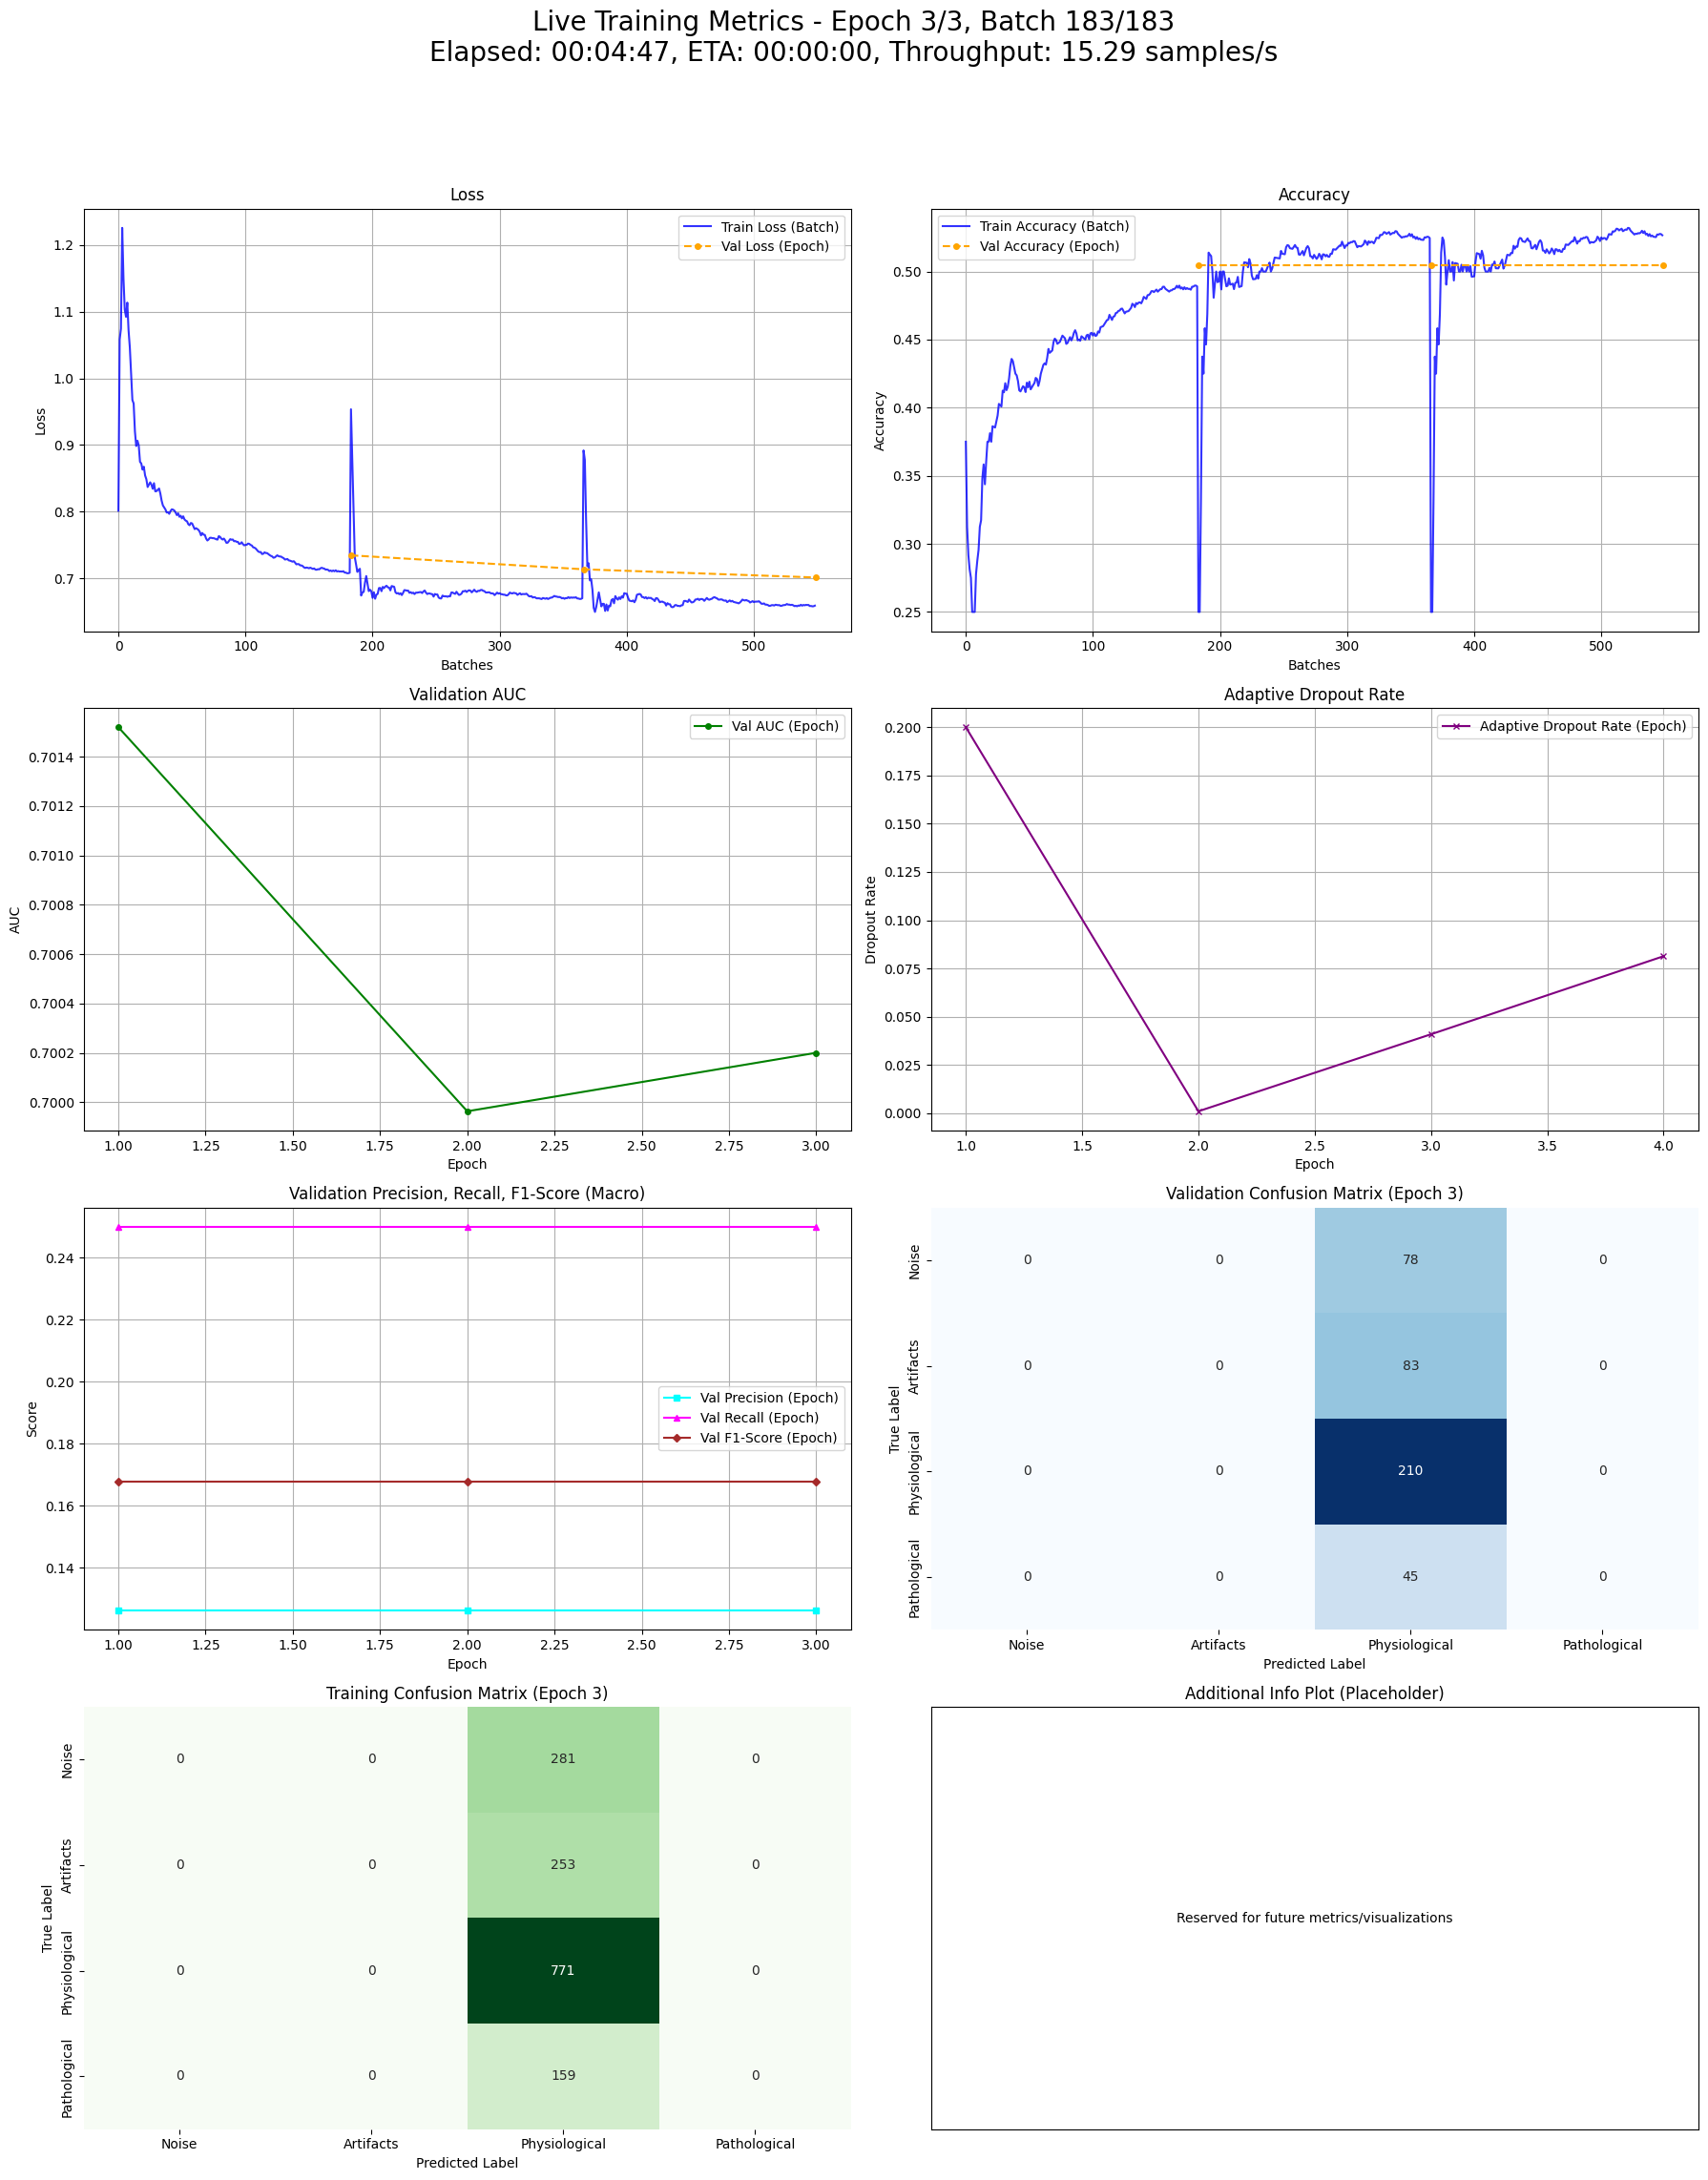


--- Saving Individual Plots ---
Plot saved: final_loss_plot.png
Plot saved: final_accuracy_plot.png
Plot saved: final_val_auc_plot.png
Plot saved: final_dropout_rate_plot.png
Plot saved: final_val_prf1_plot.png
Plot saved: final_val_confusion_matrix.png
Plot saved: final_train_confusion_matrix.png
Plot saved: final_additional_info_plot.png

--- Model Training Complete ---

--- Saving Model and Training Artifacts ---
Model saved to: C:\DATA_EEG\TCN_output\tcn_model.keras
Training history saved to: C:\DATA_EEG\TCN_output\training_history.json
Class weights saved to: C:\DATA_EEG\TCN_output\class_weights.json

--- Collecting Validation Set Predictions for Optimal Threshold Search ---

Searching for optimal F1-score threshold on 416 samples...
Optimal Threshold Found: 0.3300 with Macro F1-score: 0.2121

Optimal F1-Score Threshold found on Validation Set: 0.3300 (Macro F1: 0.2121)
Optimal F1 threshold data saved to: C:\DATA_EEG\TCN_output\optimal_f1_threshold.json

                     Trai

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


26/26 [==============================] - 3s 87ms/step - loss: 0.6779 - accuracy: 0.5577 - auc: 0.7416 - precision: 0.0000e+00 - recall: 0.0000e+00 - f1_score_macro: 0.1790

Test Results (Default Argmax Threshold):
   Loss: 0.6779
   Accuracy: 0.5577
   AUC: 0.7416
   Precision (Macro): 0.0000
   Recall (Macro): 0.0000
   F1-Score (Macro): 0.1790

--- Collecting Validation Set Predictions for Optimal Threshold Search ---

Searching for optimal F1-score threshold on 416 samples...
Optimal Threshold Found: 0.3300 with Macro F1-score: 0.2121

Optimal F1-Score Threshold found on Validation Set: 0.3300 (Macro F1: 0.2121)

--- Evaluating Test Set with Optimal F1 Threshold ---

Test Results (with Optimal Threshold 0.3300):
   F1-Score (Macro, Confident Predictions Only): 0.1818
   Precision (Macro, Confident Predictions Only): 0.1429
   Recall (Macro, Confident Predictions Only): 0.2500
   Number of Confident Predictions: 7 / 208

--- Test Set Confusion Matrix (Default Argmax Threshold) ---


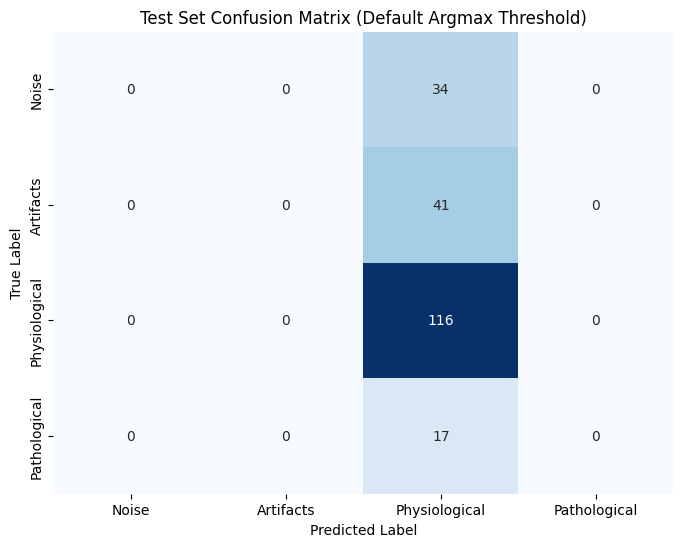

'\nprint("\n--- Zipping output directory for download ---")\ntry:\n    shutil.make_archive(\n        os.path.join(output_dir, \'tcn_output_artifacts\'), # Base name for the zip file\n        \'zip\',                                           # Archive format\n        output_dir                                       # Directory to archive\n    )\n    print(f"All output artifacts zipped to: {os.path.join(output_dir, \'tcn_output_artifacts.zip\')}")\n    print("You can download this file from your Kaggle kernel\'s output tab.")\nexcept Exception as e:\n    print(f"Error zipping output directory: {e}")\n'

In [ ]:

# --- CONSOLIDATED IMPORTS ---
# Clean /kaggle/working/ at the start of every run
import os, shutil


working_dir = r"C:\DATA_EEG\TCN_output"

for filename in os.listdir(working_dir):
    file_path = os.path.join(working_dir, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)  # remove file or symlink
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)  # remove folder
    except Exception as e:
        print(f"Failed to delete {file_path}: {e}")
import os
import time
import json
import numpy as np
import h5py
import tensorflow as tf

# Configure GPU memory growth BEFORE any other TensorFlow operations
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")

import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
from datetime import datetime # Import datetime for unique timestamp
# TensorFlow Keras specific imports (part of tensorflow)
from tensorflow.keras import layers, metrics, Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, TensorBoard, ModelCheckpoint, ReduceLROnPlateau
# Scikit-learn metrics and utilities
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split
# Jupyter/Kaggle specific utility for clearing output
from IPython.display import clear_output
from functools import partial
strategy = tf.distribute.MirroredStrategy()

# ---------------------------
# Data Directories and Files
# ---------------------------
DATA_SAMPLE_PERCENTAGE = 0.01
epochs = 3
EARLY_STOPPING_MONITOR = 'val_loss'
EARLY_STOPPING_PATIENCE = 1 # Reduced patience for faster training completion

dataset_dir = r'C:\DATA_EEG\DatasetJoined'
output_dir = r'C:\DATA_EEG\TCN_output'
main_dataset_file = os.path.join(dataset_dir, 'dataset.h5')

# Define paths for saving artifacts
MODEL_SAVE_PATH = os.path.join(output_dir, 'tcn_model.keras') # Keras native format
HISTORY_SAVE_PATH = os.path.join(output_dir, 'training_history.json')
PLOTS_SAVE_DIR = output_dir
CLASS_WEIGHTS_SAVE_PATH = os.path.join(output_dir, 'class_weights.json')
OPTIMAL_THRESHOLD_SAVE_PATH = os.path.join(output_dir, 'optimal_f1_threshold.json')
CHECKPOINT_DIR = os.path.join(output_dir, 'checkpoints')

NUM_CLASSES = 4
INPUT_SEQUENCE_LENGTH = 15000 # Adjusted to user's specified length
batch_size = 8 # Reduced batch size to prevent OOM
ACCUMULATION_STEPS = 1 # Increased accumulation steps to maintain effective batch size
INITIAL_LEARNING_RATE = 2e-3 # Increased learning rate for faster convergence
L2_REGULARIZATION_LAMBDA = 1e-4

DILATED_CONV_FILTERS = 8 # Further reduced filters to save memory
DILATED_CONV_KERNEL_SIZE = 1
# Further reduced dilation rates for speed and memory
DILATED_CONV_DILATION_RATES = [1, 2, 4, 8, 16] 


train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

AUGMENTATION_PROBABILITY = 0.0 # Data augmentation is now disabled
NOISE_AMPLITUDE = 0.01
SCALE_FACTOR_MIN = 0.98
SCALE_FACTOR_MAX = 1.005

INITIAL_DROPOUT_RATE = 0.2
MIN_DROPOUT_RATE = 0.001
MAX_DROPOUT_RATE = 0.7
DROPOUT_SCALING_FACTOR = 0.05
DROPOUT_BASELINE_GAP = 0.02

CLASS_NAMES = ["Noise", "Artifacts", "Physiological", "Pathological"]
PLOT_HISTORY_METRICS = ['loss', 'accuracy', 'auc', 'precision', 'recall', 'f1_score_macro']
PLOT_EVERY_N_BATCHES = 30000 # Further reduced plotting frequency to save memory

USE_FOCAL_LOSS = True
FOCAL_LOSS_GAMMA = 2.0

OPTIMIZE_THRESHOLD_ON_VALIDATION = True
THRESHOLD_SEARCH_STEPS = 50

# NEW: Control variable for dataset caching
USE_DATASET_CACHING = False # Disable caching to save memory
# Performance optimization flags
USE_GRADIENT_ACCUMULATION = False
USE_MIXED_PRECISION = True
VALIDATION_FREQUENCY = 1 # Validate every 3 epochs to save memory

print('done')

# ---------------------------
# Clear TensorFlow Dataset Caches (MORE ROBUST CLEANUP)
# ---------------------------
# Generate a unique timestamp for cache directories to avoid conflicts for new caches
unique_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

# Define paths for dataset caches with unique suffixes for *new* caches
# These paths will only be used if USE_DATASET_CACHING is True
train_cache_filepath = os.path.join(output_dir, f'train_dataset_cache_{unique_timestamp}')
val_cache_filepath = os.path.join(output_dir, f'val_dataset_cache_{unique_timestamp}')
test_cache_filepath = os.path.join(output_dir, f'test_dataset_cache_{unique_timestamp}')

print("\n--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---")
for item_name in os.listdir(output_dir):
    full_path = os.path.join(output_dir, item_name)
    
    # Check for directories that look like TF cache directories or any lockfiles
    if os.path.isdir(full_path) and ("_dataset_cache" in item_name or "dataset_cache" in item_name):
        try:
            shutil.rmtree(full_path)
            print(f"Removed old cache directory: {full_path}")
        except OSError as e:
            print(f"Error removing old cache directory {full_path}: {e}")
    # Check for any .lockfile
    elif item_name.endswith('.lockfile'):
        try:
            os.remove(full_path)
            print(f"Removed old cache lockfile: {full_path}")
        except OSError as e:
            print(f"Error removing old cache lockfile {full_path}: {e}")
print("--- Aggressive cleanup complete ---")

# ---------------------------
# TPU Detection and Strategy Initialization (Removed for local execution, still included for context)
# ---------------------------
# The following TPU setup is commented out as requested to avoid issues,
# but it's kept for reference if you ever return to TPU training.
# try:
#     tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
#     print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])
#     tf.config.experimental_connect_to_cluster(tpu)
#     tf.tpu.experimental.initialize_tpu_system(tpu)
#     strategy = tf.distribute.TPUStrategy(tpu)
# except ValueError:
#     print('Not running on TPU, trying to run on GPU or CPU...')
strategy = tf.distribute.get_strategy() # Default strategy for CPU and single GPU
print('Number of accelerators: {}'.format(strategy.num_replicas_in_sync))


# ---------------------------
# Custom Swish Activation Layer - NEW IMPLEMENTATION
# ---------------------------
class SwishActivation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SwishActivation, self).__init__(**kwargs)

    def call(self, x):
        """
        Implements the Swish activation function: x * sigmoid(x).
        This is now a proper Keras layer to ensure compatibility with KerasTensors.
        """
        return x * tf.sigmoid(x)

    def get_config(self):
        return super(SwishActivation, self).get_config()

# ---------------------------
# Custom F1-Score Metric (Macro Average)
# ---------------------------
class F1ScoreMacro(tf.keras.metrics.Metric):
    """
    Custom Keras Metric for calculating the Macro F1-Score for multi-class classification.
    This metric sums True Positives, False Positives, and False Negatives per class
    over batches and then calculates the F1-score for each class before averaging them.
    """
    def __init__(self, num_classes, name='f1_score_macro', **kwargs):
        super(F1ScoreMacro, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # Initialize internal variables for TP, FP, FN for each class
        # These are tf.Variable objects and will be reset by Keras when reset_states is called
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros', dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Cast inputs to the metric's dtype
        y_true = tf.cast(y_true, self.dtype)
        y_pred = tf.cast(y_pred, self.dtype)

        # Convert one-hot encoded labels to sparse (integer) labels for argmax
        y_true_labels = tf.argmax(y_true, axis=-1)
        y_pred_labels = tf.argmax(y_pred, axis=-1)

        # Create one-hot encoded versions of the predicted labels
        # This is essential for element-wise multiplication to count TP, FP, FNGx per class
        y_pred_one_hot = tf.one_hot(y_pred_labels, depth=self.num_classes, dtype=self.dtype)

        # Calculate True Positives (TP) per class: y_true == 1 AND y_pred == 1
        current_tp = tf.reduce_sum(y_true * y_pred_one_hot, axis=0)
        
        # Calculate False Positives (FP) per class: y_true == 0 AND y_pred == 1
        current_fp = tf.reduce_sum((1 - y_true) * y_pred_one_hot, axis=0)

        # Calculate False Negatives (FN) per class: y_true == 1 AND y_pred == 0
        current_fn = tf.reduce_sum(y_true * (1 - y_pred_one_hot), axis=0)
        
        # Assign values to the state variables
        self.tp.assign_add(current_tp)
        self.fp.assign_add(current_fp)
        self.fn.assign_add(current_fn)

    def result(self):
        # Add epsilon to denominators to prevent division by zero
        epsilon = tf.keras.backend.epsilon()
        
        # Calculate Precision per class
        precision_per_class = self.tp / (self.tp + self.fp + epsilon)
        
        # Calculate Recall per class
        recall_per_class = self.tp / (self.tp + self.fn + epsilon)

        # Calculate F1-score per class
        f1_per_class = 2 * (precision_per_class * recall_per_class) / (precision_per_class + recall_per_class + epsilon)

        # Macro F1-score is the unweighted average of F1-scores across all classes
        return tf.reduce_mean(f1_per_class)

    def reset_states(self):
        # Reset all internal variables to their initial (zero) state
        # The base class's reset_states calls this for each `self.add_weight` variable
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))

    def get_config(self):
        config = super(F1ScoreMacro, self).get_config()
        config.update({'num_classes': self.num_classes})
        return config

# ---------------------------
# 1. Enable GPU Usage and Optimizations
# ---------------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU.")

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')
start_time = time.time() # This is the global start_time we need

# ---------------------------
# Custom Focal Loss Function
# ---------------------------
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha_weights=None):
    """
    Custom implementation of Focal Loss for multi-class classification.
    Args:
        y_true (tf.Tensor): True labels (one-hot encoded).
        y_pred (tf.Tensor): Predicted probabilities (after softmax).
        gamma (float): Focusing parameter. Higher gamma reduces the loss for
                       well-classified examples, focusing on hard examples.
        alpha_weights (tf.Tensor or None): Class-specific weighting factor.
                                           If None, all classes are weighted equally.
                                           Should be a tensor of shape (NUM_CLASSES,).
    Returns:
        tf.Tensor: Computed focal loss.
    """
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon) # Clip to prevent log(0)
    # Calculate cross-entropy
    cross_entropy = -y_true * tf.math.log(y_pred)
    # Calculate p_t (probability of the true class)
    # y_true is one-hot, so y_true * y_pred gives 0 for incorrect classes and y_pred for true class
    p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
    # Calculate modulating factor (1 - p_t)^gamma
    modulating_factor = tf.pow(1.0 - p_t, gamma)
    # Apply alpha weights if provided
    if alpha_weights is not None:
        # Reshape alpha_weights to match y_true/y_pred for element-wise multiplication
        # alpha_weights should be (batch_size, NUM_CLASSES) if using y_true directly for indexing
        # Or (NUM_CLASSES,) for broadcastable multiplication
        alpha_factor = tf.reduce_sum(y_true * alpha_weights, axis=-1, keepdims=True)
        focal_loss = alpha_factor * modulating_factor * cross_entropy
    else:
        focal_loss = modulating_factor * cross_entropy
    return tf.reduce_sum(focal_loss, axis=-1) # Sum across classes for each sample

# --- IMPORTANT: Register your custom focal_loss_fn ---
# This makes Keras aware of your custom loss function by name, allowing it to be
# serialized correctly when you save your model.
tf.keras.utils.get_custom_objects().update({'focal_loss_fn': focal_loss_fn})


# ---------------------------
# HDF5 Generator (Modified for global shuffling)
# ---------------------------
def hdf5_generator(file_path, shuffled_keys_for_split):
    """
    A Python generator function to efficiently load and preprocess data
    from an HDF5 file based on a pre-shuffled list of keys.
    It yields normalized data tensors and one-hot encoded labels.
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
    Yields:
        tuple: A tuple containing:
            - tf.Tensor: The preprocessed data (normalized float32).
            - tf.Tensor: The integer label (int64).
    """
    # Open the HDF5 file once for the duration of the generator's existence
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str, file_name in shuffled_keys_for_split:
            dataset_key = f"{label_str}/{file_name}"
            if dataset_key not in hdf5_file:
                # print(f"Warning: Dataset key '{dataset_key}' not found in HDF5 file. Skipping.") # Uncomment for debugging
                continue
            try:
                # Load data, convert to float32, and normalize (Z-score)
                data = hdf5_file[dataset_key][:].astype(np.float32)
                data = (data - np.mean(data)) / (np.std(data) + 1e-8) # Add epsilon for stability
                int_label = int(label_str.split('_')[-1])
                # Yield data and label as TensorFlow tensors
                yield tf.convert_to_tensor(data.reshape((1, INPUT_SEQUENCE_LENGTH, 1)), dtype=tf.float32), \
                      tf.convert_to_tensor(np.array([int_label]), dtype=tf.int64)
            except Exception as e:
                print(f"HDF5 generator error for {dataset_key}: {e}. Skipping sample.")
                continue
    # The generator will exit when all keys in shuffled_keys_for_split have been processed.
    # The .repeat() on the dataset will then cause it to restart from the beginning of the shuffled keys.

# ---------------------------
# Preprocessing Functions
# ---------------------------
def reshape_input(x, y):
    """
    Reshapes the input tensor `x` by removing a singular dimension (axis=1).
    This is often needed when the generator yields data with an extra batch dimension.
    Args:
        x (tf.Tensor): The input data tensor.
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Reshaped x and original y.
    """
    return tf.squeeze(x, axis=1), y

def one_hot_encode_labels(x, y):
    """
    Converts integer labels `y` into one-hot encoded vectors.
    Args:
        x (tf.Tensor): The input data tensor.
        y (tf.Tensor): The integer label tensor.
    Returns:
        tuple: Original x and one-hot encoded y.
    """
    # Squeeze y to remove any singular dimensions before one-hot encoding
    y_one_hot = tf.one_hot(tf.squeeze(y, axis=-1), depth=NUM_CLASSES, dtype=tf.float32)
    return x, y_one_hot

# ---------------------------
# Data Augmentation Function (MODIFIED for 35% chance and wider range)
# ---------------------------
def apply_augmentation(x, y): # Removed probability parameter, now uses global AUGMENTATION_PROBABILITY
    """
    Adds random Gaussian noise and applies random amplitude scaling to the input
    time-series data with a given probability.
    Args:
        x (tf.Tensor): The input data tensor (time-series).
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Augmented x or original x, and original y.
    """
    def augment_true():
        # 1. Add Random Gaussian Noise
        noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=NOISE_AMPLITUDE, dtype=tf.float32)
        augmented_x = x + noise
        # 2. Random Amplitude Scaling
        scale_factor = tf.random.uniform(shape=[], minval=SCALE_FACTOR_MIN, maxval=SCALE_FACTOR_MAX, dtype=tf.float32)
        augmented_x = augmented_x * scale_factor
        return augmented_x

    def augment_false():
        return x # Return original x if augmentation is not applied

    # Generate a random uniform number
    rand_val = tf.random.uniform(shape=[], minval=0.0, maxval=1.0, dtype=tf.float32)
    # Conditionally apply augmentation based on the random number
    augmented_x = tf.cond(rand_val < AUGMENTATION_PROBABILITY, augment_true, augment_false)
    return augmented_x, y

# ---------------------------
# Dataset Creation (Modified for Caching and Parallelism)
# ---------------------------
def create_tf_dataset(file_path, batch_size, shuffled_keys_for_split, augment=False,
                      use_cache=USE_DATASET_CACHING, cache_filepath=None):
    """
    Creates a TensorFlow Dataset from the HDF5 generator, applying batching
    and preprocessing steps. Shuffling is handled by the pre-shuffled keys list.
    
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        batch_size (int): The number of samples per batch.
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
        augment (bool): Whether to apply data augmentation. Set to True for training data.
        use_cache (bool): If True, caches the dataset elements after the generator.
                          Now defaults to the global USE_DATASET_CACHING variable.
        cache_filepath (str, optional): Path to a file for disk caching. If None, caches in memory.
                                        Only used if use_cache is True.
    
    Returns:
        tf.data.Dataset: A configured TensorFlow Dataset ready for training/evaluation.
    """

    # Define conservative values
    # These can be tuned: start low, then increase if stable.
    # A common starting point is num_CPU_cores or a small integer.
    # For Kaggle with shared resources, even 2-4 might be better than AUTOTUNE if OOM.
    _fixed_num_parallel_calls = 2  # Or try 2, or tf.data.experimental.AUTOTUNE.num_cpu_cores if available
    _fixed_prefetch_buffer_size = 2  # Or 1, or tf.data.AUTOTUNE

    dataset = tf.data.Dataset.from_generator(
        lambda: hdf5_generator(file_path, shuffled_keys_for_split),
        output_signature=(
            tf.TensorSpec(shape=(1, INPUT_SEQUENCE_LENGTH, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(1,), dtype=tf.int64)
        )
    )

    if use_cache:
        if cache_filepath:
            print(f"Caching dataset to disk at: {cache_filepath}")
            dataset = dataset.cache(cache_filepath)
        else:
            print("Caching dataset in memory.")
            dataset = dataset.cache()

    dataset = dataset.batch(batch_size).repeat()

    if augment:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=_fixed_num_parallel_calls)

    dataset = dataset.map(reshape_input, num_parallel_calls=_fixed_num_parallel_calls)
    dataset = dataset.map(one_hot_encode_labels, num_parallel_calls=_fixed_num_parallel_calls)

    return dataset.prefetch(_fixed_prefetch_buffer_size)  # Use fixed prefetch size here


# ---------------------------
# Adaptive Dropout & Metric Logging Callback (MODIFIED FOR COMPOSITE SCORE)
# ---------------------------
class MetricsAndAdaptiveDropout(tf.keras.callbacks.Callback):
    """
    A custom Keras Callback that dynamically adjusts the dropout rate
    based on a composite score derived from multiple model performance metrics
    (validation accuracy, AUC, validation loss, and train/val accuracy gap).
    It also logs metrics to the console and passes dropout rate to a plotter.
    """
    def __init__(self, validation_data, verbose=0, initial_dropout=INITIAL_DROPOUT_RATE, min_dropout=MIN_DROPOUT_RATE, max_dropout=MAX_DROPOUT_RATE,
                     scaling_factor=DROPOUT_SCALING_FACTOR, baseline_gap=DROPOUT_BASELINE_GAP,
                     plotter_callback=None):
        super().__init__()
        self.validation_data_arg = validation_data
        self.verbose = verbose
        self.initial_dropout = initial_dropout
        self.min_dropout = min_dropout
        self.max_dropout = max_dropout
        self.scaling_factor = scaling_factor
        self.baseline_gap = baseline_gap # Used for the relative_gap component
        # Initialize previous values for metric comparison to calculate impact
        self.previous_val_acc = 0.0
        self.previous_auc = 0.0
        self.previous_val_loss = float('inf') # Start with a high loss
        self.current_dropout_rate = initial_dropout
        self.dropout_layer = None
        self.dropout_rate_history = []
        self.plotter_callback = plotter_callback

    def on_train_begin(self, logs=None):
        # Find the first dropout layer in the model to control its rate
        for layer in self.model.layers:
            # Check if the layer is a functional API layer or a sequential layer
            if hasattr(layer, 'layers'): # For functional API models, layers might be nested
                for sub_layer in layer.layers:
                    if isinstance(sub_layer, tf.keras.layers.Dropout):
                        self.dropout_layer = sub_layer
                        break
            if isinstance(layer, tf.keras.layers.Dropout): # For simple sequential models
                self.dropout_layer = layer
                break
        
        if self.dropout_layer is None:
            print("Warning: No Dropout layer found for AdaptiveDropout. Adaptive dropout will not function.")
        else:
            self.dropout_layer.rate = self.initial_dropout
            self.current_dropout_rate = self.initial_dropout
            if self.verbose > 0:
                print(f"Initial dropout rate set to: {self.initial_dropout:.4f}")
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)

    def on_epoch_end(self, epoch, logs=None):
        if self.dropout_layer is None:
            return
        logs = logs or {}
        train_acc = logs.get('accuracy', 0.0) # Training accuracy for relative gap
        val_acc = logs.get('val_accuracy', 0.0)
        auc = logs.get('val_auc', 0.0)
        val_loss = logs.get('val_loss', float('inf'))
        # Add a small epsilon to denominator to prevent division by zero
        relative_gap = (train_acc - val_acc) / max(train_acc, 1e-8) if train_acc > 0 else 0.0
        # Calculate the absolute difference first for clarity or reuse
        abs_val_acc_diff = abs(val_acc - self.previous_val_acc)
        # Now use it in the conditional assignment
        val_no_learn = abs_val_acc_diff if abs_val_acc_diff > 0.01 else 20
        # Calculate the impact of changes in metrics from the previous epoch
        # Positive impact value means metric is worsening (e.g., val_acc decreased, val_loss increased)
        # We want to increase dropout if performance worsens, so signs are chosen accordingly.
        val_acc_impact = (self.previous_val_acc - val_acc) * 1.5
        auc_impact = (self.previous_auc - auc) * 0.8
        val_loss_impact = (val_loss - self.previous_val_loss) * 1.0
        val_no_learn_impact = (val_no_learn)/25
        # Calculate the composite score
        composite_score = (
            val_acc_impact +
            auc_impact +
            val_loss_impact +
            (relative_gap - self.baseline_gap)+ # If relative gap is too high, this term increases score
            val_no_learn_impact
        )
        # Update dropout rate based on the composite score
        new_dropout = self.current_dropout_rate + (composite_score * self.scaling_factor)
        # Clip the new dropout rate within the defined min and max bounds
        new_dropout = min(max(new_dropout, self.min_dropout), self.max_dropout)
        # Update the dropout layer's rate
        self.dropout_layer.rate = new_dropout
        self.current_dropout_rate = new_dropout
        # Update previous metric values for the next epoch's calculation
        self.previous_val_acc = val_acc
        self.previous_auc = auc
        self.previous_val_loss = val_loss
        # Log the current dropout rate and update the plotter callback
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)
        if self.verbose > 0:
            print(f"\nEpoch {epoch+1}: Composite Score: {composite_score:.4f}, New Dropout Rate: {self.current_dropout_rate:.4f}")
            print(f"   (Val Acc: {val_acc:.4f}, AUC: {auc:.4f}, Val Loss: {val_loss:.4f}, Rel Gap: {relative_gap:.4f})")

    def get_config(self):
        config = super().get_config()
        config.update({
            'initial_dropout': float(self.initial_dropout),
            'min_dropout': float(self.min_dropout),
            'max_dropout': float(self.max_dropout),
            'scaling_factor': float(self.scaling_factor),
            'baseline_gap': float(self.baseline_gap),
        })
        return config

# ---------------------------
# Live Plotting Callback (Modified for batch-level plotting and separate saving)
# ---------------------------
class BatchMetricsPlotter(tf.keras.callbacks.Callback):
    """
    A Keras Callback for live plotting of training and validation metrics.
    Metrics are plotted per batch for training, and per epoch for validation.
    Includes Loss, Accuracy, AUC, Adaptive Dropout Rate, Precision, Recall, F1-Score, and Confusion Matrix.
    """
    def __init__(self, num_classes=NUM_CLASSES, val_dataset=None, validation_steps=None,
                     class_names=CLASS_NAMES, start_time=None, batch_size=None, steps_per_epoch=None, total_epochs=None,
                     plot_every_n_batches=PLOT_EVERY_N_BATCHES, train_dataset=None): # Added train_dataset
        super().__init__()
        self.batch_count = 0
        self.current_epoch = 0
        self.num_classes = num_classes
        self.val_dataset = val_dataset
        self.train_dataset = train_dataset # Store train_dataset
        self.validation_steps = validation_steps
        self.steps_per_epoch = steps_per_epoch # Also need steps_per_epoch for training CM
        self.class_names = class_names if class_names is not None else [str(i) for i in range(num_classes)]
        self.start_time = start_time if start_time is not None else time.time()
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.total_epochs = total_epochs
        self.plot_every_n_batches = plot_every_n_batches # Store the interval
        self.train_loss_history = []
        self.train_accuracy_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        self.val_auc_history = []
        self.dropout_rate_history = [] # To be populated by AdaptiveDropout callback
        self.val_precision_history = []
        self.val_recall_history = []
        self.val_f1_score_history = []
        self.confusion_matrix_history = []
        self.train_confusion_matrix_history = [] # New: for training confusion matrix
        plt.ion() # Enable interactive plotting

    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch + 1
        # NOT clearing train_confusion_matrix_history here as requested
        # self.train_confusion_matrix_history = [] # REMOVED THIS LINE
        # This means the last epoch's training CM will persist until the new epoch completes.

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.batch_count += 1
        self.train_loss_history.append(logs.get('loss', 0))
        self.train_accuracy_history.append(logs.get('accuracy', 0))
        # Plot only if it's time to plot
        if self.batch_count % self.plot_every_n_batches == 0:
            self._update_plot(is_batch_plot=True) # Pass flag to indicate batch plot

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.val_loss_history.append(logs.get('val_loss', 0))
        self.val_accuracy_history.append(logs.get('val_accuracy', 0))
        self.val_auc_history.append(logs.get('val_auc', 0))
        self.current_epoch = epoch + 1
        val_true_labels_epoch = []
        val_predicted_probs_epoch = []
        if self.model and self.val_dataset and self.validation_steps:
            val_data_iterator = iter(self.val_dataset)
            for _ in range(self.validation_steps):
                try:
                    val_x_batch, val_y_true_batch = next(val_data_iterator)
                    val_predicted_probs_batch = self.model.predict(val_x_batch, verbose=0)
                    val_true_labels_epoch.extend(tf.argmax(val_y_true_batch, axis=-1).numpy())
                    val_predicted_probs_epoch.extend(val_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Validation dataset exhausted prematurely during epoch end prediction.")
                    break
        if val_true_labels_epoch and val_predicted_probs_epoch:
            y_true_np = np.array(val_true_labels_epoch)
            y_pred_probs_np = np.array(val_predicted_probs_epoch)
            y_pred_classes_np = np.argmax(y_pred_probs_np, axis=-1)
            cm = confusion_matrix(y_true_np, y_pred_classes_np, labels=np.arange(self.num_classes))
            self.confusion_matrix_history.append(cm)
            macro_precision = precision_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_recall = recall_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_f1 = f1_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            self.val_precision_history.append(macro_precision)
            self.val_recall_history.append(macro_recall)
            self.val_f1_score_history.append(macro_f1)
        else:
            self.confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
            self.val_precision_history.append(0.0)
            self.val_recall_history.append(0.0)
            self.val_f1_score_history.append(0.0)
        # New: Collect data and generate confusion matrix for training dataset at epoch end
        train_true_labels_epoch = []
        train_predicted_probs_epoch = []
        if self.model and self.train_dataset and self.steps_per_epoch:
            # Create a temporary iterator for one full pass over the training data for CM
            train_data_iterator_cm = iter(self.train_dataset.unbatch().batch(self.batch_size).take(self.steps_per_epoch))
            for _ in range(self.steps_per_epoch):
                try:
                    train_x_batch, train_y_true_batch = next(train_data_iterator_cm)
                    train_predicted_probs_batch = self.model.predict(train_x_batch, verbose=0)
                    train_true_labels_epoch.extend(tf.argmax(train_y_true_batch, axis=-1).numpy())
                    train_predicted_probs_epoch.extend(train_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Training dataset exhausted prematurely during epoch end training CM prediction.")
                    break
        if train_true_labels_epoch and train_predicted_probs_epoch:
            train_y_true_np = np.array(train_true_labels_epoch)
            train_y_pred_probs_np = np.array(train_predicted_probs_epoch)
            train_y_pred_classes_np = np.argmax(train_y_pred_probs_np, axis=-1)
            train_cm = confusion_matrix(train_y_true_np, train_y_pred_classes_np, labels=np.arange(self.num_classes))
            self.train_confusion_matrix_history.append(train_cm)
        else:
            self.train_confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
        # Trigger a final plot update at the end of the epoch to show latest validation metrics
        self._update_plot(is_batch_plot=False) # Pass flag to indicate epoch plot

    def on_train_end(self, logs=None):
        # Save the final plot and individual subplots
        self._update_plot(final_save=True)
        plt.ioff() # Turn off interactive mode at the end of training
        plt.close('all') # Close all plot windows

    def log_dropout_rate(self, dropout_rate):
        """
        Method to receive and store the dropout rate from the AdaptiveDropout callback.
        """
        self.dropout_rate_history.append(dropout_rate)

    def _update_plot(self, is_batch_plot=True, final_save=False):
        """
        Clears the output and redraws the plot with 8 subplots (4x2 layout),
        showing batch-level training metrics, epoch-level validation metrics,
        adaptive dropout rate, and confusion matrix, along with a progress bar.
        If final_save is True, saves the plots to files.
        """
        if not final_save:
            clear_output(wait=True) # Clear previous plot output
            fig, axes = plt.subplots(4, 2, figsize=(18, 24)) # Increased height for 4 rows
            axes = axes.flatten() # Flatten for easier indexing
        else:
            # If final_save, we will create new figures for each plot
            pass # No need to create a multi-subplot figure for final save in this block

        # Calculate dynamic stats for the title
        elapsed_seconds = time.time() - self.start_time
        total_samples_processed = self.batch_count * self.batch_size if self.batch_size is not None else 0
        samples_per_second = total_samples_processed / elapsed_seconds if elapsed_seconds > 0 else 0
        
        # Format elapsed time
        el_h = int(elapsed_seconds // 3600)
        el_m = int((elapsed_seconds % 3600) // 60)
        el_s = int(elapsed_seconds % 60)
        elapsed_formatted = f'{el_h:02d}:{el_m:02d}:{el_s:02d}'
        
        # Calculate estimated remaining time (ETA)
        eta_str = ""
        if self.steps_per_epoch and self.total_epochs and self.batch_size and samples_per_second > 0:
            total_batches = self.steps_per_epoch * self.total_epochs
            batches_remaining = total_batches - self.batch_count
            if batches_remaining > 0:
                estimated_remaining_seconds = batches_remaining * self.batch_size / samples_per_second
                rem_h = int(estimated_remaining_seconds // 3600)
                rem_m = int((estimated_remaining_seconds % 3600) // 60)
                rem_s = int(estimated_remaining_seconds % 60)
                eta_str = f', ETA: {rem_h:02d}:{rem_m:02d}:{rem_s:02d}'
            else:
                eta_str = ', ETA: 00:00:00'
        
        current_batch_in_epoch = (self.batch_count - 1) % self.steps_per_epoch + 1
        plot_title_suffix = f'Epoch {self.current_epoch}/{self.total_epochs}, Batch {current_batch_in_epoch}/{self.steps_per_epoch}\nElapsed: {elapsed_formatted}{eta_str}, Throughput: {samples_per_second:.2f} samples/s'

        # Function to plot and save a single subplot
        def plot_and_save_single(fig_idx, filename_base, title_suffix, plot_data_fn):
            fig, ax = plt.subplots(figsize=(9, 6)) # Adjust size as needed
            plot_data_fn(ax) # Call the function to populate the plot
            ax.set_title(f'{filename_base.replace("_", " ").title()} ({title_suffix})')
            plt.savefig(os.path.join(PLOTS_SAVE_DIR, f'{filename_base}.png'), bbox_inches='tight')
            plt.close(fig) # Close the figure to free memory
            print(f"Plot saved: {filename_base}.png")


        # --- Plotting logic for real-time display ---
        if not final_save:
            fig.suptitle(f'Live Training Metrics - {plot_title_suffix}', fontsize=20)
            
            # Plot 1: Loss
            axes[0].plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8)
            if self.val_loss_history:
                val_x = np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch
                axes[0].plot(val_x, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
            axes[0].set_title('Loss')
            axes[0].set_xlabel('Batches')
            axes[0].set_ylabel('Loss')
            axes[0].legend()
            axes[0].grid(True)
            
            # Plot 2: Accuracy
            axes[1].plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8)
            if self.val_accuracy_history:
                val_x = np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch
                axes[1].plot(val_x, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
            axes[1].set_title('Accuracy')
            axes[1].set_xlabel('Batches')
            axes[1].set_ylabel('Accuracy')
            axes[1].legend()
            axes[1].grid(True)
            
            # Plot 3: Validation AUC (Epoch-level)
            if self.val_auc_history:
                axes[2].plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4)
                axes[2].set_title('Validation AUC')
                axes[2].set_xlabel('Epoch')
                axes[2].set_ylabel('AUC')
                axes[2].legend()
                axes[2].grid(True)
            else:
                axes[2].set_title('Validation AUC (Epoch-End Only)')
                axes[2].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)
            
            # Plot 4: Adaptive Dropout Rate (Epoch-level)
            if self.dropout_rate_history:
                axes[3].plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4)
                axes[3].set_title('Adaptive Dropout Rate')
                axes[3].set_xlabel('Epoch')
                axes[3].set_ylabel('Dropout Rate')
                axes[3].legend()
                axes[3].grid(True)
            else:
                axes[3].set_title('Adaptive Dropout Rate (Epoch-End Only)')
                axes[3].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[3].transAxes)
            
            # Plot 5: Precision, Recall, F1-Score (Epoch-level)
            if self.val_precision_history:
                axes[4].plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4)
                axes[4].plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4)
                axes[4].plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4)
                axes[4].set_title('Validation Precision, Recall, F1-Score (Macro)')
                axes[4].set_xlabel('Epoch')
                axes[4].set_ylabel('Score')
                axes[4].legend()
                axes[4].grid(True)
            else:
                axes[4].set_title('Validation PRF1 (Epoch-End Only)')
                axes[4].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[4].transAxes)
            
            # Plot 6: Validation Confusion Matrix (Latest Epoch)
            if self.confusion_matrix_history:
                latest_cm = self.confusion_matrix_history[-1]
                sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[5],
                            xticklabels=self.class_names, yticklabels=self.class_names)
                axes[5].set_title(f'Validation Confusion Matrix (Epoch {self.current_epoch})')
                axes[5].set_xlabel('Predicted Label')
                axes[5].set_ylabel('True Label')
            else:
                axes[5].set_title('Validation Confusion Matrix (Epoch-End Only)')
                axes[5].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[5].transAxes)
            
            # Plot 7: Training Confusion Matrix (Latest Epoch)
            if self.train_confusion_matrix_history:
                latest_train_cm = self.train_confusion_matrix_history[-1]
                sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[6],
                            xticklabels=self.class_names, yticklabels=self.class_names)
                axes[6].set_title(f'Training Confusion Matrix (Epoch {self.current_epoch})')
                axes[6].set_xlabel('Predicted Label')
                axes[6].set_ylabel('True Label')
            else:
                axes[6].set_title('Training Confusion Matrix (Epoch-End Only)')
                axes[6].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[6].transAxes)
            
            # Plot 8: Placeholder for additional info
            axes[7].set_title('Additional Info Plot (Placeholder)')
            axes[7].text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                                 horizontalalignment='center', verticalalignment='center', transform=axes[7].transAxes)
            axes[7].set_xticks([])
            axes[7].set_yticks([])
            axes[7].grid(False)
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.94]) # Adjust layout to prevent title overlap
            plt.show()

        else: # Final Save Logic: Create new figures for each plot and save them separately
            print("\n--- Saving Individual Plots ---")

            # Plot 1: Loss
            if self.train_loss_history or self.val_loss_history:
                plot_and_save_single(
                    1, 'final_loss_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8),
                        (ax.plot(np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4) if self.val_loss_history else None),
                        ax.set_xlabel('Batches'), ax.set_ylabel('Loss'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 2: Accuracy
            if self.train_accuracy_history or self.val_accuracy_history:
                plot_and_save_single(
                    2, 'final_accuracy_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8),
                        (ax.plot(np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4) if self.val_accuracy_history else None),
                        ax.set_xlabel('Batches'), ax.set_ylabel('Accuracy'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 3: Validation AUC
            if self.val_auc_history:
                plot_and_save_single(
                    3, 'final_val_auc_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('AUC'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 4: Adaptive Dropout Rate
            if self.dropout_rate_history:
                plot_and_save_single(
                    4, 'final_dropout_rate_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Dropout Rate'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 5: Precision, Recall, F1-Score
            if self.val_precision_history:
                plot_and_save_single(
                    5, 'final_val_prf1_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4),
                        ax.plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4),
                        ax.plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Score'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 6: Validation Confusion Matrix (Latest Epoch)
            if self.confusion_matrix_history:
                latest_cm = self.confusion_matrix_history[-1]
                plot_and_save_single(
                    6, 'final_val_confusion_matrix', f'Epoch {self.current_epoch}',
                    lambda ax: sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                                           xticklabels=self.class_names, yticklabels=self.class_names)
                )
                
            # Plot 7: Training Confusion Matrix (Latest Epoch)
            if self.train_confusion_matrix_history:
                latest_train_cm = self.train_confusion_matrix_history[-1]
                plot_and_save_single(
                    7, 'final_train_confusion_matrix', f'Epoch {self.current_epoch}',
                    lambda ax: sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax,
                                           xticklabels=self.class_names, yticklabels=self.class_names)
                )

            # Plot 8: Placeholder for additional info
            plot_and_save_single(
                8, 'final_additional_info_plot', plot_title_suffix,
                lambda ax: (
                    ax.text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                             horizontalalignment='center', verticalalignment='center', transform=ax.transAxes),
                    ax.set_xticks([]), ax.set_yticks([]), ax.grid(False)
                )
            )

# Helper Function to Get All Sample Keys (for global shuffling)
def _get_all_sample_keys(file_path, sample_percentage=1.0):
    """
    Reads all (label_str, file_name) tuples from an HDF5 file,
    then randomly samples a specified percentage of these keys.
    This reads only the keys/metadata, not the full data, to minimize memory usage.
    Args:
        file_path (str): The path to the main HDF5 file.
        sample_percentage (float): The percentage of total samples to use (e.g., 0.1 for 10%).
                                   Must be between 0.0 and 1.0.
    Returns:
        list: A randomly sampled and shuffled list of (label_str, file_name) tuples.
    """
    all_keys = []
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Main dataset file not found: {file_path}")
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str in hdf5_file.keys(): # Iterate directly over top-level groups (labels)
            for file_name in hdf5_file[label_str].keys(): # Iterate over datasets (files) within each label group
                all_keys.append((label_str, file_name))
    num_total_samples = len(all_keys)
    num_samples_to_keep = int(num_total_samples * sample_percentage)
    if num_samples_to_keep == 0 and num_total_samples > 0:
        print(f"Warning: sample_percentage {sample_percentage*100}% results in 0 samples. Keeping at least 1 if available.")
        num_samples_to_keep = 1 if num_total_samples > 0 else 0
    elif num_samples_to_keep > num_total_samples:
        print(f"Warning: sample_percentage {sample_percentage*100}% is greater than 100%. Using all {num_total_samples} samples.")
        num_samples_to_keep = num_total_samples
    if num_samples_to_keep > 0:
        sampled_keys = random.sample(all_keys, num_samples_to_keep)
    else:
        sampled_keys = []
    random.shuffle(sampled_keys)
    return sampled_keys

# Function to get class distribution from a list of (label_str, filename) keys
def get_class_distribution_from_keys(keys_list, num_classes):
    counts = np.zeros(num_classes, dtype=int)
    for label_str, _ in keys_list:
        try:
            int_label = int(label_str.split('_')[-1])
            if 0 <= int_label < num_classes:
                counts[int_label] += 1
            else:
                print(f"Warning: Class label {int_label} out of expected range [0, {num_classes-1}]. Skipping.")
        except ValueError:
            print(f"Warning: Could not parse label string '{label_str}' to an integer. Skipping.")
    return counts

# Function to find optimal F1-score threshold for multi-class classification
def find_optimal_f1_threshold(dataset_with_preds_and_labels, num_classes, threshold_steps=100):
    """
    Finds the optimal probability threshold that maximizes the macro F1-score
    for multi-class classification. This threshold is applied to the highest
    predicted probability for each sample. Samples with max_prob below the threshold
    are effectively treated as "unclassified" for F1 calculation.
    Args:
        dataset_with_preds_and_labels (tf.data.Dataset): A dataset yielding (predicted_probabilities, true_labels).
        num_classes (int): The number of output classes.
        threshold_steps (int): Number of thresholds to check between 0.01 and 0.99.
    Returns:
        tuple: (optimal_threshold, best_f1_score)
    """
    all_true_labels = []
    all_predicted_probs = []
    # Get true labels and predicted probabilities from the dataset
    # Add .batch(batch_size) to ensure iteration yields batches, not single elements
    for y_pred_probs_batch, y_true_batch in dataset_with_preds_and_labels.batch(batch_size):
        all_true_labels.extend(y_true_batch.numpy())
        all_predicted_probs.extend(y_pred_probs_batch.numpy())

    if not all_true_labels:
        print("Warning: No data found in the dataset for optimal threshold search.")
        return 0.0, 0.0

    y_true_np = np.array(all_true_labels)
    y_pred_probs_np = np.array(all_predicted_probs)
    thresholds = np.linspace(0.01, 0.99, threshold_steps) # Avoid 0 and 1 for practical reasons
    best_f1 = -1
    optimal_threshold = 0.0
    print(f"\nSearching for optimal F1-score threshold on {len(all_true_labels)} samples...")

    for t in thresholds:
        # Get the predicted class for each sample (argmax)
        predicted_classes_at_t = np.argmax(y_pred_probs_np, axis=-1)
        # Get the maximum probability for each sample
        max_probs = np.max(y_pred_probs_np, axis=-1)
        # Create a mask for confident predictions (max_prob >= threshold)
        confident_mask = max_probs >= t
        # Filter true labels and predictions based on confidence
        y_true_filtered = y_true_np[confident_mask]
        y_pred_filtered = predicted_classes_at_t[confident_mask]

        if len(y_true_filtered) > 0:
            # Calculate macro F1-score only for confident predictions
            current_f1 = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
            if current_f1 > best_f1:
                best_f1 = current_f1
                optimal_threshold = t
        # else: if no confident predictions, F1 remains -1 (or 0)

    print(f"Optimal Threshold Found: {optimal_threshold:.4f} with Macro F1-score: {best_f1:.4f}")
    return optimal_threshold, best_f1


# ---------------------------
# Define TCN (Temporal Convolutional Network) Model (Functional API)
# ---------------------------
def create_tcn_model(input_shape, num_classes, initial_dropout_rate, l2_lambda,
                     tcn_filters, tcn_kernel_size, tcn_dilation_rates, tcn_num_blocks=2):
    """
    Creates a TCN (Temporal Convolutional Network) model using the Keras Functional API.
    
    TCN Architecture:
    - Multiple TCN blocks, each containing multiple dilated causal convolutions
    - Each TCN block has residual connections
    - Batch normalization and dropout within each block
    - Global average pooling for final classification
    
    Args:
        input_shape: Input shape tuple
        num_classes: Number of output classes
        initial_dropout_rate: Initial dropout rate
        l2_lambda: L2 regularization factor
        tcn_filters: Number of filters for TCN convolutions
        tcn_kernel_size: Kernel size for TCN convolutions
        tcn_dilation_rates: List of dilation rates for each TCN block
        tcn_num_blocks: Number of TCN blocks (default: 2)
    """
    l2_regularizer = tf.keras.regularizers.l2(l2_lambda)

    input_layer = tf.keras.layers.Input(shape=input_shape, name='input_sequence')
    
    # Initial Batch Normalization
    x = tf.keras.layers.BatchNormalization(name='input_batchnorm')(input_layer)

    # Initial 1x1 convolution to expand feature dimension
    if input_shape[-1] != tcn_filters:
        x = tf.keras.layers.Conv1D(filters=tcn_filters, kernel_size=1, padding='causal',
                          kernel_regularizer=l2_regularizer, name='initial_projection')(x)

    current_layer = x
    tcn_layers_info = [] # To store info for printing hyperparameters

    # Build TCN blocks
    for block_idx in range(tcn_num_blocks):
        # Store the input to this TCN block
        block_input = current_layer
        
        # Each TCN block contains multiple dilated convolutions
        for i, dilation_rate in enumerate(tcn_dilation_rates):
            # First dilated convolution in the block
            x_conv1 = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv1_{i+1}_rate{dilation_rate}')(current_layer)
            
            # Batch normalization
            x_norm1 = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn1_{i+1}_rate{dilation_rate}')(x_conv1)
            
            # Swish activation
            x_activated1 = SwishActivation()(x_norm1)
            
            # Dropout
            if initial_dropout_rate > 0:
                x_dropout1 = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout1_{i+1}_rate{dilation_rate}')(x_activated1)
            else:
                x_dropout1 = x_activated1
            
            # Second dilated convolution in the block
            x_conv2 = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv2_{i+1}_rate{dilation_rate}')(x_dropout1)
            
            # Batch normalization
            x_norm2 = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn2_{i+1}_rate{dilation_rate}')(x_conv2)
            
            # Swish activation
            x_activated2 = SwishActivation()(x_norm2)
            
            # Dropout
            if initial_dropout_rate > 0:
                x_dropout2 = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout2_{i+1}_rate{dilation_rate}')(x_activated2)
            else:
                x_dropout2 = x_activated2
            
            # Residual connection: Add input to this layer to the output
            # Only add residual if the dimensions match
            if i == 0:  # First layer in the block
                current_layer = x_dropout2
            else:
                current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_residual_{i+1}_rate{dilation_rate}')([current_layer, x_dropout2])
            
            # Store info for printing hyperparameters
            tcn_layers_info.append({
                'block': block_idx + 1,
                'layer_in_block': i + 1,
                'layer_name': f'tcn_block{block_idx+1}_conv1_{i+1}_rate{dilation_rate}',
                'filters': tcn_filters,
                'kernel_size': tcn_kernel_size,
                'padding': 'causal',
                'activation': 'swish_activation',
                'dilation_rate': dilation_rate,
                'l2_regularization': l2_lambda,
                'initial_dropout_rate': initial_dropout_rate
            })
        
        # TCN block residual connection: Add block input to block output
        # Only if dimensions match (they should since we're using the same filters)
        if block_idx > 0:  # Skip for first block
            current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_block_residual')([block_input, current_layer])

    # Final output layers
    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D(name='global_average_pooling')(current_layer)
    
    # Dense layers for classification
    x = tf.keras.layers.Dense(tcn_filters, activation='relu', 
                     kernel_regularizer=l2_regularizer, name='dense1')(x)
    
    if initial_dropout_rate > 0:
        x = tf.keras.layers.Dropout(initial_dropout_rate, name='final_dropout')(x)
    
    x = tf.keras.layers.Dense(tcn_filters // 2, activation='relu',
                     kernel_regularizer=l2_regularizer, name='dense2')(x)
    
    # Final classification layer
    output_layer = tf.keras.layers.Dense(num_classes, activation='softmax', 
                               dtype='float32', name='softmax_output')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='TCN_Model')
    return model, tcn_layers_info

# --- Main Script Execution ---
# Get a sampled subset of all keys and shuffle them globally
print(f"\n--- Loading and Randomly Sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% of All Samples from {main_dataset_file} ---")
all_shuffled_and_sampled_keys = _get_all_sample_keys(main_dataset_file, sample_percentage=DATA_SAMPLE_PERCENTAGE)
total_samples_after_sampling = len(all_shuffled_and_sampled_keys)
if total_samples_after_sampling == 0:
    raise ValueError(f"No samples found after sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% from {main_dataset_file}. Please ensure it is correctly populated or adjust the sampling percentage.")

# Calculate split sizes based on the *sampled* total
num_train = int(train_ratio * total_samples_after_sampling)
num_val = int(val_ratio * total_samples_after_sampling)
num_test = total_samples_after_sampling - num_train - num_val
print(f"Total samples after sampling: {total_samples_after_sampling}")
print(f"Splitting into: Train={num_train}, Val={num_val}, Test={num_test}")

# Calculated steps:
steps_per_epoch = max(num_train // batch_size, 1)
validation_steps = max(num_val // batch_size, 1)
test_steps = max(num_test // batch_size, 1)
print(f"\nCalculated steps:")
print(f"Train samples: {num_train}, Steps per epoch: {steps_per_epoch}")
print(f"Validation samples: {num_val}, Validation steps: {validation_steps}")
print(f"Test samples: {num_test}, Test steps: {test_steps}")

# Slice the globally sampled and shuffled keys for each split
train_keys = all_shuffled_and_sampled_keys[:num_train]
val_keys = all_shuffled_and_sampled_keys[num_train : num_train + num_val]
test_keys = all_shuffled_and_sampled_keys[num_train + num_val :]

# Print class distributions for the new splits
print("\n--- Class Distribution in New Sampled Splits ---")
train_class_counts = get_class_distribution_from_keys(train_keys, NUM_CLASSES)
val_class_counts = get_class_distribution_from_keys(val_keys, NUM_CLASSES)
test_class_counts = get_class_distribution_from_keys(test_keys, NUM_CLASSES)
print(f"Train Class Counts: {train_class_counts}")
print(f"Validation Class Counts: {val_class_counts}")
print(f"Test Class Counts: {test_class_counts}")
print("------------------------------------")

# Calculate Class Weights for Imbalanced Dataset
print("\n--- Calculating Class Weights for Training Data ---")
class_weights = {}
total_train_samples = num_train
if total_train_samples > 0:
    for i in range(NUM_CLASSES):
        count = train_class_counts[i]
        if count > 0:
            class_weights[i] = total_train_samples / (NUM_CLASSES * count)
        else:
            class_weights[i] = 1.0 # Assign 1.0 if class count is zero to avoid division by zero
    print("Calculated Class Weights:")
    for cls, weight in class_weights.items():
        print(f"   Class {cls}: {weight:.4f}")
else:
    print("No training samples available, cannot calculate class weights.")
    class_weights = None
print("--------------------------------------------------")

# ---------------------------
# Create TensorFlow Datasets (using globally shuffled keys and WITH augmentation for training)
# ---------------------------
# Caching strategy:
# For train_dataset, caching is generally good. If the dataset fits in memory, it will be very fast.
# If not, disk caching (by providing a file path) can still be beneficial.
# For val_dataset and test_dataset, caching is almost always recommended as they are iterated multiple times.
# You can set `use_cache=False` for any dataset if you find it's consuming too much memory/disk.

# Use the newly defined unique cache file paths, and control caching with USE_DATASET_CACHING
train_dataset = create_tf_dataset(main_dataset_file, batch_size, train_keys, augment=True, use_cache=USE_DATASET_CACHING, cache_filepath=train_cache_filepath)
val_dataset = create_tf_dataset(main_dataset_file, batch_size, val_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=val_cache_filepath)
test_dataset = create_tf_dataset(main_dataset_file, batch_size, test_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=test_cache_filepath)

# --- INSERTED CODE SNIPPET FOR CLASS CLUSTERING CHECK ---
print("\n--- Checking for Class Clustering within Batches ---")
# Number of batches to inspect
num_batches_to_check = 5
# If one class makes up this percentage of the batch, consider it "highly clustered"
clustering_threshold_percent = 90.0 # e.g., 90% of 16 samples = 14.4, so 15 or 16 samples
# Get an iterator for the dataset (using val_dataset as an example)
dataset_to_check = val_dataset
# To avoid exhausting the dataset for actual training, we'll create a temporary iterator
# and limit it to a few batches.
dataset_iterator_for_check = iter(dataset_to_check)
clustered_batches_count = 0
total_batches_checked = 0
for i in range(num_batches_to_check):
    try:
        total_batches_checked += 1
        # Get the next batch of data and one-hot encoded labels
        # Note: dataset_to_check.take(1) creates a new dataset with 1 batch.
        # We need to iterate over the actual batched dataset to get the full batch.
        x_batch, y_true_batch_one_hot = next(dataset_iterator_for_check)
        # Convert one-hot labels to integer labels
        y_true_batch_int = tf.argmax(y_true_batch_one_hot, axis=-1).numpy()
        actual_batch_size = len(y_true_batch_int)
        if actual_batch_size == 0:
            print(f"Batch {i+1} was empty. Skipping.")
            continue
        # Find unique classes in the batch and their counts
        unique_classes_in_batch, counts_of_classes = np.unique(y_true_batch_int, return_counts=True)
        print(f"\nBatch {i+1} (Actual Size: {actual_batch_size}):")
        print(f"   Classes present: {unique_classes_in_batch}")
        print(f"   Counts per class: {counts_of_classes}")
        is_clustered_flag = False
        if len(unique_classes_in_batch) == 1:
            # If there's only one unique class, the batch is perfectly clustered
            is_clustered_flag = True
            print(f"   -> Result: This batch is PERFECTLY CLUSTERED (all samples are class {unique_classes_in_batch[0]})")
            clustered_batches_count += 1
        else:
            # Check if one class makes up a significant majority of the batch
            max_count_in_batch = np.max(counts_of_classes)
            dominant_class_index = np.argmax(counts_of_classes)
            dominant_class_label = unique_classes_in_batch[dominant_class_index]
            dominance_percentage = (max_count_in_batch / actual_batch_size) * 100
            if dominance_percentage >= clustering_threshold_percent:
                is_clustered_flag = True
                print(f"   -> Result: This batch is HIGHLY CLUSTERED (Class {dominant_class_label} makes up {dominance_percentage:.2f}% of the batch)")
                clustered_batches_count += 1
            else:
                print(f"   -> Result: This batch appears WELL-MIXED (Max class dominance: {dominance_percentage:.2f}%)")
    except tf.errors.OutOfRangeError:
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except StopIteration: # Also catch StopIteration for direct generator-like datasets
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except Exception as e:
        print(f"An error occurred while processing batch {i+1}: {e}")
        break

print(f"\n--- Summary of Batch Clustering Check ---")
if total_batches_checked > 0:
    clustered_percentage = (clustered_batches_count / total_batches_checked) * 100
    print(f"{clustered_batches_count} out of {total_batches_checked} batches ({clustered_percentage:.2f}%) were found to be perfectly or highly clustered (>{clustering_threshold_percent:.0f}% dominance).")
    if clustered_percentage > 50: # You can adjust this threshold for concern
        print("Recommendation: A high percentage of clustered batches might indicate that your global shuffling (random.shuffle of keys, and/or dataset.shuffle buffer size) is not optimally mixing classes within batches. If you desire better intra-batch class diversity, consider increasing the `shuffle` buffer size in your `tf.data.Dataset` pipeline, or verifying the global key shuffling step.")
    else:
        print("This indicates that batches are generally well-mixed, which is expected for effective global shuffling and diverse batches.")
else:
    print("No batches were checked. Please ensure your dataset is correctly loaded and contains data.")

# --- END OF INSERTED CODE SNIPPET ---

# ---------------------------
# Clear Keras Session before model creation
# ---------------------------
tf.keras.backend.clear_session()
print("\n--- Keras backend session cleared ---")

# ---------------------------
# 4. Define and Compile TCN Model (MODIFIED for Custom Focal Loss)
# ---------------------------
tcn_model, tcn_layers_info = create_tcn_model(
    input_shape=(INPUT_SEQUENCE_LENGTH, 1),
    num_classes=NUM_CLASSES,
    initial_dropout_rate=INITIAL_DROPOUT_RATE,
    l2_lambda=L2_REGULARIZATION_LAMBDA,
    tcn_filters=DILATED_CONV_FILTERS,  # Reuse the same filter count
    tcn_kernel_size=DILATED_CONV_KERNEL_SIZE,  # Reuse the same kernel size
    tcn_dilation_rates=DILATED_CONV_DILATION_RATES,  # Reuse the same dilation rates
    tcn_num_blocks=2  # Number of TCN blocks
)

# Determine which loss function to use
if USE_FOCAL_LOSS:
    print(f"\n--- Using Custom Focal Loss (gamma={FOCAL_LOSS_GAMMA}, alpha from class_weights) ---")
    
    # Ensure class_weights is not None before converting for alpha parameter
    if class_weights is not None:
        focal_loss_alpha_tensor = tf.constant(
            [float(class_weights.get(str(i), 1.0)) for i in range(NUM_CLASSES)], # Safely convert dict keys to strings
            dtype=tf.float32
        )
    else:
        focal_loss_alpha_tensor = tf.constant([1.0 for _ in range(NUM_CLASSES)], dtype=tf.float32)
        print("Warning: class_weights is None, using uniform alpha for Focal Loss.")
    
    # Use functools.partial to create a named callable for your loss function
    # that accepts only y_true and y_pred, while 'gamma' and 'alpha_weights' are fixed.
    model_loss = partial(focal_loss_fn, gamma=FOCAL_LOSS_GAMMA, alpha_weights=focal_loss_alpha_tensor)
    
    # Explicitly set the __name__ attribute so Keras can correctly serialize it.
    # This name must match the key used in tf.keras.utils.get_custom_objects().update()
    model_loss.__name__ = 'focal_loss_fn' 
    
    fit_class_weight = None # When using custom loss with built-in weighting, typically don't use model.fit's class_weight
else:
    print("\n--- Using Categorical Crossentropy Loss ---")
    model_loss = 'categorical_crossentropy'
    fit_class_weight = class_weights # Pass class weights to model.fit for standard CE


tcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
    loss=model_loss,
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1ScoreMacro(num_classes=NUM_CLASSES, name='f1_score_macro'), # USING CUSTOM F1ScoreMacro
    ]
)
print("\n--- Model Summary ---")
tcn_model.summary()
print("---------------------")

# ---------------------------
# Callbacks
# ---------------------------
# Re-define these variables here defensively in case of Kaggle execution quirks
EARLY_STOPPING_MONITOR = 'val_loss'
plot_every_n_batches = PLOT_EVERY_N_BATCHES # Re-define plot_every_n_batches defensively

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor=EARLY_STOPPING_MONITOR,
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)
plotter_callback = BatchMetricsPlotter(
    num_classes=NUM_CLASSES,
    val_dataset=val_dataset,
    validation_steps=validation_steps,
    class_names=CLASS_NAMES,
    start_time=start_time,
    batch_size=batch_size,
    steps_per_epoch=steps_per_epoch,
    total_epochs=epochs,
    plot_every_n_batches=plot_every_n_batches, # Corrected to 'plot_every_n_batches'
    train_dataset=train_dataset # Pass the training dataset to the plotter
)
adaptive_dropout_callback = MetricsAndAdaptiveDropout(
    validation_data=val_dataset,
    verbose=1,
    initial_dropout=INITIAL_DROPOUT_RATE,
    min_dropout=MIN_DROPOUT_RATE,
    max_dropout=MAX_DROPOUT_RATE,
    scaling_factor=DROPOUT_SCALING_FACTOR,
    baseline_gap=DROPOUT_BASELINE_GAP,
    plotter_callback=plotter_callback # Pass the plotter callback here
)
callbacks = [
    early_stopping_callback,
    adaptive_dropout_callback, # Moved this before plotter_callback
    plotter_callback,
]

# ---------------------------
# Training the Model
# ---------------------------
print("\n--- Starting Model Training ---")
history = tcn_model.fit(
    train_dataset,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=fit_class_weight, # Use fit_class_weight determined by USE_FOCAL_LOSS
    verbose=0 # Verbose = 0 to allow the plotter callback to control output (and clear_output)
)
print("\n--- Model Training Complete ---")

# Initialize optimal_threshold_f1 and best_f1_on_val before potential use
optimal_threshold_f1 = 0.0
best_f1_on_val = 0.0

# ---------------------------
# Save Model and Training Artifacts
# ---------------------------
print("\n--- Saving Model and Training Artifacts ---")
try:
    tcn_model.save(MODEL_SAVE_PATH)
    print(f"Model saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Error saving model: {e}")

try:
    # Convert lists of numpy floats to lists of standard Python floats for JSON serialization.
    serializable_history = {}
    for key, values in history.history.items(): # Use history.history for built-in fit
        serializable_history[key] = [float(v) for v in values]

    with open(HISTORY_SAVE_PATH, 'w') as f:
        json.dump(serializable_history, f, indent=4)
    print(f"Training history saved to: {HISTORY_SAVE_PATH}")
except Exception as e:
    print(f"Error saving training history: {e}")

try:
    with open(CLASS_WEIGHTS_SAVE_PATH, 'w') as f:
        # Convert numpy int64 keys to string and values to standard Python floats for JSON serialization.
        serializable_class_weights = {str(k): float(v) for k, v in class_weights.items()}
        json.dump(serializable_class_weights, f, indent=4)
    print(f"Class weights saved to: {CLASS_WEIGHTS_SAVE_PATH}")
except Exception as e:
    print(f"Error saving class weights: {e}")

if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    
optimal_f1_data = {
    'optimal_threshold': float(optimal_threshold_f1),
    'best_f1_on_validation': float(best_f1_on_val)
}
try:
    with open(OPTIMAL_THRESHOLD_SAVE_PATH, 'w') as f:
        json.dump(optimal_f1_data, f, indent=4)
    print(f"Optimal F1 threshold data saved to: {OPTIMAL_THRESHOLD_SAVE_PATH}")
except Exception as e:
    print(f"Error saving optimal F1 threshold data: {e}")

# ---------------------------
# Print Hyperparameters after Training
# ---------------------------
def print_hyperparameters(model, history, l2_reg, early_stopping_patience, initial_learning_rate, batch_size, tcn_layers_info, class_weights, adaptive_dropout_callback, total_epochs_run, optimal_threshold_f1, best_f1_on_val):
    """
    Prints out key hyperparameters and training summary after the model training.
    """
    print("\n"+"="*50)
    print("                     Training Summary                      ")
    print("="*50)
    end_time = time.time()
    total_training_time = end_time - start_time
    train_h = int(total_training_time // 3600)
    train_m = int((total_training_time % 3600) // 60)
    train_s = int(total_training_time % 60)
    print(f"\nTotal Training Duration: {train_h:02d}h {train_m:02d}m {train_s:02d}s")
    epochs_trained = len(history.history['loss'])
    print(f"Epochs Trained: {epochs_trained} (out of max {total_epochs_run})")
    print(f"Early Stopping Patience: {early_stopping_patience} epochs (monitored '{EARLY_STOPPING_MONITOR}')")
    if early_stopping_callback.stopped_epoch > 0:
        print(f"Early Stopping triggered at epoch: {early_stopping_callback.stopped_epoch + 1}")
    else:
        print("Early Stopping did not trigger (reached max epochs or converged earlier).")
    print("\n--- Model Architecture ---")
    model.summary()
    print("\n--- TCN Dilated Causal Convolutional Layers ---")
    for layer_info in tcn_layers_info:
        print(f"   - Block {layer_info['block']}, Layer {layer_info['layer_in_block']}: {layer_info['layer_name']}")
        print(f"     Filters: {layer_info['filters']}, Kernel Size: {layer_info['kernel_size']}, Dilation Rate: {layer_info['dilation_rate']}")
        print(f"     Padding: {layer_info['padding']}, Activation: {layer_info['activation']}")
        print(f"     Initial Dropout Rate: {layer_info['initial_dropout_rate']:.4f}")
        print(f"     L2 Regularization: {layer_info['l2_regularization']}")
        print("   ---")
    print("\n--- Hyperparameters ---")
    print(f"Number of Classes: {NUM_CLASSES}")
    print(f"Input Sequence Length: {INPUT_SEQUENCE_LENGTH}")
    print(f"Physical Batch Size: {batch_size}")
    print(f"Gradient Accumulation Steps: {ACCUMULATION_STEPS}")
    print(f"Effective Batch Size: {batch_size * ACCUMULATION_STEPS}")
    print(f"Initial Learning Rate (Adam): {initial_learning_rate}")
    print(f"L2 Regularization Factor: {l2_reg}")
    print("\n--- Adaptive Dropout Parameters ---")
    print(f"Initial Dropout Rate: {adaptive_dropout_callback.initial_dropout:.4f}")
    print(f"Minimum Dropout Rate: {adaptive_dropout_callback.min_dropout:.4f}")
    print(f"Maximum Dropout Rate: {adaptive_dropout_callback.max_dropout:.4f}")
    print(f"Scaling Factor: {adaptive_dropout_callback.scaling_factor:.4f}")
    print(f"Baseline Gap (for relative_gap component): {adaptive_dropout_callback.baseline_gap:.4f}")
    if adaptive_dropout_callback.dropout_rate_history:
        print(f"Final Dropout Rate: {adaptive_dropout_callback.dropout_rate_history[-1]:.4f}")
    else:
        print("Final Dropout Rate: Not available (training might not have started or completed).")
    print("\n--- Data Augmentation ---")
    print("Random Gaussian Noise: Enabled (Training Data)")
    print("Random Amplitude Scaling: Enabled (Training Data)")
    print(f"Augmentation Probability: {AUGMENTATION_PROBABILITY * 100:.0f}% of Training Samples (on average per batch)")
    print(f"Noise Amplitude: {NOISE_AMPLITUDE}")
    print(f"Amplitude Scale Range: [{SCALE_FACTOR_MIN}, {SCALE_FACTOR_MAX}]")
    print("\n--- Loss Function ---")
    if USE_FOCAL_LOSS:
        print(f"Type: Custom Focal Loss")
        print(f"   Gamma: {FOCAL_LOSS_GAMMA}")
        print(f"   Alpha (from class weights): {class_weights}")
    else:
        print(f"Type: Categorical Crossentropy")
        if class_weights:
            print("   Class Weighting: Enabled")
            for cls, weight in class_weights.items():
                print(f"     Class {cls} Weight: {weight:.4f}")
        else:
            print("   Class Weighting: Disabled")
    print("\n--- Saved Artifacts ---")
    print(f"Model: {MODEL_SAVE_PATH}")
    print(f"Training History: {HISTORY_SAVE_PATH}")
    print(f"Plots Directory: {PLOTS_SAVE_DIR}")
    print(f"Class Weights: {CLASS_WEIGHTS_SAVE_PATH}")
    print(f"Optimal F1 Threshold: {OPTIMAL_THRESHOLD_SAVE_PATH}")
    print(f"Optimal F1 Threshold Value: {optimal_threshold_f1:.4f}")
    print(f"Best F1 on Validation with Optimal Threshold: {best_f1_on_val:.4f}")
    print("\n"+"="*50)
    print("                     End of Training Summary                     ")
    print("="*50 + "\n")

print_hyperparameters(
    tcn_model,
    history,
    L2_REGULARIZATION_LAMBDA,
    EARLY_STOPPING_PATIENCE,
    INITIAL_LEARNING_RATE,
    batch_size,
    tcn_layers_info,
    class_weights,
    adaptive_dropout_callback,
    epochs,
    optimal_threshold_f1, # Pass the value here
    best_f1_on_val # Pass the value here
)

# ---------------------------
# Evaluation on Test Set
# ---------------------------
print("\n--- Evaluating on Test Set ---")
# First, evaluate with default argmax for comparison
test_loss_default, test_accuracy_default, test_auc_default, test_precision_default, test_recall_default, test_f1_score_macro_default = tcn_model.evaluate(
    test_dataset,
    steps=test_steps,
    verbose=1
)
print(f"\nTest Results (Default Argmax Threshold):")
print(f"   Loss: {test_loss_default:.4f}")
print(f"   Accuracy: {test_accuracy_default:.4f}")
print(f"   AUC: {test_auc_default:.4f}")
print(f"   Precision (Macro): {test_precision_default:.4f}")
print(f"   Recall (Macro): {test_recall_default:.4f}")
print(f"   F1-Score (Macro): {test_f1_score_macro_default:.4f}")

# Find optimal threshold on validation set if enabled
# optimal_threshold_f1 and best_f1_on_val are already calculated above if OPTIMIZE_THRESHOLD_ON_VALIDATION is True
if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    # It's crucial that the dataset for find_optimal_f1_threshold is iterable and provides all samples.
    # .unbatch().batch(1).repeat() is generally not what you want for a single pass evaluation.
    # Instead, we should collect all predictions from the validation set once.
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    # Now, evaluate test set using the optimal threshold
    print("\n--- Evaluating Test Set with Optimal F1 Threshold ---")
    test_true_labels_opt = []
    test_predicted_probs_opt = []
    test_data_iterator_opt = iter(test_dataset)
    for _ in range(test_steps):
        try:
            x_batch_opt, y_true_batch_opt = next(test_data_iterator_opt)
            y_pred_probs_batch_opt = tcn_model.predict(x_batch_opt, verbose=0)
            test_true_labels_opt.extend(tf.argmax(y_true_batch_opt, axis=-1).numpy())
            test_predicted_probs_opt.extend(y_pred_probs_batch_opt)
        except tf.errors.OutOfRangeError:
            break
        except StopIteration:
            break
    if test_true_labels_opt and test_predicted_probs_opt:
        y_true_np_opt = np.array(test_true_labels_opt)
        y_pred_probs_np_opt = np.array(test_predicted_probs_opt)
        # Apply optimal threshold
        predicted_classes_opt = np.argmax(y_pred_probs_np_opt, axis=-1)
        max_probs_opt = np.max(y_pred_probs_np_opt, axis=-1)
        confident_mask_opt = max_probs_opt >= optimal_threshold_f1
        y_true_filtered_opt = y_true_np_opt[confident_mask_opt]
        y_pred_filtered_opt = predicted_classes_opt[confident_mask_opt]
        if len(y_true_filtered_opt) > 0:
            test_f1_optimal_threshold = f1_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_precision_optimal_threshold = precision_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_recall_optimal_threshold = recall_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            print(f"\nTest Results (with Optimal Threshold {optimal_threshold_f1:.4f}):")
            print(f"   F1-Score (Macro, Confident Predictions Only): {test_f1_optimal_threshold:.4f}")
            print(f"   Precision (Macro, Confident Predictions Only): {test_precision_optimal_threshold:.4f}")
            print(f"   Recall (Macro, Confident Predictions Only): {test_recall_optimal_threshold:.4f}")
            print(f"   Number of Confident Predictions: {len(y_true_filtered_opt)} / {len(y_true_np_opt)}")
        else:
            print("No confident predictions found on test set with the optimal threshold.")
    else:
        print("Could not perform detailed test evaluation with optimal threshold due to no data or insufficient data.")

# Final Confusion Matrix (using default argmax for overall view)
test_true_labels_final = []
test_predicted_probs_final = []
test_data_iterator_final = iter(test_dataset)
for _ in range(test_steps):
    try:
        x_batch_final, y_true_batch_final = next(test_data_iterator_final)
        y_pred_probs_batch_final = tcn_model.predict(x_batch_final, verbose=0)
        test_predicted_probs_final.extend(y_pred_probs_batch_final)
        test_true_labels_final.extend(tf.argmax(y_true_batch_final, axis=-1).numpy())
    except tf.errors.OutOfRangeError:
        break

if test_true_labels_final and test_predicted_probs_final:
    test_true_np_final = np.array(test_true_labels_final)
    test_predicted_classes_np_final = np.argmax(np.array(test_predicted_probs_final), axis=-1)
    test_cm_final = confusion_matrix(test_true_np_final, test_predicted_classes_np_final, labels=np.arange(NUM_CLASSES))
    print("\n--- Test Set Confusion Matrix (Default Argmax Threshold) ---")
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Test Set Confusion Matrix (Default Argmax Threshold)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(PLOTS_SAVE_DIR, 'final_test_confusion_matrix.png'))
    plt.show()
else:
    print("\nCould not generate final confusion matrix due to no data or insufficient data for evaluation.")

# ---------------------------
# Zip the output directory for easy download
# ---------------------------
'''
print("\n--- Zipping output directory for download ---")
try:
    shutil.make_archive(
        os.path.join(output_dir, 'tcn_output_artifacts'), # Base name for the zip file
        'zip',                                           # Archive format
        output_dir                                       # Directory to archive
    )
    print(f"All output artifacts zipped to: {os.path.join(output_dir, 'tcn_output_artifacts.zip')}")
    print("You can download this file from your Kaggle kernel's output tab.")
except Exception as e:
    print(f"Error zipping output directory: {e}")
'''


## TEST GROK 2

GPU memory growth enabled for 1 GPU(s)
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
done

--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---
--- Aggressive cleanup complete ---
Number of accelerators: 1
Using GPU: /physical_device:GPU:0

--- Loading and Randomly Sampling 5% of All Samples from C:\DATA_EEG\DatasetJoined\dataset.h5 ---
Total samples after sampling: 10461
Splitting into: Train=7322, Val=2092, Test=1047

Calculated steps:
Train samples: 7322, Steps per epoch: 457
Validation samples: 2092, Validation steps: 130
Test samples: 1047, Test steps: 65

--- Class Distribution in New Sampled Splits ---
Train Class Counts: [1254 1339 3876  853]
Validation Class Counts: [ 372  397 1080  243]
Test Class Counts: [161 214 543 129]
------------------------------------

--- Calculating Class Weights for Training Data ---
Calculated Class Weights:
   Class 0: 1.4597
   Class 1: 1.3671
   Class 2: 0.4

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


457/457 [==============================] - 236s 485ms/step - loss: 0.5148 - accuracy: 0.6266 - auc: 0.8176 - precision: 0.6866 - recall: 0.2023 - f1_score_macro: 0.3794 - val_loss: 0.4430 - val_accuracy: 0.6558 - val_auc: 0.8560 - val_precision: 0.7254 - val_recall: 0.2019 - val_f1_score_macro: 0.3997
Epoch 2/10
  1/457 [..............................] - ETA: 58s - loss: 0.5569 - accuracy: 0.4000 - auc: 0.7883 - precision: 0.6667 - recall: 0.2000 - f1_score_macro: 0.3500

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


457/457 [==============================] - 198s 434ms/step - loss: 0.3885 - accuracy: 0.6819 - auc: 0.8839 - precision: 0.7215 - recall: 0.3070 - f1_score_macro: 0.4368 - val_loss: 0.5732 - val_accuracy: 0.4399 - val_auc: 0.7563 - val_precision: 0.4850 - val_recall: 0.0856 - val_f1_score_macro: 0.3393
Epoch 3/10


...

457/457 [==============================] - 219s 480ms/step - loss: 0.2904 - accuracy: 0.7625 - auc: 0.9225 - precision: 0.8092 - recall: 0.5850 - f1_score_macro: 0.6341 - val_loss: 0.6473 - val_accuracy: 0.3293 - val_auc: 0.7280 - val_precision: 0.3745 - val_recall: 0.2216 - val_f1_score_macro: 0.2689
Epoch 4/10
  1/457 [..............................] - ETA: 1:12 - loss: 0.1717 - accuracy: 0.8125 - auc: 0.9577 - precision: 0.8571 - recall: 0.7500 - f1_score_macro: 0.6605

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


457/457 [==============================] - 272s 597ms/step - loss: 0.2245 - accuracy: 0.7950 - auc: 0.9453 - precision: 0.8265 - recall: 0.7238 - f1_score_macro: 0.7124 - val_loss: 1.4073 - val_accuracy: 0.5553 - val_auc: 0.7981 - val_precision: 0.5606 - val_recall: 0.5447 - val_f1_score_macro: 0.5583
Epoch 4: early stopping

--- Saving Individual Plots ---
Plot saved: final_loss_plot.png
Plot saved: final_accuracy_plot.png
Plot saved: final_val_auc_plot.png
Plot saved: final_dropout_rate_plot.png
Plot saved: final_val_prf1_plot.png
Plot saved: final_val_confusion_matrix.png
Plot saved: final_train_confusion_matrix.png
Plot saved: final_additional_info_plot.png

--- Model Training Complete ---

--- Saving Model and Training Artifacts ---
Model saved to: C:\DATA_EEG\TCN_output\tcn_model.keras
Training history saved to: C:\DATA_EEG\TCN_output\training_history.json
Class weights saved to: C:\DATA_EEG\TCN_output\class_weights.json

--- Collecting Validation Set Predictions for Optimal Thre

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


65/65 [==============================] - 13s 200ms/step - loss: 0.4404 - accuracy: 0.6481 - auc: 0.8521 - precision: 0.7092 - recall: 0.2087 - f1_score_macro: 0.4007

Test Results (Default Argmax Threshold):
   Loss: 0.4404
   Accuracy: 0.6481
   AUC: 0.8521
   Precision (Macro): 0.7092
   Recall (Macro): 0.2087
   F1-Score (Macro): 0.4007

--- Collecting Validation Set Predictions for Optimal Threshold Search ---

Searching for optimal F1-score threshold on 2080 samples...
Optimal Threshold Found: 0.3900 with Macro F1-score: 0.4211

Optimal F1-Score Threshold found on Validation Set: 0.3900 (Macro F1: 0.4211)

--- Evaluating Test Set with Optimal F1 Threshold ---

Test Results (with Optimal Threshold 0.3900):
   F1-Score (Macro, Confident Predictions Only): 0.4194
   Precision (Macro, Confident Predictions Only): 0.3685
   Recall (Macro, Confident Predictions Only): 0.4897
   Number of Confident Predictions: 950 / 1040

--- Test Set Confusion Matrix (Default Argmax Threshold) ---


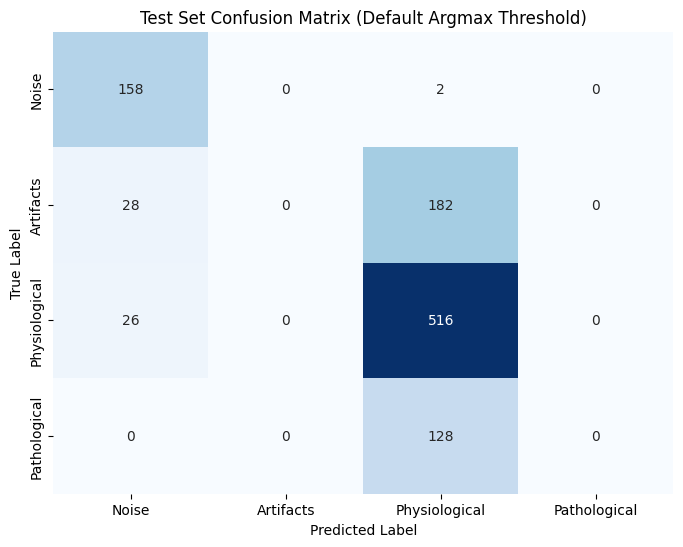

'\nprint("\n--- Zipping output directory for download ---")\ntry:\n    shutil.make_archive(\n        os.path.join(output_dir, \'tcn_output_artifacts\'), # Base name for the zip file\n        \'zip\',                                           # Archive format\n        output_dir                                       # Directory to archive\n    )\n    print(f"All output artifacts zipped to: {os.path.join(output_dir, \'tcn_output_artifacts.zip\')}")\n    print("You can download this file from your Kaggle kernel\'s output tab.")\nexcept Exception as e:\n    print(f"Error zipping output directory: {e}")\n'

In [16]:
# --- CONSOLIDATED IMPORTS ---
# Clean /kaggle/working/ at the start of every run
import os, shutil


working_dir = r"C:\DATA_EEG\TCN_output"

for filename in os.listdir(working_dir):
    file_path = os.path.join(working_dir, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)  # remove file or symlink
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)  # remove folder
    except Exception as e:
        print(f"Failed to delete {file_path}: {e}")
import os
import time
import json
import numpy as np
import h5py
import tensorflow as tf

# Configure GPU memory growth BEFORE any other TensorFlow operations
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")

import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
from datetime import datetime # Import datetime for unique timestamp
# TensorFlow Keras specific imports (part of tensorflow)
from tensorflow.keras import layers, metrics, Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, TensorBoard, ModelCheckpoint, ReduceLROnPlateau
# Scikit-learn metrics and utilities
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split
# Jupyter/Kaggle specific utility for clearing output
from IPython.display import clear_output
from functools import partial
strategy = tf.distribute.MirroredStrategy()

# ---------------------------
# Data Directories and Files
# ---------------------------
DATA_SAMPLE_PERCENTAGE = 0.05
epochs = 10
EARLY_STOPPING_MONITOR = 'val_loss'
EARLY_STOPPING_PATIENCE = 3 # Reduced patience for faster training completion

dataset_dir = r'C:\DATA_EEG\DatasetJoined'
output_dir = r'C:\DATA_EEG\TCN_output'
main_dataset_file = os.path.join(dataset_dir, 'dataset.h5')

# Define paths for saving artifacts
MODEL_SAVE_PATH = os.path.join(output_dir, 'tcn_model.keras') # Keras native format
HISTORY_SAVE_PATH = os.path.join(output_dir, 'training_history.json')
PLOTS_SAVE_DIR = output_dir
CLASS_WEIGHTS_SAVE_PATH = os.path.join(output_dir, 'class_weights.json')
OPTIMAL_THRESHOLD_SAVE_PATH = os.path.join(output_dir, 'optimal_f1_threshold.json')
CHECKPOINT_DIR = os.path.join(output_dir, 'checkpoints')

NUM_CLASSES = 4
INPUT_SEQUENCE_LENGTH = 15000 # Adjusted to user's specified length
batch_size = 16 # Reduced batch size to prevent OOM
ACCUMULATION_STEPS = 1 # Increased accumulation steps to maintain effective batch size
INITIAL_LEARNING_RATE = 2e-3 # Increased learning rate for faster convergence
L2_REGULARIZATION_LAMBDA = 1e-4

DILATED_CONV_FILTERS = 8 # Further reduced filters to save memory
DILATED_CONV_KERNEL_SIZE = 2
# Further reduced dilation rates for speed and memory
DILATED_CONV_DILATION_RATES = [1, 2, 4, 8, 16, 32] 


train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

AUGMENTATION_PROBABILITY = 0.0 # Data augmentation is now disabled
NOISE_AMPLITUDE = 0.01
SCALE_FACTOR_MIN = 0.98
SCALE_FACTOR_MAX = 1.005

INITIAL_DROPOUT_RATE = 0.005
MIN_DROPOUT_RATE = 0.001
MAX_DROPOUT_RATE = 0.7
DROPOUT_SCALING_FACTOR = 0.05
DROPOUT_BASELINE_GAP = 0.02

# NEW: Toggle for adaptive dropout
USE_ADAPTIVE_DROPOUT = False  # Set to False to disable adaptive dropout and use fixed rate

CLASS_NAMES = ["Noise", "Artifacts", "Physiological", "Pathological"]
PLOT_HISTORY_METRICS = ['loss', 'accuracy', 'auc', 'precision', 'recall', 'f1_score_macro']
PLOT_EVERY_N_BATCHES = 30000 # Further reduced plotting frequency to save memory

USE_FOCAL_LOSS = True
FOCAL_LOSS_GAMMA = 2.0

OPTIMIZE_THRESHOLD_ON_VALIDATION = True
THRESHOLD_SEARCH_STEPS = 50

# NEW: Control variable for dataset caching
USE_DATASET_CACHING = False # Disable caching to save memory
# Performance optimization flags
USE_GRADIENT_ACCUMULATION = False
USE_MIXED_PRECISION = True
VALIDATION_FREQUENCY = 1 # Validate every 3 epochs to save memory

print('done')

ENABLE_VISUALS = False

# ---------------------------
# Clear TensorFlow Dataset Caches (MORE ROBUST CLEANUP)
# ---------------------------
# Generate a unique timestamp for cache directories to avoid conflicts for new caches
unique_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

# Define paths for dataset caches with unique suffixes for *new* caches
# These paths will only be used if USE_DATASET_CACHING is True
train_cache_filepath = os.path.join(output_dir, f'train_dataset_cache_{unique_timestamp}')
val_cache_filepath = os.path.join(output_dir, f'val_dataset_cache_{unique_timestamp}')
test_cache_filepath = os.path.join(output_dir, f'test_dataset_cache_{unique_timestamp}')

print("\n--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---")
for item_name in os.listdir(output_dir):
    full_path = os.path.join(output_dir, item_name)
    
    # Check for directories that look like TF cache directories or any lockfiles
    if os.path.isdir(full_path) and ("_dataset_cache" in item_name or "dataset_cache" in item_name):
        try:
            shutil.rmtree(full_path)
            print(f"Removed old cache directory: {full_path}")
        except OSError as e:
            print(f"Error removing old cache directory {full_path}: {e}")
    # Check for any .lockfile
    elif item_name.endswith('.lockfile'):
        try:
            os.remove(full_path)
            print(f"Removed old cache lockfile: {full_path}")
        except OSError as e:
            print(f"Error removing old cache lockfile {full_path}: {e}")
print("--- Aggressive cleanup complete ---")

# ---------------------------
# TPU Detection and Strategy Initialization (Removed for local execution, still included for context)
# ---------------------------
# The following TPU setup is commented out as requested to avoid issues,
# but it's kept for reference if you ever return to TPU training.
# try:
#     tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
#     print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])
#     tf.config.experimental_connect_to_cluster(tpu)
#     tf.tpu.experimental.initialize_tpu_system(tpu)
#     strategy = tf.distribute.TPUStrategy(tpu)
# except ValueError:
#     print('Not running on TPU, trying to run on GPU or CPU...')
strategy = tf.distribute.get_strategy() # Default strategy for CPU and single GPU
print('Number of accelerators: {}'.format(strategy.num_replicas_in_sync))


# ---------------------------
# Custom Swish Activation Layer - NEW IMPLEMENTATION
# ---------------------------
class SwishActivation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SwishActivation, self).__init__(**kwargs)

    def call(self, x):
        """
        Implements the Swish activation function: x * sigmoid(x).
        This is now a proper Keras layer to ensure compatibility with KerasTensors.
        """
        return x * tf.sigmoid(x)

    def get_config(self):
        return super(SwishActivation, self).get_config()

# ---------------------------
# Custom F1-Score Metric (Macro Average)
# ---------------------------
class F1ScoreMacro(tf.keras.metrics.Metric):
    """
    Custom Keras Metric for calculating the Macro F1-Score for multi-class classification.
    This metric sums True Positives, False Positives, and False Negatives per class
    over batches and then calculates the F1-score for each class before averaging them.
    """
    def __init__(self, num_classes, name='f1_score_macro', **kwargs):
        super(F1ScoreMacro, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # Initialize internal variables for TP, FP, FN for each class
        # These are tf.Variable objects and will be reset by Keras when reset_states is called
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros', dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Cast inputs to the metric's dtype
        y_true = tf.cast(y_true, self.dtype)
        y_pred = tf.cast(y_pred, self.dtype)

        # Convert one-hot encoded labels to sparse (integer) labels for argmax
        y_true_labels = tf.argmax(y_true, axis=-1)
        y_pred_labels = tf.argmax(y_pred, axis=-1)

        # Create one-hot encoded versions of the predicted labels
        # This is essential for element-wise multiplication to count TP, FP, FNGx per class
        y_pred_one_hot = tf.one_hot(y_pred_labels, depth=self.num_classes, dtype=self.dtype)

        # Calculate True Positives (TP) per class: y_true == 1 AND y_pred == 1
        current_tp = tf.reduce_sum(y_true * y_pred_one_hot, axis=0)
        
        # Calculate False Positives (FP) per class: y_true == 0 AND y_pred == 1
        current_fp = tf.reduce_sum((1 - y_true) * y_pred_one_hot, axis=0)

        # Calculate False Negatives (FN) per class: y_true == 1 AND y_pred == 0
        current_fn = tf.reduce_sum(y_true * (1 - y_pred_one_hot), axis=0)
        
        # Assign values to the state variables
        self.tp.assign_add(current_tp)
        self.fp.assign_add(current_fp)
        self.fn.assign_add(current_fn)

    def result(self):
        # Add epsilon to denominators to prevent division by zero
        epsilon = tf.keras.backend.epsilon()
        
        # Calculate Precision per class
        precision_per_class = self.tp / (self.tp + self.fp + epsilon)
        
        # Calculate Recall per class
        recall_per_class = self.tp / (self.tp + self.fn + epsilon)

        # Calculate F1-score per class
        f1_per_class = 2 * (precision_per_class * recall_per_class) / (precision_per_class + recall_per_class + epsilon)

        # Macro F1-score is the unweighted average of F1-scores across all classes
        return tf.reduce_mean(f1_per_class)

    def reset_states(self):
        # Reset all internal variables to their initial (zero) state
        # The base class's reset_states calls this for each `self.add_weight` variable
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))

    def get_config(self):
        config = super(F1ScoreMacro, self).get_config()
        config.update({'num_classes': self.num_classes})
        return config

# ---------------------------
# 1. Enable GPU Usage and Optimizations
# ---------------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU.")

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')
start_time = time.time() # This is the global start_time we need

# ---------------------------
# Custom Focal Loss Function
# ---------------------------
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha_weights=None):
    """
    Custom implementation of Focal Loss for multi-class classification.
    Args:
        y_true (tf.Tensor): True labels (one-hot encoded).
        y_pred (tf.Tensor): Predicted probabilities (after softmax).
        gamma (float): Focusing parameter. Higher gamma reduces the loss for
                       well-classified examples, focusing on hard examples.
        alpha_weights (tf.Tensor or None): Class-specific weighting factor.
                                           If None, all classes are weighted equally.
                                           Should be a tensor of shape (NUM_CLASSES,).
    Returns:
        tf.Tensor: Computed focal loss.
    """
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon) # Clip to prevent log(0)
    # Calculate cross-entropy
    cross_entropy = -y_true * tf.math.log(y_pred)
    # Calculate p_t (probability of the true class)
    # y_true is one-hot, so y_true * y_pred gives 0 for incorrect classes and y_pred for true class
    p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
    # Calculate modulating factor (1 - p_t)^gamma
    modulating_factor = tf.pow(1.0 - p_t, gamma)
    # Apply alpha weights if provided
    if alpha_weights is not None:
        # Reshape alpha_weights to match y_true/y_pred for element-wise multiplication
        # alpha_weights should be (batch_size, NUM_CLASSES) if using y_true directly for indexing
        # Or (NUM_CLASSES,) for broadcastable multiplication
        alpha_factor = tf.reduce_sum(y_true * alpha_weights, axis=-1, keepdims=True)
        focal_loss = alpha_factor * modulating_factor * cross_entropy
    else:
        focal_loss = modulating_factor * cross_entropy
    return tf.reduce_sum(focal_loss, axis=-1) # Sum across classes for each sample

# --- IMPORTANT: Register your custom focal_loss_fn ---
# This makes Keras aware of your custom loss function by name, allowing it to be
# serialized correctly when you save your model.
tf.keras.utils.get_custom_objects().update({'focal_loss_fn': focal_loss_fn})


# ---------------------------
# HDF5 Generator (Modified for global shuffling)
# ---------------------------
def hdf5_generator(file_path, shuffled_keys_for_split):
    """
    A Python generator function to efficiently load and preprocess data
    from an HDF5 file based on a pre-shuffled list of keys.
    It yields normalized data tensors and one-hot encoded labels.
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
    Yields:
        tuple: A tuple containing:
            - tf.Tensor: The preprocessed data (normalized float32).
            - tf.Tensor: The integer label (int64).
    """
    # Open the HDF5 file once for the duration of the generator's existence
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str, file_name in shuffled_keys_for_split:
            dataset_key = f"{label_str}/{file_name}"
            if dataset_key not in hdf5_file:
                # print(f"Warning: Dataset key '{dataset_key}' not found in HDF5 file. Skipping.") # Uncomment for debugging
                continue
            try:
                # Load data, convert to float32, and normalize (Z-score)
                data = hdf5_file[dataset_key][:].astype(np.float32)
                data = (data - np.mean(data)) / (np.std(data) + 1e-8) # Add epsilon for stability
                int_label = int(label_str.split('_')[-1])
                # Yield data and label as TensorFlow tensors
                yield tf.convert_to_tensor(data.reshape((1, INPUT_SEQUENCE_LENGTH, 1)), dtype=tf.float32), \
                      tf.convert_to_tensor(np.array([int_label]), dtype=tf.int64)
            except Exception as e:
                print(f"HDF5 generator error for {dataset_key}: {e}. Skipping sample.")
                continue
    # The generator will exit when all keys in shuffled_keys_for_split have been processed.
    # The .repeat() on the dataset will then cause it to restart from the beginning of the shuffled keys.

# ---------------------------
# Preprocessing Functions
# ---------------------------
def reshape_input(x, y):
    """
    Reshapes the input tensor `x` by removing a singular dimension (axis=1).
    This is often needed when the generator yields data with an extra batch dimension.
    Args:
        x (tf.Tensor): The input data tensor.
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Reshaped x and original y.
    """
    return tf.squeeze(x, axis=1), y

def one_hot_encode_labels(x, y):
    """
    Converts integer labels `y` into one-hot encoded vectors.
    Args:
        x (tf.Tensor): The input data tensor.
        y (tf.Tensor): The integer label tensor.
    Returns:
        tuple: Original x and one-hot encoded y.
    """
    # Squeeze y to remove any singular dimensions before one-hot encoding
    y_one_hot = tf.one_hot(tf.squeeze(y, axis=-1), depth=NUM_CLASSES, dtype=tf.float32)
    return x, y_one_hot

# ---------------------------
# Data Augmentation Function (MODIFIED for 35% chance and wider range)
# ---------------------------
def apply_augmentation(x, y): # Removed probability parameter, now uses global AUGMENTATION_PROBABILITY
    """
    Adds random Gaussian noise and applies random amplitude scaling to the input
    time-series data with a given probability.
    Args:
        x (tf.Tensor): The input data tensor (time-series).
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Augmented x or original x, and original y.
    """
    def augment_true():
        # 1. Add Random Gaussian Noise
        noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=NOISE_AMPLITUDE, dtype=tf.float32)
        augmented_x = x + noise
        # 2. Random Amplitude Scaling
        scale_factor = tf.random.uniform(shape=[], minval=SCALE_FACTOR_MIN, maxval=SCALE_FACTOR_MAX, dtype=tf.float32)
        augmented_x = augmented_x * scale_factor
        return augmented_x

    def augment_false():
        return x # Return original x if augmentation is not applied

    # Generate a random uniform number
    rand_val = tf.random.uniform(shape=[], minval=0.0, maxval=1.0, dtype=tf.float32)
    # Conditionally apply augmentation based on the random number
    augmented_x = tf.cond(rand_val < AUGMENTATION_PROBABILITY, augment_true, augment_false)
    return augmented_x, y

# ---------------------------
# Dataset Creation (Modified for Caching and Parallelism)
# ---------------------------
def create_tf_dataset(file_path, batch_size, shuffled_keys_for_split, augment=False,
                      use_cache=USE_DATASET_CACHING, cache_filepath=None):
    """
    Creates a TensorFlow Dataset from the HDF5 generator, applying batching
    and preprocessing steps. Shuffling is handled by the pre-shuffled keys list.
    
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        batch_size (int): The number of samples per batch.
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
        augment (bool): Whether to apply data augmentation. Set to True for training data.
        use_cache (bool): If True, caches the dataset elements after the generator.
                          Now defaults to the global USE_DATASET_CACHING variable.
        cache_filepath (str, optional): Path to a file for disk caching. If None, caches in memory.
                                        Only used if use_cache is True.
    
    Returns:
        tf.data.Dataset: A configured TensorFlow Dataset ready for training/evaluation.
    """

    # Define conservative values
    # These can be tuned: start low, then increase if stable.
    # A common starting point is num_CPU_cores or a small integer.
    # For Kaggle with shared resources, even 2-4 might be better than AUTOTUNE if OOM.
    _fixed_num_parallel_calls = 2  # Or try 2, or tf.data.experimental.AUTOTUNE.num_cpu_cores if available
    _fixed_prefetch_buffer_size = 2  # Or 1, or tf.data.AUTOTUNE

    dataset = tf.data.Dataset.from_generator(
        lambda: hdf5_generator(file_path, shuffled_keys_for_split),
        output_signature=(
            tf.TensorSpec(shape=(1, INPUT_SEQUENCE_LENGTH, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(1,), dtype=tf.int64)
        )
    )

    if use_cache:
        if cache_filepath:
            print(f"Caching dataset to disk at: {cache_filepath}")
            dataset = dataset.cache(cache_filepath)
        else:
            print("Caching dataset in memory.")
            dataset = dataset.cache()

    dataset = dataset.batch(batch_size).repeat()

    if augment:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=_fixed_num_parallel_calls)

    dataset = dataset.map(reshape_input, num_parallel_calls=_fixed_num_parallel_calls)
    dataset = dataset.map(one_hot_encode_labels, num_parallel_calls=_fixed_num_parallel_calls)

    return dataset.prefetch(_fixed_prefetch_buffer_size)  # Use fixed prefetch size here


# ---------------------------
# Adaptive Dropout & Metric Logging Callback (MODIFIED FOR COMPOSITE SCORE)
# ---------------------------
class MetricsAndAdaptiveDropout(tf.keras.callbacks.Callback):
    """
    A custom Keras Callback that dynamically adjusts the dropout rate
    based on a composite score derived from multiple model performance metrics
    (validation accuracy, AUC, validation loss, and train/val accuracy gap).
    It also logs metrics to the console and passes dropout rate to a plotter.
    """
    def __init__(self, validation_data, verbose=0, initial_dropout=INITIAL_DROPOUT_RATE, min_dropout=MIN_DROPOUT_RATE, max_dropout=MAX_DROPOUT_RATE,
                     scaling_factor=DROPOUT_SCALING_FACTOR, baseline_gap=DROPOUT_BASELINE_GAP,
                     plotter_callback=None):
        super().__init__()
        self.validation_data_arg = validation_data
        self.verbose = verbose
        self.initial_dropout = initial_dropout
        self.min_dropout = min_dropout
        self.max_dropout = max_dropout
        self.scaling_factor = scaling_factor
        self.baseline_gap = baseline_gap # Used for the relative_gap component
        # Initialize previous values for metric comparison to calculate impact
        self.previous_val_acc = 0.0
        self.previous_auc = 0.0
        self.previous_val_loss = float('inf') # Start with a high loss
        self.current_dropout_rate = initial_dropout
        self.dropout_layer = None
        self.dropout_rate_history = []
        self.plotter_callback = plotter_callback

    def on_train_begin(self, logs=None):
        # Find the first dropout layer in the model to control its rate
        for layer in self.model.layers:
            # Check if the layer is a functional API layer or a sequential layer
            if hasattr(layer, 'layers'): # For functional API models, layers might be nested
                for sub_layer in layer.layers:
                    if isinstance(sub_layer, tf.keras.layers.Dropout):
                        self.dropout_layer = sub_layer
                        break
            if isinstance(layer, tf.keras.layers.Dropout): # For simple sequential models
                self.dropout_layer = layer
                break
        
        if self.dropout_layer is None:
            print("Warning: No Dropout layer found for AdaptiveDropout. Adaptive dropout will not function.")
        else:
            self.dropout_layer.rate = self.initial_dropout
            self.current_dropout_rate = self.initial_dropout
            if self.verbose > 0:
                print(f"Initial dropout rate set to: {self.initial_dropout:.4f}")
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)

    def on_epoch_end(self, epoch, logs=None):
        if self.dropout_layer is None:
            return
        logs = logs or {}
        train_acc = logs.get('accuracy', 0.0) # Training accuracy for relative gap
        val_acc = logs.get('val_accuracy', 0.0)
        auc = logs.get('val_auc', 0.0)
        val_loss = logs.get('val_loss', float('inf'))
        # Add a small epsilon to denominator to prevent division by zero
        relative_gap = (train_acc - val_acc) / max(train_acc, 1e-8) if train_acc > 0 else 0.0
        # Calculate the absolute difference first for clarity or reuse
        abs_val_acc_diff = abs(val_acc - self.previous_val_acc)
        # Now use it in the conditional assignment
        val_no_learn = abs_val_acc_diff if abs_val_acc_diff > 0.01 else 20
        # Calculate the impact of changes in metrics from the previous epoch
        # Positive impact value means metric is worsening (e.g., val_acc decreased, val_loss increased)
        # We want to increase dropout if performance worsens, so signs are chosen accordingly.
        val_acc_impact = (self.previous_val_acc - val_acc) * 1.5
        auc_impact = (self.previous_auc - auc) * 0.8
        val_loss_impact = (val_loss - self.previous_val_loss) * 1.0
        val_no_learn_impact = (val_no_learn)/25
        # Calculate the composite score
        composite_score = (
            val_acc_impact +
            auc_impact +
            val_loss_impact +
            (relative_gap - self.baseline_gap)+ # If relative gap is too high, this term increases score
            val_no_learn_impact
        )
        # Update dropout rate based on the composite score
        new_dropout = self.current_dropout_rate + (composite_score * self.scaling_factor)
        # Clip the new dropout rate within the defined min and max bounds
        new_dropout = min(max(new_dropout, self.min_dropout), self.max_dropout)
        # Update the dropout layer's rate
        self.dropout_layer.rate = new_dropout
        self.current_dropout_rate = new_dropout
        # Update previous metric values for the next epoch's calculation
        self.previous_val_acc = val_acc
        self.previous_auc = auc
        self.previous_val_loss = val_loss
        # Log the current dropout rate and update the plotter callback
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)
        if self.verbose > 0:
            print(f"\nEpoch {epoch+1}: Composite Score: {composite_score:.4f}, New Dropout Rate: {self.current_dropout_rate:.4f}")
            print(f"   (Val Acc: {val_acc:.4f}, AUC: {auc:.4f}, Val Loss: {val_loss:.4f}, Rel Gap: {relative_gap:.4f})")

    def get_config(self):
        config = super().get_config()
        config.update({
            'initial_dropout': float(self.initial_dropout),
            'min_dropout': float(self.min_dropout),
            'max_dropout': float(self.max_dropout),
            'scaling_factor': float(self.scaling_factor),
            'baseline_gap': float(self.baseline_gap),
        })
        return config

# ---------------------------
# Live Plotting Callback (Modified for batch-level plotting and separate saving)
# ---------------------------
class BatchMetricsPlotter(tf.keras.callbacks.Callback):
    """
    A Keras Callback for live plotting of training and validation metrics.
    Metrics are plotted per batch for training, and per epoch for validation.
    Includes Loss, Accuracy, AUC, Adaptive Dropout Rate, Precision, Recall, F1-Score, and Confusion Matrix.
    """
    def __init__(self, num_classes=NUM_CLASSES, val_dataset=None, validation_steps=None,
                     class_names=CLASS_NAMES, start_time=None, batch_size=None, steps_per_epoch=None, total_epochs=None,
                     plot_every_n_batches=PLOT_EVERY_N_BATCHES, train_dataset=None): # Added train_dataset
        super().__init__()
        self.batch_count = 0
        self.current_epoch = 0
        self.num_classes = num_classes
        self.val_dataset = val_dataset
        self.train_dataset = train_dataset # Store train_dataset
        self.validation_steps = validation_steps
        self.steps_per_epoch = steps_per_epoch # Also need steps_per_epoch for training CM
        self.class_names = class_names if class_names is not None else [str(i) for i in range(num_classes)]
        self.start_time = start_time if start_time is not None else time.time()
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.total_epochs = total_epochs
        self.plot_every_n_batches = plot_every_n_batches # Store the interval
        self.train_loss_history = []
        self.train_accuracy_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        self.val_auc_history = []
        self.dropout_rate_history = [] # To be populated by AdaptiveDropout callback
        self.val_precision_history = []
        self.val_recall_history = []
        self.val_f1_score_history = []
        self.confusion_matrix_history = []
        self.train_confusion_matrix_history = [] # New: for training confusion matrix
        plt.ion() # Enable interactive plotting

    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch + 1
        # NOT clearing train_confusion_matrix_history here as requested
        # self.train_confusion_matrix_history = [] # REMOVED THIS LINE
        # This means the last epoch's training CM will persist until the new epoch completes.

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.batch_count += 1
        self.train_loss_history.append(logs.get('loss', 0))
        self.train_accuracy_history.append(logs.get('accuracy', 0))
        # Plot only if it's time to plot
        if self.batch_count % self.plot_every_n_batches == 0:
            self._update_plot(is_batch_plot=True) # Pass flag to indicate batch plot

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.val_loss_history.append(logs.get('val_loss', 0))
        self.val_accuracy_history.append(logs.get('val_accuracy', 0))
        self.val_auc_history.append(logs.get('val_auc', 0))
        self.current_epoch = epoch + 1
        val_true_labels_epoch = []
        val_predicted_probs_epoch = []
        if self.model and self.val_dataset and self.validation_steps:
            val_data_iterator = iter(self.val_dataset)
            for _ in range(self.validation_steps):
                try:
                    val_x_batch, val_y_true_batch = next(val_data_iterator)
                    val_predicted_probs_batch = self.model.predict(val_x_batch, verbose=0)
                    val_true_labels_epoch.extend(tf.argmax(val_y_true_batch, axis=-1).numpy())
                    val_predicted_probs_epoch.extend(val_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Validation dataset exhausted prematurely during epoch end prediction.")
                    break
        if val_true_labels_epoch and val_predicted_probs_epoch:
            y_true_np = np.array(val_true_labels_epoch)
            y_pred_probs_np = np.array(val_predicted_probs_epoch)
            y_pred_classes_np = np.argmax(y_pred_probs_np, axis=-1)
            cm = confusion_matrix(y_true_np, y_pred_classes_np, labels=np.arange(self.num_classes))
            self.confusion_matrix_history.append(cm)
            macro_precision = precision_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_recall = recall_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_f1 = f1_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            self.val_precision_history.append(macro_precision)
            self.val_recall_history.append(macro_recall)
            self.val_f1_score_history.append(macro_f1)
        else:
            self.confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
            self.val_precision_history.append(0.0)
            self.val_recall_history.append(0.0)
            self.val_f1_score_history.append(0.0)
        # New: Collect data and generate confusion matrix for training dataset at epoch end
        train_true_labels_epoch = []
        train_predicted_probs_epoch = []
        if self.model and self.train_dataset and self.steps_per_epoch:
            # Create a temporary iterator for one full pass over the training data for CM
            train_data_iterator_cm = iter(self.train_dataset.unbatch().batch(self.batch_size).take(self.steps_per_epoch))
            for _ in range(self.steps_per_epoch):
                try:
                    train_x_batch, train_y_true_batch = next(train_data_iterator_cm)
                    train_predicted_probs_batch = self.model.predict(train_x_batch, verbose=0)
                    train_true_labels_epoch.extend(tf.argmax(train_y_true_batch, axis=-1).numpy())
                    train_predicted_probs_epoch.extend(train_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Training dataset exhausted prematurely during epoch end training CM prediction.")
                    break
        if train_true_labels_epoch and train_predicted_probs_epoch:
            train_y_true_np = np.array(train_true_labels_epoch)
            train_y_pred_probs_np = np.array(train_predicted_probs_epoch)
            train_y_pred_classes_np = np.argmax(train_y_pred_probs_np, axis=-1)
            train_cm = confusion_matrix(train_y_true_np, train_y_pred_classes_np, labels=np.arange(self.num_classes))
            self.train_confusion_matrix_history.append(train_cm)
        else:
            self.train_confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
        # Trigger a final plot update at the end of the epoch to show latest validation metrics
        self._update_plot(is_batch_plot=False) # Pass flag to indicate epoch plot

    def on_train_end(self, logs=None):
        # Save the final plot and individual subplots
        self._update_plot(final_save=True)
        plt.ioff() # Turn off interactive mode at the end of training
        plt.close('all') # Close all plot windows

    def log_dropout_rate(self, dropout_rate):
        """
        Method to receive and store the dropout rate from the AdaptiveDropout callback.
        """
        self.dropout_rate_history.append(dropout_rate)

    def _update_plot(self, is_batch_plot=True, final_save=False):
        """
        Clears the output and redraws the plot with 8 subplots (4x2 layout),
        showing batch-level training metrics, epoch-level validation metrics,
        adaptive dropout rate, and confusion matrix, along with a progress bar.
        If final_save is True, saves the plots to files.
        """
        if not final_save and not ENABLE_VISUALS:
            return
        if not final_save:
            clear_output(wait=True) # Clear previous plot output
            fig, axes = plt.subplots(4, 2, figsize=(18, 24)) # Increased height for 4 rows
            axes = axes.flatten() # Flatten for easier indexing
        else:
            # If final_save, we will create new figures for each plot
            pass # No need to create a multi-subplot figure for final save in this block

        # Calculate dynamic stats for the title
        elapsed_seconds = time.time() - self.start_time
        total_samples_processed = self.batch_count * self.batch_size if self.batch_size is not None else 0
        samples_per_second = total_samples_processed / elapsed_seconds if elapsed_seconds > 0 else 0
        
        # Format elapsed time
        el_h = int(elapsed_seconds // 3600)
        el_m = int((elapsed_seconds % 3600) // 60)
        el_s = int(elapsed_seconds % 60)
        elapsed_formatted = f'{el_h:02d}:{el_m:02d}:{el_s:02d}'
        
        # Calculate estimated remaining time (ETA)
        eta_str = ""
        if self.steps_per_epoch and self.total_epochs and self.batch_size and samples_per_second > 0:
            total_batches = self.steps_per_epoch * self.total_epochs
            batches_remaining = total_batches - self.batch_count
            if batches_remaining > 0:
                estimated_remaining_seconds = batches_remaining * self.batch_size / samples_per_second
                rem_h = int(estimated_remaining_seconds // 3600)
                rem_m = int((estimated_remaining_seconds % 3600) // 60)
                rem_s = int(estimated_remaining_seconds % 60)
                eta_str = f', ETA: {rem_h:02d}:{rem_m:02d}:{rem_s:02d}'
            else:
                eta_str = ', ETA: 00:00:00'
        
        current_batch_in_epoch = (self.batch_count - 1) % self.steps_per_epoch + 1
        plot_title_suffix = f'Epoch {self.current_epoch}/{self.total_epochs}, Batch {current_batch_in_epoch}/{self.steps_per_epoch}\nElapsed: {elapsed_formatted}{eta_str}, Throughput: {samples_per_second:.2f} samples/s'

        # Function to plot and save a single subplot
        def plot_and_save_single(fig_idx, filename_base, title_suffix, plot_data_fn):
            fig, ax = plt.subplots(figsize=(9, 6)) # Adjust size as needed
            plot_data_fn(ax) # Call the function to populate the plot
            ax.set_title(f'{filename_base.replace("_", " ").title()} ({title_suffix})')
            plt.savefig(os.path.join(PLOTS_SAVE_DIR, f'{filename_base}.png'), bbox_inches='tight')
            plt.close(fig) # Close the figure to free memory
            print(f"Plot saved: {filename_base}.png")


        # --- Plotting logic for real-time display ---
        if not final_save:
            fig.suptitle(f'Live Training Metrics - {plot_title_suffix}', fontsize=20)
            
            # Plot 1: Loss
            axes[0].plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8)
            if self.val_loss_history:
                val_x = np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch
                axes[0].plot(val_x, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
            axes[0].set_title('Loss')
            axes[0].set_xlabel('Batches')
            axes[0].set_ylabel('Loss')
            axes[0].legend()
            axes[0].grid(True)
            
            # Plot 2: Accuracy
            axes[1].plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8)
            if self.val_accuracy_history:
                val_x = np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch
                axes[1].plot(val_x, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
            axes[1].set_title('Accuracy')
            axes[1].set_xlabel('Batches')
            axes[1].set_ylabel('Accuracy')
            axes[1].legend()
            axes[1].grid(True)
            
            # Plot 3: Validation AUC (Epoch-level)
            if self.val_auc_history:
                axes[2].plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4)
                axes[2].set_title('Validation AUC')
                axes[2].set_xlabel('Epoch')
                axes[2].set_ylabel('AUC')
                axes[2].legend()
                axes[2].grid(True)
            else:
                axes[2].set_title('Validation AUC (Epoch-End Only)')
                axes[2].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)
            
            # Plot 4: Adaptive Dropout Rate (Epoch-level)
            if self.dropout_rate_history:
                axes[3].plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4)
                axes[3].set_title('Adaptive Dropout Rate')
                axes[3].set_xlabel('Epoch')
                axes[3].set_ylabel('Dropout Rate')
                axes[3].legend()
                axes[3].grid(True)
            else:
                axes[3].set_title('Adaptive Dropout Rate (Fixed or Disabled)')
                axes[3].text(0.5, 0.5, f'Fixed Rate: {INITIAL_DROPOUT_RATE:.4f}\n(Adaptive Disabled)' if not USE_ADAPTIVE_DROPOUT else 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[3].transAxes)
            
            # Plot 5: Precision, Recall, F1-Score (Epoch-level)
            if self.val_precision_history:
                axes[4].plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4)
                axes[4].plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4)
                axes[4].plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4)
                axes[4].set_title('Validation Precision, Recall, F1-Score (Macro)')
                axes[4].set_xlabel('Epoch')
                axes[4].set_ylabel('Score')
                axes[4].legend()
                axes[4].grid(True)
            else:
                axes[4].set_title('Validation PRF1 (Epoch-End Only)')
                axes[4].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[4].transAxes)
            
            # Plot 6: Validation Confusion Matrix (Latest Epoch)
            if self.confusion_matrix_history:
                latest_cm = self.confusion_matrix_history[-1]
                sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[5],
                            xticklabels=self.class_names, yticklabels=self.class_names)
                axes[5].set_title(f'Validation Confusion Matrix (Epoch {self.current_epoch})')
                axes[5].set_xlabel('Predicted Label')
                axes[5].set_ylabel('True Label')
            else:
                axes[5].set_title('Validation Confusion Matrix (Epoch-End Only)')
                axes[5].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[5].transAxes)
            
            # Plot 7: Training Confusion Matrix (Latest Epoch)
            if self.train_confusion_matrix_history:
                latest_train_cm = self.train_confusion_matrix_history[-1]
                sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[6],
                            xticklabels=self.class_names, yticklabels=self.class_names)
                axes[6].set_title(f'Training Confusion Matrix (Epoch {self.current_epoch})')
                axes[6].set_xlabel('Predicted Label')
                axes[6].set_ylabel('True Label')
            else:
                axes[6].set_title('Training Confusion Matrix (Epoch-End Only)')
                axes[6].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[6].transAxes)
            
            # Plot 8: Placeholder for additional info
            axes[7].set_title('Additional Info Plot (Placeholder)')
            axes[7].text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                                 horizontalalignment='center', verticalalignment='center', transform=axes[7].transAxes)
            axes[7].set_xticks([])
            axes[7].set_yticks([])
            axes[7].grid(False)
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.94]) # Adjust layout to prevent title overlap
            plt.show()

        else: # Final Save Logic: Create new figures for each plot and save them separately
            print("\n--- Saving Individual Plots ---")

            # Plot 1: Loss
            if self.train_loss_history or self.val_loss_history:
                plot_and_save_single(
                    1, 'final_loss_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8),
                        (ax.plot(np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4) if self.val_loss_history else None),
                        ax.set_xlabel('Batches'), ax.set_ylabel('Loss'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 2: Accuracy
            if self.train_accuracy_history or self.val_accuracy_history:
                plot_and_save_single(
                    2, 'final_accuracy_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8),
                        (ax.plot(np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4) if self.val_accuracy_history else None),
                        ax.set_xlabel('Batches'), ax.set_ylabel('Accuracy'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 3: Validation AUC
            if self.val_auc_history:
                plot_and_save_single(
                    3, 'final_val_auc_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('AUC'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 4: Adaptive Dropout Rate
            if self.dropout_rate_history:
                plot_and_save_single(
                    4, 'final_dropout_rate_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Dropout Rate'), ax.legend(), ax.grid(True)
                    )
                )
            else:
                # Save a plot indicating fixed dropout
                plot_and_save_single(
                    4, 'final_dropout_rate_plot', plot_title_suffix,
                    lambda ax: (
                        ax.text(0.5, 0.5, f'Fixed Dropout Rate: {INITIAL_DROPOUT_RATE:.4f}\n(Adaptive Dropout Disabled)', 
                                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes,
                                fontsize=14),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Dropout Rate'), ax.set_title('Fixed Dropout Rate'),
                        ax.grid(True)
                    )
                )

            # Plot 5: Precision, Recall, F1-Score
            if self.val_precision_history:
                plot_and_save_single(
                    5, 'final_val_prf1_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4),
                        ax.plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4),
                        ax.plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Score'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 6: Validation Confusion Matrix (Latest Epoch)
            if self.confusion_matrix_history:
                latest_cm = self.confusion_matrix_history[-1]
                plot_and_save_single(
                    6, 'final_val_confusion_matrix', f'Epoch {self.current_epoch}',
                    lambda ax: sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                                           xticklabels=self.class_names, yticklabels=self.class_names)
                )
                
            # Plot 7: Training Confusion Matrix (Latest Epoch)
            if self.train_confusion_matrix_history:
                latest_train_cm = self.train_confusion_matrix_history[-1]
                plot_and_save_single(
                    7, 'final_train_confusion_matrix', f'Epoch {self.current_epoch}',
                    lambda ax: sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax,
                                           xticklabels=self.class_names, yticklabels=self.class_names)
                )

            # Plot 8: Placeholder for additional info
            plot_and_save_single(
                8, 'final_additional_info_plot', plot_title_suffix,
                lambda ax: (
                    ax.text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                             horizontalalignment='center', verticalalignment='center', transform=ax.transAxes),
                    ax.set_xticks([]), ax.set_yticks([]), ax.grid(False)
                )
            )

# Helper Function to Get All Sample Keys (for global shuffling)
def _get_all_sample_keys(file_path, sample_percentage=1.0):
    """
    Reads all (label_str, file_name) tuples from an HDF5 file,
    then randomly samples a specified percentage of these keys.
    This reads only the keys/metadata, not the full data, to minimize memory usage.
    Args:
        file_path (str): The path to the main HDF5 file.
        sample_percentage (float): The percentage of total samples to use (e.g., 0.1 for 10%).
                                   Must be between 0.0 and 1.0.
    Returns:
        list: A randomly sampled and shuffled list of (label_str, file_name) tuples.
    """
    all_keys = []
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Main dataset file not found: {file_path}")
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str in hdf5_file.keys(): # Iterate directly over top-level groups (labels)
            for file_name in hdf5_file[label_str].keys(): # Iterate over datasets (files) within each label group
                all_keys.append((label_str, file_name))
    num_total_samples = len(all_keys)
    num_samples_to_keep = int(num_total_samples * sample_percentage)
    if num_samples_to_keep == 0 and num_total_samples > 0:
        print(f"Warning: sample_percentage {sample_percentage*100}% results in 0 samples. Keeping at least 1 if available.")
        num_samples_to_keep = 1 if num_total_samples > 0 else 0
    elif num_samples_to_keep > num_total_samples:
        print(f"Warning: sample_percentage {sample_percentage*100}% is greater than 100%. Using all {num_total_samples} samples.")
        num_samples_to_keep = num_total_samples
    if num_samples_to_keep > 0:
        sampled_keys = random.sample(all_keys, num_samples_to_keep)
    else:
        sampled_keys = []
    random.shuffle(sampled_keys)
    return sampled_keys

# Function to get class distribution from a list of (label_str, filename) keys
def get_class_distribution_from_keys(keys_list, num_classes):
    counts = np.zeros(num_classes, dtype=int)
    for label_str, _ in keys_list:
        try:
            int_label = int(label_str.split('_')[-1])
            if 0 <= int_label < num_classes:
                counts[int_label] += 1
            else:
                print(f"Warning: Class label {int_label} out of expected range [0, {num_classes-1}]. Skipping.")
        except ValueError:
            print(f"Warning: Could not parse label string '{label_str}' to an integer. Skipping.")
    return counts

# Function to find optimal F1-score threshold for multi-class classification
def find_optimal_f1_threshold(dataset_with_preds_and_labels, num_classes, threshold_steps=100):
    """
    Finds the optimal probability threshold that maximizes the macro F1-score
    for multi-class classification. This threshold is applied to the highest
    predicted probability for each sample. Samples with max_prob below the threshold
    are effectively treated as "unclassified" for F1 calculation.
    Args:
        dataset_with_preds_and_labels (tf.data.Dataset): A dataset yielding (predicted_probabilities, true_labels).
        num_classes (int): The number of output classes.
        threshold_steps (int): Number of thresholds to check between 0.01 and 0.99.
    Returns:
        tuple: (optimal_threshold, best_f1_score)
    """
    all_true_labels = []
    all_predicted_probs = []
    # Get true labels and predicted probabilities from the dataset
    # Add .batch(batch_size) to ensure iteration yields batches, not single elements
    for y_pred_probs_batch, y_true_batch in dataset_with_preds_and_labels.batch(batch_size):
        all_true_labels.extend(y_true_batch.numpy())
        all_predicted_probs.extend(y_pred_probs_batch.numpy())

    if not all_true_labels:
        print("Warning: No data found in the dataset for optimal threshold search.")
        return 0.0, 0.0

    y_true_np = np.array(all_true_labels)
    y_pred_probs_np = np.array(all_predicted_probs)
    thresholds = np.linspace(0.01, 0.99, threshold_steps) # Avoid 0 and 1 for practical reasons
    best_f1 = -1
    optimal_threshold = 0.0
    print(f"\nSearching for optimal F1-score threshold on {len(all_true_labels)} samples...")

    for t in thresholds:
        # Get the predicted class for each sample (argmax)
        predicted_classes_at_t = np.argmax(y_pred_probs_np, axis=-1)
        # Get the maximum probability for each sample
        max_probs = np.max(y_pred_probs_np, axis=-1)
        # Create a mask for confident predictions (max_prob >= threshold)
        confident_mask = max_probs >= t
        # Filter true labels and predictions based on confidence
        y_true_filtered = y_true_np[confident_mask]
        y_pred_filtered = predicted_classes_at_t[confident_mask]

        if len(y_true_filtered) > 0:
            # Calculate macro F1-score only for confident predictions
            current_f1 = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
            if current_f1 > best_f1:
                best_f1 = current_f1
                optimal_threshold = t
        # else: if no confident predictions, F1 remains -1 (or 0)

    print(f"Optimal Threshold Found: {optimal_threshold:.4f} with Macro F1-score: {best_f1:.4f}")
    return optimal_threshold, best_f1


# ---------------------------
# Define TCN (Temporal Convolutional Network) Model (Functional API)
# ---------------------------
def create_tcn_model(input_shape, num_classes, initial_dropout_rate, l2_lambda,
                     tcn_filters, tcn_kernel_size, tcn_dilation_rates, tcn_num_blocks=2):
    """
    Creates a TCN (Temporal Convolutional Network) model using the Keras Functional API.
    
    TCN Architecture:
    - Multiple TCN blocks, each containing multiple dilated causal convolutions
    - Each TCN block has residual connections
    - Batch normalization and dropout within each block
    - Global average pooling for final classification
    
    Args:
        input_shape: Input shape tuple
        num_classes: Number of output classes
        initial_dropout_rate: Initial dropout rate
        l2_lambda: L2 regularization factor
        tcn_filters: Number of filters for TCN convolutions
        tcn_kernel_size: Kernel size for TCN convolutions
        tcn_dilation_rates: List of dilation rates for each TCN block
        tcn_num_blocks: Number of TCN blocks (default: 2)
    """
    l2_regularizer = tf.keras.regularizers.l2(l2_lambda)

    input_layer = tf.keras.layers.Input(shape=input_shape, name='input_sequence')
    
    # Initial Batch Normalization
    x = tf.keras.layers.BatchNormalization(name='input_batchnorm')(input_layer)

    # Initial 1x1 convolution to expand feature dimension
    if input_shape[-1] != tcn_filters:
        x = tf.keras.layers.Conv1D(filters=tcn_filters, kernel_size=1, padding='causal',
                          kernel_regularizer=l2_regularizer, name='initial_projection')(x)

    current_layer = x
    tcn_layers_info = [] # To store info for printing hyperparameters

    # Build TCN blocks
    for block_idx in range(tcn_num_blocks):
        # Store the input to this TCN block
        block_input = current_layer
        
        # Each TCN block contains multiple dilated convolutions
        for i, dilation_rate in enumerate(tcn_dilation_rates):
            # First dilated convolution in the block
            x_conv1 = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv1_{i+1}_rate{dilation_rate}')(current_layer)
            
            # Batch normalization
            x_norm1 = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn1_{i+1}_rate{dilation_rate}')(x_conv1)
            
            # Swish activation
            x_activated1 = SwishActivation()(x_norm1)
            
            # Dropout
            if initial_dropout_rate > 0:
                x_dropout1 = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout1_{i+1}_rate{dilation_rate}')(x_activated1)
            else:
                x_dropout1 = x_activated1
            
            # Second dilated convolution in the block
            x_conv2 = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv2_{i+1}_rate{dilation_rate}')(x_dropout1)
            
            # Batch normalization
            x_norm2 = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn2_{i+1}_rate{dilation_rate}')(x_conv2)
            
            # Swish activation
            x_activated2 = SwishActivation()(x_norm2)
            
            # Dropout
            if initial_dropout_rate > 0:
                x_dropout2 = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout2_{i+1}_rate{dilation_rate}')(x_activated2)
            else:
                x_dropout2 = x_activated2
            
            # Residual connection: Add input to this layer to the output
            # Only add residual if the dimensions match
            if i == 0:  # First layer in the block
                current_layer = x_dropout2
            else:
                current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_residual_{i+1}_rate{dilation_rate}')([current_layer, x_dropout2])
            
            # Store info for printing hyperparameters
            tcn_layers_info.append({
                'block': block_idx + 1,
                'layer_in_block': i + 1,
                'layer_name': f'tcn_block{block_idx+1}_conv1_{i+1}_rate{dilation_rate}',
                'filters': tcn_filters,
                'kernel_size': tcn_kernel_size,
                'padding': 'causal',
                'activation': 'swish_activation',
                'dilation_rate': dilation_rate,
                'l2_regularization': l2_lambda,
                'initial_dropout_rate': initial_dropout_rate
            })
        
        # TCN block residual connection: Add block input to block output
        # Only if dimensions match (they should since we're using the same filters)
        if block_idx > 0:  # Skip for first block
            current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_block_residual')([block_input, current_layer])

    # Final output layers
    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D(name='global_average_pooling')(current_layer)
    
    # Dense layers for classification
    x = tf.keras.layers.Dense(tcn_filters, activation='relu', 
                     kernel_regularizer=l2_regularizer, name='dense1')(x)
    
    if initial_dropout_rate > 0:
        x = tf.keras.layers.Dropout(initial_dropout_rate, name='final_dropout')(x)
    
    x = tf.keras.layers.Dense(tcn_filters // 2, activation='relu',
                     kernel_regularizer=l2_regularizer, name='dense2')(x)
    
    # Final classification layer
    output_layer = tf.keras.layers.Dense(num_classes, activation='softmax', 
                               dtype='float32', name='softmax_output')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='TCN_Model')
    return model, tcn_layers_info

# --- Main Script Execution ---
# Get a sampled subset of all keys and shuffle them globally
print(f"\n--- Loading and Randomly Sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% of All Samples from {main_dataset_file} ---")
all_shuffled_and_sampled_keys = _get_all_sample_keys(main_dataset_file, sample_percentage=DATA_SAMPLE_PERCENTAGE)
total_samples_after_sampling = len(all_shuffled_and_sampled_keys)
if total_samples_after_sampling == 0:
    raise ValueError(f"No samples found after sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% from {main_dataset_file}. Please ensure it is correctly populated or adjust the sampling percentage.")

# Calculate split sizes based on the *sampled* total
num_train = int(train_ratio * total_samples_after_sampling)
num_val = int(val_ratio * total_samples_after_sampling)
num_test = total_samples_after_sampling - num_train - num_val
print(f"Total samples after sampling: {total_samples_after_sampling}")
print(f"Splitting into: Train={num_train}, Val={num_val}, Test={num_test}")

# Calculated steps:
steps_per_epoch = max(num_train // batch_size, 1)
validation_steps = max(num_val // batch_size, 1)
test_steps = max(num_test // batch_size, 1)
print(f"\nCalculated steps:")
print(f"Train samples: {num_train}, Steps per epoch: {steps_per_epoch}")
print(f"Validation samples: {num_val}, Validation steps: {validation_steps}")
print(f"Test samples: {num_test}, Test steps: {test_steps}")

# Slice the globally sampled and shuffled keys for each split
train_keys = all_shuffled_and_sampled_keys[:num_train]
val_keys = all_shuffled_and_sampled_keys[num_train : num_train + num_val]
test_keys = all_shuffled_and_sampled_keys[num_train + num_val :]

# Print class distributions for the new splits
print("\n--- Class Distribution in New Sampled Splits ---")
train_class_counts = get_class_distribution_from_keys(train_keys, NUM_CLASSES)
val_class_counts = get_class_distribution_from_keys(val_keys, NUM_CLASSES)
test_class_counts = get_class_distribution_from_keys(test_keys, NUM_CLASSES)
print(f"Train Class Counts: {train_class_counts}")
print(f"Validation Class Counts: {val_class_counts}")
print(f"Test Class Counts: {test_class_counts}")
print("------------------------------------")

# Calculate Class Weights for Imbalanced Dataset
print("\n--- Calculating Class Weights for Training Data ---")
class_weights = {}
total_train_samples = num_train
if total_train_samples > 0:
    for i in range(NUM_CLASSES):
        count = train_class_counts[i]
        if count > 0:
            class_weights[i] = total_train_samples / (NUM_CLASSES * count)
        else:
            class_weights[i] = 1.0 # Assign 1.0 if class count is zero to avoid division by zero
    print("Calculated Class Weights:")
    for cls, weight in class_weights.items():
        print(f"   Class {cls}: {weight:.4f}")
else:
    print("No training samples available, cannot calculate class weights.")
    class_weights = None
print("--------------------------------------------------")

# ---------------------------
# Create TensorFlow Datasets (using globally shuffled keys and WITH augmentation for training)
# ---------------------------
# Caching strategy:
# For train_dataset, caching is generally good. If the dataset fits in memory, it will be very fast.
# If not, disk caching (by providing a file path) can still be beneficial.
# For val_dataset and test_dataset, caching is almost always recommended as they are iterated multiple times.
# You can set `use_cache=False` for any dataset if you find it's consuming too much memory/disk.

# Use the newly defined unique cache file paths, and control caching with USE_DATASET_CACHING
train_dataset = create_tf_dataset(main_dataset_file, batch_size, train_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=train_cache_filepath)
val_dataset = create_tf_dataset(main_dataset_file, batch_size, val_keys, augment=False, use_cache=False, cache_filepath=val_cache_filepath)
test_dataset = create_tf_dataset(main_dataset_file, batch_size, test_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=test_cache_filepath)

# --- INSERTED CODE SNIPPET FOR CLASS CLUSTERING CHECK ---
print("\n--- Checking for Class Clustering within Batches ---")
# Number of batches to inspect
num_batches_to_check = 5
# If one class makes up this percentage of the batch, consider it "highly clustered"
clustering_threshold_percent = 90.0 # e.g., 90% of 16 samples = 14.4, so 15 or 16 samples
# Get an iterator for the dataset (using val_dataset as an example)
dataset_to_check = val_dataset
# To avoid exhausting the dataset for actual training, we'll create a temporary iterator
# and limit it to a few batches.
dataset_iterator_for_check = iter(dataset_to_check)
clustered_batches_count = 0
total_batches_checked = 0
for i in range(num_batches_to_check):
    try:
        total_batches_checked += 1
        # Get the next batch of data and one-hot encoded labels
        # Note: dataset_to_check.take(1) creates a new dataset with 1 batch.
        # We need to iterate over the actual batched dataset to get the full batch.
        x_batch, y_true_batch_one_hot = next(dataset_iterator_for_check)
        # Convert one-hot labels to integer labels
        y_true_batch_int = tf.argmax(y_true_batch_one_hot, axis=-1).numpy()
        actual_batch_size = len(y_true_batch_int)
        if actual_batch_size == 0:
            print(f"Batch {i+1} was empty. Skipping.")
            continue
        # Find unique classes in the batch and their counts
        unique_classes_in_batch, counts_of_classes = np.unique(y_true_batch_int, return_counts=True)
        print(f"\nBatch {i+1} (Actual Size: {actual_batch_size}):")
        print(f"   Classes present: {unique_classes_in_batch}")
        print(f"   Counts per class: {counts_of_classes}")
        is_clustered_flag = False
        if len(unique_classes_in_batch) == 1:
            # If there's only one unique class, the batch is perfectly clustered
            is_clustered_flag = True
            print(f"   -> Result: This batch is PERFECTLY CLUSTERED (all samples are class {unique_classes_in_batch[0]})")
            clustered_batches_count += 1
        else:
            # Check if one class makes up a significant majority of the batch
            max_count_in_batch = np.max(counts_of_classes)
            dominant_class_index = np.argmax(counts_of_classes)
            dominant_class_label = unique_classes_in_batch[dominant_class_index]
            dominance_percentage = (max_count_in_batch / actual_batch_size) * 100
            if dominance_percentage >= clustering_threshold_percent:
                is_clustered_flag = True
                print(f"   -> Result: This batch is HIGHLY CLUSTERED (Class {dominant_class_label} makes up {dominance_percentage:.2f}% of the batch)")
                clustered_batches_count += 1
            else:
                print(f"   -> Result: This batch appears WELL-MIXED (Max class dominance: {dominance_percentage:.2f}%)")
    except tf.errors.OutOfRangeError:
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except StopIteration: # Also catch StopIteration for direct generator-like datasets
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except Exception as e:
        print(f"An error occurred while processing batch {i+1}: {e}")
        break

print(f"\n--- Summary of Batch Clustering Check ---")
if total_batches_checked > 0:
    clustered_percentage = (clustered_batches_count / total_batches_checked) * 100
    print(f"{clustered_batches_count} out of {total_batches_checked} batches ({clustered_percentage:.2f}%) were found to be perfectly or highly clustered (>{clustering_threshold_percent:.0f}% dominance).")
    if clustered_percentage > 50: # You can adjust this threshold for concern
        print("Recommendation: A high percentage of clustered batches might indicate that your global shuffling (random.shuffle of keys, and/or dataset.shuffle buffer size) is not optimally mixing classes within batches. If you desire better intra-batch class diversity, consider increasing the `shuffle` buffer size in your `tf.data.Dataset` pipeline, or verifying the global key shuffling step.")
    else:
        print("This indicates that batches are generally well-mixed, which is expected for effective global shuffling and diverse batches.")
else:
    print("No batches were checked. Please ensure your dataset is correctly loaded and contains data.")


# ---------------------------
# Clear Keras Session before model creation
# ---------------------------
tf.keras.backend.clear_session()
print("\n--- Keras backend session cleared ---")

# ---------------------------
# 4. Define and Compile TCN Model (MODIFIED for Custom Focal Loss)
# ---------------------------
tcn_model, tcn_layers_info = create_tcn_model(
    input_shape=(INPUT_SEQUENCE_LENGTH, 1),
    num_classes=NUM_CLASSES,
    initial_dropout_rate=INITIAL_DROPOUT_RATE if not USE_ADAPTIVE_DROPOUT else INITIAL_DROPOUT_RATE,
    l2_lambda=L2_REGULARIZATION_LAMBDA,
    tcn_filters=DILATED_CONV_FILTERS,  # Reuse the same filter count
    tcn_kernel_size=DILATED_CONV_KERNEL_SIZE,  # Reuse the same kernel size
    tcn_dilation_rates=DILATED_CONV_DILATION_RATES,  # Reuse the same dilation rates
    tcn_num_blocks=2  # Number of TCN blocks
)

# Determine which loss function to use
if USE_FOCAL_LOSS:
    print(f"\n--- Using Custom Focal Loss (gamma={FOCAL_LOSS_GAMMA}, alpha from class_weights) ---")
    
    # Ensure class_weights is not None before converting for alpha parameter
    if class_weights is not None:
        focal_loss_alpha_tensor = tf.constant(
            [float(class_weights.get(str(i), 1.0)) for i in range(NUM_CLASSES)], # Safely convert dict keys to strings
            dtype=tf.float32
        )
    else:
        focal_loss_alpha_tensor = tf.constant([1.0 for _ in range(NUM_CLASSES)], dtype=tf.float32)
        print("Warning: class_weights is None, using uniform alpha for Focal Loss.")
    
    # Use functools.partial to create a named callable for your loss function
    # that accepts only y_true and y_pred, while 'gamma' and 'alpha_weights' are fixed.
    model_loss = partial(focal_loss_fn, gamma=FOCAL_LOSS_GAMMA, alpha_weights=focal_loss_alpha_tensor)
    
    # Explicitly set the __name__ attribute so Keras can correctly serialize it.
    # This name must match the key used in tf.keras.utils.get_custom_objects().update()
    model_loss.__name__ = 'focal_loss_fn' 
    
    fit_class_weight = None # When using custom loss with built-in weighting, typically don't use model.fit's class_weight
else:
    print("\n--- Using Categorical Crossentropy Loss ---")
    model_loss = 'categorical_crossentropy'
    fit_class_weight = class_weights # Pass class weights to model.fit for standard CE


tcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
    loss=model_loss,
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1ScoreMacro(num_classes=NUM_CLASSES, name='f1_score_macro'), # USING CUSTOM F1ScoreMacro
    ]
)
print("\n--- Model Summary ---")
tcn_model.summary()
print("---------------------")

# ---------------------------
# Callbacks
# ---------------------------
# Re-define these variables here defensively in case of Kaggle execution quirks
EARLY_STOPPING_MONITOR = 'val_loss'
plot_every_n_batches = PLOT_EVERY_N_BATCHES # Re-define plot_every_n_batches defensively

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor=EARLY_STOPPING_MONITOR,
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

# Initialize plotter callback
plotter_callback = BatchMetricsPlotter(
    num_classes=NUM_CLASSES,
    val_dataset=val_dataset,
    validation_steps=validation_steps,
    class_names=CLASS_NAMES,
    start_time=start_time,
    batch_size=batch_size,
    steps_per_epoch=steps_per_epoch,
    total_epochs=epochs,
    plot_every_n_batches=plot_every_n_batches, # Corrected to 'plot_every_n_batches'
    train_dataset=train_dataset # Pass the training dataset to the plotter
)

# Conditionally initialize adaptive dropout callback
adaptive_dropout_callback = None
if USE_ADAPTIVE_DROPOUT:
    adaptive_dropout_callback = MetricsAndAdaptiveDropout(
        validation_data=val_dataset,
        verbose=1,
        initial_dropout=INITIAL_DROPOUT_RATE,
        min_dropout=MIN_DROPOUT_RATE,
        max_dropout=MAX_DROPOUT_RATE,
        scaling_factor=DROPOUT_SCALING_FACTOR,
        baseline_gap=DROPOUT_BASELINE_GAP,
        plotter_callback=plotter_callback # Pass the plotter callback here
    )
    print(f"\n--- Adaptive Dropout Enabled (Initial Rate: {INITIAL_DROPOUT_RATE:.4f}) ---")
else:
    print(f"\n--- Adaptive Dropout Disabled (Using Fixed Rate: {INITIAL_DROPOUT_RATE:.4f}) ---")

# Build callbacks list
callbacks = [
    early_stopping_callback,
    plotter_callback,
]
if USE_ADAPTIVE_DROPOUT:
    callbacks.insert(1, adaptive_dropout_callback)  # Insert before plotter

# ---------------------------
# Training the Model
# ---------------------------
print("\n--- Starting Model Training ---")
history = tcn_model.fit(
    train_dataset,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=fit_class_weight, # Use fit_class_weight determined by USE_FOCAL_LOSS
    verbose=0 if ENABLE_VISUALS else 1
)
print("\n--- Model Training Complete ---")

# Initialize optimal_threshold_f1 and best_f1_on_val before potential use
optimal_threshold_f1 = 0.0
best_f1_on_val = 0.0

# ---------------------------
# Save Model and Training Artifacts
# ---------------------------
print("\n--- Saving Model and Training Artifacts ---")
try:
    tcn_model.save(MODEL_SAVE_PATH)
    print(f"Model saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Error saving model: {e}")

try:
    # Convert lists of numpy floats to lists of standard Python floats for JSON serialization.
    serializable_history = {}
    for key, values in history.history.items(): # Use history.history for built-in fit
        serializable_history[key] = [float(v) for v in values]

    with open(HISTORY_SAVE_PATH, 'w') as f:
        json.dump(serializable_history, f, indent=4)
    print(f"Training history saved to: {HISTORY_SAVE_PATH}")
except Exception as e:
    print(f"Error saving training history: {e}")

try:
    with open(CLASS_WEIGHTS_SAVE_PATH, 'w') as f:
        # Convert numpy int64 keys to string and values to standard Python floats for JSON serialization.
        serializable_class_weights = {str(k): float(v) for k, v in class_weights.items()}
        json.dump(serializable_class_weights, f, indent=4)
    print(f"Class weights saved to: {CLASS_WEIGHTS_SAVE_PATH}")
except Exception as e:
    print(f"Error saving class weights: {e}")

if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    
optimal_f1_data = {
    'optimal_threshold': float(optimal_threshold_f1),
    'best_f1_on_validation': float(best_f1_on_val)
}
try:
    with open(OPTIMAL_THRESHOLD_SAVE_PATH, 'w') as f:
        json.dump(optimal_f1_data, f, indent=4)
    print(f"Optimal F1 threshold data saved to: {OPTIMAL_THRESHOLD_SAVE_PATH}")
except Exception as e:
    print(f"Error saving optimal F1 threshold data: {e}")

# ---------------------------
# Print Hyperparameters after Training
# ---------------------------
def print_hyperparameters(model, history, l2_reg, early_stopping_patience, initial_learning_rate, batch_size, tcn_layers_info, class_weights, adaptive_dropout_callback, total_epochs_run, optimal_threshold_f1, best_f1_on_val):
    """
    Prints out key hyperparameters and training summary after the model training.
    """
    print("\n"+"="*50)
    print("                     Training Summary                      ")
    print("="*50)
    end_time = time.time()
    total_training_time = end_time - start_time
    train_h = int(total_training_time // 3600)
    train_m = int((total_training_time % 3600) // 60)
    train_s = int(total_training_time % 60)
    print(f"\nTotal Training Duration: {train_h:02d}h {train_m:02d}m {train_s:02d}s")
    epochs_trained = len(history.history['loss'])
    print(f"Epochs Trained: {epochs_trained} (out of max {total_epochs_run})")
    print(f"Early Stopping Patience: {early_stopping_patience} epochs (monitored '{EARLY_STOPPING_MONITOR}')")
    if early_stopping_callback.stopped_epoch > 0:
        print(f"Early Stopping triggered at epoch: {early_stopping_callback.stopped_epoch + 1}")
    else:
        print("Early Stopping did not trigger (reached max epochs or converged earlier).")
    print("\n--- Model Architecture ---")
    model.summary()
    print("\n--- TCN Dilated Causal Convolutional Layers ---")
    for layer_info in tcn_layers_info:
        print(f"   - Block {layer_info['block']}, Layer {layer_info['layer_in_block']}: {layer_info['layer_name']}")
        print(f"     Filters: {layer_info['filters']}, Kernel Size: {layer_info['kernel_size']}, Dilation Rate: {layer_info['dilation_rate']}")
        print(f"     Padding: {layer_info['padding']}, Activation: {layer_info['activation']}")
        print(f"     Initial Dropout Rate: {layer_info['initial_dropout_rate']:.4f}")
        print(f"     L2 Regularization: {layer_info['l2_regularization']}")
        print("   ---")
    print("\n--- Hyperparameters ---")
    print(f"Number of Classes: {NUM_CLASSES}")
    print(f"Input Sequence Length: {INPUT_SEQUENCE_LENGTH}")
    print(f"Physical Batch Size: {batch_size}")
    print(f"Gradient Accumulation Steps: {ACCUMULATION_STEPS}")
    print(f"Effective Batch Size: {batch_size * ACCUMULATION_STEPS}")
    print(f"Initial Learning Rate (Adam): {initial_learning_rate}")
    print(f"L2 Regularization Factor: {l2_reg}")
    print("\n--- Adaptive Dropout Parameters ---")
    if USE_ADAPTIVE_DROPOUT and adaptive_dropout_callback:
        print(f"Adaptive Dropout: Enabled")
        print(f"Initial Dropout Rate: {adaptive_dropout_callback.initial_dropout:.4f}")
        print(f"Minimum Dropout Rate: {adaptive_dropout_callback.min_dropout:.4f}")
        print(f"Maximum Dropout Rate: {adaptive_dropout_callback.max_dropout:.4f}")
        print(f"Scaling Factor: {adaptive_dropout_callback.scaling_factor:.4f}")
        print(f"Baseline Gap (for relative_gap component): {adaptive_dropout_callback.baseline_gap:.4f}")
        if adaptive_dropout_callback.dropout_rate_history:
            print(f"Final Dropout Rate: {adaptive_dropout_callback.dropout_rate_history[-1]:.4f}")
        else:
            print("Final Dropout Rate: Not available (training might not have started or completed).")
    else:
        print("Adaptive Dropout: Disabled")
        print(f"Fixed Dropout Rate: {INITIAL_DROPOUT_RATE:.4f}")
    print("\n--- Data Augmentation ---")
    print("Random Gaussian Noise: Enabled (Training Data)")
    print("Random Amplitude Scaling: Enabled (Training Data)")
    print(f"Augmentation Probability: {AUGMENTATION_PROBABILITY * 100:.0f}% of Training Samples (on average per batch)")
    print(f"Noise Amplitude: {NOISE_AMPLITUDE}")
    print(f"Amplitude Scale Range: [{SCALE_FACTOR_MIN}, {SCALE_FACTOR_MAX}]")
    print("\n--- Loss Function ---")
    if USE_FOCAL_LOSS:
        print(f"Type: Custom Focal Loss")
        print(f"   Gamma: {FOCAL_LOSS_GAMMA}")
        print(f"   Alpha (from class weights): {class_weights}")
    else:
        print(f"Type: Categorical Crossentropy")
        if class_weights:
            print("   Class Weighting: Enabled")
            for cls, weight in class_weights.items():
                print(f"     Class {cls} Weight: {weight:.4f}")
        else:
            print("   Class Weighting: Disabled")
    print("\n--- Saved Artifacts ---")
    print(f"Model: {MODEL_SAVE_PATH}")
    print(f"Training History: {HISTORY_SAVE_PATH}")
    print(f"Plots Directory: {PLOTS_SAVE_DIR}")
    print(f"Class Weights: {CLASS_WEIGHTS_SAVE_PATH}")
    print(f"Optimal F1 Threshold: {OPTIMAL_THRESHOLD_SAVE_PATH}")
    print(f"Optimal F1 Threshold Value: {optimal_threshold_f1:.4f}")
    print(f"Best F1 on Validation with Optimal Threshold: {best_f1_on_val:.4f}")
    print("\n"+"="*50)
    print("                     End of Training Summary                     ")
    print("="*50 + "\n")

print_hyperparameters(
    tcn_model,
    history,
    L2_REGULARIZATION_LAMBDA,
    EARLY_STOPPING_PATIENCE,
    INITIAL_LEARNING_RATE,
    batch_size,
    tcn_layers_info,
    class_weights,
    adaptive_dropout_callback,
    epochs,
    optimal_threshold_f1, # Pass the value here
    best_f1_on_val # Pass the value here
)

# ---------------------------
# Evaluation on Test Set
# ---------------------------
print("\n--- Evaluating on Test Set ---")
# First, evaluate with default argmax for comparison
test_loss_default, test_accuracy_default, test_auc_default, test_precision_default, test_recall_default, test_f1_score_macro_default = tcn_model.evaluate(
    test_dataset,
    steps=test_steps,
    verbose=1
)
print(f"\nTest Results (Default Argmax Threshold):")
print(f"   Loss: {test_loss_default:.4f}")
print(f"   Accuracy: {test_accuracy_default:.4f}")
print(f"   AUC: {test_auc_default:.4f}")
print(f"   Precision (Macro): {test_precision_default:.4f}")
print(f"   Recall (Macro): {test_recall_default:.4f}")
print(f"   F1-Score (Macro): {test_f1_score_macro_default:.4f}")

# Find optimal threshold on validation set if enabled
# optimal_threshold_f1 and best_f1_on_val are already calculated above if OPTIMIZE_THRESHOLD_ON_VALIDATION is True
if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    # It's crucial that the dataset for find_optimal_f1_threshold is iterable and provides all samples.
    # .unbatch().batch(1).repeat() is generally not what you want for a single pass evaluation.
    # Instead, we should collect all predictions from the validation set once.
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    # Now, evaluate test set using the optimal threshold
    print("\n--- Evaluating Test Set with Optimal F1 Threshold ---")
    test_true_labels_opt = []
    test_predicted_probs_opt = []
    test_data_iterator_opt = iter(test_dataset)
    for _ in range(test_steps):
        try:
            x_batch_opt, y_true_batch_opt = next(test_data_iterator_opt)
            y_pred_probs_batch_opt = tcn_model.predict(x_batch_opt, verbose=0)
            test_true_labels_opt.extend(tf.argmax(y_true_batch_opt, axis=-1).numpy())
            test_predicted_probs_opt.extend(y_pred_probs_batch_opt)
        except tf.errors.OutOfRangeError:
            break
        except StopIteration:
            break
    if test_true_labels_opt and test_predicted_probs_opt:
        y_true_np_opt = np.array(test_true_labels_opt)
        y_pred_probs_np_opt = np.array(test_predicted_probs_opt)
        # Apply optimal threshold
        predicted_classes_opt = np.argmax(y_pred_probs_np_opt, axis=-1)
        max_probs_opt = np.max(y_pred_probs_np_opt, axis=-1)
        confident_mask_opt = max_probs_opt >= optimal_threshold_f1
        y_true_filtered_opt = y_true_np_opt[confident_mask_opt]
        y_pred_filtered_opt = predicted_classes_opt[confident_mask_opt]
        if len(y_true_filtered_opt) > 0:
            test_f1_optimal_threshold = f1_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_precision_optimal_threshold = precision_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_recall_optimal_threshold = recall_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            print(f"\nTest Results (with Optimal Threshold {optimal_threshold_f1:.4f}):")
            print(f"   F1-Score (Macro, Confident Predictions Only): {test_f1_optimal_threshold:.4f}")
            print(f"   Precision (Macro, Confident Predictions Only): {test_precision_optimal_threshold:.4f}")
            print(f"   Recall (Macro, Confident Predictions Only): {test_recall_optimal_threshold:.4f}")
            print(f"   Number of Confident Predictions: {len(y_true_filtered_opt)} / {len(y_true_np_opt)}")
        else:
            print("No confident predictions found on test set with the optimal threshold.")
    else:
        print("Could not perform detailed test evaluation with optimal threshold due to no data or insufficient data.")

# Final Confusion Matrix (using default argmax for overall view)
test_true_labels_final = []
test_predicted_probs_final = []
test_data_iterator_final = iter(test_dataset)
for _ in range(test_steps):
    try:
        x_batch_final, y_true_batch_final = next(test_data_iterator_final)
        y_pred_probs_batch_final = tcn_model.predict(x_batch_final, verbose=0)
        test_predicted_probs_final.extend(y_pred_probs_batch_final)
        test_true_labels_final.extend(tf.argmax(y_true_batch_final, axis=-1).numpy())
    except tf.errors.OutOfRangeError:
        break

if test_true_labels_final and test_predicted_probs_final:
    test_true_np_final = np.array(test_true_labels_final)
    test_predicted_classes_np_final = np.argmax(np.array(test_predicted_probs_final), axis=-1)
    test_cm_final = confusion_matrix(test_true_np_final, test_predicted_classes_np_final, labels=np.arange(NUM_CLASSES))
    print("\n--- Test Set Confusion Matrix (Default Argmax Threshold) ---")
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Test Set Confusion Matrix (Default Argmax Threshold)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(PLOTS_SAVE_DIR, 'final_test_confusion_matrix.png'))
    plt.show()
else:
    print("\nCould not generate final confusion matrix due to no data or insufficient data for evaluation.")

# ---------------------------
# Zip the output directory for easy download
# ---------------------------
'''
print("\n--- Zipping output directory for download ---")
try:
    shutil.make_archive(
        os.path.join(output_dir, 'tcn_output_artifacts'), # Base name for the zip file
        'zip',                                           # Archive format
        output_dir                                       # Directory to archive
    )
    print(f"All output artifacts zipped to: {os.path.join(output_dir, 'tcn_output_artifacts.zip')}")
    print("You can download this file from your Kaggle kernel's output tab.")
except Exception as e:
    print(f"Error zipping output directory: {e}")
'''

## Test grok 3


In [17]:
# --- CONSOLIDATED IMPORTS ---
# Clean /kaggle/working/ at the start of every run
import os, shutil
import gc  # Added for explicit garbage collection

working_dir = r"C:\DATA_EEG\TCN_output"

for filename in os.listdir(working_dir):
    file_path = os.path.join(working_dir, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)  # remove file or symlink
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)  # remove folder
    except Exception as e:
        print(f"Failed to delete {file_path}: {e}")
import os
import time
import json
import numpy as np
import h5py
import tensorflow as tf

# Configure GPU memory growth BEFORE any other TensorFlow operations
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")

import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
from datetime import datetime # Import datetime for unique timestamp
# TensorFlow Keras specific imports (part of tensorflow)
from tensorflow.keras import layers, metrics, Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, TensorBoard, ModelCheckpoint, ReduceLROnPlateau
# Scikit-learn metrics and utilities
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split
# Jupyter/Kaggle specific utility for clearing output
from IPython.display import clear_output
from functools import partial
strategy = tf.distribute.MirroredStrategy()

# ---------------------------
# Data Directories and Files
# ---------------------------
DATA_SAMPLE_PERCENTAGE = 0.05
epochs = 10
EARLY_STOPPING_MONITOR = 'val_loss'
EARLY_STOPPING_PATIENCE = 3 # Reduced patience for faster training completion

dataset_dir = r'C:\DATA_EEG\DatasetJoined'
output_dir = r'C:\DATA_EEG\TCN_output'
main_dataset_file = os.path.join(dataset_dir, 'dataset.h5')

# Define paths for saving artifacts
MODEL_SAVE_PATH = os.path.join(output_dir, 'tcn_model.keras') # Keras native format
HISTORY_SAVE_PATH = os.path.join(output_dir, 'training_history.json')
PLOTS_SAVE_DIR = output_dir
CLASS_WEIGHTS_SAVE_PATH = os.path.join(output_dir, 'class_weights.json')
OPTIMAL_THRESHOLD_SAVE_PATH = os.path.join(output_dir, 'optimal_f1_threshold.json')
CHECKPOINT_DIR = os.path.join(output_dir, 'checkpoints')

NUM_CLASSES = 4
INPUT_SEQUENCE_LENGTH = 15000 # Adjusted to user's specified length
batch_size = 32 # Reduced batch size to prevent OOM
ACCUMULATION_STEPS = 1 # Increased accumulation steps to maintain effective batch size
INITIAL_LEARNING_RATE = 1e-3 # Increased learning rate for faster convergence
L2_REGULARIZATION_LAMBDA = 1e-4

DILATED_CONV_FILTERS = 8 # Further reduced filters to save memory
DILATED_CONV_KERNEL_SIZE = 2
# Further reduced dilation rates for speed and memory
DILATED_CONV_DILATION_RATES = [1, 2, 4, 8, 16, 32] 

train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

AUGMENTATION_PROBABILITY = 0.0 # Data augmentation is now disabled
NOISE_AMPLITUDE = 0.01
SCALE_FACTOR_MIN = 0.98
SCALE_FACTOR_MAX = 1.005

INITIAL_DROPOUT_RATE = 0.2
MIN_DROPOUT_RATE = 0.001
MAX_DROPOUT_RATE = 0.7
DROPOUT_SCALING_FACTOR = 0.05
DROPOUT_BASELINE_GAP = 0.02

# NEW: Toggle for adaptive dropout
USE_ADAPTIVE_DROPOUT = False  # Changed to False to disable adaptive dropout

CLASS_NAMES = ["Noise", "Artifacts", "Physiological", "Pathological"]
PLOT_HISTORY_METRICS = ['loss', 'accuracy', 'auc', 'precision', 'recall', 'f1_score_macro']
PLOT_EVERY_N_BATCHES = 30000 # Further reduced plotting frequency to save memory

USE_FOCAL_LOSS = True
FOCAL_LOSS_GAMMA = 2.0

OPTIMIZE_THRESHOLD_ON_VALIDATION = True
THRESHOLD_SEARCH_STEPS = 50

# NEW: Control variable for dataset caching
USE_DATASET_CACHING = False # Already set to False, kept for clarity
# Performance optimization flags
USE_GRADIENT_ACCUMULATION = False
USE_MIXED_PRECISION = True
VALIDATION_FREQUENCY = 1 # Validate every 3 epochs to save memory

print('done')

ENABLE_VISUALS = False # Already set to False, kept for clarity

# ---------------------------
# Clear TensorFlow Dataset Caches (MORE ROBUST CLEANUP)
# ---------------------------
# Generate a unique timestamp for cache directories to avoid conflicts for new caches
unique_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

# Define paths for dataset caches with unique suffixes for *new* caches
# These paths will only be used if USE_DATASET_CACHING is True
train_cache_filepath = os.path.join(output_dir, f'train_dataset_cache_{unique_timestamp}')
val_cache_filepath = os.path.join(output_dir, f'val_dataset_cache_{unique_timestamp}')
test_cache_filepath = os.path.join(output_dir, f'test_dataset_cache_{unique_timestamp}')

print("\n--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---")
for item_name in os.listdir(output_dir):
    full_path = os.path.join(output_dir, item_name)
    
    # Check for directories that look like TF cache directories or any lockfiles
    if os.path.isdir(full_path) and ("_dataset_cache" in item_name or "dataset_cache" in item_name):
        try:
            shutil.rmtree(full_path)
            print(f"Removed old cache directory: {full_path}")
        except OSError as e:
            print(f"Error removing old cache directory {full_path}: {e}")
    # Check for any .lockfile
    elif item_name.endswith('.lockfile'):
        try:
            os.remove(full_path)
            print(f"Removed old cache lockfile: {full_path}")
        except OSError as e:
            print(f"Error removing old cache lockfile {full_path}: {e}")
print("--- Aggressive cleanup complete ---")

# ---------------------------
# TPU Detection and Strategy Initialization (Removed for local execution, still included for context)
# ---------------------------
strategy = tf.distribute.get_strategy() # Default strategy for CPU and single GPU
print('Number of accelerators: {}'.format(strategy.num_replicas_in_sync))

# ---------------------------
# Custom Swish Activation Layer
# ---------------------------
class SwishActivation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SwishActivation, self).__init__(**kwargs)

    def call(self, x):
        return x * tf.sigmoid(x)

    def get_config(self):
        return super(SwishActivation, self).get_config()

# ---------------------------
# Custom F1-Score Metric (Macro Average)
# ---------------------------
class F1ScoreMacro(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_score_macro', **kwargs):
        super(F1ScoreMacro, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros', dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, self.dtype)
        y_pred = tf.cast(y_pred, self.dtype)
        y_true_labels = tf.argmax(y_true, axis=-1)
        y_pred_labels = tf.argmax(y_pred, axis=-1)
        y_pred_one_hot = tf.one_hot(y_pred_labels, depth=self.num_classes, dtype=self.dtype)
        current_tp = tf.reduce_sum(y_true * y_pred_one_hot, axis=0)
        current_fp = tf.reduce_sum((1 - y_true) * y_pred_one_hot, axis=0)
        current_fn = tf.reduce_sum(y_true * (1 - y_pred_one_hot), axis=0)
        self.tp.assign_add(current_tp)
        self.fp.assign_add(current_fp)
        self.fn.assign_add(current_fn)

    def result(self):
        epsilon = tf.keras.backend.epsilon()
        precision_per_class = self.tp / (self.tp + self.fp + epsilon)
        recall_per_class = self.tp / (self.tp + self.fn + epsilon)
        f1_per_class = 2 * (precision_per_class * recall_per_class) / (precision_per_class + recall_per_class + epsilon)
        return tf.reduce_mean(f1_per_class)

    def reset_states(self):
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))

    def get_config(self):
        config = super(F1ScoreMacro, self).get_config()
        config.update({'num_classes': self.num_classes})
        return config

# ---------------------------
# Enable GPU Usage and Optimizations
# ---------------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU.")

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')
start_time = time.time()

# ---------------------------
# Custom Focal Loss Function
# ---------------------------
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha_weights=None):
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    cross_entropy = -y_true * tf.math.log(y_pred)
    p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
    modulating_factor = tf.pow(1.0 - p_t, gamma)
    if alpha_weights is not None:
        alpha_factor = tf.reduce_sum(y_true * alpha_weights, axis=-1, keepdims=True)
        focal_loss = alpha_factor * modulating_factor * cross_entropy
    else:
        focal_loss = modulating_factor * cross_entropy
    return tf.reduce_sum(focal_loss, axis=-1)

tf.keras.utils.get_custom_objects().update({'focal_loss_fn': focal_loss_fn})

# ---------------------------
# HDF5 Generator
# ---------------------------
def hdf5_generator(file_path, shuffled_keys_for_split):
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str, file_name in shuffled_keys_for_split:
            dataset_key = f"{label_str}/{file_name}"
            if dataset_key not in hdf5_file:
                continue
            try:
                data = hdf5_file[dataset_key][:].astype(np.float32)
                data = (data - np.mean(data)) / (np.std(data) + 1e-8)
                int_label = int(label_str.split('_')[-1])
                yield tf.convert_to_tensor(data.reshape((1, INPUT_SEQUENCE_LENGTH, 1)), dtype=tf.float32), \
                      tf.convert_to_tensor(np.array([int_label]), dtype=tf.int64)
            except Exception as e:
                print(f"HDF5 generator error for {dataset_key}: {e}. Skipping sample.")
                continue

# ---------------------------
# Preprocessing Functions
# ---------------------------
def reshape_input(x, y):
    return tf.squeeze(x, axis=1), y

def one_hot_encode_labels(x, y):
    y_one_hot = tf.one_hot(tf.squeeze(y, axis=-1), depth=NUM_CLASSES, dtype=tf.float32)
    return x, y_one_hot

# ---------------------------
# Data Augmentation Function
# ---------------------------
def apply_augmentation(x, y):
    def augment_true():
        noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=NOISE_AMPLITUDE, dtype=tf.float32)
        augmented_x = x + noise
        scale_factor = tf.random.uniform(shape=[], minval=SCALE_FACTOR_MIN, maxval=SCALE_FACTOR_MAX, dtype=tf.float32)
        augmented_x = augmented_x * scale_factor
        return augmented_x

    def augment_false():
        return x

    rand_val = tf.random.uniform(shape=[], minval=0.0, maxval=1.0, dtype=tf.float32)
    augmented_x = tf.cond(rand_val < AUGMENTATION_PROBABILITY, augment_true, augment_false)
    return augmented_x, y

# ---------------------------
# Dataset Creation
# ---------------------------
def create_tf_dataset(file_path, batch_size, shuffled_keys_for_split, augment=False,
                      use_cache=USE_DATASET_CACHING, cache_filepath=None):
    _fixed_num_parallel_calls = 2
    _fixed_prefetch_buffer_size = 2
    dataset = tf.data.Dataset.from_generator(
        lambda: hdf5_generator(file_path, shuffled_keys_for_split),
        output_signature=(
            tf.TensorSpec(shape=(1, INPUT_SEQUENCE_LENGTH, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(1,), dtype=tf.int64)
        )
    )
    if use_cache:
        if cache_filepath:
            print(f"Caching dataset to disk at: {cache_filepath}")
            dataset = dataset.cache(cache_filepath)
        else:
            print("Caching dataset in memory.")
            dataset = dataset.cache()
    dataset = dataset.batch(batch_size).repeat()
    if augment:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=_fixed_num_parallel_calls)
    dataset = dataset.map(reshape_input, num_parallel_calls=_fixed_num_parallel_calls)
    dataset = dataset.map(one_hot_encode_labels, num_parallel_calls=_fixed_num_parallel_calls)
    return dataset.prefetch(_fixed_prefetch_buffer_size)

# ---------------------------
# Live Plotting Callback (Modified to Skip Plotting)
# ---------------------------
class BatchMetricsPlotter(tf.keras.callbacks.Callback):
    def __init__(self, num_classes=NUM_CLASSES, val_dataset=None, validation_steps=None,
                 class_names=CLASS_NAMES, start_time=None, batch_size=None, steps_per_epoch=None, total_epochs=None,
                 plot_every_n_batches=PLOT_EVERY_N_BATCHES):
        super().__init__()
        self.batch_count = 0
        self.current_epoch = 0
        self.num_classes = num_classes
        self.val_dataset = val_dataset
        self.validation_steps = validation_steps
        self.class_names = class_names if class_names is not None else [str(i) for i in range(num_classes)]
        self.start_time = start_time if start_time is not None else time.time()
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.total_epochs = total_epochs
        self.plot_every_n_batches = plot_every_n_batches
        self.train_loss_history = []
        self.train_accuracy_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        self.val_auc_history = []
        self.dropout_rate_history = []  # Kept for compatibility, though not used with fixed dropout
        self.val_precision_history = []
        self.val_recall_history = []
        self.val_f1_score_history = []
        self.confusion_matrix_history = []
        self.train_confusion_matrix_history = []

    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch + 1

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.batch_count += 1
        self.train_loss_history.append(logs.get('loss', 0))
        self.train_accuracy_history.append(logs.get('accuracy', 0))

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.val_loss_history.append(logs.get('val_loss', 0))
        self.val_accuracy_history.append(logs.get('val_accuracy', 0))
        self.val_auc_history.append(logs.get('val_auc', 0))
        self.current_epoch = epoch + 1
        val_true_labels_epoch = []
        val_predicted_probs_epoch = []
        if self.model and self.val_dataset and self.validation_steps:
            val_data_iterator = iter(self.val_dataset)
            for _ in range(self.validation_steps):
                try:
                    val_x_batch, val_y_true_batch = next(val_data_iterator)
                    val_predicted_probs_batch = self.model.predict(val_x_batch, verbose=0)
                    val_true_labels_epoch.extend(tf.argmax(val_y_true_batch, axis=-1).numpy())
                    val_predicted_probs_epoch.extend(val_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Validation dataset exhausted prematurely during epoch end prediction.")
                    break
        if val_true_labels_epoch and val_predicted_probs_epoch:
            y_true_np = np.array(val_true_labels_epoch)
            y_pred_probs_np = np.array(val_predicted_probs_epoch)
            y_pred_classes_np = np.argmax(y_pred_probs_np, axis=-1)
            cm = confusion_matrix(y_true_np, y_pred_classes_np, labels=np.arange(self.num_classes))
            self.confusion_matrix_history.append(cm)
            macro_precision = precision_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_recall = recall_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_f1 = f1_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            self.val_precision_history.append(macro_precision)
            self.val_recall_history.append(macro_recall)
            self.val_f1_score_history.append(macro_f1)
        else:
            self.confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
            self.val_precision_history.append(0.0)
            self.val_recall_history.append(0.0)
            self.val_f1_score_history.append(0.0)
        # Skip training confusion matrix calculation
        self.train_confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
        # Explicit garbage collection
        gc.collect()

    def on_train_end(self, logs=None):
        pass  # No plotting, so no action needed

    def log_dropout_rate(self, dropout_rate):
        self.dropout_rate_history.append(dropout_rate)  # Kept for compatibility

# Helper Function to Get All Sample Keys
def _get_all_sample_keys(file_path, sample_percentage=1.0):
    all_keys = []
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Main dataset file not found: {file_path}")
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str in hdf5_file.keys():
            for file_name in hdf5_file[label_str].keys():
                all_keys.append((label_str, file_name))
    num_total_samples = len(all_keys)
    num_samples_to_keep = int(num_total_samples * sample_percentage)
    if num_samples_to_keep == 0 and num_total_samples > 0:
        print(f"Warning: sample_percentage {sample_percentage*100}% results in 0 samples. Keeping at least 1 if available.")
        num_samples_to_keep = 1 if num_total_samples > 0 else 0
    elif num_samples_to_keep > num_total_samples:
        print(f"Warning: sample_percentage {sample_percentage*100}% is greater than 100%. Using all {num_total_samples} samples.")
        num_samples_to_keep = num_total_samples
    if num_samples_to_keep > 0:
        sampled_keys = random.sample(all_keys, num_samples_to_keep)
    else:
        sampled_keys = []
    random.shuffle(sampled_keys)
    return sampled_keys

# Function to get class distribution from a list of (label_str, filename) keys
def get_class_distribution_from_keys(keys_list, num_classes):
    counts = np.zeros(num_classes, dtype=int)
    for label_str, _ in keys_list:
        try:
            int_label = int(label_str.split('_')[-1])
            if 0 <= int_label < num_classes:
                counts[int_label] += 1
            else:
                print(f"Warning: Class label {int_label} out of expected range [0, {num_classes-1}]. Skipping.")
        except ValueError:
            print(f"Warning: Could not parse label string '{label_str}' to an integer. Skipping.")
    return counts

# Function to find optimal F1-score threshold
def find_optimal_f1_threshold(dataset_with_preds_and_labels, num_classes, threshold_steps=100):
    all_true_labels = []
    all_predicted_probs = []
    for y_pred_probs_batch, y_true_batch in dataset_with_preds_and_labels.batch(batch_size):
        all_true_labels.extend(y_true_batch.numpy())
        all_predicted_probs.extend(y_pred_probs_batch.numpy())
    if not all_true_labels:
        print("Warning: No data found in the dataset for optimal threshold search.")
        return 0.0, 0.0
    y_true_np = np.array(all_true_labels)
    y_pred_probs_np = np.array(all_predicted_probs)
    thresholds = np.linspace(0.01, 0.99, threshold_steps)
    best_f1 = -1
    optimal_threshold = 0.0
    print(f"\nSearching for optimal F1-score threshold on {len(all_true_labels)} samples...")
    for t in thresholds:
        predicted_classes_at_t = np.argmax(y_pred_probs_np, axis=-1)
        max_probs = np.max(y_pred_probs_np, axis=-1)
        confident_mask = max_probs >= t
        y_true_filtered = y_true_np[confident_mask]
        y_pred_filtered = predicted_classes_at_t[confident_mask]
        if len(y_true_filtered) > 0:
            current_f1 = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
            if current_f1 > best_f1:
                best_f1 = current_f1
                optimal_threshold = t
    print(f"Optimal Threshold Found: {optimal_threshold:.4f} with Macro F1-score: {best_f1:.4f}")
    return optimal_threshold, best_f1

# ---------------------------
# Define TCN Model
# ---------------------------
def create_tcn_model(input_shape, num_classes, initial_dropout_rate, l2_lambda,
                    tcn_filters, tcn_kernel_size, tcn_dilation_rates, tcn_num_blocks=2):
    l2_regularizer = tf.keras.regularizers.l2(l2_lambda)
    input_layer = tf.keras.layers.Input(shape=input_shape, name='input_sequence')
    x = tf.keras.layers.BatchNormalization(name='input_batchnorm')(input_layer)
    if input_shape[-1] != tcn_filters:
        x = tf.keras.layers.Conv1D(filters=tcn_filters, kernel_size=1, padding='causal',
                          kernel_regularizer=l2_regularizer, name='initial_projection')(x)
    current_layer = x
    tcn_layers_info = []
    for block_idx in range(tcn_num_blocks):
        block_input = current_layer
        for i, dilation_rate in enumerate(tcn_dilation_rates):
            x_conv1 = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv1_{i+1}_rate{dilation_rate}')(current_layer)
            x_norm1 = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn1_{i+1}_rate{dilation_rate}')(x_conv1)
            x_activated1 = SwishActivation()(x_norm1)
            if initial_dropout_rate > 0:
                x_dropout1 = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout1_{i+1}_rate{dilation_rate}')(x_activated1)
            else:
                x_dropout1 = x_activated1
            x_conv2 = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv2_{i+1}_rate{dilation_rate}')(x_dropout1)
            x_norm2 = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn2_{i+1}_rate{dilation_rate}')(x_conv2)
            x_activated2 = SwishActivation()(x_norm2)
            if initial_dropout_rate > 0:
                x_dropout2 = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout2_{i+1}_rate{dilation_rate}')(x_activated2)
            else:
                x_dropout2 = x_activated2
            if i == 0:
                current_layer = x_dropout2
            else:
                current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_residual_{i+1}_rate{dilation_rate}')([current_layer, x_dropout2])
            tcn_layers_info.append({
                'block': block_idx + 1,
                'layer_in_block': i + 1,
                'layer_name': f'tcn_block{block_idx+1}_conv1_{i+1}_rate{dilation_rate}',
                'filters': tcn_filters,
                'kernel_size': tcn_kernel_size,
                'padding': 'causal',
                'activation': 'swish_activation',
                'dilation_rate': dilation_rate,
                'l2_regularization': l2_lambda,
                'initial_dropout_rate': initial_dropout_rate
            })
        if block_idx > 0:
            current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_block_residual')([block_input, current_layer])
    x = tf.keras.layers.GlobalAveragePooling1D(name='global_average_pooling')(current_layer)
    x = tf.keras.layers.Dense(tcn_filters, activation='relu', 
                     kernel_regularizer=l2_regularizer, name='dense1')(x)
    if initial_dropout_rate > 0:
        x = tf.keras.layers.Dropout(initial_dropout_rate, name='final_dropout')(x)
    x = tf.keras.layers.Dense(tcn_filters // 2, activation='relu',
                     kernel_regularizer=l2_regularizer, name='dense2')(x)
    output_layer = tf.keras.layers.Dense(num_classes, activation='softmax', 
                               dtype='float32', name='softmax_output')(x)
    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='TCN_Model')
    return model, tcn_layers_info

# --- Main Script Execution ---
print(f"\n--- Loading and Randomly Sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% of All Samples from {main_dataset_file} ---")
all_shuffled_and_sampled_keys = _get_all_sample_keys(main_dataset_file, sample_percentage=DATA_SAMPLE_PERCENTAGE)
total_samples_after_sampling = len(all_shuffled_and_sampled_keys)
if total_samples_after_sampling == 0:
    raise ValueError(f"No samples found after sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% from {main_dataset_file}.")

# Calculate split sizes
num_train = int(train_ratio * total_samples_after_sampling)
num_val = int(val_ratio * total_samples_after_sampling)
num_test = total_samples_after_sampling - num_train - num_val
print(f"Total samples after sampling: {total_samples_after_sampling}")
print(f"Splitting into: Train={num_train}, Val={num_val}, Test={num_test}")

# Calculated steps
steps_per_epoch = max(num_train // batch_size, 1)
validation_steps = max(num_val // batch_size, 1)
test_steps = max(num_test // batch_size, 1)
print(f"\nCalculated steps:")
print(f"Train samples: {num_train}, Steps per epoch: {steps_per_epoch}")
print(f"Validation samples: {num_val}, Validation steps: {validation_steps}")
print(f"Test samples: {num_test}, Test steps: {test_steps}")

# Slice the globally sampled and shuffled keys
train_keys = all_shuffled_and_sampled_keys[:num_train]
val_keys = all_shuffled_and_sampled_keys[num_train : num_train + num_val]
test_keys = all_shuffled_and_sampled_keys[num_train + num_val :]

# Print class distributions
print("\n--- Class Distribution in New Sampled Splits ---")
train_class_counts = get_class_distribution_from_keys(train_keys, NUM_CLASSES)
val_class_counts = get_class_distribution_from_keys(val_keys, NUM_CLASSES)
test_class_counts = get_class_distribution_from_keys(test_keys, NUM_CLASSES)
print(f"Train Class Counts: {train_class_counts}")
print(f"Validation Class Counts: {val_class_counts}")
print(f"Test Class Counts: {test_class_counts}")
print("------------------------------------")

# Calculate Class Weights
print("\n--- Calculating Class Weights for Training Data ---")
class_weights = {}
total_train_samples = num_train
if total_train_samples > 0:
    for i in range(NUM_CLASSES):
        count = train_class_counts[i]
        if count > 0:
            class_weights[i] = total_train_samples / (NUM_CLASSES * count)
        else:
            class_weights[i] = 1.0
    print("Calculated Class Weights:")
    for cls, weight in class_weights.items():
        print(f"   Class {cls}: {weight:.4f}")
else:
    print("No training samples available, cannot calculate class weights.")
    class_weights = None
print("--------------------------------------------------")

# Create TensorFlow Datasets
train_dataset = create_tf_dataset(main_dataset_file, batch_size, train_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=train_cache_filepath)
val_dataset = create_tf_dataset(main_dataset_file, batch_size, val_keys, augment=False, use_cache=False, cache_filepath=val_cache_filepath)
test_dataset = create_tf_dataset(main_dataset_file, batch_size, test_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=test_cache_filepath)

# --- CHECK CLASS CLUSTERING ---
print("\n--- Checking for Class Clustering within Batches ---")
num_batches_to_check = 5
clustering_threshold_percent = 90.0
dataset_to_check = val_dataset
dataset_iterator_for_check = iter(dataset_to_check)
clustered_batches_count = 0
total_batches_checked = 0
for i in range(num_batches_to_check):
    try:
        total_batches_checked += 1
        x_batch, y_true_batch_one_hot = next(dataset_iterator_for_check)
        y_true_batch_int = tf.argmax(y_true_batch_one_hot, axis=-1).numpy()
        actual_batch_size = len(y_true_batch_int)
        if actual_batch_size == 0:
            print(f"Batch {i+1} was empty. Skipping.")
            continue
        unique_classes_in_batch, counts_of_classes = np.unique(y_true_batch_int, return_counts=True)
        print(f"\nBatch {i+1} (Actual Size: {actual_batch_size}):")
        print(f"   Classes present: {unique_classes_in_batch}")
        print(f"   Counts per class: {counts_of_classes}")
        is_clustered_flag = False
        if len(unique_classes_in_batch) == 1:
            is_clustered_flag = True
            print(f"   -> Result: This batch is PERFECTLY CLUSTERED (all samples are class {unique_classes_in_batch[0]})")
            clustered_batches_count += 1
        else:
            max_count_in_batch = np.max(counts_of_classes)
            dominant_class_index = np.argmax(counts_of_classes)
            dominant_class_label = unique_classes_in_batch[dominant_class_index]
            dominance_percentage = (max_count_in_batch / actual_batch_size) * 100
            if dominance_percentage >= clustering_threshold_percent:
                is_clustered_flag = True
                print(f"   -> Result: This batch is HIGHLY CLUSTERED (Class {dominant_class_label} makes up {dominance_percentage:.2f}% of the batch)")
                clustered_batches_count += 1
            else:
                print(f"   -> Result: This batch appears WELL-MIXED (Max class dominance: {dominance_percentage:.2f}%)")
    except tf.errors.OutOfRangeError:
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except StopIteration:
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except Exception as e:
        print(f"An error occurred while processing batch {i+1}: {e}")
        break
print(f"\n--- Summary of Batch Clustering Check ---")
if total_batches_checked > 0:
    clustered_percentage = (clustered_batches_count / total_batches_checked) * 100
    print(f"{clustered_batches_count} out of {total_batches_checked} batches ({clustered_percentage:.2f}%) were found to be perfectly or highly clustered (>{clustering_threshold_percent:.0f}% dominance).")
    if clustered_percentage > 50:
        print("Recommendation: A high percentage of clustered batches might indicate that your global shuffling is not optimally mixing classes within batches.")
    else:
        print("This indicates that batches are generally well-mixed.")
else:
    print("No batches were checked. Please ensure your dataset is correctly loaded.")

# ---------------------------
# Clear Keras Session
# ---------------------------
tf.keras.backend.clear_session()
print("\n--- Keras backend session cleared ---")

# ---------------------------
# Define and Compile TCN Model
# ---------------------------
tcn_model, tcn_layers_info = create_tcn_model(
    input_shape=(INPUT_SEQUENCE_LENGTH, 1),
    num_classes=NUM_CLASSES,
    initial_dropout_rate=INITIAL_DROPOUT_RATE,
    l2_lambda=L2_REGULARIZATION_LAMBDA,
    tcn_filters=DILATED_CONV_FILTERS,
    tcn_kernel_size=DILATED_CONV_KERNEL_SIZE,
    tcn_dilation_rates=DILATED_CONV_DILATION_RATES,
    tcn_num_blocks=2
)

if USE_FOCAL_LOSS:
    print(f"\n--- Using Custom Focal Loss (gamma={FOCAL_LOSS_GAMMA}, alpha from class_weights) ---")
    if class_weights is not None:
        focal_loss_alpha_tensor = tf.constant(
            [float(class_weights.get(str(i), 1.0)) for i in range(NUM_CLASSES)],
            dtype=tf.float32
        )
    else:
        focal_loss_alpha_tensor = tf.constant([1.0 for _ in range(NUM_CLASSES)], dtype=tf.float32)
        print("Warning: class_weights is None, using uniform alpha for Focal Loss.")
    model_loss = partial(focal_loss_fn, gamma=FOCAL_LOSS_GAMMA, alpha_weights=focal_loss_alpha_tensor)
    model_loss.__name__ = 'focal_loss_fn'
    fit_class_weight = None
else:
    print("\n--- Using Categorical Crossentropy Loss ---")
    model_loss = 'categorical_crossentropy'
    fit_class_weight = class_weights

tcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
    loss=model_loss,
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1ScoreMacro(num_classes=NUM_CLASSES, name='f1_score_macro'),
    ]
)
print("\n--- Model Summary ---")
tcn_model.summary()
print("---------------------")

# ---------------------------
# Callbacks
# ---------------------------
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor=EARLY_STOPPING_MONITOR,
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

plotter_callback = BatchMetricsPlotter(
    num_classes=NUM_CLASSES,
    val_dataset=val_dataset,
    validation_steps=validation_steps,
    class_names=CLASS_NAMES,
    start_time=start_time,
    batch_size=batch_size,
    steps_per_epoch=steps_per_epoch,
    total_epochs=epochs,
    plot_every_n_batches=PLOT_EVERY_N_BATCHES
)

callbacks = [early_stopping_callback, plotter_callback]
print(f"\n--- Adaptive Dropout Disabled (Using Fixed Rate: {INITIAL_DROPOUT_RATE:.4f}) ---")

# ---------------------------
# Training the Model
# ---------------------------
print("\n--- Starting Model Training ---")
history = tcn_model.fit(
    train_dataset,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=fit_class_weight,
    verbose=1
)
print("\n--- Model Training Complete ---")

# Initialize optimal_threshold_f1 and best_f1_on_val
optimal_threshold_f1 = 0.0
best_f1_on_val = 0.0

# ---------------------------
# Save Model and Training Artifacts
# ---------------------------
print("\n--- Saving Model and Training Artifacts ---")
try:
    tcn_model.save(MODEL_SAVE_PATH)
    print(f"Model saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Error saving model: {e}")

try:
    serializable_history = {key: [float(v) for v in values] for key, values in history.history.items()}
    with open(HISTORY_SAVE_PATH, 'w') as f:
        json.dump(serializable_history, f, indent=4)
    print(f"Training history saved to: {HISTORY_SAVE_PATH}")
except Exception as e:
    print(f"Error saving training history: {e}")

try:
    with open(CLASS_WEIGHTS_SAVE_PATH, 'w') as f:
        serializable_class_weights = {str(k): float(v) for k, v in class_weights.items()}
        json.dump(serializable_class_weights, f, indent=4)
    print(f"Class weights saved to: {CLASS_WEIGHTS_SAVE_PATH}")
except Exception as e:
    print(f"Error saving class weights: {e}")

if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    
optimal_f1_data = {
    'optimal_threshold': float(optimal_threshold_f1),
    'best_f1_on_validation': float(best_f1_on_val)
}
try:
    with open(OPTIMAL_THRESHOLD_SAVE_PATH, 'w') as f:
        json.dump(optimal_f1_data, f, indent=4)
    print(f"Optimal F1 threshold data saved to: {OPTIMAL_THRESHOLD_SAVE_PATH}")
except Exception as e:
    print(f"Error saving optimal F1 threshold data: {e}")

# ---------------------------
# Print Hyperparameters
# ---------------------------
def print_hyperparameters(model, history, l2_reg, early_stopping_patience, initial_learning_rate, batch_size, tcn_layers_info, class_weights, total_epochs_run, optimal_threshold_f1, best_f1_on_val):
    print("\n"+"="*50)
    print("                     Training Summary                      ")
    print("="*50)
    end_time = time.time()
    total_training_time = end_time - start_time
    train_h = int(total_training_time // 3600)
    train_m = int((total_training_time % 3600) // 60)
    train_s = int(total_training_time % 60)
    print(f"\nTotal Training Duration: {train_h:02d}h {train_m:02d}m {train_s:02d}s")
    epochs_trained = len(history.history['loss'])
    print(f"Epochs Trained: {epochs_trained} (out of max {total_epochs_run})")
    print(f"Early Stopping Patience: {early_stopping_patience} epochs (monitored '{EARLY_STOPPING_MONITOR}')")
    if early_stopping_callback.stopped_epoch > 0:
        print(f"Early Stopping triggered at epoch: {early_stopping_callback.stopped_epoch + 1}")
    else:
        print("Early Stopping did not trigger.")
    print("\n--- Model Architecture ---")
    model.summary()
    print("\n--- TCN Dilated Causal Convolutional Layers ---")
    for layer_info in tcn_layers_info:
        print(f"   - Block {layer_info['block']}, Layer {layer_info['layer_in_block']}: {layer_info['layer_name']}")
        print(f"     Filters: {layer_info['filters']}, Kernel Size: {layer_info['kernel_size']}, Dilation Rate: {layer_info['dilation_rate']}")
        print(f"     Padding: {layer_info['padding']}, Activation: {layer_info['activation']}")
        print(f"     Initial Dropout Rate: {layer_info['initial_dropout_rate']:.4f}")
        print(f"     L2 Regularization: {layer_info['l2_regularization']}")
        print("   ---")
    print("\n--- Hyperparameters ---")
    print(f"Number of Classes: {NUM_CLASSES}")
    print(f"Input Sequence Length: {INPUT_SEQUENCE_LENGTH}")
    print(f"Physical Batch Size: {batch_size}")
    print(f"Gradient Accumulation Steps: {ACCUMULATION_STEPS}")
    print(f"Effective Batch Size: {batch_size * ACCUMULATION_STEPS}")
    print(f"Initial Learning Rate (Adam): {initial_learning_rate}")
    print(f"L2 Regularization Factor: {l2_reg}")
    print("\n--- Adaptive Dropout Parameters ---")
    print("Adaptive Dropout: Disabled")
    print(f"Fixed Dropout Rate: {INITIAL_DROPOUT_RATE:.4f}")
    print("\n--- Data Augmentation ---")
    print("Random Gaussian Noise: Enabled (Training Data)")
    print("Random Amplitude Scaling: Enabled (Training Data)")
    print(f"Augmentation Probability: {AUGMENTATION_PROBABILITY * 100:.0f}% of Training Samples")
    print(f"Noise Amplitude: {NOISE_AMPLITUDE}")
    print(f"Amplitude Scale Range: [{SCALE_FACTOR_MIN}, {SCALE_FACTOR_MAX}]")
    print("\n--- Loss Function ---")
    if USE_FOCAL_LOSS:
        print(f"Type: Custom Focal Loss")
        print(f"   Gamma: {FOCAL_LOSS_GAMMA}")
        print(f"   Alpha (from class weights): {class_weights}")
    else:
        print(f"Type: Categorical Crossentropy")
        if class_weights:
            print("   Class Weighting: Enabled")
            for cls, weight in class_weights.items():
                print(f"     Class {cls} Weight: {weight:.4f}")
        else:
            print("   Class Weighting: Disabled")
    print("\n--- Saved Artifacts ---")
    print(f"Model: {MODEL_SAVE_PATH}")
    print(f"Training History: {HISTORY_SAVE_PATH}")
    print(f"Class Weights: {CLASS_WEIGHTS_SAVE_PATH}")
    print(f"Optimal F1 Threshold: {OPTIMAL_THRESHOLD_SAVE_PATH}")
    print(f"Optimal F1 Threshold Value: {optimal_threshold_f1:.4f}")
    print(f"Best F1 on Validation with Optimal Threshold: {best_f1_on_val:.4f}")
    print("\n"+"="*50)
    print("                     End of Training Summary                     ")
    print("="*50 + "\n")

print_hyperparameters(
    tcn_model,
    history,
    L2_REGULARIZATION_LAMBDA,
    EARLY_STOPPING_PATIENCE,
    INITIAL_LEARNING_RATE,
    batch_size,
    tcn_layers_info,
    class_weights,
    epochs,
    optimal_threshold_f1,
    best_f1_on_val
)

# ---------------------------
# Evaluation on Test Set
# ---------------------------
print("\n--- Evaluating on Test Set ---")
test_loss_default, test_accuracy_default, test_auc_default, test_precision_default, test_recall_default, test_f1_score_macro_default = tcn_model.evaluate(
    test_dataset,
    steps=test_steps,
    verbose=1
)
print(f"\nTest Results (Default Argmax Threshold):")
print(f"   Loss: {test_loss_default:.4f}")
print(f"   Accuracy: {test_accuracy_default:.4f}")
print(f"   AUC: {test_auc_default:.4f}")
print(f"   Precision (Macro): {test_precision_default:.4f}")
print(f"   Recall (Macro): {test_recall_default:.4f}")
print(f"   F1-Score (Macro): {test_f1_score_macro_default:.4f}")

if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    print("\n--- Evaluating Test Set with Optimal F1 Threshold ---")
    test_true_labels_opt = []
    test_predicted_probs_opt = []
    test_data_iterator_opt = iter(test_dataset)
    for _ in range(test_steps):
        try:
            x_batch_opt, y_true_batch_opt = next(test_data_iterator_opt)
            y_pred_probs_batch_opt = tcn_model.predict(x_batch_opt, verbose=0)
            test_true_labels_opt.extend(tf.argmax(y_true_batch_opt, axis=-1).numpy())
            test_predicted_probs_opt.extend(y_pred_probs_batch_opt)
        except tf.errors.OutOfRangeError:
            break
        except StopIteration:
            break
    if test_true_labels_opt and test_predicted_probs_opt:
        y_true_np_opt = np.array(test_true_labels_opt)
        y_pred_probs_np_opt = np.array(test_predicted_probs_opt)
        predicted_classes_opt = np.argmax(y_pred_probs_np_opt, axis=-1)
        max_probs_opt = np.max(y_pred_probs_np_opt, axis=-1)
        confident_mask_opt = max_probs_opt >= optimal_threshold_f1
        y_true_filtered_opt = y_true_np_opt[confident_mask_opt]
        y_pred_filtered_opt = predicted_classes_opt[confident_mask_opt]
        if len(y_true_filtered_opt) > 0:
            test_f1_optimal_threshold = f1_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_precision_optimal_threshold = precision_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_recall_optimal_threshold = recall_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            print(f"\nTest Results (with Optimal Threshold {optimal_threshold_f1:.4f}):")
            print(f"   F1-Score (Macro, Confident Predictions Only): {test_f1_optimal_threshold:.4f}")
            print(f"   Precision (Macro, Confident Predictions Only): {test_precision_optimal_threshold:.4f}")
            print(f"   Recall (Macro, Confident Predictions Only): {test_recall_optimal_threshold:.4f}")
            print(f"   Number of Confident Predictions: {len(y_true_filtered_opt)} / {len(y_true_np_opt)}")
        else:
            print("No confident predictions found on test set with the optimal threshold.")
    else:
        print("Could not perform detailed test evaluation with optimal threshold due to no data or insufficient data.")

# Final Confusion Matrix
test_true_labels_final = []
test_predicted_probs_final = []
test_data_iterator_final = iter(test_dataset)
for _ in range(test_steps):
    try:
        x_batch_final, y_true_batch_final = next(test_data_iterator_final)
        y_pred_probs_batch_final = tcn_model.predict(x_batch_final, verbose=0)
        test_predicted_probs_final.extend(y_pred_probs_batch_final)
        test_true_labels_final.extend(tf.argmax(y_true_batch_final, axis=-1).numpy())
    except tf.errors.OutOfRangeError:
        break
if test_true_labels_final and test_predicted_probs_final:
    test_true_np_final = np.array(test_true_labels_final)
    test_predicted_classes_np_final = np.argmax(np.array(test_predicted_probs_final), axis=-1)
    test_cm_final = confusion_matrix(test_true_np_final, test_predicted_classes_np_final, labels=np.arange(NUM_CLASSES))
    print("\n--- Test Set Confusion Matrix (Default Argmax Threshold) ---")
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Test Set Confusion Matrix (Default Argmax Threshold)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(PLOTS_SAVE_DIR, 'final_test_confusion_matrix.png'))
    plt.close()
    print(f"Test confusion matrix saved to: {os.path.join(PLOTS_SAVE_DIR, 'final_test_confusion_matrix.png')}")
else:
    print("\nCould not generate final confusion matrix due to no data or insufficient data for evaluation.")

GPU memory growth enabled for 1 GPU(s)
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
done

--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---
--- Aggressive cleanup complete ---
Number of accelerators: 1
Using GPU: /physical_device:GPU:0

--- Loading and Randomly Sampling 5% of All Samples from C:\DATA_EEG\DatasetJoined\dataset.h5 ---
Total samples after sampling: 10461
Splitting into: Train=7322, Val=2092, Test=1047

Calculated steps:
Train samples: 7322, Steps per epoch: 228
Validation samples: 2092, Validation steps: 65
Test samples: 1047, Test steps: 32

--- Class Distribution in New Sampled Splits ---
Train Class Counts: [1211 1343 3932  836]
Validation Class Counts: [ 358  381 1103  250]
Test Class Counts: [179 180 546 142]
------------------------------------

--- Calculating Class Weights for Training Data ---
Calculated Class Weights:
   Class 0: 1.5116
   Class 1: 1.3630
   Class 2: 0.46

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


228/228 [==============================] - 134s 492ms/step - loss: 0.6391 - accuracy: 0.5471 - auc: 0.7568 - precision: 0.6779 - recall: 0.1572 - f1_score_macro: 0.2565 - val_loss: 0.8402 - val_accuracy: 0.5279 - val_auc: 0.7006 - val_precision: 0.5279 - val_recall: 0.5279 - val_f1_score_macro: 0.1728
Epoch 2/10


c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


228/228 [==============================] - 105s 461ms/step - loss: 0.4748 - accuracy: 0.6560 - auc: 0.8518 - precision: 0.7474 - recall: 0.3632 - f1_score_macro: 0.4609 - val_loss: 0.5710 - val_accuracy: 0.5957 - val_auc: 0.8186 - val_precision: 0.7391 - val_recall: 0.0490 - val_f1_score_macro: 0.3345
Epoch 3/10


...

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


228/228 [==============================] - 146s 640ms/step - loss: 0.3027 - accuracy: 0.7265 - auc: 0.9209 - precision: 0.8175 - recall: 0.5900 - f1_score_macro: 0.6210 - val_loss: 1.4353 - val_accuracy: 0.5279 - val_auc: 0.6437 - val_precision: 0.5279 - val_recall: 0.5279 - val_f1_score_macro: 0.1728
Epoch 5/10


c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


102/228 [============>.................] - ETA: 55s - loss: 0.2906 - accuracy: 0.7363 - auc: 0.9241 - precision: 0.8202 - recall: 0.5853 - f1_score_macro: 0.6261

KeyboardInterrupt: 

## Test GROK 4

In [22]:
# --- CONSOLIDATED IMPORTS ---
# Clean /kaggle/working/ at the start of every run
import os, shutil
import gc  # Added for explicit garbage collection

working_dir = r"C:\DATA_EEG\TCN_output64"

for filename in os.listdir(working_dir):
    file_path = os.path.join(working_dir, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)  # remove file or symlink
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)  # remove folder
    except Exception as e:
        print(f"Failed to delete {file_path}: {e}")
import os
import time
import json
import numpy as np
import h5py
import tensorflow as tf

# Configure GPU memory growth BEFORE any other TensorFlow operations
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")

import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
from datetime import datetime # Import datetime for unique timestamp
# TensorFlow Keras specific imports (part of tensorflow)
from tensorflow.keras import layers, metrics, Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, TensorBoard, ModelCheckpoint, ReduceLROnPlateau
# Scikit-learn metrics and utilities
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split
# Jupyter/Kaggle specific utility for clearing output
from IPython.display import clear_output
from functools import partial
strategy = tf.distribute.MirroredStrategy()

# ---------------------------
# Data Directories and Files
# ---------------------------
DATA_SAMPLE_PERCENTAGE = 1
epochs = 10
EARLY_STOPPING_MONITOR = 'val_loss'
EARLY_STOPPING_PATIENCE = 3 # Reduced patience for faster training completion

dataset_dir = r'C:\DATA_EEG\DatasetJoined'
output_dir = r'C:\DATA_EEG\TCN_output'
main_dataset_file = os.path.join(dataset_dir, 'dataset.h5')

# Define paths for saving artifacts
MODEL_SAVE_PATH = os.path.join(output_dir, 'tcn_model.keras') # Keras native format
HISTORY_SAVE_PATH = os.path.join(output_dir, 'training_history.json')
PLOTS_SAVE_DIR = output_dir
CLASS_WEIGHTS_SAVE_PATH = os.path.join(output_dir, 'class_weights.json')
OPTIMAL_THRESHOLD_SAVE_PATH = os.path.join(output_dir, 'optimal_f1_threshold.json')
CHECKPOINT_DIR = os.path.join(output_dir, 'checkpoints')

NUM_CLASSES = 4
INPUT_SEQUENCE_LENGTH = 15000 # Adjusted to user's specified length
batch_size = 16 # Reduced batch size to prevent OOM
ACCUMULATION_STEPS = 1 # Increased accumulation steps to maintain effective batch size
INITIAL_LEARNING_RATE = 1e-3 # Increased learning rate for faster convergence
L2_REGULARIZATION_LAMBDA = 1e-4

DILATED_CONV_FILTERS = 8 # Further reduced filters to save memory
DILATED_CONV_KERNEL_SIZE = 2
# Further reduced dilation rates for speed and memory
DILATED_CONV_DILATION_RATES = [1, 2, 4, 8, 16, 32, 64] 

train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

AUGMENTATION_PROBABILITY = 0.0 # Data augmentation is now disabled
NOISE_AMPLITUDE = 0.01
SCALE_FACTOR_MIN = 0.98
SCALE_FACTOR_MAX = 1.005

INITIAL_DROPOUT_RATE = 0.005
MIN_DROPOUT_RATE = 0.001
MAX_DROPOUT_RATE = 0.7
DROPOUT_SCALING_FACTOR = 0.05
DROPOUT_BASELINE_GAP = 0.02

# NEW: Toggle for adaptive dropout
USE_ADAPTIVE_DROPOUT = False  # Disabled as per user request

CLASS_NAMES = ["Noise", "Artifacts", "Physiological", "Pathological"]
PLOT_HISTORY_METRICS = ['loss', 'accuracy', 'auc', 'precision', 'recall', 'f1_score_macro']
PLOT_EVERY_N_BATCHES = 3000000 # Further reduced plotting frequency to save memory

USE_FOCAL_LOSS = True
FOCAL_LOSS_GAMMA = 2.0

OPTIMIZE_THRESHOLD_ON_VALIDATION = True
THRESHOLD_SEARCH_STEPS = 50

# NEW: Control variable for dataset caching
USE_DATASET_CACHING = False # Disabled as per user request
# Performance optimization flags
USE_GRADIENT_ACCUMULATION = False
USE_MIXED_PRECISION = True
VALIDATION_FREQUENCY = 1 # Validate every epoch

print('done')

ENABLE_VISUALS = False # Disabled as per user request

# ---------------------------
# Clear TensorFlow Dataset Caches (MORE ROBUST CLEANUP)
# ---------------------------
# Generate a unique timestamp for cache directories to avoid conflicts for new caches
unique_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

# Define paths for dataset caches with unique suffixes for *new* caches
# These paths will only be used if USE_DATASET_CACHING is True
train_cache_filepath = os.path.join(output_dir, f'train_dataset_cache_{unique_timestamp}')
val_cache_filepath = os.path.join(output_dir, f'val_dataset_cache_{unique_timestamp}')
test_cache_filepath = os.path.join(output_dir, f'test_dataset_cache_{unique_timestamp}')

print("\n--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---")
for item_name in os.listdir(output_dir):
    full_path = os.path.join(output_dir, item_name)
    
    # Check for directories that look like TF cache directories or any lockfiles
    if os.path.isdir(full_path) and ("_dataset_cache" in item_name or "dataset_cache" in item_name):
        try:
            shutil.rmtree(full_path)
            print(f"Removed old cache directory: {full_path}")
        except OSError as e:
            print(f"Error removing old cache directory {full_path}: {e}")
    # Check for any .lockfile
    elif item_name.endswith('.lockfile'):
        try:
            os.remove(full_path)
            print(f"Removed old cache lockfile: {full_path}")
        except OSError as e:
            print(f"Error removing old cache lockfile {full_path}: {e}")
print("--- Aggressive cleanup complete ---")

# ---------------------------
# TPU Detection and Strategy Initialization (Removed for local execution, still included for context)
# ---------------------------
strategy = tf.distribute.get_strategy() # Default strategy for CPU and single GPU
print('Number of accelerators: {}'.format(strategy.num_replicas_in_sync))

# ---------------------------
# Custom Swish Activation Layer
# ---------------------------
class SwishActivation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SwishActivation, self).__init__(**kwargs)

    def call(self, x):
        return x * tf.sigmoid(x)

    def get_config(self):
        return super(SwishActivation, self).get_config()

# ---------------------------
# Custom F1-Score Metric (Macro Average)
# ---------------------------
class F1ScoreMacro(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_score_macro', **kwargs):
        super(F1ScoreMacro, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros', dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, self.dtype)
        y_pred = tf.cast(y_pred, self.dtype)
        y_true_labels = tf.argmax(y_true, axis=-1)
        y_pred_labels = tf.argmax(y_pred, axis=-1)
        y_pred_one_hot = tf.one_hot(y_pred_labels, depth=self.num_classes, dtype=self.dtype)
        current_tp = tf.reduce_sum(y_true * y_pred_one_hot, axis=0)
        current_fp = tf.reduce_sum((1 - y_true) * y_pred_one_hot, axis=0)
        current_fn = tf.reduce_sum(y_true * (1 - y_pred_one_hot), axis=0)
        self.tp.assign_add(current_tp)
        self.fp.assign_add(current_fp)
        self.fn.assign_add(current_fn)

    def result(self):
        epsilon = tf.keras.backend.epsilon()
        precision_per_class = self.tp / (self.tp + self.fp + epsilon)
        recall_per_class = self.tp / (self.tp + self.fn + epsilon)
        f1_per_class = 2 * (precision_per_class * recall_per_class) / (precision_per_class + recall_per_class + epsilon)
        return tf.reduce_mean(f1_per_class)

    def reset_states(self):
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))

    def get_config(self):
        config = super(F1ScoreMacro, self).get_config()
        config.update({'num_classes': self.num_classes})
        return config

# ---------------------------
# Enable GPU Usage and Optimizations
# ---------------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU.")

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')
start_time = time.time()

# ---------------------------
# Custom Focal Loss Function
# ---------------------------
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha_weights=None):
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    cross_entropy = -y_true * tf.math.log(y_pred)
    p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
    modulating_factor = tf.pow(1.0 - p_t, gamma)
    if alpha_weights is not None:
        alpha_factor = tf.reduce_sum(y_true * alpha_weights, axis=-1, keepdims=True)
        focal_loss = alpha_factor * modulating_factor * cross_entropy
    else:
        focal_loss = modulating_factor * cross_entropy
    return tf.reduce_sum(focal_loss, axis=-1)

tf.keras.utils.get_custom_objects().update({'focal_loss_fn': focal_loss_fn})

# ---------------------------
# HDF5 Generator
# ---------------------------
def hdf5_generator(file_path, shuffled_keys_for_split):
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str, file_name in shuffled_keys_for_split:
            dataset_key = f"{label_str}/{file_name}"
            if dataset_key not in hdf5_file:
                continue
            try:
                data = hdf5_file[dataset_key][:].astype(np.float32)
                data = (data - np.mean(data)) / (np.std(data) + 1e-8)
                int_label = int(label_str.split('_')[-1])
                yield tf.convert_to_tensor(data.reshape((1, INPUT_SEQUENCE_LENGTH, 1)), dtype=tf.float32), \
                      tf.convert_to_tensor(np.array([int_label]), dtype=tf.int64)
            except Exception as e:
                print(f"HDF5 generator error for {dataset_key}: {e}. Skipping sample.")
                continue

# ---------------------------
# Preprocessing Functions
# ---------------------------
def reshape_input(x, y):
    return tf.squeeze(x, axis=1), y

def one_hot_encode_labels(x, y):
    y_one_hot = tf.one_hot(tf.squeeze(y, axis=-1), depth=NUM_CLASSES, dtype=tf.float32)
    return x, y_one_hot

# ---------------------------
# Data Augmentation Function
# ---------------------------
def apply_augmentation(x, y):
    def augment_true():
        noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=NOISE_AMPLITUDE, dtype=tf.float32)
        augmented_x = x + noise
        scale_factor = tf.random.uniform(shape=[], minval=SCALE_FACTOR_MIN, maxval=SCALE_FACTOR_MAX, dtype=tf.float32)
        augmented_x = augmented_x * scale_factor
        return augmented_x

    def augment_false():
        return x

    rand_val = tf.random.uniform(shape=[], minval=0.0, maxval=1.0, dtype=tf.float32)
    augmented_x = tf.cond(rand_val < AUGMENTATION_PROBABILITY, augment_true, augment_false)
    return augmented_x, y

# ---------------------------
# Dataset Creation
# ---------------------------
def create_tf_dataset(file_path, batch_size, shuffled_keys_for_split, augment=False,
                      use_cache=USE_DATASET_CACHING, cache_filepath=None):
    _fixed_num_parallel_calls = 2
    _fixed_prefetch_buffer_size = 1  # Changed to 1 to optimize memory usage
    dataset = tf.data.Dataset.from_generator(
        lambda: hdf5_generator(file_path, shuffled_keys_for_split),
        output_signature=(
            tf.TensorSpec(shape=(1, INPUT_SEQUENCE_LENGTH, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(1,), dtype=tf.int64)
        )
    )
    if use_cache:
        if cache_filepath:
            print(f"Caching dataset to disk at: {cache_filepath}")
            dataset = dataset.cache(cache_filepath)
        else:
            print("Caching dataset in memory.")
            dataset = dataset.cache()
    dataset = dataset.batch(batch_size).repeat()
    if augment:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=_fixed_num_parallel_calls)
    dataset = dataset.map(reshape_input, num_parallel_calls=_fixed_num_parallel_calls)
    dataset = dataset.map(one_hot_encode_labels, num_parallel_calls=_fixed_num_parallel_calls)
    return dataset.prefetch(_fixed_prefetch_buffer_size)

# ---------------------------
# Live Plotting Callback (Modified to Skip Plotting and Subsample Validation)
# ---------------------------
class BatchMetricsPlotter(tf.keras.callbacks.Callback):
    def __init__(self, num_classes=NUM_CLASSES, val_dataset=None, validation_steps=None,
                 class_names=CLASS_NAMES, start_time=None, batch_size=None, steps_per_epoch=None, total_epochs=None,
                 plot_every_n_batches=PLOT_EVERY_N_BATCHES):
        super().__init__()
        self.batch_count = 0
        self.current_epoch = 0
        self.num_classes = num_classes
        self.val_dataset = val_dataset
        self.validation_steps = validation_steps
        self.validation_steps_for_metrics = min(validation_steps, 10) if validation_steps else 10  # Subsample to max 10 steps
        self.class_names = class_names if class_names is not None else [str(i) for i in range(num_classes)]
        self.start_time = start_time if start_time is not None else time.time()
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.total_epochs = total_epochs
        self.plot_every_n_batches = plot_every_n_batches
        self.train_loss_history = []
        self.train_accuracy_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        self.val_auc_history = []
        self.dropout_rate_history = []  # Kept for compatibility, though not used
        self.val_precision_history = []
        self.val_recall_history = []
        self.val_f1_score_history = []
        self.confusion_matrix_history = []
        self.train_confusion_matrix_history = []

    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch + 1

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.batch_count += 1
        self.train_loss_history.append(logs.get('loss', 0))
        self.train_accuracy_history.append(logs.get('accuracy', 0))

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.val_loss_history.append(logs.get('val_loss', 0))
        self.val_accuracy_history.append(logs.get('val_accuracy', 0))
        self.val_auc_history.append(logs.get('val_auc', 0))
        self.current_epoch = epoch + 1
        val_true_labels_epoch = []
        val_predicted_probs_epoch = []
        if self.model and self.val_dataset and self.validation_steps_for_metrics:
            val_data_iterator = iter(self.val_dataset)
            for _ in range(self.validation_steps_for_metrics):
                try:
                    val_x_batch, val_y_true_batch = next(val_data_iterator)
                    val_predicted_probs_batch = self.model.predict(val_x_batch, verbose=0)
                    val_true_labels_epoch.extend(tf.argmax(val_y_true_batch, axis=-1).numpy())
                    val_predicted_probs_epoch.extend(val_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Validation dataset exhausted prematurely during epoch end prediction.")
                    break
        if val_true_labels_epoch and val_predicted_probs_epoch:
            y_true_np = np.array(val_true_labels_epoch)
            y_pred_probs_np = np.array(val_predicted_probs_epoch)
            y_pred_classes_np = np.argmax(y_pred_probs_np, axis=-1)
            cm = confusion_matrix(y_true_np, y_pred_classes_np, labels=np.arange(self.num_classes))
            self.confusion_matrix_history.append(cm)
            macro_precision = precision_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_recall = recall_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_f1 = f1_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            self.val_precision_history.append(macro_precision)
            self.val_recall_history.append(macro_recall)
            self.val_f1_score_history.append(macro_f1)
        else:
            self.confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
            self.val_precision_history.append(0.0)
            self.val_recall_history.append(0.0)
            self.val_f1_score_history.append(0.0)
        # Skip training confusion matrix calculation
        self.train_confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
        # Explicit garbage collection
        gc.collect()

    def on_train_end(self, logs=None):
        pass  # No plotting, so no action needed

    def log_dropout_rate(self, dropout_rate):
        self.dropout_rate_history.append(dropout_rate)  # Kept for compatibility

# Helper Function to Get All Sample Keys
def _get_all_sample_keys(file_path, sample_percentage=1.0):
    all_keys = []
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Main dataset file not found: {file_path}")
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str in hdf5_file.keys():
            for file_name in hdf5_file[label_str].keys():
                all_keys.append((label_str, file_name))
    num_total_samples = len(all_keys)
    num_samples_to_keep = int(num_total_samples * sample_percentage)
    if num_samples_to_keep == 0 and num_total_samples > 0:
        print(f"Warning: sample_percentage {sample_percentage*100}% results in 0 samples. Keeping at least 1 if available.")
        num_samples_to_keep = 1 if num_total_samples > 0 else 0
    elif num_samples_to_keep > num_total_samples:
        print(f"Warning: sample_percentage {sample_percentage*100}% is greater than 100%. Using all {num_total_samples} samples.")
        num_samples_to_keep = num_total_samples
    if num_samples_to_keep > 0:
        sampled_keys = random.sample(all_keys, num_samples_to_keep)
    else:
        sampled_keys = []
    random.shuffle(sampled_keys)
    return sampled_keys

# Function to get class distribution from a list of (label_str, filename) keys
def get_class_distribution_from_keys(keys_list, num_classes):
    counts = np.zeros(num_classes, dtype=int)
    for label_str, _ in keys_list:
        try:
            int_label = int(label_str.split('_')[-1])
            if 0 <= int_label < num_classes:
                counts[int_label] += 1
            else:
                print(f"Warning: Class label {int_label} out of expected range [0, {num_classes-1}]. Skipping.")
        except ValueError:
            print(f"Warning: Could not parse label string '{label_str}' to an integer. Skipping.")
    return counts

# Function to find optimal F1-score threshold
def find_optimal_f1_threshold(dataset_with_preds_and_labels, num_classes, threshold_steps=100):
    all_true_labels = []
    all_predicted_probs = []
    for y_pred_probs_batch, y_true_batch in dataset_with_preds_and_labels.batch(batch_size):
        all_true_labels.extend(y_true_batch.numpy())
        all_predicted_probs.extend(y_pred_probs_batch.numpy())
    if not all_true_labels:
        print("Warning: No data found in the dataset for optimal threshold search.")
        return 0.0, 0.0
    y_true_np = np.array(all_true_labels)
    y_pred_probs_np = np.array(all_predicted_probs)
    thresholds = np.linspace(0.01, 0.99, threshold_steps)
    best_f1 = -1
    optimal_threshold = 0.0
    print(f"\nSearching for optimal F1-score threshold on {len(all_true_labels)} samples...")
    for t in thresholds:
        predicted_classes_at_t = np.argmax(y_pred_probs_np, axis=-1)
        max_probs = np.max(y_pred_probs_np, axis=-1)
        confident_mask = max_probs >= t
        y_true_filtered = y_true_np[confident_mask]
        y_pred_filtered = predicted_classes_at_t[confident_mask]
        if len(y_true_filtered) > 0:
            current_f1 = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
            if current_f1 > best_f1:
                best_f1 = current_f1
                optimal_threshold = t
    print(f"Optimal Threshold Found: {optimal_threshold:.4f} with Macro F1-score: {best_f1:.4f}")
    return optimal_threshold, best_f1

# ---------------------------
# Define TCN Model
# ---------------------------
def create_tcn_model(input_shape, num_classes, initial_dropout_rate, l2_lambda,
                    tcn_filters, tcn_kernel_size, tcn_dilation_rates, tcn_num_blocks=2):
    l2_regularizer = tf.keras.regularizers.l2(l2_lambda)
    input_layer = tf.keras.layers.Input(shape=input_shape, name='input_sequence')
    x = tf.keras.layers.BatchNormalization(name='input_batchnorm')(input_layer)
    if input_shape[-1] != tcn_filters:
        x = tf.keras.layers.Conv1D(filters=tcn_filters, kernel_size=1, padding='causal',
                          kernel_regularizer=l2_regularizer, name='initial_projection')(x)
    current_layer = x
    tcn_layers_info = []
    for block_idx in range(tcn_num_blocks):
        block_input = current_layer
        for i, dilation_rate in enumerate(tcn_dilation_rates):
            x_conv1 = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv1_{i+1}_rate{dilation_rate}')(current_layer)
            x_norm1 = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn1_{i+1}_rate{dilation_rate}')(x_conv1)
            x_activated1 = SwishActivation()(x_norm1)
            if initial_dropout_rate > 0:
                x_dropout1 = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout1_{i+1}_rate{dilation_rate}')(x_activated1)
            else:
                x_dropout1 = x_activated1
            x_conv2 = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv2_{i+1}_rate{dilation_rate}')(x_dropout1)
            x_norm2 = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn2_{i+1}_rate{dilation_rate}')(x_conv2)
            x_activated2 = SwishActivation()(x_norm2)
            if initial_dropout_rate > 0:
                x_dropout2 = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout2_{i+1}_rate{dilation_rate}')(x_activated2)
            else:
                x_dropout2 = x_activated2
            if i == 0:
                current_layer = x_dropout2
            else:
                current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_residual_{i+1}_rate{dilation_rate}')([current_layer, x_dropout2])
            tcn_layers_info.append({
                'block': block_idx + 1,
                'layer_in_block': i + 1,
                'layer_name': f'tcn_block{block_idx+1}_conv1_{i+1}_rate{dilation_rate}',
                'filters': tcn_filters,
                'kernel_size': tcn_kernel_size,
                'padding': 'causal',
                'activation': 'swish_activation',
                'dilation_rate': dilation_rate,
                'l2_regularization': l2_lambda,
                'initial_dropout_rate': initial_dropout_rate
            })
        if block_idx > 0:
            current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_block_residual')([block_input, current_layer])
    x = tf.keras.layers.GlobalAveragePooling1D(name='global_average_pooling')(current_layer)
    x = tf.keras.layers.Dense(tcn_filters, activation='relu', 
                     kernel_regularizer=l2_regularizer, name='dense1')(x)
    if initial_dropout_rate > 0:
        x = tf.keras.layers.Dropout(initial_dropout_rate, name='final_dropout')(x)
    x = tf.keras.layers.Dense(tcn_filters // 2, activation='relu',
                     kernel_regularizer=l2_regularizer, name='dense2')(x)
    output_layer = tf.keras.layers.Dense(num_classes, activation='softmax', 
                               dtype='float32', name='softmax_output')(x)
    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='TCN_Model')
    return model, tcn_layers_info

# --- Main Script Execution ---
print(f"\n--- Loading and Randomly Sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% of All Samples from {main_dataset_file} ---")
all_shuffled_and_sampled_keys = _get_all_sample_keys(main_dataset_file, sample_percentage=DATA_SAMPLE_PERCENTAGE)
total_samples_after_sampling = len(all_shuffled_and_sampled_keys)
if total_samples_after_sampling == 0:
    raise ValueError(f"No samples found after sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% from {main_dataset_file}.")

# Calculate split sizes
num_train = int(train_ratio * total_samples_after_sampling)
num_val = int(val_ratio * total_samples_after_sampling)
num_test = total_samples_after_sampling - num_train - num_val
print(f"Total samples after sampling: {total_samples_after_sampling}")
print(f"Splitting into: Train={num_train}, Val={num_val}, Test={num_test}")

# Calculated steps
steps_per_epoch = max(num_train // batch_size, 1)
validation_steps = max(num_val // batch_size, 1)
test_steps = max(num_test // batch_size, 1)
print(f"\nCalculated steps:")
print(f"Train samples: {num_train}, Steps per epoch: {steps_per_epoch}")
print(f"Validation samples: {num_val}, Validation steps: {validation_steps}")
print(f"Test samples: {num_test}, Test steps: {test_steps}")

# Slice the globally sampled and shuffled keys
train_keys = all_shuffled_and_sampled_keys[:num_train]
val_keys = all_shuffled_and_sampled_keys[num_train : num_train + num_val]
test_keys = all_shuffled_and_sampled_keys[num_train + num_val :]

# Print class distributions
print("\n--- Class Distribution in New Sampled Splits ---")
train_class_counts = get_class_distribution_from_keys(train_keys, NUM_CLASSES)
val_class_counts = get_class_distribution_from_keys(val_keys, NUM_CLASSES)
test_class_counts = get_class_distribution_from_keys(test_keys, NUM_CLASSES)
print(f"Train Class Counts: {train_class_counts}")
print(f"Validation Class Counts: {val_class_counts}")
print(f"Test Class Counts: {test_class_counts}")
print("------------------------------------")

# Calculate Class Weights
print("\n--- Calculating Class Weights for Training Data ---")
class_weights = {}
total_train_samples = num_train
if total_train_samples > 0:
    for i in range(NUM_CLASSES):
        count = train_class_counts[i]
        if count > 0:
            class_weights[i] = total_train_samples / (NUM_CLASSES * count)
        else:
            class_weights[i] = 1.0
    print("Calculated Class Weights:")
    for cls, weight in class_weights.items():
        print(f"   Class {cls}: {weight:.4f}")
else:
    print("No training samples available, cannot calculate class weights.")
    class_weights = None
print("--------------------------------------------------")

# Create TensorFlow Datasets
train_dataset = create_tf_dataset(main_dataset_file, batch_size, train_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=train_cache_filepath)
val_dataset = create_tf_dataset(main_dataset_file, batch_size, val_keys, augment=False, use_cache=False, cache_filepath=val_cache_filepath)
test_dataset = create_tf_dataset(main_dataset_file, batch_size, test_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=test_cache_filepath)

# --- CHECK CLASS CLUSTERING ---
print("\n--- Checking for Class Clustering within Batches ---")
num_batches_to_check = 5
clustering_threshold_percent = 90.0
dataset_to_check = val_dataset
dataset_iterator_for_check = iter(dataset_to_check)
clustered_batches_count = 0
total_batches_checked = 0
for i in range(num_batches_to_check):
    try:
        total_batches_checked += 1
        x_batch, y_true_batch_one_hot = next(dataset_iterator_for_check)
        y_true_batch_int = tf.argmax(y_true_batch_one_hot, axis=-1).numpy()
        actual_batch_size = len(y_true_batch_int)
        if actual_batch_size == 0:
            print(f"Batch {i+1} was empty. Skipping.")
            continue
        unique_classes_in_batch, counts_of_classes = np.unique(y_true_batch_int, return_counts=True)
        print(f"\nBatch {i+1} (Actual Size: {actual_batch_size}):")
        print(f"   Classes present: {unique_classes_in_batch}")
        print(f"   Counts per class: {counts_of_classes}")
        is_clustered_flag = False
        if len(unique_classes_in_batch) == 1:
            is_clustered_flag = True
            print(f"   -> Result: This batch is PERFECTLY CLUSTERED (all samples are class {unique_classes_in_batch[0]})")
            clustered_batches_count += 1
        else:
            max_count_in_batch = np.max(counts_of_classes)
            dominant_class_index = np.argmax(counts_of_classes)
            dominant_class_label = unique_classes_in_batch[dominant_class_index]
            dominance_percentage = (max_count_in_batch / actual_batch_size) * 100
            if dominance_percentage >= clustering_threshold_percent:
                is_clustered_flag = True
                print(f"   -> Result: This batch is HIGHLY CLUSTERED (Class {dominant_class_label} makes up {dominance_percentage:.2f}% of the batch)")
                clustered_batches_count += 1
            else:
                print(f"   -> Result: This batch appears WELL-MIXED (Max class dominance: {dominance_percentage:.2f}%)")
    except tf.errors.OutOfRangeError:
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except StopIteration:
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except Exception as e:
        print(f"An error occurred while processing batch {i+1}: {e}")
        break
print(f"\n--- Summary of Batch Clustering Check ---")
if total_batches_checked > 0:
    clustered_percentage = (clustered_batches_count / total_batches_checked) * 100
    print(f"{clustered_batches_count} out of {total_batches_checked} batches ({clustered_percentage:.2f}%) were found to be perfectly or highly clustered (>{clustering_threshold_percent:.0f}% dominance).")
    if clustered_percentage > 50:
        print("Recommendation: A high percentage of clustered batches might indicate that your global shuffling is not optimally mixing classes within batches.")
    else:
        print("This indicates that batches are generally well-mixed.")
else:
    print("No batches were checked. Please ensure your dataset is correctly loaded.")

# ---------------------------
# Clear Keras Session
# ---------------------------
tf.keras.backend.clear_session()
print("\n--- Keras backend session cleared ---")

# ---------------------------
# Define and Compile TCN Model
# ---------------------------
tcn_model, tcn_layers_info = create_tcn_model(
    input_shape=(INPUT_SEQUENCE_LENGTH, 1),
    num_classes=NUM_CLASSES,
    initial_dropout_rate=INITIAL_DROPOUT_RATE,
    l2_lambda=L2_REGULARIZATION_LAMBDA,
    tcn_filters=DILATED_CONV_FILTERS,
    tcn_kernel_size=DILATED_CONV_KERNEL_SIZE,
    tcn_dilation_rates=DILATED_CONV_DILATION_RATES,
    tcn_num_blocks=2
)

if USE_FOCAL_LOSS:
    print(f"\n--- Using Custom Focal Loss (gamma={FOCAL_LOSS_GAMMA}, alpha from class_weights) ---")
    if class_weights is not None:
        focal_loss_alpha_tensor = tf.constant(
            [float(class_weights.get(str(i), 1.0)) for i in range(NUM_CLASSES)],
            dtype=tf.float32
        )
    else:
        focal_loss_alpha_tensor = tf.constant([1.0 for _ in range(NUM_CLASSES)], dtype=tf.float32)
        print("Warning: class_weights is None, using uniform alpha for Focal Loss.")
    model_loss = partial(focal_loss_fn, gamma=FOCAL_LOSS_GAMMA, alpha_weights=focal_loss_alpha_tensor)
    model_loss.__name__ = 'focal_loss_fn'
    fit_class_weight = None
else:
    print("\n--- Using Categorical Crossentropy Loss ---")
    model_loss = 'categorical_crossentropy'
    fit_class_weight = class_weights

tcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
    loss=model_loss,
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1ScoreMacro(num_classes=NUM_CLASSES, name='f1_score_macro'),
    ]
)
print("\n--- Model Summary ---")
tcn_model.summary()
print("---------------------")

# ---------------------------
# Callbacks
# ---------------------------
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor=EARLY_STOPPING_MONITOR,
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

plotter_callback = BatchMetricsPlotter(
    num_classes=NUM_CLASSES,
    val_dataset=val_dataset,
    validation_steps=validation_steps,
    class_names=CLASS_NAMES,
    start_time=start_time,
    batch_size=batch_size,
    steps_per_epoch=steps_per_epoch,
    total_epochs=epochs,
    plot_every_n_batches=PLOT_EVERY_N_BATCHES
)

callbacks = [early_stopping_callback, plotter_callback]
print(f"\n--- Adaptive Dropout Disabled (Using Fixed Rate: {INITIAL_DROPOUT_RATE:.4f}) ---")

# ---------------------------
# Training the Model
# ---------------------------
print("\n--- Starting Model Training ---")
history = tcn_model.fit(
    train_dataset,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=fit_class_weight,
    verbose=1
)
print("\n--- Model Training Complete ---")

# Initialize optimal_threshold_f1 and best_f1_on_val
optimal_threshold_f1 = 0.0
best_f1_on_val = 0.0

# ---------------------------
# Save Model and Training Artifacts
# ---------------------------
print("\n--- Saving Model and Training Artifacts ---")
try:
    tcn_model.save(MODEL_SAVE_PATH)
    print(f"Model saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Error saving model: {e}")

try:
    serializable_history = {key: [float(v) for v in values] for key, values in history.history.items()}
    with open(HISTORY_SAVE_PATH, 'w') as f:
        json.dump(serializable_history, f, indent=4)
    print(f"Training history saved to: {HISTORY_SAVE_PATH}")
except Exception as e:
    print(f"Error saving training history: {e}")

try:
    with open(CLASS_WEIGHTS_SAVE_PATH, 'w') as f:
        serializable_class_weights = {str(k): float(v) for k, v in class_weights.items()}
        json.dump(serializable_class_weights, f, indent=4)
    print(f"Class weights saved to: {CLASS_WEIGHTS_SAVE_PATH}")
except Exception as e:
    print(f"Error saving class weights: {e}")

if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    
optimal_f1_data = {
    'optimal_threshold': float(optimal_threshold_f1),
    'best_f1_on_validation': float(best_f1_on_val)
}
try:
    with open(OPTIMAL_THRESHOLD_SAVE_PATH, 'w') as f:
        json.dump(optimal_f1_data, f, indent=4)
    print(f"Optimal F1 threshold data saved to: {OPTIMAL_THRESHOLD_SAVE_PATH}")
except Exception as e:
    print(f"Error saving optimal F1 threshold data: {e}")

# ---------------------------
# Print Hyperparameters
# ---------------------------
def print_hyperparameters(model, history, l2_reg, early_stopping_patience, initial_learning_rate, batch_size, tcn_layers_info, class_weights, total_epochs_run, optimal_threshold_f1, best_f1_on_val):
    print("\n"+"="*50)
    print("                     Training Summary                      ")
    print("="*50)
    end_time = time.time()
    total_training_time = end_time - start_time
    train_h = int(total_training_time // 3600)
    train_m = int((total_training_time % 3600) // 60)
    train_s = int(total_training_time % 60)
    print(f"\nTotal Training Duration: {train_h:02d}h {train_m:02d}m {train_s:02d}s")
    epochs_trained = len(history.history['loss'])
    print(f"Epochs Trained: {epochs_trained} (out of max {total_epochs_run})")
    print(f"Early Stopping Patience: {early_stopping_patience} epochs (monitored '{EARLY_STOPPING_MONITOR}')")
    if early_stopping_callback.stopped_epoch > 0:
        print(f"Early Stopping triggered at epoch: {early_stopping_callback.stopped_epoch + 1}")
    else:
        print("Early Stopping did not trigger.")
    print("\n--- Model Architecture ---")
    model.summary()
    print("\n--- TCN Dilated Causal Convolutional Layers ---")
    for layer_info in tcn_layers_info:
        print(f"   - Block {layer_info['block']}, Layer {layer_info['layer_in_block']}: {layer_info['layer_name']}")
        print(f"     Filters: {layer_info['filters']}, Kernel Size: {layer_info['kernel_size']}, Dilation Rate: {layer_info['dilation_rate']}")
        print(f"     Padding: {layer_info['padding']}, Activation: {layer_info['activation']}")
        print(f"     Initial Dropout Rate: {layer_info['initial_dropout_rate']:.4f}")
        print(f"     L2 Regularization: {layer_info['l2_regularization']}")
        print("   ---")
    print("\n--- Hyperparameters ---")
    print(f"Number of Classes: {NUM_CLASSES}")
    print(f"Input Sequence Length: {INPUT_SEQUENCE_LENGTH}")
    print(f"Physical Batch Size: {batch_size}")
    print(f"Gradient Accumulation Steps: {ACCUMULATION_STEPS}")
    print(f"Effective Batch Size: {batch_size * ACCUMULATION_STEPS}")
    print(f"Initial Learning Rate (Adam): {initial_learning_rate}")
    print(f"L2 Regularization Factor: {l2_reg}")
    print("\n--- Adaptive Dropout Parameters ---")
    print("Adaptive Dropout: Disabled")
    print(f"Fixed Dropout Rate: {INITIAL_DROPOUT_RATE:.4f}")
    print("\n--- Data Augmentation ---")
    print("Random Gaussian Noise: Enabled (Training Data)")
    print("Random Amplitude Scaling: Enabled (Training Data)")
    print(f"Augmentation Probability: {AUGMENTATION_PROBABILITY * 100:.0f}% of Training Samples")
    print(f"Noise Amplitude: {NOISE_AMPLITUDE}")
    print(f"Amplitude Scale Range: [{SCALE_FACTOR_MIN}, {SCALE_FACTOR_MAX}]")
    print("\n--- Loss Function ---")
    if USE_FOCAL_LOSS:
        print(f"Type: Custom Focal Loss")
        print(f"   Gamma: {FOCAL_LOSS_GAMMA}")
        print(f"   Alpha (from class weights): {class_weights}")
    else:
        print(f"Type: Categorical Crossentropy")
        if class_weights:
            print("   Class Weighting: Enabled")
            for cls, weight in class_weights.items():
                print(f"     Class {cls} Weight: {weight:.4f}")
        else:
            print("   Class Weighting: Disabled")
    print("\n--- Saved Artifacts ---")
    print(f"Model: {MODEL_SAVE_PATH}")
    print(f"Training History: {HISTORY_SAVE_PATH}")
    print(f"Class Weights: {CLASS_WEIGHTS_SAVE_PATH}")
    print(f"Optimal F1 Threshold: {OPTIMAL_THRESHOLD_SAVE_PATH}")
    print(f"Optimal F1 Threshold Value: {optimal_threshold_f1:.4f}")
    print(f"Best F1 on Validation with Optimal Threshold: {best_f1_on_val:.4f}")
    print("\n"+"="*50)
    print("                     End of Training Summary                     ")
    print("="*50 + "\n")

print_hyperparameters(
    tcn_model,
    history,
    L2_REGULARIZATION_LAMBDA,
    EARLY_STOPPING_PATIENCE,
    INITIAL_LEARNING_RATE,
    batch_size,
    tcn_layers_info,
    class_weights,
    epochs,
    optimal_threshold_f1,
    best_f1_on_val
)

# ---------------------------
# Evaluation on Test Set
# ---------------------------
print("\n--- Evaluating on Test Set ---")
test_loss_default, test_accuracy_default, test_auc_default, test_precision_default, test_recall_default, test_f1_score_macro_default = tcn_model.evaluate(
    test_dataset,
    steps=test_steps,
    verbose=1
)
print(f"\nTest Results (Default Argmax Threshold):")
print(f"   Loss: {test_loss_default:.4f}")
print(f"   Accuracy: {test_accuracy_default:.4f}")
print(f"   AUC: {test_auc_default:.4f}")
print(f"   Precision (Macro): {test_precision_default:.4f}")
print(f"   Recall (Macro): {test_recall_default:.4f}")
print(f"   F1-Score (Macro): {test_f1_score_macro_default:.4f}")

if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    print("\n--- Evaluating Test Set with Optimal F1 Threshold ---")
    test_true_labels_opt = []
    test_predicted_probs_opt = []
    test_data_iterator_opt = iter(test_dataset)
    for _ in range(test_steps):
        try:
            x_batch_opt, y_true_batch_opt = next(test_data_iterator_opt)
            y_pred_probs_batch_opt = tcn_model.predict(x_batch_opt, verbose=0)
            test_true_labels_opt.extend(tf.argmax(y_true_batch_opt, axis=-1).numpy())
            test_predicted_probs_opt.extend(y_pred_probs_batch_opt)
        except tf.errors.OutOfRangeError:
            break
        except StopIteration:
            break
    if test_true_labels_opt and test_predicted_probs_opt:
        y_true_np_opt = np.array(test_true_labels_opt)
        y_pred_probs_np_opt = np.array(test_predicted_probs_opt)
        predicted_classes_opt = np.argmax(y_pred_probs_np_opt, axis=-1)
        max_probs_opt = np.max(y_pred_probs_np_opt, axis=-1)
        confident_mask_opt = max_probs_opt >= optimal_threshold_f1
        y_true_filtered_opt = y_true_np_opt[confident_mask_opt]
        y_pred_filtered_opt = predicted_classes_opt[confident_mask_opt]
        if len(y_true_filtered_opt) > 0:
            test_f1_optimal_threshold = f1_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_precision_optimal_threshold = precision_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_recall_optimal_threshold = recall_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            print(f"\nTest Results (with Optimal Threshold {optimal_threshold_f1:.4f}):")
            print(f"   F1-Score (Macro, Confident Predictions Only): {test_f1_optimal_threshold:.4f}")
            print(f"   Precision (Macro, Confident Predictions Only): {test_precision_optimal_threshold:.4f}")
            print(f"   Recall (Macro, Confident Predictions Only): {test_recall_optimal_threshold:.4f}")
            print(f"   Number of Confident Predictions: {len(y_true_filtered_opt)} / {len(y_true_np_opt)}")
        else:
            print("No confident predictions found on test set with the optimal threshold.")
    else:
        print("Could not perform detailed test evaluation with optimal threshold due to no data or insufficient data.")

# Final Confusion Matrix
test_true_labels_final = []
test_predicted_probs_final = []
test_data_iterator_final = iter(test_dataset)
for _ in range(test_steps):
    try:
        x_batch_final, y_true_batch_final = next(test_data_iterator_final)
        y_pred_probs_batch_final = tcn_model.predict(x_batch_final, verbose=0)
        test_predicted_probs_final.extend(y_pred_probs_batch_final)
        test_true_labels_final.extend(tf.argmax(y_true_batch_final, axis=-1).numpy())
    except tf.errors.OutOfRangeError:
        break
if test_true_labels_final and test_predicted_probs_final:
    test_true_np_final = np.array(test_true_labels_final)
    test_predicted_classes_np_final = np.argmax(np.array(test_predicted_probs_final), axis=-1)
    test_cm_final = confusion_matrix(test_true_np_final, test_predicted_classes_np_final, labels=np.arange(NUM_CLASSES))
    print("\n--- Test Set Confusion Matrix (Default Argmax Threshold) ---")
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Test Set Confusion Matrix (Default Argmax Threshold)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(PLOTS_SAVE_DIR, 'final_test_confusion_matrix.png'))
    plt.close()
    print(f"Test confusion matrix saved to: {os.path.join(PLOTS_SAVE_DIR, 'final_test_confusion_matrix.png')}")
else:
    print("\nCould not generate final confusion matrix due to no data or insufficient data for evaluation.")

GPU memory growth enabled for 1 GPU(s)
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
done

--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---
--- Aggressive cleanup complete ---
Number of accelerators: 1
Using GPU: /physical_device:GPU:0

--- Loading and Randomly Sampling 100% of All Samples from C:\DATA_EEG\DatasetJoined\dataset.h5 ---
Total samples after sampling: 209231
Splitting into: Train=146461, Val=41846, Test=20924

Calculated steps:
Train samples: 146461, Steps per epoch: 9153
Validation samples: 41846, Validation steps: 2615
Test samples: 20924, Test steps: 1307

--- Class Distribution in New Sampled Splits ---
Train Class Counts: [24911 27035 77510 17005]
Validation Class Counts: [ 7214  7615 22207  4810]
Test Class Counts: [ 3591  3870 11076  2387]
------------------------------------

--- Calculating Class Weights for Training Data ---
Calculated Class Weights:
   Class 0: 1.4698
   

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


9153/9153 [==============================] - 2110s 228ms/step - loss: 0.1769 - accuracy: 0.8543 - auc: 0.9722 - precision: 0.9011 - recall: 0.7713 - f1_score_macro: 0.8222 - val_loss: 0.1397 - val_accuracy: 0.8449 - val_auc: 0.9764 - val_precision: 0.8789 - val_recall: 0.7797 - val_f1_score_macro: 0.8435
Epoch 2/10


c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


9153/9153 [==============================] - 1936s 212ms/step - loss: 0.0969 - accuracy: 0.9152 - auc: 0.9894 - precision: 0.9295 - recall: 0.8966 - f1_score_macro: 0.8967 - val_loss: 0.1293 - val_accuracy: 0.8524 - val_auc: 0.9781 - val_precision: 0.8690 - val_recall: 0.8284 - val_f1_score_macro: 0.8521
Epoch 3/10
   1/9153 [..............................] - ETA: 27:04 - loss: 0.0417 - accuracy: 0.9375 - auc: 0.9987 - precision: 0.9375 - recall: 0.9375 - f1_score_macro: 0.9511

...

9153/9153 [==============================] - 2057s 225ms/step - loss: 0.0655 - accuracy: 0.9427 - auc: 0.9947 - precision: 0.9496 - recall: 0.9339 - f1_score_macro: 0.9323 - val_loss: 0.1412 - val_accuracy: 0.8399 - val_auc: 0.9738 - val_precision: 0.8602 - val_recall: 0.8063 - val_f1_score_macro: 0.8379
Epoch 8/10
   1/9153 [..............................] - ETA: 27:39 - loss: 0.0220 - accuracy: 1.0000 - auc: 1.0000 - precision: 1.0000 - recall: 1.0000 - f1_score_macro: 1.0000

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


9153/9153 [==============================] - 2132s 233ms/step - loss: 0.0648 - accuracy: 0.9428 - auc: 0.9948 - precision: 0.9496 - recall: 0.9338 - f1_score_macro: 0.9324 - val_loss: 0.1475 - val_accuracy: 0.8095 - val_auc: 0.9691 - val_precision: 0.8309 - val_recall: 0.7590 - val_f1_score_macro: 0.8319
Epoch 8: early stopping

--- Model Training Complete ---

--- Saving Model and Training Artifacts ---
Model saved to: C:\DATA_EEG\TCN_output\tcn_model.keras
Training history saved to: C:\DATA_EEG\TCN_output\training_history.json
Class weights saved to: C:\DATA_EEG\TCN_output\class_weights.json

--- Collecting Validation Set Predictions for Optimal Threshold Search ---

Searching for optimal F1-score threshold on 41840 samples...
Optimal Threshold Found: 0.9900 with Macro F1-score: 1.0000

Optimal F1-Score Threshold found on Validation Set: 0.9900 (Macro F1: 1.0000)
Optimal F1 threshold data saved to: C:\DATA_EEG\TCN_output\optimal_f1_threshold.json

                     Training Summar

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


1307/1307 [==============================] - 156s 119ms/step - loss: 0.0799 - accuracy: 0.9241 - auc: 0.9919 - precision: 0.9324 - recall: 0.9106 - f1_score_macro: 0.9159

Test Results (Default Argmax Threshold):
   Loss: 0.0799
   Accuracy: 0.9241
   AUC: 0.9919
   Precision (Macro): 0.9324
   Recall (Macro): 0.9106
   F1-Score (Macro): 0.9159

--- Collecting Validation Set Predictions for Optimal Threshold Search ---

Searching for optimal F1-score threshold on 41840 samples...
Optimal Threshold Found: 0.9900 with Macro F1-score: 1.0000

Optimal F1-Score Threshold found on Validation Set: 0.9900 (Macro F1: 1.0000)

--- Evaluating Test Set with Optimal F1 Threshold ---

Test Results (with Optimal Threshold 0.9900):
   F1-Score (Macro, Confident Predictions Only): 1.0000
   Precision (Macro, Confident Predictions Only): 1.0000
   Recall (Macro, Confident Predictions Only): 1.0000
   Number of Confident Predictions: 1877 / 20912

--- Test Set Confusion Matrix (Default Argmax Threshold) 

In [12]:
import tensorflow as tf
from functools import partial

# 1. Manually register 'partial' so Keras knows what it is
tf.keras.utils.get_custom_objects().update({"partial": partial})

# 2. Define and Register Swish
@tf.keras.utils.register_keras_serializable()
class SwishActivation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SwishActivation, self).__init__(**kwargs)
    def call(self, x):
        return x * tf.sigmoid(x)
    def get_config(self):
        return super().get_config()

# 3. Define and Register F1 Metric
@tf.keras.utils.register_keras_serializable()
class F1ScoreMacro(tf.keras.metrics.Metric):
    def __init__(self, num_classes=4, name='f1_score_macro', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        pass # Minimal for loading weights
    def result(self):
        return tf.constant(0.0)
    def get_config(self):
        config = super().get_config()
        config.update({'num_classes': self.num_classes})
        return config

# 4. Define and Register Focal Loss
@tf.keras.utils.register_keras_serializable()
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha_weights=None):
    return tf.constant(0.0) # Minimal for loading

In [13]:
import os

base_path = r'C:\DATA_EEG\wavenet_param'
model_path = os.path.join(base_path, 'wavenet_model.keras')

custom_objects = {
    'SwishActivation': SwishActivation,
    'focal_loss_fn': focal_loss_fn,
    'F1ScoreMacro': F1ScoreMacro,
    'partial': partial  # Add it here as well for safety
}

# compile=False avoids the 'partial' error in the loss/optimizer setup
model = tf.keras.models.load_model(
    model_path, 
    custom_objects=custom_objects, 
    compile=False 
)

print("✅ Model weights loaded successfully!")
model.summary()

✅ Model weights loaded successfully!


Model: "WaveNet_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 15000, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_batchnorm     │ (None, 15000, 1)  │          4 │ input_sequence[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_projection  │ (None, 15000, 32) │         64 │ input_batchnorm[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv1d_mai… │ (None, 15000, 32) │      3,104 │ initial_projecti… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swish_activation    │ (None, 15000, 32) │          0 │ dilated_conv1d_m… │
│ (SwishActivation)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_conv1d_1_… │ (None, 15000, 32) │      1,056 │ swish_activation… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_1_rat… │ (None, 15000, 32) │          0 │ initial_projecti… │
│ (Add)               │                   │            │ residual_conv1d_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1_rate1     │ (None, 15000, 32) │          0 │ residual_add_1_r… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv1d_mai… │ (None, 15000, 32) │      3,104 │ dropout_1_rate1[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swish_activation_1  │ (None, 15000, 32) │          0 │ dilated_conv1d_m… │
│ (SwishActivation)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_conv1d_2_… │ (None, 15000, 32) │      1,056 │ swish_activation… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_2_rat… │ (None, 15000, 32) │          0 │ dropout_1_rate1[… │
│ (Add)               │                   │            │ residual_conv1d_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2_rate2     │ (None, 15000, 32) │          0 │ residual_add_2_r… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv1d_mai… │ (None, 15000, 32) │      3,104 │ dropout_2_rate2[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swish_activation_2  │ (None, 15000, 32) │          0 │ dilated_conv1d_m… │
│ (SwishActivation)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_conv1d_3_… │ (None, 15000, 32) │      1,056 │ swish_activation… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add_3_rat… │ (None, 15000, 32) │          0 │ dropout_2_rate2[

 Total params: 36,712 (143.41 KB)

 Trainable params: 36,710 (143.40 KB)

 Non-trainable params: 2 (8.00 B)